In [29]:
# ============================================================
# 00_Project_Setup.ipynb
# PHASE 0: PROJECT SETUP + CONFIG + REPRODUCIBILITY
# ============================================================

import os
import sys
import gc
import json
import yaml
import time
import random
import platform
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch

# ============================================================
# 0.1 PROJECT CONFIGURATION
# ============================================================

PROJECT_TITLE = (
    "An Explainable, Reproducible, and Speaker-Independent Framework "
    "for Dysarthric Speech Recognition using Whisper Fine-Tuning, "
    "GAN-based Data Augmentation, and Agentic AI-based Transcript Refinement"
)

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
DATA_ROOT = Path(r"E:\AI_Project\TORGO_DATASET")

SEED = 42
SAMPLE_RATE = 16000

PROJECT_DIRS = {
    "configs": PROJECT_ROOT / "configs",
    "dataset": PROJECT_ROOT / "dataset",
    "outputs": PROJECT_ROOT / "outputs",
    "models": PROJECT_ROOT / "models",
    "checkpoints": PROJECT_ROOT / "checkpoints",
    "reports": PROJECT_ROOT / "reports",
    "figures": PROJECT_ROOT / "figures",
    "logs": PROJECT_ROOT / "logs",
    "predictions": PROJECT_ROOT / "predictions",
    "experiments": PROJECT_ROOT / "experiments",
    "paper": PROJECT_ROOT / "paper",
    "paper_tables": PROJECT_ROOT / "paper" / "tables",
    "paper_figures": PROJECT_ROOT / "paper" / "figures",
    "dashboard": PROJECT_ROOT / "dashboard",
}

for path in PROJECT_DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("PHASE 0: PROJECT SETUP")
print("=" * 80)
print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATA_ROOT)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {DATA_ROOT}")

# ============================================================
# 0.2 REPRODUCIBILITY
# ============================================================

def set_seed(seed: int = 42) -> None:
    """Set random seeds for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(SEED)

# ============================================================
# 0.3 HARDWARE + ENVIRONMENT INFORMATION
# ============================================================

def get_package_version(package_name: str):
    """Return installed package version using pip show."""
    try:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "show", package_name],
            capture_output=True,
            text=True,
            timeout=20
        )
        for line in result.stdout.splitlines():
            if line.startswith("Version:"):
                return line.split(":", 1)[1].strip()
    except Exception:
        return None
    return None


def get_gpu_info() -> dict:
    """Collect CUDA/GPU information."""
    if not torch.cuda.is_available():
        return {
            "cuda_available": False,
            "gpu_count": 0,
            "gpu_name": None,
            "cuda_version": torch.version.cuda,
            "total_memory_gb": None,
        }

    props = torch.cuda.get_device_properties(0)

    return {
        "cuda_available": True,
        "gpu_count": torch.cuda.device_count(),
        "gpu_name": torch.cuda.get_device_name(0),
        "cuda_version": torch.version.cuda,
        "total_memory_gb": round(props.total_memory / (1024 ** 3), 2),
    }


ENV_INFO = {
    "timestamp": datetime.now().isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "torch": torch.__version__,
    "gpu": get_gpu_info(),
    "packages": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "transformers": get_package_version("transformers"),
        "datasets": get_package_version("datasets"),
        "accelerate": get_package_version("accelerate"),
        "librosa": get_package_version("librosa"),
        "soundfile": get_package_version("soundfile"),
        "jiwer": get_package_version("jiwer"),
        "matplotlib": get_package_version("matplotlib"),
        "scikit-learn": get_package_version("scikit-learn"),
    }
}

ENV_PATH = PROJECT_DIRS["reports"] / "environment_info.json"

with open(ENV_PATH, "w", encoding="utf-8") as f:
    json.dump(ENV_INFO, f, indent=2)

print("\nEnvironment saved:", ENV_PATH)
print("GPU info:")
print(json.dumps(ENV_INFO["gpu"], indent=2))

# ============================================================
# 0.4 MASTER CONFIG
# ============================================================

CONFIG = {
    "project": {
        "title": PROJECT_TITLE,
        "project_root": str(PROJECT_ROOT),
        "data_root": str(DATA_ROOT),
        "seed": SEED,
        "sample_rate": SAMPLE_RATE,
        "created_at": datetime.now().isoformat(),
    },

    "dataset": {
        "name": "TORGO",
        "audio_extensions": [".wav", ".flac", ".mp3"],
        "min_duration_seconds": 0.30,
        "max_duration_seconds": 30.0,
        "target_sample_rate": SAMPLE_RATE,
    },

    "splitting": {
        "strategy": "speaker_independent",
        "future_loso": True,
        "validation_size": 0.15,
        "test_size": 0.15,
        "random_state": SEED,
    },

    "whisper": {
        "language": "en",
        "task": "transcribe",

        "models": {
            "tiny": "openai/whisper-tiny",
            "small": "openai/whisper-small",
        },

        "tiny_hp": {
            "learning_rate": 5e-6,
            "epochs": 3,
            "batch_size": 1,
            "gradient_accumulation_steps": 4,
            "weight_decay": 0.01,
            "warmup_ratio": 0.05,
            "fp16": True,
            "gradient_checkpointing": False,
            "early_stopping_patience": 3,
            "early_stopping_threshold": 0.0005,
            "max_new_tokens": 64,
        },

        "small_hp": {
            "learning_rate": 3e-6,
            "epochs": 5,
            "batch_size": 1,
            "gradient_accumulation_steps": 8,
            "weight_decay": 0.01,
            "warmup_ratio": 0.05,
            "fp16": True,
            "gradient_checkpointing": False,
            "early_stopping_patience": 3,
            "early_stopping_threshold": 0.0005,
            "max_new_tokens": 64,
        },
    },

    "gan": {
        "enabled": True,
        "purpose": "synthetic_data_augmentation",
        "models": ["MetricGAN+", "CMGAN"],
        "epochs": 100,
        "batch_size": 8,
        "learning_rate": 2e-4,
        "quality_metrics": ["PESQ", "STOI", "SNR"],
        "keep_only_high_quality": True,
    },

    "agentic_ai": {
        "enabled": True,
        "agents": [
            "confidence_agent",
            "context_agent",
            "verification_agent",
        ],
    },

    "evaluation": {
        "primary_metrics": ["WER", "CER"],
        "secondary_metrics": [
            "sentence_accuracy",
            "inference_time",
            "runtime",
            "gpu_memory",
            "model_size",
        ],
        "test_set_policy": "test_only_once_in_final_phase",
    },

    "execution": {
        "resume": True,
        "save_checkpoints": True,
        "clear_cuda_cache": True,
        "num_workers": 0,
        "pin_memory": False,
        "mixed_precision": True,
    },
}

CONFIG_PATH = PROJECT_DIRS["configs"] / "config.yaml"

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    yaml.dump(CONFIG, f, sort_keys=False, allow_unicode=True)

print("\nConfig saved:", CONFIG_PATH)

# ============================================================
# 0.5 HELPER FUNCTIONS
# ============================================================

def save_json(data: dict, path: Path) -> None:
    """Save dictionary as JSON."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def load_json(path: Path):
    """Load JSON if it exists."""
    path = Path(path)

    if not path.exists():
        return None

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_checkpoint(name: str, data: dict) -> None:
    """Save phase checkpoint."""
    payload = dict(data)
    payload["checkpoint_name"] = name
    payload["saved_at"] = datetime.now().isoformat()

    save_json(
        payload,
        PROJECT_DIRS["checkpoints"] / f"{name}.json"
    )


def load_checkpoint(name: str):
    """Load phase checkpoint."""
    return load_json(PROJECT_DIRS["checkpoints"] / f"{name}.json")


def checkpoint_exists(name: str) -> bool:
    """Check whether a checkpoint exists."""
    return (PROJECT_DIRS["checkpoints"] / f"{name}.json").exists()


def clear_memory() -> None:
    """Clear Python and CUDA memory."""
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_memory_report() -> dict:
    """Return current memory report."""
    report = {
        "cuda_available": torch.cuda.is_available(),
    }

    if torch.cuda.is_available():
        report.update({
            "allocated_mb": round(torch.cuda.memory_allocated() / 1024 ** 2, 2),
            "reserved_mb": round(torch.cuda.memory_reserved() / 1024 ** 2, 2),
            "max_allocated_mb": round(torch.cuda.max_memory_allocated() / 1024 ** 2, 2),
        })

    return report

# ============================================================
# 0.6 EXPERIMENT TRACKER
# ============================================================

EXPERIMENT_ID = datetime.now().strftime("EXP_%Y%m%d_%H%M%S")

experiment_record = {
    "experiment_id": EXPERIMENT_ID,
    "title": PROJECT_TITLE,
    "project_root": str(PROJECT_ROOT),
    "data_root": str(DATA_ROOT),
    "seed": SEED,
    "start_time": datetime.now().isoformat(),
    "status": "initialized",
    "completed_phases": [],
    "current_phase": 0,
}

EXPERIMENT_PATH = PROJECT_DIRS["experiments"] / f"{EXPERIMENT_ID}.json"
save_json(experiment_record, EXPERIMENT_PATH)

print("\nExperiment ID:", EXPERIMENT_ID)
print("Experiment file:", EXPERIMENT_PATH)

# ============================================================
# 0.7 README
# ============================================================

# README_TEXT = f"""# {PROJECT_TITLE}


PHASE 0: PROJECT SETUP
Project root: E:\AI_Project\Agentic_TORGO_ASR_Project
Dataset root: E:\AI_Project\TORGO_DATASET

Environment saved: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\environment_info.json
GPU info:
{
  "cuda_available": true,
  "gpu_count": 1,
  "gpu_name": "NVIDIA GeForce RTX 3050 6GB Laptop GPU",
  "cuda_version": "12.1",
  "total_memory_gb": 6.0
}

Config saved: E:\AI_Project\Agentic_TORGO_ASR_Project\configs\config.yaml

Experiment ID: EXP_20260816_211933
Experiment file: E:\AI_Project\Agentic_TORGO_ASR_Project\experiments\EXP_20260816_211933.json


In [30]:
# ============================================================
# 01_Dataset_Validation.ipynb
# PHASE 1: TORGO DATASET VALIDATION
# ============================================================

import os
import re
import gc
import json
import yaml
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# 1.1 LOAD CONFIG
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

DATA_ROOT = Path(CFG["project"]["data_root"])

REPORT_DIR = PROJECT_ROOT / "reports"
DATASET_DIR = PROJECT_ROOT / "dataset"
FIGURE_DIR = PROJECT_ROOT / "figures" / "phase_1_dataset_validation"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
LOG_DIR = PROJECT_ROOT / "logs"

for d in [REPORT_DIR, DATASET_DIR, FIGURE_DIR, CHECKPOINT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

AUDIO_EXTENSIONS = tuple(CFG["dataset"]["audio_extensions"])
MIN_DURATION = float(CFG["dataset"]["min_duration_seconds"])
MAX_DURATION = float(CFG["dataset"]["max_duration_seconds"])

print("=" * 80)
print("PHASE 1: DATASET VALIDATION")
print("=" * 80)
print("Dataset root:", DATA_ROOT)
print("Project root:", PROJECT_ROOT)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {DATA_ROOT}")

# ============================================================
# 1.2 HELPER FUNCTIONS
# ============================================================

def save_json(data: dict, path: Path) -> None:
    """Save dictionary as JSON."""
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def sha256_file(path: Path, block_size: int = 65536) -> str:
    """Compute SHA256 hash for duplicate detection."""
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)

    return h.hexdigest()


def normalize_text(text: str) -> str:
    """Basic transcript normalization."""
    if text is None:
        return ""

    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def infer_speaker(path: Path) -> str:
    """
    Infer TORGO speaker from path.
    Expected top folders: F, M, FC, MC or speaker folders inside them.
    """
    parts = [p.upper() for p in path.parts]

    for part in reversed(parts):
        if re.match(r"^(F|M|FC|MC)\d*$", part):
            return part

    for part in reversed(parts):
        if part.startswith(("F", "M", "FC", "MC")):
            return part

    return "unknown"


def infer_condition(path: Path) -> str:
    """Infer condition from TORGO folder names."""
    parts = [p.upper() for p in path.parts]

    if "FC" in parts or "MC" in parts:
        return "control"

    if "F" in parts or "M" in parts:
        return "dysarthric"

    for part in parts:
        if part.startswith("FC") or part.startswith("MC"):
            return "control"
        if part.startswith("F") or part.startswith("M"):
            return "dysarthric"

    return "unknown"


def infer_gender(path: Path) -> str:
    """Infer gender from folder names."""
    speaker = infer_speaker(path).upper()

    if speaker.startswith("F"):
        return "female"

    if speaker.startswith("M"):
        return "male"

    return "unknown"


def infer_session(path: Path) -> str:
    """Infer session folder from path."""
    for part in path.parts:
        if "session" in part.lower():
            return part

    return "unknown"


def find_transcript(audio_path: Path) -> Path | None:
    """
    Find matching TORGO transcript.

    Common TORGO pattern:
    Session*/wav_arrayMic/xxx.wav
    Session*/prompts/xxx.txt
    """
    stem = audio_path.stem

    session_dir = None
    for parent in audio_path.parents:
        if "session" in parent.name.lower():
            session_dir = parent
            break

    candidates = []

    if session_dir is not None:
        candidates.extend([
            session_dir / "prompts" / f"{stem}.txt",
            session_dir / "PROMPTS" / f"{stem}.txt",
            session_dir / "Prompt" / f"{stem}.txt",
            session_dir / "prompts" / f"{stem.upper()}.txt",
        ])

    candidates.extend([
        audio_path.with_suffix(".txt"),
        audio_path.parent / f"{stem}.txt",
    ])

    for c in candidates:
        if c.exists():
            return c

    # fallback: search nearby session folder
    if session_dir is not None:
        matches = list(session_dir.rglob(f"{stem}.txt"))
        if len(matches) > 0:
            return matches[0]

    return None


def read_transcript(transcript_path: Path | None) -> str:
    """Read transcript safely."""
    if transcript_path is None or not transcript_path.exists():
        return ""

    encodings = ["utf-8", "utf-16", "latin-1"]

    for enc in encodings:
        try:
            with open(transcript_path, "r", encoding=enc) as f:
                return normalize_text(f.read())
        except Exception:
            continue

    return ""


def validate_audio(audio_path: Path) -> dict:
    """Validate one audio file."""
    result = {
        "audio_path": str(audio_path),
        "file_name": audio_path.name,
        "file_stem": audio_path.stem,
        "extension": audio_path.suffix.lower(),
        "speaker": infer_speaker(audio_path),
        "condition": infer_condition(audio_path),
        "gender": infer_gender(audio_path),
        "session": infer_session(audio_path),

        "valid_audio": False,
        "audio_error": "",
        "sample_rate": None,
        "channels": None,
        "frames": None,
        "duration": None,
        "silent_audio": False,
        "too_short_or_long": False,
        "clipping_ratio": None,
        "audio_hash": None,

        "transcript_path": None,
        "has_transcript": False,
        "transcript": "",
        "transcript_length": 0,
        "word_count": 0,
    }

    try:
        info = sf.info(str(audio_path))

        result["sample_rate"] = info.samplerate
        result["channels"] = info.channels
        result["frames"] = info.frames
        result["duration"] = float(info.duration)

        audio, sr = sf.read(str(audio_path), always_2d=False)

        if audio.ndim > 1:
            mono_audio = np.mean(audio, axis=1)
        else:
            mono_audio = audio

        rms = float(np.sqrt(np.mean(np.square(mono_audio)))) if len(mono_audio) > 0 else 0.0

        result["silent_audio"] = rms < 1e-5
        result["too_short_or_long"] = (
            result["duration"] < MIN_DURATION or result["duration"] > MAX_DURATION
        )

        result["clipping_ratio"] = float(np.mean(np.abs(mono_audio) >= 0.999))

        result["audio_hash"] = sha256_file(audio_path)

        result["valid_audio"] = (
            not result["silent_audio"]
            and not result["too_short_or_long"]
            and result["duration"] > 0
        )

    except Exception as e:
        result["audio_error"] = str(e)
        result["valid_audio"] = False

    transcript_path = find_transcript(audio_path)
    transcript = read_transcript(transcript_path)

    if transcript_path is not None:
        result["transcript_path"] = str(transcript_path)

    result["has_transcript"] = bool(transcript)
    result["transcript"] = transcript
    result["transcript_length"] = len(transcript)
    result["word_count"] = len(transcript.split()) if transcript else 0

    return result


# ============================================================
# 1.3 SCAN AUDIO FILES
# ============================================================

checkpoint_path = CHECKPOINT_DIR / "phase_1_dataset_validation.json"

if checkpoint_path.exists():
    print("Phase 1 checkpoint already exists.")
    print("If you want to rerun validation, delete:", checkpoint_path)

else:
    print("\nScanning audio files...")

    audio_files = []

    for ext in AUDIO_EXTENSIONS:
        audio_files.extend(DATA_ROOT.rglob(f"*{ext}"))

    audio_files = sorted(list(set(audio_files)))

    print("Total audio files found:", len(audio_files))

    if len(audio_files) == 0:
        raise RuntimeError("No audio files found. Check DATA_ROOT and audio extensions.")

    rows = []

    for idx, audio_path in enumerate(tqdm(audio_files, desc="Validating audio")):
        rows.append(validate_audio(audio_path))

        if (idx + 1) % 500 == 0:
            gc.collect()

    manifest_df = pd.DataFrame(rows)

    # Duplicate detection
    manifest_df["duplicate_audio"] = manifest_df.duplicated(
        subset=["audio_hash"],
        keep=False
    )

    manifest_df["usable"] = (
        (manifest_df["valid_audio"] == True)
        & (manifest_df["has_transcript"] == True)
        & (manifest_df["duplicate_audio"] == False)
    )

    # ========================================================
    # 1.4 SAVE REPORTS
    # ========================================================

    manifest_csv = DATASET_DIR / "phase_1_validated_manifest.csv"
    manifest_parquet = DATASET_DIR / "phase_1_validated_manifest.parquet"

    manifest_df.to_csv(manifest_csv, index=False, encoding="utf-8")
    manifest_df.to_parquet(manifest_parquet, index=False)

    quality_report = pd.DataFrame([
        {"metric": "total_audio_files", "count": int(len(manifest_df))},
        {"metric": "valid_audio", "count": int(manifest_df["valid_audio"].sum())},
        {"metric": "invalid_audio", "count": int((~manifest_df["valid_audio"]).sum())},
        {"metric": "has_transcript", "count": int(manifest_df["has_transcript"].sum())},
        {"metric": "missing_transcript", "count": int((~manifest_df["has_transcript"]).sum())},
        {"metric": "silent_audio", "count": int(manifest_df["silent_audio"].sum())},
        {"metric": "too_short_or_long", "count": int(manifest_df["too_short_or_long"].sum())},
        {"metric": "duplicate_audio", "count": int(manifest_df["duplicate_audio"].sum())},
        {"metric": "usable_samples", "count": int(manifest_df["usable"].sum())},
        {"metric": "unique_speakers", "count": int(manifest_df["speaker"].nunique())},
        {"metric": "unique_sessions", "count": int(manifest_df["session"].nunique())},
    ])

    quality_csv = REPORT_DIR / "phase_1_dataset_quality_report.csv"
    quality_report.to_csv(quality_csv, index=False)

    speaker_stats = (
        manifest_df.groupby(["speaker", "condition", "gender"])
        .agg(
            samples=("audio_path", "count"),
            usable_samples=("usable", "sum"),
            avg_duration=("duration", "mean"),
            total_duration=("duration", "sum"),
            avg_words=("word_count", "mean"),
        )
        .reset_index()
    )

    speaker_stats_csv = REPORT_DIR / "phase_1_speaker_statistics.csv"
    speaker_stats.to_csv(speaker_stats_csv, index=False)

    error_df = manifest_df[
        (manifest_df["valid_audio"] == False)
        | (manifest_df["has_transcript"] == False)
        | (manifest_df["duplicate_audio"] == True)
    ].copy()

    error_csv = REPORT_DIR / "phase_1_invalid_or_problem_files.csv"
    error_df.to_csv(error_csv, index=False, encoding="utf-8")

    # ========================================================
    # 1.5 FIGURES
    # ========================================================

    usable_df = manifest_df[manifest_df["usable"] == True].copy()

    if len(usable_df) > 0:
        plt.figure(figsize=(8, 5))
        usable_df["duration"].dropna().hist(bins=50)
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Count")
        plt.title("TORGO Audio Duration Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "duration_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "duration_distribution.pdf")
        plt.show()

        plt.figure(figsize=(8, 5))
        usable_df["condition"].value_counts().plot(kind="bar")
        plt.xlabel("Condition")
        plt.ylabel("Count")
        plt.title("Condition Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "condition_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "condition_distribution.pdf")
        plt.show()

        plt.figure(figsize=(10, 5))
        usable_df["speaker"].value_counts().plot(kind="bar")
        plt.xlabel("Speaker")
        plt.ylabel("Count")
        plt.title("Speaker Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "speaker_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "speaker_distribution.pdf")
        plt.show()

        plt.figure(figsize=(8, 5))
        usable_df["word_count"].dropna().hist(bins=40)
        plt.xlabel("Word Count")
        plt.ylabel("Count")
        plt.title("Transcript Word Count Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "word_count_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "word_count_distribution.pdf")
        plt.show()

    # ========================================================
    # 1.6 CHECKPOINT
    # ========================================================

    phase_1_report = {
        "phase": 1,
        "phase_name": "Dataset Validation",
        "status": "completed",
        "timestamp": datetime.now().isoformat(),
        "data_root": str(DATA_ROOT),
        "total_audio_files": int(len(manifest_df)),
        "usable_samples": int(manifest_df["usable"].sum()),
        "unique_speakers": int(manifest_df["speaker"].nunique()),
        "unique_sessions": int(manifest_df["session"].nunique()),
        "manifest_csv": str(manifest_csv),
        "manifest_parquet": str(manifest_parquet),
        "quality_report_csv": str(quality_csv),
        "speaker_statistics_csv": str(speaker_stats_csv),
        "problem_files_csv": str(error_csv),
        "next_phase": "Phase 2 - Dataset Cleaning",
    }

    save_json(phase_1_report, REPORT_DIR / "phase_1_report.json")
    save_json(phase_1_report, checkpoint_path)

    print("\n" + "=" * 80)
    print("PHASE 1 COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print("Total files:", len(manifest_df))
    print("Usable samples:", int(manifest_df["usable"].sum()))
    print("Unique speakers:", int(manifest_df["speaker"].nunique()))
    print("Manifest:", manifest_csv)
    print("Quality report:", quality_csv)
    print("Next: Phase 2 Dataset Cleaning")
    print("=" * 80)

# ============================================================
# 1.7 DISPLAY SAVED SUMMARY
# ============================================================

if checkpoint_path.exists():
    with open(checkpoint_path, "r", encoding="utf-8") as f:
        phase_1_saved = json.load(f)

    print("\nSaved Phase 1 checkpoint:")
    print(json.dumps(phase_1_saved, indent=2))

PHASE 1: DATASET VALIDATION
Dataset root: E:\AI_Project\TORGO_DATASET
Project root: E:\AI_Project\Agentic_TORGO_ASR_Project
Phase 1 checkpoint already exists.
If you want to rerun validation, delete: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_1_dataset_validation.json

Saved Phase 1 checkpoint:
{
  "phase": 1,
  "phase_name": "Dataset Validation",
  "status": "completed",
  "timestamp": "2026-07-09T20:51:34.172494",
  "data_root": "E:\\AI_Project\\TORGO_DATASET",
  "total_audio_files": 17635,
  "usable_samples": 17201,
  "unique_speakers": 15,
  "unique_sessions": 4,
  "manifest_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\dataset\\phase_1_validated_manifest.csv",
  "manifest_parquet": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\dataset\\phase_1_validated_manifest.parquet",
  "quality_report_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_1_dataset_quality_report.csv",
  "speaker_statistics_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\

In [31]:
# ============================================================
# 02_Dataset_Cleaning.ipynb
# PHASE 2: DATASET CLEANING
# ============================================================

import re
import gc
import json
import yaml
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2.1 LOAD CONFIG
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

DATASET_DIR = PROJECT_ROOT / "dataset"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures" / "phase_2_dataset_cleaning"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for d in [DATASET_DIR, REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PHASE1_MANIFEST_PARQUET = DATASET_DIR / "phase_1_validated_manifest.parquet"
PHASE1_MANIFEST_CSV = DATASET_DIR / "phase_1_validated_manifest.csv"

CHECKPOINT_PATH = CHECKPOINT_DIR / "phase_2_dataset_cleaning.json"

print("=" * 80)
print("PHASE 2: DATASET CLEANING")
print("=" * 80)

# ============================================================
# 2.2 HELPERS
# ============================================================

def save_json(data: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def normalize_transcript(text: str) -> str:
    """
    Normalize transcript for ASR training/evaluation.

    Keeps simple English text.
    Removes excessive symbols but keeps apostrophes.
    """
    if text is None or pd.isna(text):
        return ""

    text = str(text).lower().strip()

    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    text = re.sub(r"\[[^\]]*\]", " ", text)
    text = re.sub(r"\([^\)]*\)", " ", text)

    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def count_words(text: str) -> int:
    if not text:
        return 0
    return len(text.split())


# ============================================================
# 2.3 LOAD PHASE 1 MANIFEST
# ============================================================

if CHECKPOINT_PATH.exists():
    print("Phase 2 checkpoint already exists.")
    print("If you want to rerun cleaning, delete:", CHECKPOINT_PATH)

else:
    if PHASE1_MANIFEST_PARQUET.exists():
        df = pd.read_parquet(PHASE1_MANIFEST_PARQUET)
    elif PHASE1_MANIFEST_CSV.exists():
        df = pd.read_csv(PHASE1_MANIFEST_CSV)
    else:
        raise FileNotFoundError("Phase 1 manifest not found. Run Phase 1 first.")

    print("Loaded Phase 1 manifest:", len(df))

    # ========================================================
    # 2.4 BASIC CLEANING
    # ========================================================

    clean_df = df[df["usable"] == True].copy()

    print("Usable samples from Phase 1:", len(clean_df))

    clean_df["raw_transcript"] = clean_df["transcript"].fillna("").astype(str)
    clean_df["transcript"] = clean_df["raw_transcript"].apply(normalize_transcript)
    clean_df["word_count"] = clean_df["transcript"].apply(count_words)
    clean_df["char_count"] = clean_df["transcript"].apply(len)

    before_empty = len(clean_df)
    clean_df = clean_df[clean_df["word_count"] > 0].copy()
    removed_empty = before_empty - len(clean_df)

    clean_df["audio_path"] = clean_df["audio_path"].astype(str)
    clean_df["speaker"] = clean_df["speaker"].fillna("unknown").astype(str)
    clean_df["condition"] = clean_df["condition"].fillna("unknown").astype(str)
    clean_df["gender"] = clean_df["gender"].fillna("unknown").astype(str)
    clean_df["session"] = clean_df["session"].fillna("unknown").astype(str)

    # Remove exact duplicate audio paths if any
    before_dup_path = len(clean_df)
    clean_df = clean_df.drop_duplicates(subset=["audio_path"]).copy()
    removed_duplicate_paths = before_dup_path - len(clean_df)

    # Remove duplicate hashes only if they survived Phase 1 somehow
    if "audio_hash" in clean_df.columns:
        before_dup_hash = len(clean_df)
        clean_df = clean_df.drop_duplicates(subset=["audio_hash"]).copy()
        removed_duplicate_hashes = before_dup_hash - len(clean_df)
    else:
        removed_duplicate_hashes = 0

    # Stable sample ID
    clean_df = clean_df.reset_index(drop=True)
    clean_df["sample_id"] = [
        f"torgo_{i:06d}" for i in range(len(clean_df))
    ]

    # Keep useful columns in clean order
    keep_cols = [
        "sample_id",
        "audio_path",
        "transcript",
        "raw_transcript",
        "speaker",
        "condition",
        "gender",
        "session",
        "duration",
        "sample_rate",
        "channels",
        "frames",
        "word_count",
        "char_count",
        "audio_hash",
        "transcript_path",
    ]

    existing_cols = [c for c in keep_cols if c in clean_df.columns]
    clean_df = clean_df[existing_cols].copy()

    # ========================================================
    # 2.5 SAVE CLEAN DATASET
    # ========================================================

    clean_csv = DATASET_DIR / "clean_dataset.csv"
    clean_parquet = DATASET_DIR / "clean_dataset.parquet"

    clean_df.to_csv(clean_csv, index=False, encoding="utf-8")
    clean_df.to_parquet(clean_parquet, index=False)

    print("Saved clean CSV:", clean_csv)
    print("Saved clean Parquet:", clean_parquet)

    # ========================================================
    # 2.6 REPORTS
    # ========================================================

    cleaning_summary = {
        "phase": 2,
        "phase_name": "Dataset Cleaning",
        "status": "completed",
        "timestamp": datetime.now().isoformat(),
        "input_samples": int(len(df)),
        "usable_from_phase_1": int((df["usable"] == True).sum()),
        "removed_empty_transcripts": int(removed_empty),
        "removed_duplicate_paths": int(removed_duplicate_paths),
        "removed_duplicate_hashes": int(removed_duplicate_hashes),
        "final_clean_samples": int(len(clean_df)),
        "unique_speakers": int(clean_df["speaker"].nunique()),
        "unique_sessions": int(clean_df["session"].nunique()),
        "conditions": clean_df["condition"].value_counts().to_dict(),
        "avg_duration": float(clean_df["duration"].mean()),
        "total_duration_hours": float(clean_df["duration"].sum() / 3600),
        "avg_word_count": float(clean_df["word_count"].mean()),
        "clean_csv": str(clean_csv),
        "clean_parquet": str(clean_parquet),
        "next_phase": "Phase 3 - Speaker Independent Split",
    }

    summary_json = REPORT_DIR / "phase_2_cleaning_summary.json"
    save_json(cleaning_summary, summary_json)

    speaker_summary = (
        clean_df.groupby(["speaker", "condition", "gender"])
        .agg(
            samples=("sample_id", "count"),
            total_duration=("duration", "sum"),
            avg_duration=("duration", "mean"),
            avg_words=("word_count", "mean"),
        )
        .reset_index()
    )

    speaker_summary_csv = REPORT_DIR / "phase_2_speaker_summary.csv"
    speaker_summary.to_csv(speaker_summary_csv, index=False)

    condition_summary = (
        clean_df.groupby("condition")
        .agg(
            samples=("sample_id", "count"),
            total_duration=("duration", "sum"),
            avg_duration=("duration", "mean"),
            avg_words=("word_count", "mean"),
        )
        .reset_index()
    )

    condition_summary_csv = REPORT_DIR / "phase_2_condition_summary.csv"
    condition_summary.to_csv(condition_summary_csv, index=False)

    # ========================================================
    # 2.7 FIGURES
    # ========================================================

    if len(clean_df) > 0:
        plt.figure(figsize=(8, 5))
        clean_df["duration"].hist(bins=50)
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Count")
        plt.title("Clean Dataset Duration Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "clean_duration_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "clean_duration_distribution.pdf")
        plt.show()

        plt.figure(figsize=(8, 5))
        clean_df["word_count"].hist(bins=40)
        plt.xlabel("Word Count")
        plt.ylabel("Count")
        plt.title("Clean Transcript Word Count Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "clean_word_count_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "clean_word_count_distribution.pdf")
        plt.show()

        plt.figure(figsize=(10, 5))
        clean_df["speaker"].value_counts().plot(kind="bar")
        plt.xlabel("Speaker")
        plt.ylabel("Samples")
        plt.title("Clean Dataset Speaker Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "clean_speaker_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "clean_speaker_distribution.pdf")
        plt.show()

        plt.figure(figsize=(8, 5))
        clean_df["condition"].value_counts().plot(kind="bar")
        plt.xlabel("Condition")
        plt.ylabel("Samples")
        plt.title("Clean Dataset Condition Distribution")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "clean_condition_distribution.png", dpi=300)
        plt.savefig(FIGURE_DIR / "clean_condition_distribution.pdf")
        plt.show()

    # ========================================================
    # 2.8 CHECKPOINT
    # ========================================================

    save_json(cleaning_summary, CHECKPOINT_PATH)

    print("\n" + "=" * 80)
    print("PHASE 2 COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print("Final clean samples:", len(clean_df))
    print("Unique speakers:", clean_df["speaker"].nunique())
    print("Clean dataset:", clean_csv)
    print("Summary:", summary_json)
    print("Next: Phase 3 Speaker-Independent Split")
    print("=" * 80)

# ============================================================
# 2.9 DISPLAY CHECKPOINT
# ============================================================

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        saved = json.load(f)

    print("\nSaved Phase 2 checkpoint:")
    print(json.dumps(saved, indent=2))

PHASE 2: DATASET CLEANING
Phase 2 checkpoint already exists.
If you want to rerun cleaning, delete: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_2_dataset_cleaning.json

Saved Phase 2 checkpoint:
{
  "phase": 2,
  "phase_name": "Dataset Cleaning",
  "status": "completed",
  "timestamp": "2026-07-09T20:55:06.198050",
  "input_samples": 17635,
  "usable_from_phase_1": 17201,
  "removed_empty_transcripts": 372,
  "removed_duplicate_paths": 0,
  "removed_duplicate_hashes": 0,
  "final_clean_samples": 16829,
  "unique_speakers": 15,
  "unique_sessions": 4,
  "conditions": {
    "control": 11152,
    "dysarthric": 5677
  },
  "avg_duration": 3.0181726929704675,
  "total_duration_hours": 14.109118958333333,
  "avg_word_count": 2.5610553211717866,
  "clean_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\dataset\\clean_dataset.csv",
  "clean_parquet": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\dataset\\clean_dataset.parquet",
  "next_phase": "Phase 3 - Speaker Independent Split"

In [32]:
# ============================================================
# 03_Speaker_Independent_Split.ipynb
# PHASE 3: SPEAKER-INDEPENDENT SPLIT + LEAKAGE CHECK
# ============================================================

import json
import yaml
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================================
# 3.1 LOAD CONFIG
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

DATASET_DIR = PROJECT_ROOT / "dataset"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures" / "phase_3_speaker_split"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for d in [DATASET_DIR, REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLEAN_PARQUET = DATASET_DIR / "clean_dataset.parquet"
CLEAN_CSV = DATASET_DIR / "clean_dataset.csv"

CHECKPOINT_PATH = CHECKPOINT_DIR / "phase_3_speaker_independent_split.json"

VAL_SIZE = float(CFG["splitting"]["validation_size"])
TEST_SIZE = float(CFG["splitting"]["test_size"])
RANDOM_STATE = int(CFG["project"]["seed"])

print("=" * 80)
print("PHASE 3: SPEAKER-INDEPENDENT SPLIT + LEAKAGE CHECK")
print("=" * 80)

# ============================================================
# 3.2 HELPERS
# ============================================================

def save_json(data: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def split_overlap(a, b):
    return sorted(list(set(a).intersection(set(b))))


def safe_train_test_split(items, test_size, random_state, stratify=None):
    """
    Safe wrapper around train_test_split.
    If stratification fails because of small class counts, fallback to random split.
    """
    try:
        return train_test_split(
            items,
            test_size=test_size,
            random_state=random_state,
            stratify=stratify
        )
    except Exception:
        return train_test_split(
            items,
            test_size=test_size,
            random_state=random_state,
            stratify=None
        )


# ============================================================
# 3.3 LOAD CLEAN DATASET
# ============================================================

if CHECKPOINT_PATH.exists():
    print("Phase 3 checkpoint already exists.")
    print("If you want to rerun split, delete:", CHECKPOINT_PATH)

else:
    if CLEAN_PARQUET.exists():
        df = pd.read_parquet(CLEAN_PARQUET)
    elif CLEAN_CSV.exists():
        df = pd.read_csv(CLEAN_CSV)
    else:
        raise FileNotFoundError("Clean dataset not found. Run Phase 2 first.")

    print("Loaded clean dataset:", len(df))

    required_cols = ["sample_id", "audio_path", "transcript", "speaker", "condition"]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df["speaker"] = df["speaker"].astype(str)
    df["condition"] = df["condition"].astype(str)

    # ========================================================
    # 3.4 SPEAKER TABLE
    # ========================================================

    speaker_table = (
        df.groupby("speaker")
        .agg(
            samples=("sample_id", "count"),
            condition=("condition", lambda x: x.value_counts().index[0]),
            total_duration=("duration", "sum"),
            avg_duration=("duration", "mean"),
        )
        .reset_index()
    )

    speaker_table_csv = REPORT_DIR / "phase_3_speaker_table.csv"
    speaker_table.to_csv(speaker_table_csv, index=False)

    speakers = speaker_table["speaker"].tolist()

    if len(speakers) < 4:
        raise RuntimeError("Too few speakers for train/validation/test split.")

    speaker_conditions = speaker_table["condition"].tolist()

    # ========================================================
    # 3.5 SPEAKER-INDEPENDENT SPLIT
    # ========================================================

    # First split: train+val vs test
    train_val_speakers, test_speakers = safe_train_test_split(
        speakers,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=speaker_conditions
    )

    train_val_table = speaker_table[speaker_table["speaker"].isin(train_val_speakers)]
    train_val_conditions = train_val_table["condition"].tolist()

    # Validation size relative to train_val
    relative_val_size = VAL_SIZE / (1.0 - TEST_SIZE)

    train_speakers, val_speakers = safe_train_test_split(
        train_val_speakers,
        test_size=relative_val_size,
        random_state=RANDOM_STATE,
        stratify=train_val_conditions
    )

    train_df = df[df["speaker"].isin(train_speakers)].copy()
    val_df = df[df["speaker"].isin(val_speakers)].copy()
    test_df = df[df["speaker"].isin(test_speakers)].copy()

    train_df["split"] = "train"
    val_df["split"] = "validation"
    test_df["split"] = "test"

    print("Train speakers:", sorted(train_speakers))
    print("Validation speakers:", sorted(val_speakers))
    print("Test speakers:", sorted(test_speakers))

    print("Train samples:", len(train_df))
    print("Validation samples:", len(val_df))
    print("Test samples:", len(test_df))

    # ========================================================
    # 3.6 LEAKAGE CHECKS
    # ========================================================

    leakage_report = {
        "speaker_overlap_train_validation": split_overlap(train_speakers, val_speakers),
        "speaker_overlap_train_test": split_overlap(train_speakers, test_speakers),
        "speaker_overlap_validation_test": split_overlap(val_speakers, test_speakers),

        "audio_hash_overlap_train_validation": [],
        "audio_hash_overlap_train_test": [],
        "audio_hash_overlap_validation_test": [],

        "audio_path_overlap_train_validation": split_overlap(train_df["audio_path"], val_df["audio_path"]),
        "audio_path_overlap_train_test": split_overlap(train_df["audio_path"], test_df["audio_path"]),
        "audio_path_overlap_validation_test": split_overlap(val_df["audio_path"], test_df["audio_path"]),

        "shared_prompts_train_validation": split_overlap(train_df["transcript"], val_df["transcript"]),
        "shared_prompts_train_test": split_overlap(train_df["transcript"], test_df["transcript"]),
        "shared_prompts_validation_test": split_overlap(val_df["transcript"], test_df["transcript"]),

        "shared_session_names_train_validation": split_overlap(train_df["session"], val_df["session"]) if "session" in df.columns else [],
        "shared_session_names_train_test": split_overlap(train_df["session"], test_df["session"]) if "session" in df.columns else [],
        "shared_session_names_validation_test": split_overlap(val_df["session"], test_df["session"]) if "session" in df.columns else [],
    }

    if "audio_hash" in df.columns:
        leakage_report["audio_hash_overlap_train_validation"] = split_overlap(
            train_df["audio_hash"], val_df["audio_hash"]
        )
        leakage_report["audio_hash_overlap_train_test"] = split_overlap(
            train_df["audio_hash"], test_df["audio_hash"]
        )
        leakage_report["audio_hash_overlap_validation_test"] = split_overlap(
            val_df["audio_hash"], test_df["audio_hash"]
        )

    no_critical_leakage = (
        len(leakage_report["speaker_overlap_train_validation"]) == 0
        and len(leakage_report["speaker_overlap_train_test"]) == 0
        and len(leakage_report["speaker_overlap_validation_test"]) == 0
        and len(leakage_report["audio_hash_overlap_train_validation"]) == 0
        and len(leakage_report["audio_hash_overlap_train_test"]) == 0
        and len(leakage_report["audio_hash_overlap_validation_test"]) == 0
        and len(leakage_report["audio_path_overlap_train_validation"]) == 0
        and len(leakage_report["audio_path_overlap_train_test"]) == 0
        and len(leakage_report["audio_path_overlap_validation_test"]) == 0
    )

    leakage_report["no_critical_leakage"] = bool(no_critical_leakage)

    leakage_json = REPORT_DIR / "phase_3_leakage_report.json"
    save_json(leakage_report, leakage_json)

    leakage_flat = []

    for k, v in leakage_report.items():
        if isinstance(v, list):
            leakage_flat.append({
                "check": k,
                "count": len(v),
                "values_preview": str(v[:10])
            })
        else:
            leakage_flat.append({
                "check": k,
                "count": int(v) if isinstance(v, bool) else v,
                "values_preview": ""
            })

    leakage_csv = REPORT_DIR / "phase_3_leakage_report.csv"
    pd.DataFrame(leakage_flat).to_csv(leakage_csv, index=False)

    if not no_critical_leakage:
        raise RuntimeError(
            "Critical leakage detected. Check phase_3_leakage_report.json before continuing."
        )

    # ========================================================
    # 3.7 SAVE SPLITS
    # ========================================================

    train_csv = DATASET_DIR / "train.csv"
    val_csv = DATASET_DIR / "validation.csv"
    test_csv = DATASET_DIR / "test.csv"

    train_parquet = DATASET_DIR / "train.parquet"
    val_parquet = DATASET_DIR / "validation.parquet"
    test_parquet = DATASET_DIR / "test.parquet"

    train_df.to_csv(train_csv, index=False, encoding="utf-8")
    val_df.to_csv(val_csv, index=False, encoding="utf-8")
    test_df.to_csv(test_csv, index=False, encoding="utf-8")

    train_df.to_parquet(train_parquet, index=False)
    val_df.to_parquet(val_parquet, index=False)
    test_df.to_parquet(test_parquet, index=False)

    split_summary = pd.DataFrame([
        {
            "split": "train",
            "samples": len(train_df),
            "speakers": train_df["speaker"].nunique(),
            "duration_hours": train_df["duration"].sum() / 3600,
        },
        {
            "split": "validation",
            "samples": len(val_df),
            "speakers": val_df["speaker"].nunique(),
            "duration_hours": val_df["duration"].sum() / 3600,
        },
        {
            "split": "test",
            "samples": len(test_df),
            "speakers": test_df["speaker"].nunique(),
            "duration_hours": test_df["duration"].sum() / 3600,
        },
    ])

    split_summary_csv = REPORT_DIR / "phase_3_split_summary.csv"
    split_summary.to_csv(split_summary_csv, index=False)

    # ========================================================
    # 3.8 FIGURES
    # ========================================================

    all_split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

    plt.figure(figsize=(8, 5))
    split_summary.set_index("split")["samples"].plot(kind="bar")
    plt.ylabel("Samples")
    plt.title("Samples per Split")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "samples_per_split.png", dpi=300)
    plt.savefig(FIGURE_DIR / "samples_per_split.pdf")
    plt.show()

    plt.figure(figsize=(8, 5))
    split_summary.set_index("split")["speakers"].plot(kind="bar")
    plt.ylabel("Speakers")
    plt.title("Speakers per Split")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "speakers_per_split.png", dpi=300)
    plt.savefig(FIGURE_DIR / "speakers_per_split.pdf")
    plt.show()

    condition_counts = (
        all_split_df.groupby(["split", "condition"])
        .size()
        .unstack(fill_value=0)
    )

    condition_counts.plot(kind="bar", figsize=(8, 5))
    plt.ylabel("Samples")
    plt.title("Condition Distribution by Split")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "condition_by_split.png", dpi=300)
    plt.savefig(FIGURE_DIR / "condition_by_split.pdf")
    plt.show()

    speaker_split_table = (
        all_split_df.groupby(["split", "speaker"])
        .size()
        .reset_index(name="samples")
    )

    speaker_split_csv = REPORT_DIR / "phase_3_speaker_split_table.csv"
    speaker_split_table.to_csv(speaker_split_csv, index=False)

    # ========================================================
    # 3.9 CHECKPOINT
    # ========================================================

    phase_3_report = {
        "phase": 3,
        "phase_name": "Speaker-Independent Split + Leakage Check",
        "status": "completed",
        "timestamp": datetime.now().isoformat(),

        "train_samples": int(len(train_df)),
        "validation_samples": int(len(val_df)),
        "test_samples": int(len(test_df)),

        "train_speakers": sorted(train_speakers),
        "validation_speakers": sorted(val_speakers),
        "test_speakers": sorted(test_speakers),

        "no_critical_leakage": bool(no_critical_leakage),

        "train_csv": str(train_csv),
        "validation_csv": str(val_csv),
        "test_csv": str(test_csv),

        "train_parquet": str(train_parquet),
        "validation_parquet": str(val_parquet),
        "test_parquet": str(test_parquet),

        "split_summary_csv": str(split_summary_csv),
        "speaker_split_table_csv": str(speaker_split_csv),
        "leakage_report_json": str(leakage_json),
        "leakage_report_csv": str(leakage_csv),

        "next_phase": "Phase 4 - Exploratory Data Analysis",
    }

    save_json(phase_3_report, REPORT_DIR / "phase_3_report.json")
    save_json(phase_3_report, CHECKPOINT_PATH)

    print("\n" + "=" * 80)
    print("PHASE 3 COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print("Train samples:", len(train_df))
    print("Validation samples:", len(val_df))
    print("Test samples:", len(test_df))
    print("No critical leakage:", no_critical_leakage)
    print("Train CSV:", train_csv)
    print("Validation CSV:", val_csv)
    print("Test CSV:", test_csv)
    print("Next: Phase 4 EDA")
    print("=" * 80)

# ============================================================
# 3.10 DISPLAY CHECKPOINT
# ============================================================

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        saved = json.load(f)

    print("\nSaved Phase 3 checkpoint:")
    print(json.dumps(saved, indent=2))

PHASE 3: SPEAKER-INDEPENDENT SPLIT + LEAKAGE CHECK
Phase 3 checkpoint already exists.
If you want to rerun split, delete: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_3_speaker_independent_split.json

Saved Phase 3 checkpoint:
{
  "phase": 3,
  "phase_name": "Speaker-Independent Split + Leakage Check",
  "status": "completed",
  "timestamp": "2026-07-09T20:57:11.811180",
  "train_samples": 9950,
  "validation_samples": 3849,
  "test_samples": 3030,
  "train_speakers": [
    "F01",
    "F03",
    "F04",
    "FC01",
    "FC02",
    "M03",
    "M04",
    "MC01",
    "MC03"
  ],
  "validation_speakers": [
    "FC03",
    "M01",
    "MC02"
  ],
  "test_speakers": [
    "M02",
    "M05",
    "MC04"
  ],
  "no_critical_leakage": true,
  "train_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\dataset\\train.csv",
  "validation_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\dataset\\validation.csv",
  "test_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\dataset\\test.csv",
 

In [33]:
# ============================================================
# 04_EDA_Publication_Figures.ipynb
# PHASE 4: EXPLORATORY DATA ANALYSIS + PAPER FIGURES
# ============================================================

import json
import yaml
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

# ============================================================
# 4.1 LOAD CONFIG
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

DATASET_DIR = PROJECT_ROOT / "dataset"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures" / "phase_4_eda"
PAPER_FIGURE_DIR = PROJECT_ROOT / "paper" / "figures"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for d in [REPORT_DIR, FIGURE_DIR, PAPER_FIGURE_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATASET_DIR / "train.csv"
VAL_CSV = DATASET_DIR / "validation.csv"
TEST_CSV = DATASET_DIR / "test.csv"

CHECKPOINT_PATH = CHECKPOINT_DIR / "phase_4_eda.json"

SAMPLE_RATE = int(CFG["project"]["sample_rate"])

print("=" * 80)
print("PHASE 4: EDA + PUBLICATION FIGURES")
print("=" * 80)

# ============================================================
# 4.2 HELPERS
# ============================================================

def save_json(data: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def save_fig(name: str) -> None:
    """Save current matplotlib figure to project and paper folders."""
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"

    paper_png_path = PAPER_FIGURE_DIR / f"{name}.png"
    paper_pdf_path = PAPER_FIGURE_DIR / f"{name}.pdf"

    plt.tight_layout()
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(paper_png_path, dpi=300, bbox_inches="tight")
    plt.savefig(paper_pdf_path, bbox_inches="tight")
    plt.show()


def load_audio_safe(audio_path: str, sr: int = 16000):
    try:
        y, sr = librosa.load(audio_path, sr=sr, mono=True)
        return y, sr
    except Exception as e:
        print("Audio load failed:", audio_path, e)
        return None, sr


def pick_representative_samples(df: pd.DataFrame, max_per_condition: int = 1):
    samples = []

    for condition in sorted(df["condition"].dropna().unique()):
        sub = df[df["condition"] == condition].copy()

        if len(sub) == 0:
            continue

        sub = sub.sort_values("duration")
        sample = sub.iloc[len(sub) // 2]
        samples.append(sample)

    return samples[:max_per_condition * max(1, df["condition"].nunique())]


# ============================================================
# 4.3 LOAD SPLITS
# ============================================================

if CHECKPOINT_PATH.exists():
    print("Phase 4 checkpoint already exists.")
    print("If you want to rerun EDA, delete:", CHECKPOINT_PATH)

else:
    if not TRAIN_CSV.exists() or not VAL_CSV.exists() or not TEST_CSV.exists():
        raise FileNotFoundError("Train/validation/test CSV files not found. Run Phase 3 first.")

    train_df = pd.read_csv(TRAIN_CSV)
    val_df = pd.read_csv(VAL_CSV)
    test_df = pd.read_csv(TEST_CSV)

    all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

    print("Train:", len(train_df))
    print("Validation:", len(val_df))
    print("Test:", len(test_df))
    print("Total:", len(all_df))

    # ========================================================
    # 4.4 DATASET STATISTICS
    # ========================================================

    dataset_stats = {
        "phase": 4,
        "phase_name": "Exploratory Data Analysis",
        "status": "completed",
        "timestamp": datetime.now().isoformat(),

        "total_samples": int(len(all_df)),
        "train_samples": int(len(train_df)),
        "validation_samples": int(len(val_df)),
        "test_samples": int(len(test_df)),

        "total_speakers": int(all_df["speaker"].nunique()),
        "train_speakers": int(train_df["speaker"].nunique()),
        "validation_speakers": int(val_df["speaker"].nunique()),
        "test_speakers": int(test_df["speaker"].nunique()),

        "conditions": all_df["condition"].value_counts().to_dict(),

        "duration": {
            "mean": float(all_df["duration"].mean()),
            "std": float(all_df["duration"].std()),
            "min": float(all_df["duration"].min()),
            "max": float(all_df["duration"].max()),
            "total_hours": float(all_df["duration"].sum() / 3600),
        },

        "word_count": {
            "mean": float(all_df["word_count"].mean()),
            "std": float(all_df["word_count"].std()),
            "min": int(all_df["word_count"].min()),
            "max": int(all_df["word_count"].max()),
        },
    }

    save_json(dataset_stats, REPORT_DIR / "phase_4_dataset_statistics.json")

    summary_table = pd.DataFrame([
        {
            "split": "train",
            "samples": len(train_df),
            "speakers": train_df["speaker"].nunique(),
            "duration_hours": train_df["duration"].sum() / 3600,
            "avg_duration": train_df["duration"].mean(),
            "avg_words": train_df["word_count"].mean(),
        },
        {
            "split": "validation",
            "samples": len(val_df),
            "speakers": val_df["speaker"].nunique(),
            "duration_hours": val_df["duration"].sum() / 3600,
            "avg_duration": val_df["duration"].mean(),
            "avg_words": val_df["word_count"].mean(),
        },
        {
            "split": "test",
            "samples": len(test_df),
            "speakers": test_df["speaker"].nunique(),
            "duration_hours": test_df["duration"].sum() / 3600,
            "avg_duration": test_df["duration"].mean(),
            "avg_words": test_df["word_count"].mean(),
        },
    ])

    summary_csv = REPORT_DIR / "phase_4_dataset_summary_table.csv"
    summary_table.to_csv(summary_csv, index=False)

    display(summary_table)

    # ========================================================
    # 4.5 DISTRIBUTION FIGURES
    # ========================================================

    plt.figure(figsize=(8, 5))
    all_df["duration"].hist(bins=60)
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Number of utterances")
    plt.title("Audio Duration Distribution")
    save_fig("eda_duration_distribution")

    plt.figure(figsize=(8, 5))
    all_df["word_count"].hist(bins=40)
    plt.xlabel("Word count")
    plt.ylabel("Number of utterances")
    plt.title("Transcript Word Count Distribution")
    save_fig("eda_word_count_distribution")

    plt.figure(figsize=(10, 5))
    all_df["speaker"].value_counts().plot(kind="bar")
    plt.xlabel("Speaker")
    plt.ylabel("Number of utterances")
    plt.title("Speaker Distribution")
    save_fig("eda_speaker_distribution")

    plt.figure(figsize=(8, 5))
    all_df["condition"].value_counts().plot(kind="bar")
    plt.xlabel("Condition")
    plt.ylabel("Number of utterances")
    plt.title("Condition Distribution")
    save_fig("eda_condition_distribution")

    plt.figure(figsize=(8, 5))
    all_df.groupby("split")["sample_id"].count().plot(kind="bar")
    plt.xlabel("Split")
    plt.ylabel("Number of utterances")
    plt.title("Dataset Split Distribution")
    save_fig("eda_split_distribution")

    condition_split = (
        all_df.groupby(["split", "condition"])
        .size()
        .unstack(fill_value=0)
    )

    condition_split.plot(kind="bar", figsize=(8, 5))
    plt.xlabel("Split")
    plt.ylabel("Number of utterances")
    plt.title("Condition Distribution by Split")
    save_fig("eda_condition_by_split")

    speaker_duration = (
        all_df.groupby("speaker")["duration"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    speaker_duration.plot(kind="bar")
    plt.xlabel("Speaker")
    plt.ylabel("Total duration (seconds)")
    plt.title("Total Audio Duration per Speaker")
    save_fig("eda_speaker_duration")

    # ========================================================
    # 4.6 AUDIO VISUALIZATIONS
    # ========================================================

    representative_samples = pick_representative_samples(all_df)

    audio_examples = []

    for sample in representative_samples:
        audio_path = sample["audio_path"]
        condition = str(sample["condition"])
        speaker = str(sample["speaker"])
        sample_id = str(sample["sample_id"])

        y, sr = load_audio_safe(audio_path, SAMPLE_RATE)

        if y is None or len(y) == 0:
            continue

        audio_examples.append({
            "sample_id": sample_id,
            "speaker": speaker,
            "condition": condition,
            "audio_path": audio_path,
            "duration": float(sample["duration"]),
            "transcript": sample["transcript"],
        })

        prefix = f"eda_audio_{condition}_{speaker}_{sample_id}"

        # Waveform
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.title(f"Waveform - {condition} - {speaker}")
        save_fig(f"{prefix}_waveform")

        # Spectrogram
        D = librosa.amplitude_to_db(
            np.abs(librosa.stft(y)),
            ref=np.max
        )

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            D,
            sr=sr,
            x_axis="time",
            y_axis="hz"
        )
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram - {condition} - {speaker}")
        save_fig(f"{prefix}_spectrogram")

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=80
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            mel_db,
            sr=sr,
            x_axis="time",
            y_axis="mel"
        )
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Mel Spectrogram - {condition} - {speaker}")
        save_fig(f"{prefix}_mel_spectrogram")

        # MFCC
        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=13
        )

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            mfcc,
            sr=sr,
            x_axis="time"
        )
        plt.colorbar()
        plt.title(f"MFCC - {condition} - {speaker}")
        save_fig(f"{prefix}_mfcc")

    audio_examples_df = pd.DataFrame(audio_examples)
    audio_examples_csv = REPORT_DIR / "phase_4_representative_audio_examples.csv"
    audio_examples_df.to_csv(audio_examples_csv, index=False)

    # ========================================================
    # 4.7 CONDITION-WISE STATISTICS
    # ========================================================

    condition_stats = (
        all_df.groupby("condition")
        .agg(
            samples=("sample_id", "count"),
            speakers=("speaker", "nunique"),
            duration_mean=("duration", "mean"),
            duration_std=("duration", "std"),
            duration_total_hours=("duration", lambda x: x.sum() / 3600),
            word_count_mean=("word_count", "mean"),
            word_count_std=("word_count", "std"),
        )
        .reset_index()
    )

    condition_stats_csv = REPORT_DIR / "phase_4_condition_statistics.csv"
    condition_stats.to_csv(condition_stats_csv, index=False)

    speaker_stats = (
        all_df.groupby(["speaker", "condition", "split"])
        .agg(
            samples=("sample_id", "count"),
            duration_total=("duration", "sum"),
            duration_mean=("duration", "mean"),
            word_count_mean=("word_count", "mean"),
        )
        .reset_index()
    )

    speaker_stats_csv = REPORT_DIR / "phase_4_speaker_statistics.csv"
    speaker_stats.to_csv(speaker_stats_csv, index=False)

    # ========================================================
    # 4.8 CHECKPOINT
    # ========================================================

    phase_4_report = {
        "phase": 4,
        "phase_name": "Exploratory Data Analysis + Publication Figures",
        "status": "completed",
        "timestamp": datetime.now().isoformat(),
        "dataset_statistics_json": str(REPORT_DIR / "phase_4_dataset_statistics.json"),
        "summary_table_csv": str(summary_csv),
        "condition_statistics_csv": str(condition_stats_csv),
        "speaker_statistics_csv": str(speaker_stats_csv),
        "audio_examples_csv": str(audio_examples_csv),
        "figure_dir": str(FIGURE_DIR),
        "paper_figure_dir": str(PAPER_FIGURE_DIR),
        "next_phase": "Phase 5 - Whisper Dataset Preparation",
    }

    save_json(phase_4_report, REPORT_DIR / "phase_4_report.json")
    save_json(phase_4_report, CHECKPOINT_PATH)

    print("\n" + "=" * 80)
    print("PHASE 4 COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print("Figures saved:", FIGURE_DIR)
    print("Paper figures saved:", PAPER_FIGURE_DIR)
    print("Summary:", summary_csv)
    print("Next: Phase 5 Whisper Dataset Preparation")
    print("=" * 80)

# ============================================================
# 4.9 DISPLAY CHECKPOINT
# ============================================================

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        saved = json.load(f)

    print("\nSaved Phase 4 checkpoint:")
    print(json.dumps(saved, indent=2))

PHASE 4: EDA + PUBLICATION FIGURES
Phase 4 checkpoint already exists.
If you want to rerun EDA, delete: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_4_eda.json

Saved Phase 4 checkpoint:
{
  "phase": 4,
  "phase_name": "Exploratory Data Analysis + Publication Figures",
  "status": "completed",
  "timestamp": "2026-07-09T21:00:08.287747",
  "dataset_statistics_json": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_4_dataset_statistics.json",
  "summary_table_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_4_dataset_summary_table.csv",
  "condition_statistics_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_4_condition_statistics.csv",
  "speaker_statistics_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_4_speaker_statistics.csv",
  "audio_examples_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_4_representative_audio_examples.csv",
  "figure_dir": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\figure

In [34]:
# ============================================================
# 05_Whisper_Dataset_Preparation.ipynb
# PHASE 5: MEMORY-SAFE WHISPER DATASET PREPARATION
# ============================================================

import json
import yaml
from pathlib import Path
from datetime import datetime

import pandas as pd
from datasets import Dataset, DatasetDict

# ============================================================
# 5.1 LOAD CONFIG
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

DATASET_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

WHISPER_DATASET_DIR = OUTPUT_DIR / "whisper_hf_dataset"

for d in [OUTPUT_DIR, REPORT_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATASET_DIR / "train.csv"
VAL_CSV = DATASET_DIR / "validation.csv"
TEST_CSV = DATASET_DIR / "test.csv"

CHECKPOINT_PATH = CHECKPOINT_DIR / "phase_5_whisper_dataset_preparation.json"

print("=" * 80)
print("PHASE 5: WHISPER DATASET PREPARATION")
print("=" * 80)

# ============================================================
# 5.2 HELPERS
# ============================================================

def save_json(data: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def prepare_split_dataframe(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """
    Keep only required columns for Whisper training/evaluation.

    Audio is not loaded here. We keep audio_path only for lazy loading later.
    """
    required = ["audio_path", "transcript", "speaker", "condition", "duration"]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{split_name} missing columns: {missing}")

    out = df.copy()

    out["audio_path"] = out["audio_path"].astype(str)
    out["transcript"] = out["transcript"].fillna("").astype(str)
    out["speaker"] = out["speaker"].fillna("unknown").astype(str)
    out["condition"] = out["condition"].fillna("unknown").astype(str)
    out["duration"] = out["duration"].astype(float)

    if "sample_id" not in out.columns:
        out["sample_id"] = [f"{split_name}_{i:06d}" for i in range(len(out))]

    keep_cols = [
        "sample_id",
        "audio_path",
        "transcript",
        "speaker",
        "condition",
        "duration",
    ]

    if "gender" in out.columns:
        keep_cols.append("gender")

    if "session" in out.columns:
        keep_cols.append("session")

    return out[keep_cols].reset_index(drop=True)


# ============================================================
# 5.3 CREATE DATASETDICT
# ============================================================

if CHECKPOINT_PATH.exists() and WHISPER_DATASET_DIR.exists():
    print("Phase 5 checkpoint already exists.")
    print("Whisper dataset already exists:", WHISPER_DATASET_DIR)
    print("If you want to rerun, delete checkpoint and dataset folder.")

else:
    if not TRAIN_CSV.exists() or not VAL_CSV.exists() or not TEST_CSV.exists():
        raise FileNotFoundError("Train/validation/test CSVs not found. Run Phase 3 first.")

    train_df = pd.read_csv(TRAIN_CSV)
    val_df = pd.read_csv(VAL_CSV)
    test_df = pd.read_csv(TEST_CSV)

    train_df = prepare_split_dataframe(train_df, "train")
    val_df = prepare_split_dataframe(val_df, "validation")
    test_df = prepare_split_dataframe(test_df, "test")

    print("Prepared train:", len(train_df))
    print("Prepared validation:", len(val_df))
    print("Prepared test:", len(test_df))

    train_ds = Dataset.from_pandas(train_df, preserve_index=False)
    val_ds = Dataset.from_pandas(val_df, preserve_index=False)
    test_ds = Dataset.from_pandas(test_df, preserve_index=False)

    whisper_dataset = DatasetDict({
        "train": train_ds,
        "validation": val_ds,
        "test": test_ds,
    })

    whisper_dataset.save_to_disk(str(WHISPER_DATASET_DIR))

    print("Saved HF Whisper dataset:", WHISPER_DATASET_DIR)

    # ========================================================
    # 5.4 REPORTS
    # ========================================================

    split_summary = pd.DataFrame([
        {
            "split": "train",
            "samples": len(train_df),
            "speakers": train_df["speaker"].nunique(),
            "conditions": dict(train_df["condition"].value_counts()),
            "duration_hours": train_df["duration"].sum() / 3600,
        },
        {
            "split": "validation",
            "samples": len(val_df),
            "speakers": val_df["speaker"].nunique(),
            "conditions": dict(val_df["condition"].value_counts()),
            "duration_hours": val_df["duration"].sum() / 3600,
        },
        {
            "split": "test",
            "samples": len(test_df),
            "speakers": test_df["speaker"].nunique(),
            "conditions": dict(test_df["condition"].value_counts()),
            "duration_hours": test_df["duration"].sum() / 3600,
        },
    ])

    summary_csv = REPORT_DIR / "phase_5_whisper_dataset_summary.csv"
    split_summary.to_csv(summary_csv, index=False)

    phase_5_report = {
        "phase": 5,
        "phase_name": "Whisper Dataset Preparation",
        "status": "completed",
        "timestamp": datetime.now().isoformat(),
        "dataset_path": str(WHISPER_DATASET_DIR),
        "train_samples": int(len(train_df)),
        "validation_samples": int(len(val_df)),
        "test_samples": int(len(test_df)),
        "test_set_used_for_training": False,
        "memory_strategy": "lazy_audio_loading_in_collator",
        "summary_csv": str(summary_csv),
        "next_phase": "Phase 6 - Whisper Tiny and Small Baselines + Fine-tuning",
    }

    save_json(phase_5_report, REPORT_DIR / "phase_5_report.json")
    save_json(phase_5_report, CHECKPOINT_PATH)

    print("\n" + "=" * 80)
    print("PHASE 5 COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print("HF dataset:", WHISPER_DATASET_DIR)
    print("Train:", len(train_df))
    print("Validation:", len(val_df))
    print("Test:", len(test_df))
    print("Next: Phase 6 Whisper Baselines + Fine-tuning")
    print("=" * 80)

# ============================================================
# 5.5 DISPLAY CHECKPOINT
# ============================================================

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        saved = json.load(f)

    print("\nSaved Phase 5 checkpoint:")
    print(json.dumps(saved, indent=2))

PHASE 5: WHISPER DATASET PREPARATION
Phase 5 checkpoint already exists.
Whisper dataset already exists: E:\AI_Project\Agentic_TORGO_ASR_Project\outputs\whisper_hf_dataset
If you want to rerun, delete checkpoint and dataset folder.

Saved Phase 5 checkpoint:
{
  "phase": 5,
  "phase_name": "Whisper Dataset Preparation",
  "status": "completed",
  "timestamp": "2026-07-09T21:00:49.832301",
  "dataset_path": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\outputs\\whisper_hf_dataset",
  "train_samples": 9950,
  "validation_samples": 3849,
  "test_samples": 3030,
  "test_set_used_for_training": false,
  "memory_strategy": "lazy_audio_loading_in_collator",
  "summary_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_5_whisper_dataset_summary.csv",
  "next_phase": "Phase 6 - Whisper Tiny and Small Baselines + Fine-tuning"
}


In [35]:
# ============================================================
# PHASE 6: WHISPER TINY + WHISPER SMALL
# Original Evaluation + Fine-tuning + Best Whisper Selection
# FINAL RESUME-SAFE VERSION
# ============================================================

import gc
import sys
import json
import time
import yaml
import inspect
import random
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import librosa
import jiwer
import matplotlib.pyplot as plt

from datasets import load_from_disk
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)
from transformers.trainer_utils import get_last_checkpoint

# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures" / "phase_6_whisper"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
PREDICTION_DIR = PROJECT_ROOT / "predictions"

WHISPER_DATASET_DIR = OUTPUT_DIR / "whisper_hf_dataset"

for d in [MODEL_DIR, REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR, PREDICTION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = int(CFG["project"]["seed"])
SAMPLE_RATE = int(CFG["project"]["sample_rate"])
LANGUAGE = CFG["whisper"]["language"]
TASK = CFG["whisper"]["task"]

EVAL_MAX_SAMPLES = None
EVAL_BATCH_SIZE = 8

# Important: keep False unless you intentionally want to resume compatible checkpoints.
RESUME_TRAINING = False

EXPERIMENT_ID = datetime.now().strftime("PHASE6_%Y%m%d_%H%M%S")
CHECKPOINT_PATH = CHECKPOINT_DIR / "phase_6_whisper_baseline_finetune.json"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 80)
print("PHASE 6: WHISPER TINY + SMALL")
print("Experiment:", EXPERIMENT_ID)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU Memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

print("=" * 80)

# ============================================================
# 2. HELPERS
# ============================================================

def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def load_json(path):
    path = Path(path)

    if not path.exists():
        return None

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def phase_checkpoint_complete(path):
    path = Path(path)

    if not path.exists():
        return False

    try:
        data = load_json(path)
        return data is not None and data.get("status") == "completed"
    except Exception:
        return False


def clean_text(text):
    if text is None:
        return ""

    text = str(text).lower().strip()
    text = " ".join(text.split())
    return text


def clear_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def reset_gpu_peak_memory():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()


def get_gpu_memory_mb():
    if not torch.cuda.is_available():
        return None

    return {
        "allocated_mb": round(torch.cuda.memory_allocated() / 1024**2, 2),
        "reserved_mb": round(torch.cuda.memory_reserved() / 1024**2, 2),
        "max_allocated_mb": round(torch.cuda.max_memory_allocated() / 1024**2, 2),
    }


def count_model_parameters(model):
    return int(sum(p.numel() for p in model.parameters()))


def estimate_model_size_mb(model):
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return round(total_bytes / (1024 ** 2), 2)


def sentence_accuracy(refs, preds):
    refs = [clean_text(x) for x in refs]
    preds = [clean_text(x) for x in preds]

    if len(refs) == 0:
        return 0.0

    return float(np.mean([r == p for r, p in zip(refs, preds)]))


def confidence_interval(values):
    values = np.array(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return {
            "mean": None,
            "std": None,
            "ci95_low": None,
            "ci95_high": None,
        }

    mean = float(np.mean(values))
    std = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    margin = 1.96 * std / np.sqrt(len(values)) if len(values) > 1 else 0.0

    return {
        "mean": mean,
        "std": std,
        "ci95_low": float(mean - margin),
        "ci95_high": float(mean + margin),
    }


def grouped_asr_report(pred_df, group_col):
    if group_col not in pred_df.columns:
        return pd.DataFrame()

    rows = []

    for group_value, sub in pred_df.groupby(group_col):
        refs = sub["reference"].tolist()
        preds = sub["prediction"].tolist()

        rows.append({
            group_col: group_value,
            "samples": int(len(sub)),
            "wer": float(jiwer.wer(refs, preds)),
            "cer": float(jiwer.cer(refs, preds)),
            "sentence_accuracy": sentence_accuracy(refs, preds),
            "avg_inference_time_seconds": float(sub["inference_time_seconds"].mean()),
            "sample_wer_mean": float(sub["sample_wer"].mean()),
            "sample_wer_std": float(sub["sample_wer"].std()),
        })

    return pd.DataFrame(rows).sort_values("wer", ascending=False)


def save_best_worst_predictions(pred_df, output_csv):
    worst_csv = output_csv.with_name(output_csv.stem + "_top20_worst.csv")
    best_csv = output_csv.with_name(output_csv.stem + "_top20_best.csv")

    pred_df.sort_values(
        ["sample_wer", "sample_cer"],
        ascending=False
    ).head(20).to_csv(worst_csv, index=False, encoding="utf-8")

    pred_df.sort_values(
        ["sample_wer", "sample_cer"],
        ascending=True
    ).head(20).to_csv(best_csv, index=False, encoding="utf-8")

    return {
        "top20_worst_csv": str(worst_csv),
        "top20_best_csv": str(best_csv),
    }


def summarize_speaker_report(speaker_report):
    if speaker_report is None or len(speaker_report) == 0:
        return {}

    best_row = speaker_report.sort_values("wer", ascending=True).iloc[0].to_dict()
    worst_row = speaker_report.sort_values("wer", ascending=False).iloc[0].to_dict()

    return {
        "best_speaker": best_row,
        "worst_speaker": worst_row,
        "mean_speaker_wer": float(speaker_report["wer"].mean()),
        "median_speaker_wer": float(speaker_report["wer"].median()),
        "std_speaker_wer": float(speaker_report["wer"].std()),
    }


def get_environment_info():
    import transformers
    import datasets
    import accelerate

    info = {
        "experiment_id": EXPERIMENT_ID,
        "timestamp": datetime.now().isoformat(),
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "datasets": datasets.__version__,
        "accelerate": accelerate.__version__,
        "cuda_available": torch.cuda.is_available(),
        "torch_cuda_version": torch.version.cuda,
        "device": DEVICE,
        "seed": SEED,
        "resume_training": RESUME_TRAINING,
    }

    if torch.cuda.is_available():
        info["gpu_name"] = torch.cuda.get_device_name(0)
        info["gpu_memory_gb"] = round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        )

    return info


save_json(get_environment_info(), REPORT_DIR / "phase_6_environment_info.json")

# ============================================================
# 3. WHISPER COLLATOR
# ============================================================

class WhisperLazyCollator:
    """
    Memory-safe Whisper collator.
    Loads audio batch lazily and removes Whisper BOS token from labels.
    """

    def __init__(self, processor, sampling_rate=16000, max_audio_seconds=30):
        self.processor = processor
        self.sampling_rate = sampling_rate
        self.max_audio_seconds = max_audio_seconds

    def __call__(self, features):
        audio_list = []
        text_list = []

        for item in features:
            audio, _ = librosa.load(
                item["audio_path"],
                sr=self.sampling_rate,
                mono=True
            )

            max_len = self.sampling_rate * self.max_audio_seconds

            if len(audio) > max_len:
                audio = audio[:max_len]

            audio_list.append(audio)
            text_list.append(item["transcript"])

        batch = self.processor.feature_extractor(
            audio_list,
            sampling_rate=self.sampling_rate,
            return_tensors="pt"
        )

        label_batch = self.processor.tokenizer(
            text_list,
            return_tensors="pt",
            padding=True,
            truncation=True
        )

        labels = label_batch.input_ids

        decoder_start_token_id = self.processor.tokenizer.convert_tokens_to_ids(
            "<|startoftranscript|>"
        )

        if labels.shape[1] > 0 and torch.all(labels[:, 0] == decoder_start_token_id):
            labels = labels[:, 1:]

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "input_features": batch.input_features,
            "labels": labels,
        }

# ============================================================
# 4. TRAINING ARGS
# ============================================================

def trainer_processor_kwargs(processor):
    signature = inspect.signature(Seq2SeqTrainer.__init__)

    if "processing_class" in signature.parameters:
        return {"processing_class": processor}

    return {"tokenizer": processor.feature_extractor}


def make_training_args(output_dir, hp):
    signature = inspect.signature(Seq2SeqTrainingArguments.__init__)
    params = signature.parameters

    use_gradient_checkpointing = bool(hp.get("gradient_checkpointing", False))

    args = dict(
        output_dir=str(output_dir),

        per_device_train_batch_size=hp["batch_size"],
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=hp["gradient_accumulation_steps"],

        learning_rate=hp["learning_rate"],
        warmup_ratio=hp["warmup_ratio"],
        num_train_epochs=hp["epochs"],
        weight_decay=hp["weight_decay"],

        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=25,
        save_total_limit=3,

        predict_with_generate=False,

        fp16=(DEVICE == "cuda"),
        gradient_checkpointing=use_gradient_checkpointing,

        report_to="none",
        remove_unused_columns=False,

        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        dataloader_num_workers=0,
        dataloader_pin_memory=False,

        seed=SEED,
    )

    if "eval_strategy" in params:
        args["eval_strategy"] = "epoch"
    else:
        args["evaluation_strategy"] = "epoch"

    return Seq2SeqTrainingArguments(**args)

# ============================================================
# 5. GENERATION CONFIG
# ============================================================

def clean_generation_config(model, hp=None):
    """
    Clean Whisper generation config.

    Fixes:
    - no max_length conflict
    - no duplicate forced_decoder_ids
    - no duplicate suppress token processors
    - max_new_tokens only
    """

    model.config.use_cache = False

    use_gc = bool(hp.get("gradient_checkpointing", False)) if hp else False

    try:
        if use_gc:
            model.gradient_checkpointing_enable()
        else:
            model.gradient_checkpointing_disable()
    except Exception:
        pass

    try:
        model.config.forced_decoder_ids = None
        model.config.suppress_tokens = None

        model.generation_config.forced_decoder_ids = None
        model.generation_config.suppress_tokens = None
        model.generation_config.begin_suppress_tokens = None
    except Exception:
        pass

    model.generation_config.language = LANGUAGE
    model.generation_config.task = TASK

    try:
        model.generation_config.max_length = None
    except Exception:
        pass

    max_new_tokens = int(hp.get("max_new_tokens", 64)) if hp else 64
    model.generation_config.max_new_tokens = max_new_tokens

    return model


def load_whisper_model_and_processor(model_path_or_id, hp=None):
    processor = WhisperProcessor.from_pretrained(
        model_path_or_id,
        language=LANGUAGE,
        task=TASK
    )

    model = WhisperForConditionalGeneration.from_pretrained(model_path_or_id)
    model = clean_generation_config(model, hp)

    model.to(DEVICE)
    model.eval()

    return model, processor


def generate_ids_safe(model, input_features):
    generation_config = model.generation_config

    return model.generate(
        input_features,
        generation_config=generation_config,
        num_beams=1,
        do_sample=False
    )

# ============================================================
# 6. BATCHED EVALUATION
# ============================================================

def evaluate_with_generation(
    model,
    processor,
    dataset,
    split_name,
    output_csv,
    metrics_json,
    force_rerun=False,
    eval_batch_size=EVAL_BATCH_SIZE
):
    if output_csv.exists() and metrics_json.exists() and not force_rerun:
        print(f"\nEvaluation already exists for {split_name}. Loading saved results.")

        pred_df = pd.read_csv(output_csv)
        result = load_json(metrics_json)

        display(pred_df[["reference", "prediction", "sample_wer", "sample_cer"]].head(10))
        print(json.dumps(result, indent=2))

        return result, pred_df

    print(f"\nEvaluating: {split_name}")
    print("Evaluation batch size:", eval_batch_size)

    model.eval()
    rows = []

    total = len(dataset) if EVAL_MAX_SAMPLES is None else min(EVAL_MAX_SAMPLES, len(dataset))

    start_all = time.time()
    running_refs = []
    running_preds = []

    for start_idx in range(0, total, eval_batch_size):
        end_idx = min(start_idx + eval_batch_size, total)
        batch_items = [dataset[i] for i in range(start_idx, end_idx)]

        audio_list = []
        references = []
        meta_rows = []

        for item in batch_items:
            audio, _ = librosa.load(
                item["audio_path"],
                sr=SAMPLE_RATE,
                mono=True
            )

            audio_list.append(audio)

            reference = clean_text(item["transcript"])
            references.append(reference)

            meta_rows.append({
                "audio_path": item["audio_path"],
                "speaker": item.get("speaker", "unknown"),
                "condition": item.get("condition", "unknown"),
                "duration": item.get("duration", np.nan),
                "reference": reference,
            })

        inputs = processor.feature_extractor(
            audio_list,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding=True
        )

        input_features = inputs.input_features.to(DEVICE)

        start_one = time.time()

        with torch.inference_mode():
            generated_ids = generate_ids_safe(model, input_features)

        batch_inference_time = time.time() - start_one
        per_sample_time = batch_inference_time / max(1, len(batch_items))

        predictions = processor.tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )

        predictions = [clean_text(p) for p in predictions]

        for meta, ref, pred in zip(meta_rows, references, predictions):
            rows.append({
                **meta,
                "prediction": pred,
                "sample_wer": jiwer.wer(ref, pred),
                "sample_cer": jiwer.cer(ref, pred),
                "inference_time_seconds": per_sample_time,
            })

        running_refs.extend(references)
        running_preds.extend(predictions)

        processed = end_idx

        if processed % 100 == 0 or processed == total:
            elapsed = time.time() - start_all
            current_wer = jiwer.wer(running_refs, running_preds)

            print(
                f"Processed {processed}/{total} | "
                f"WER so far: {current_wer:.4f} | "
                f"Elapsed: {elapsed / 60:.2f} min | "
                f"GPU: {get_gpu_memory_mb()}"
            )

    runtime = time.time() - start_all
    pred_df = pd.DataFrame(rows)

    refs = pred_df["reference"].tolist()
    preds = pred_df["prediction"].tolist()

    result = {
        "experiment_id": EXPERIMENT_ID,
        "split": split_name,
        "samples": int(len(pred_df)),
        "wer": float(jiwer.wer(refs, preds)),
        "cer": float(jiwer.cer(refs, preds)),
        "sentence_accuracy": sentence_accuracy(refs, preds),
        "sample_wer_statistics": confidence_interval(pred_df["sample_wer"].tolist()),
        "sample_cer_statistics": confidence_interval(pred_df["sample_cer"].tolist()),
        "runtime_seconds": float(runtime),
        "seconds_per_sample": float(runtime / max(1, len(pred_df))),
        "samples_per_second": float(len(pred_df) / max(1, runtime)),
        "avg_inference_time_seconds": float(pred_df["inference_time_seconds"].mean()),
    }

    pred_df.to_csv(output_csv, index=False, encoding="utf-8")

    speaker_report = grouped_asr_report(pred_df, "speaker")
    condition_report = grouped_asr_report(pred_df, "condition")

    speaker_report_csv = output_csv.with_name(output_csv.stem + "_speaker_report.csv")
    condition_report_csv = output_csv.with_name(output_csv.stem + "_condition_report.csv")
    speaker_summary_json = output_csv.with_name(output_csv.stem + "_speaker_summary.json")

    speaker_report.to_csv(speaker_report_csv, index=False)
    condition_report.to_csv(condition_report_csv, index=False)

    speaker_summary = summarize_speaker_report(speaker_report)
    save_json(speaker_summary, speaker_summary_json)

    result["speaker_report_csv"] = str(speaker_report_csv)
    result["condition_report_csv"] = str(condition_report_csv)
    result["speaker_summary_json"] = str(speaker_summary_json)

    result.update(save_best_worst_predictions(pred_df, output_csv))

    save_json(result, metrics_json)

    print("\nSample predictions:")
    display(pred_df[["reference", "prediction", "sample_wer", "sample_cer"]].head(10))

    print("\nResult:")
    print(json.dumps(result, indent=2))

    return result, pred_df

# ============================================================
# 7. PLOT
# ============================================================

def plot_learning_curve(history_df, fig_dir, model_key):
    fig_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(8, 5))
    plotted = False

    if "loss" in history_df.columns:
        train_hist = history_df.dropna(subset=["loss"])

        if len(train_hist) > 0:
            plt.plot(train_hist["step"], train_hist["loss"], label="Train Loss")
            plotted = True

    if "eval_loss" in history_df.columns:
        eval_hist = history_df.dropna(subset=["eval_loss"])

        if len(eval_hist) > 0:
            plt.plot(eval_hist["step"], eval_hist["eval_loss"], label="Validation Loss")
            plotted = True

    if plotted:
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title(f"{model_key} Learning Curve")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(fig_dir / f"{model_key}_learning_curve.png", dpi=300)
        plt.savefig(fig_dir / f"{model_key}_learning_curve.pdf")
        plt.show()
    else:
        plt.close()

# ============================================================
# 8. RUN ONE MODEL
# ============================================================

def run_whisper_experiment(model_key, model_id, hp):
    model_checkpoint_path = CHECKPOINT_DIR / f"{model_key}_checkpoint.json"

    if phase_checkpoint_complete(model_checkpoint_path):
        print("\n" + "=" * 80)
        print(f"{model_key} already completed. Loading saved checkpoint.")
        print("=" * 80)

        saved_checkpoint = load_json(model_checkpoint_path)

        comparison_csv = Path(saved_checkpoint["comparison_csv"])
        model_comparison = pd.read_csv(comparison_csv)

        best_model_info = saved_checkpoint["best_model_info"]

        display(model_comparison)

        return saved_checkpoint, model_comparison, best_model_info

    print("\n" + "=" * 80)
    print(f"STARTING WHISPER EXPERIMENT: {model_key}")
    print("Model:", model_id)
    print("Hyperparameters:", json.dumps(hp, indent=2))
    print("=" * 80)

    model_dir = MODEL_DIR / f"{model_key}_finetuned"
    fig_dir = FIGURE_DIR / model_key
    train_output_dir = model_dir / "training_run"

    model_dir.mkdir(parents=True, exist_ok=True)
    fig_dir.mkdir(parents=True, exist_ok=True)
    train_output_dir.mkdir(parents=True, exist_ok=True)

    hyperparameter_json = REPORT_DIR / f"{model_key}_hyperparameters.json"

    save_json({
        "experiment_id": EXPERIMENT_ID,
        "model_key": model_key,
        "model_id": model_id,
        "seed": SEED,
        "resume_training": RESUME_TRAINING,
        "hyperparameters": hp,
    }, hyperparameter_json)

    # --------------------------------------------------------
    # A. Original Evaluation
    # --------------------------------------------------------

    clear_memory()

    original_model, original_processor = load_whisper_model_and_processor(model_id, hp)

    params = count_model_parameters(original_model)
    model_size_mb = estimate_model_size_mb(original_model)

    original_result, _ = evaluate_with_generation(
        original_model,
        original_processor,
        valid_dataset,
        f"validation_original_{model_key}",
        PREDICTION_DIR / f"{model_key}_original_validation_predictions.csv",
        REPORT_DIR / f"{model_key}_original_validation_metrics.json",
    )

    del original_model
    del original_processor
    clear_memory()

    # --------------------------------------------------------
    # B. Fine-tuning
    # --------------------------------------------------------

    print(f"\n[{model_key}] Fine-tuning started...")

    processor = WhisperProcessor.from_pretrained(
        model_id,
        language=LANGUAGE,
        task=TASK
    )

    model = WhisperForConditionalGeneration.from_pretrained(model_id)
    model = clean_generation_config(model, hp)

    model.to(DEVICE)
    model.train()

    data_collator = WhisperLazyCollator(
        processor=processor,
        sampling_rate=SAMPLE_RATE
    )

    training_args = make_training_args(train_output_dir, hp)

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        data_collator=data_collator,
        compute_metrics=None,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=int(hp["early_stopping_patience"]),
                early_stopping_threshold=float(hp["early_stopping_threshold"])
            )
        ],
        **trainer_processor_kwargs(processor)
    )

    clear_memory()
    reset_gpu_peak_memory()

    last_checkpoint = get_last_checkpoint(str(train_output_dir))
    start_train = time.time()

    run_mode = "fresh"

    if RESUME_TRAINING and last_checkpoint is not None:
        print("RESUME_TRAINING=True")
        print("Resuming from checkpoint:", last_checkpoint)
        run_mode = "resumed"
        train_output = trainer.train(resume_from_checkpoint=last_checkpoint)
    else:
        if last_checkpoint is not None:
            print("Checkpoint found but RESUME_TRAINING=False.")
            print("Ignoring old checkpoint:", last_checkpoint)

        print("Starting fresh training...")
        train_output = trainer.train()

    training_runtime = time.time() - start_train
    eval_output = trainer.evaluate()

    best_model_path = model_dir / "best_model"

    trainer.save_model(str(best_model_path))
    processor.save_pretrained(str(best_model_path))

    model = clean_generation_config(model, hp)
    model.generation_config.save_pretrained(str(best_model_path))

    # Clean generation_config.json manually
    gen_config_path = best_model_path / "generation_config.json"

    if gen_config_path.exists():
        with open(gen_config_path, "r", encoding="utf-8") as f:
            gen_cfg = json.load(f)

        gen_cfg.pop("max_length", None)
        gen_cfg["max_new_tokens"] = int(hp.get("max_new_tokens", 64))

        with open(gen_config_path, "w", encoding="utf-8") as f:
            json.dump(gen_cfg, f, indent=2)

    history_df = pd.DataFrame(trainer.state.log_history)
    history_csv = REPORT_DIR / f"{model_key}_training_history.csv"
    history_df.to_csv(history_csv, index=False)

    training_result = {
        "experiment_id": EXPERIMENT_ID,
        "model_key": model_key,
        "model_id": model_id,
        "seed": SEED,
        "run_mode": run_mode,
        "resume_training": RESUME_TRAINING,
        "best_model_path": str(best_model_path),
        "hyperparameters_json": str(hyperparameter_json),
        "epochs": int(hp["epochs"]),
        "learning_rate": float(hp["learning_rate"]),
        "batch_size": int(hp["batch_size"]),
        "gradient_accumulation_steps": int(hp["gradient_accumulation_steps"]),
        "effective_batch_size": int(hp["batch_size"]) * int(hp["gradient_accumulation_steps"]),
        "weight_decay": float(hp["weight_decay"]),
        "warmup_ratio": float(hp["warmup_ratio"]),
        "gradient_checkpointing": bool(hp.get("gradient_checkpointing", False)),
        "fp16": DEVICE == "cuda",
        "train_loss": float(train_output.training_loss),
        "eval_loss": float(eval_output.get("eval_loss", np.nan)),
        "training_runtime_seconds": float(training_runtime),
        "gpu_memory_mb": get_gpu_memory_mb(),
        "parameters": params,
        "model_size_mb": model_size_mb,
        "environment_json": str(REPORT_DIR / "phase_6_environment_info.json"),
    }

    save_json(training_result, REPORT_DIR / f"{model_key}_training_result.json")

    del trainer
    del model
    clear_memory()

    # --------------------------------------------------------
    # C. Fine-tuned Evaluation
    # --------------------------------------------------------

    fine_model, fine_processor = load_whisper_model_and_processor(str(best_model_path), hp)

    fine_result, _ = evaluate_with_generation(
        fine_model,
        fine_processor,
        valid_dataset,
        f"validation_finetuned_{model_key}",
        PREDICTION_DIR / f"{model_key}_finetuned_validation_predictions.csv",
        REPORT_DIR / f"{model_key}_finetuned_validation_metrics.json",
    )

    del fine_model
    del fine_processor
    clear_memory()

    # --------------------------------------------------------
    # D. Save Comparison
    # --------------------------------------------------------

    plot_learning_curve(history_df, fig_dir, model_key)

    model_comparison = pd.DataFrame([
        {
            "model": model_key,
            "variant": "original",
            "fine_tuned": False,
            "wer": original_result["wer"],
            "cer": original_result["cer"],
            "sentence_accuracy": original_result["sentence_accuracy"],
            "runtime_seconds": original_result["runtime_seconds"],
            "samples_per_second": original_result["samples_per_second"],
            "avg_inference_time_seconds": original_result["avg_inference_time_seconds"],
            "parameters": params,
            "model_size_mb": model_size_mb,
        },
        {
            "model": model_key,
            "variant": "fine_tuned",
            "fine_tuned": True,
            "wer": fine_result["wer"],
            "cer": fine_result["cer"],
            "sentence_accuracy": fine_result["sentence_accuracy"],
            "runtime_seconds": fine_result["runtime_seconds"],
            "samples_per_second": fine_result["samples_per_second"],
            "avg_inference_time_seconds": fine_result["avg_inference_time_seconds"],
            "parameters": params,
            "model_size_mb": model_size_mb,
        }
    ])

    model_comparison_csv = REPORT_DIR / f"{model_key}_original_vs_finetuned.csv"
    model_comparison.to_csv(model_comparison_csv, index=False)

    best_model_info = {
        "experiment_id": EXPERIMENT_ID,
        "model_key": model_key,
        "model_id": model_id,
        "best_model_path": str(best_model_path),
        "validation_wer": fine_result["wer"],
        "validation_cer": fine_result["cer"],
        "validation_sentence_accuracy": fine_result["sentence_accuracy"],
        "validation_runtime_seconds": fine_result["runtime_seconds"],
        "samples_per_second": fine_result["samples_per_second"],
        "avg_inference_time_seconds": fine_result["avg_inference_time_seconds"],
        "eval_loss": training_result["eval_loss"],
        "parameters": params,
        "model_size_mb": model_size_mb,
        "test_set_used": False,
    }

    best_model_json = REPORT_DIR / f"{model_key}_best_model.json"
    save_json(best_model_info, best_model_json)

    checkpoint = {
        "status": "completed",
        "experiment_id": EXPERIMENT_ID,
        "model_key": model_key,
        "model_id": model_id,
        "seed": SEED,
        "test_set_used": False,
        "original_validation": original_result,
        "fine_tuned_validation": fine_result,
        "training_result": training_result,
        "best_model_info": best_model_info,
        "best_model_json": str(best_model_json),
        "history_csv": str(history_csv),
        "comparison_csv": str(model_comparison_csv),
        "hyperparameter_json": str(hyperparameter_json),
        "completed": True,
    }

    save_json(checkpoint, model_checkpoint_path)

    print("\nCompleted:", model_key)
    display(model_comparison)

    return checkpoint, model_comparison, best_model_info

# ============================================================
# 9. RUN PHASE 6 WITH FULL CHECKPOINT SKIP
# ============================================================

if phase_checkpoint_complete(CHECKPOINT_PATH):
    print("\n" + "=" * 80)
    print("PHASE 6 ALREADY COMPLETED")
    print("Loading saved Phase 6 checkpoint. No rerun needed.")
    print("=" * 80)

    phase_6_report = load_json(CHECKPOINT_PATH)

    print("Best Whisper:", phase_6_report["best_whisper_model"]["model_key"])
    print("Best Whisper path:", phase_6_report["best_whisper_model"]["best_model_path"])
    print("Best validation WER:", phase_6_report["best_whisper_model"]["validation_wer"])
    print("Results CSV:", phase_6_report["baseline_results_csv"])
    print("Next:", phase_6_report["next_phase"])

    baseline_results = pd.read_csv(phase_6_report["baseline_results_csv"])
    display(baseline_results)

else:
    whisper_dataset = load_from_disk(str(WHISPER_DATASET_DIR))

    train_dataset = whisper_dataset["train"]
    valid_dataset = whisper_dataset["validation"]

    print("Train samples:", len(train_dataset))
    print("Validation samples:", len(valid_dataset))
    print("Test set is NOT used in Phase 6.")

    tiny_checkpoint, tiny_comparison, tiny_best_info = run_whisper_experiment(
        model_key="whisper_tiny",
        model_id=CFG["whisper"]["models"]["tiny"],
        hp=CFG["whisper"]["tiny_hp"]
    )

    small_checkpoint, small_comparison, small_best_info = run_whisper_experiment(
        model_key="whisper_small",
        model_id=CFG["whisper"]["models"]["small"],
        hp=CFG["whisper"]["small_hp"]
    )

    baseline_results = pd.concat(
        [tiny_comparison, small_comparison],
        ignore_index=True
    )

    baseline_csv = REPORT_DIR / "phase_6_whisper_baseline_results.csv"
    baseline_json = REPORT_DIR / "phase_6_whisper_baseline_results.json"

    baseline_results.to_csv(baseline_csv, index=False)
    save_json(baseline_results.to_dict(orient="records"), baseline_json)

    display(baseline_results)

    best_whisper = min(
        [tiny_best_info, small_best_info],
        key=lambda x: x["validation_wer"]
    )

    best_whisper_json = REPORT_DIR / "best_whisper_model_for_next_phase.json"
    save_json(best_whisper, best_whisper_json)

    print("\nBest Whisper model selected:")
    print(json.dumps(best_whisper, indent=2))

    labels = baseline_results["model"] + " - " + baseline_results["variant"]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, baseline_results["wer"])
    plt.ylabel("WER")
    plt.title("Whisper Tiny vs Small: Original vs Fine-tuned WER")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "whisper_wer_comparison.png", dpi=300)
    plt.savefig(FIGURE_DIR / "whisper_wer_comparison.pdf")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(labels, baseline_results["cer"])
    plt.ylabel("CER")
    plt.title("Whisper Tiny vs Small: Original vs Fine-tuned CER")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "whisper_cer_comparison.png", dpi=300)
    plt.savefig(FIGURE_DIR / "whisper_cer_comparison.pdf")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(labels, baseline_results["avg_inference_time_seconds"])
    plt.ylabel("Average Inference Time / Sample (s)")
    plt.title("Whisper Runtime Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "whisper_runtime_comparison.png", dpi=300)
    plt.savefig(FIGURE_DIR / "whisper_runtime_comparison.pdf")
    plt.show()

    phase_6_report = {
        "status": "completed",
        "phase": 6,
        "phase_name": "Whisper Tiny and Small Baseline + Fine-tuning",
        "experiment_id": EXPERIMENT_ID,
        "timestamp": datetime.now().isoformat(),
        "seed": SEED,
        "resume_training": RESUME_TRAINING,
        "test_set_used": False,
        "environment_json": str(REPORT_DIR / "phase_6_environment_info.json"),
        "tiny_checkpoint": tiny_checkpoint,
        "small_checkpoint": small_checkpoint,
        "baseline_results_csv": str(baseline_csv),
        "baseline_results_json": str(baseline_json),
        "best_whisper_model_json": str(best_whisper_json),
        "best_whisper_model": best_whisper,
        "next_phase": "Phase 7 - GAN Augmentation",
    }

    save_json(phase_6_report, REPORT_DIR / "phase_6_report.json")
    save_json(phase_6_report, CHECKPOINT_PATH)

    print("\n" + "=" * 80)
    print("PHASE 6 COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print("Best Whisper:", best_whisper["model_key"])
    print("Best Whisper path:", best_whisper["best_model_path"])
    print("Best validation WER:", best_whisper["validation_wer"])
    print("Results:", baseline_csv)
    print("Next: Phase 7 GAN Augmentation")
    print("=" * 80)

PHASE 6: WHISPER TINY + SMALL
Experiment: PHASE6_20260816_211933
Torch: 2.5.1+cu121
CUDA: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU Memory GB: 6.0

PHASE 6 ALREADY COMPLETED
Loading saved Phase 6 checkpoint. No rerun needed.
Best Whisper: whisper_small
Best Whisper path: E:\AI_Project\Agentic_TORGO_ASR_Project\models\whisper_small_finetuned\best_model
Best validation WER: 0.3016905071521456
Results CSV: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_6_whisper_baseline_results.csv
Next: Phase 7 - GAN Augmentation


,model,variant,fine_tuned,wer,cer,sentence_accuracy,runtime_seconds,samples_per_second,avg_inference_time_seconds,parameters,model_size_mb
0,whisper_tiny,original,False,0.619486,0.364363,0.175630,219.936769,17.500484,0.049490,37760640,144.05
1,whisper_tiny,fine_tuned,True,2.613384,3.520350,0.408418,563.981426,6.824693,0.139958,37760640,144.05
2,whisper_small,original,False,0.553966,0.285024,0.096908,1283.298158,2.999303,0.325283,241734912,922.15
3,whisper_small,fine_tuned,True,0.301691,0.280231,0.695246,1012.650728,3.800916,0.256423,241734912,922.15


In [36]:
# ============================================================
# 07_GAN_COMPARISON_PHASE
# CWGAN-GP vs ACGAN for TORGO Speech Enhancement / Augmentation
# Stable journal-version: lr=1e-4, lambda_l1=10, epochs=40,
# AMP OFF, gradient clip=1.0, early stopping=5
# ============================================================

import os
import json
import time
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================================
# SECTION 1: CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
DATASET_ROOT = Path(r"E:\AI_Project\TORGO_DATASET")

DATASET_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
GENERATED_AUDIO_DIR = PROJECT_ROOT / "generated_audio" / "phase_7"

for p in [
    OUTPUT_DIR, REPORT_DIR, FIGURE_DIR, MODEL_DIR,
    CHECKPOINT_DIR, GENERATED_AUDIO_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

PHASE7_CHECKPOINT = CHECKPOINT_DIR / "phase_7_gan_comparison.json"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PHASE7_CFG = {
    "sample_rate": 16000,
    "audio_seconds": 3.0,
    "audio_len": 16000 * 3,
    "train_max_samples": None,       # None = use full train split
    "generate_max_samples": None,    # None = generate for full train split
    "batch_size": 8,
    "epochs": 40,
    "early_stop_patience": 5,
    "learning_rate": 1e-4,
    "lambda_gp": 10.0,
    "lambda_l1": 10.0,
    "gradient_clip": 1.0,
    "noise_std": 0.025,
    "amp": False,
    "num_workers": 0,
    "quality_min_snr": 5.0,
    "quality_min_energy": 1e-5,
    "quality_max_abs": 1.05,
}

print("=" * 70)
print("[PHASE 7] GAN comparison started")
print("Device:", DEVICE)
print("Project:", PROJECT_ROOT)
print("Dataset:", DATASET_ROOT)
print("GAN Config:")
print(json.dumps(PHASE7_CFG, indent=2))
print("=" * 70)

# ============================================================
# SECTION 2: CHECKPOINT HELPERS
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def checkpoint_complete(path):
    path = Path(path)
    if not path.exists():
        return False
    try:
        data = load_json(path)
        return data.get("status") == "completed"
    except Exception:
        return False

if checkpoint_complete(PHASE7_CHECKPOINT):
    print("[PHASE 7] Already completed. Loading saved report...")
    phase7_report = load_json(PHASE7_CHECKPOINT)
    comparison_csv = phase7_report.get("gan_quality_comparison_csv")
    if comparison_csv and Path(comparison_csv).exists():
        display(pd.read_csv(comparison_csv))
    print(json.dumps(phase7_report, indent=2))
else:
    # ============================================================
    # SECTION 3: LOAD TRAIN SPLIT
    # ============================================================

    train_csv = DATASET_DIR / "train.csv"

    if not train_csv.exists():
        raise FileNotFoundError(f"Missing train split: {train_csv}")

    train_df = pd.read_csv(train_csv)

    if "audio_path" not in train_df.columns:
        raise ValueError("train.csv must contain audio_path column.")

    text_col = None
    for c in ["transcript", "normalized_transcript", "sentence", "text"]:
        if c in train_df.columns:
            text_col = c
            break

    if text_col is None:
        raise ValueError("No transcript/text column found in train.csv")

    if "condition" not in train_df.columns:
        train_df["condition"] = "unknown"

    train_df = train_df.dropna(subset=["audio_path", text_col]).copy()
    train_df["audio_path"] = train_df["audio_path"].astype(str)
    train_df[text_col] = train_df[text_col].astype(str)

    if PHASE7_CFG["train_max_samples"] is not None:
        train_df = train_df.sample(
            min(PHASE7_CFG["train_max_samples"], len(train_df)),
            random_state=SEED
        ).reset_index(drop=True)

    print("Training rows:", len(train_df))
    print("Text column:", text_col)
    print("Condition distribution:")
    display(train_df["condition"].value_counts())

    # Label mapping for conditional GANs
    conditions = sorted(train_df["condition"].fillna("unknown").astype(str).unique().tolist())
    condition_to_id = {c: i for i, c in enumerate(conditions)}
    id_to_condition = {i: c for c, i in condition_to_id.items()}
    num_conditions = len(conditions)

    train_df["condition_id"] = train_df["condition"].fillna("unknown").astype(str).map(condition_to_id)

    print("Condition mapping:", condition_to_id)

    # ============================================================
    # SECTION 4: AUDIO HELPERS
    # ============================================================

    SR = PHASE7_CFG["sample_rate"]
    AUDIO_LEN = PHASE7_CFG["audio_len"]

    def load_audio_fixed(path, sr=SR, audio_len=AUDIO_LEN):
        audio, _ = librosa.load(path, sr=sr, mono=True)
        audio = audio.astype(np.float32)

        if len(audio) < audio_len:
            audio = np.pad(audio, (0, audio_len - len(audio)))
        else:
            audio = audio[:audio_len]

        max_val = np.max(np.abs(audio)) + 1e-8
        audio = audio / max_val
        return audio.astype(np.float32)

    def add_noise(audio, noise_std=0.025):
        noise = np.random.normal(0, noise_std, size=audio.shape).astype(np.float32)
        noisy = audio + noise
        noisy = np.clip(noisy, -1.0, 1.0)
        return noisy.astype(np.float32)

    def compute_snr(clean, enhanced):
        noise = clean - enhanced
        signal_power = np.mean(clean ** 2) + 1e-8
        noise_power = np.mean(noise ** 2) + 1e-8
        return float(10 * np.log10(signal_power / noise_power))

    def compute_energy(audio):
        return float(np.mean(audio ** 2))

    def quality_accept(clean, enhanced):
        snr = compute_snr(clean, enhanced)
        energy = compute_energy(enhanced)
        max_abs = float(np.max(np.abs(enhanced)))

        accepted = (
            snr >= PHASE7_CFG["quality_min_snr"] and
            energy >= PHASE7_CFG["quality_min_energy"] and
            max_abs <= PHASE7_CFG["quality_max_abs"]
        )

        return accepted, {
            "snr": snr,
            "energy": energy,
            "max_abs": max_abs
        }

    # ============================================================
    # SECTION 5: DATASET
    # ============================================================

    class SpeechEnhancementDataset(Dataset):
        def __init__(self, df):
            self.df = df.reset_index(drop=True)

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            clean = load_audio_fixed(row["audio_path"])
            noisy = add_noise(clean, PHASE7_CFG["noise_std"])

            clean = torch.tensor(clean, dtype=torch.float32).unsqueeze(0)
            noisy = torch.tensor(noisy, dtype=torch.float32).unsqueeze(0)
            cond = torch.tensor(int(row["condition_id"]), dtype=torch.long)

            return {
                "noisy": noisy,
                "clean": clean,
                "condition": cond
            }

    # Internal validation for early stopping
    shuffled = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    val_size = max(1, int(0.1 * len(shuffled)))
    gan_val_df = shuffled.iloc[:val_size].reset_index(drop=True)
    gan_train_df = shuffled.iloc[val_size:].reset_index(drop=True)

    train_ds = SpeechEnhancementDataset(gan_train_df)
    val_ds = SpeechEnhancementDataset(gan_val_df)

    train_loader = DataLoader(
        train_ds,
        batch_size=PHASE7_CFG["batch_size"],
        shuffle=True,
        num_workers=PHASE7_CFG["num_workers"],
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=PHASE7_CFG["batch_size"],
        shuffle=False,
        num_workers=PHASE7_CFG["num_workers"],
        pin_memory=torch.cuda.is_available()
    )

    print("GAN train samples:", len(gan_train_df))
    print("GAN validation samples:", len(gan_val_df))

    # ============================================================
    # SECTION 6: MODELS
    # ============================================================

    class ConditionalGenerator(nn.Module):
        def __init__(self, num_conditions, cond_dim=16):
            super().__init__()
            self.cond_emb = nn.Embedding(num_conditions, cond_dim)

            self.encoder = nn.Sequential(
                nn.Conv1d(1 + cond_dim, 32, 15, stride=1, padding=7),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv1d(32, 64, 15, stride=2, padding=7),
                nn.BatchNorm1d(64),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv1d(64, 128, 15, stride=2, padding=7),
                nn.BatchNorm1d(128),
                nn.LeakyReLU(0.2, inplace=True),
            )

            self.decoder = nn.Sequential(
                nn.ConvTranspose1d(128, 64, 16, stride=2, padding=7),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),

                nn.ConvTranspose1d(64, 32, 16, stride=2, padding=7),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),

                nn.Conv1d(32, 1, 15, stride=1, padding=7),
                nn.Tanh()
            )

        def forward(self, noisy, condition):
            b, _, t = noisy.shape
            cond = self.cond_emb(condition)
            cond = cond.unsqueeze(-1).expand(-1, -1, t)
            x = torch.cat([noisy, cond], dim=1)
            z = self.encoder(x)
            out = self.decoder(z)

            if out.shape[-1] != t:
                out = F.interpolate(out, size=t, mode="linear", align_corners=False)

            return out

    class CWGANDiscriminator(nn.Module):
        def __init__(self, num_conditions, cond_dim=16):
            super().__init__()
            self.cond_emb = nn.Embedding(num_conditions, cond_dim)

            self.net = nn.Sequential(
                nn.Conv1d(1 + cond_dim, 32, 15, stride=2, padding=7),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv1d(32, 64, 15, stride=2, padding=7),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv1d(64, 128, 15, stride=2, padding=7),
                nn.LeakyReLU(0.2, inplace=True),

                nn.AdaptiveAvgPool1d(1)
            )

            self.out = nn.Linear(128, 1)

        def forward(self, audio, condition):
            b, _, t = audio.shape
            cond = self.cond_emb(condition)
            cond = cond.unsqueeze(-1).expand(-1, -1, t)
            x = torch.cat([audio, cond], dim=1)
            h = self.net(x).squeeze(-1)
            return self.out(h).squeeze(-1)

    class ACGANDiscriminator(nn.Module):
        def __init__(self, num_conditions, cond_dim=16):
            super().__init__()
            self.cond_emb = nn.Embedding(num_conditions, cond_dim)

            self.net = nn.Sequential(
                nn.Conv1d(1 + cond_dim, 32, 15, stride=2, padding=7),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv1d(32, 64, 15, stride=2, padding=7),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv1d(64, 128, 15, stride=2, padding=7),
                nn.LeakyReLU(0.2, inplace=True),

                nn.AdaptiveAvgPool1d(1)
            )

            self.real_fake = nn.Linear(128, 1)
            self.classifier = nn.Linear(128, num_conditions)

        def forward(self, audio, condition):
            b, _, t = audio.shape
            cond = self.cond_emb(condition)
            cond = cond.unsqueeze(-1).expand(-1, -1, t)
            x = torch.cat([audio, cond], dim=1)
            h = self.net(x).squeeze(-1)
            validity = self.real_fake(h).squeeze(-1)
            class_logits = self.classifier(h)
            return validity, class_logits

    # ============================================================
    # SECTION 7: TRAINING HELPERS
    # ============================================================

    def gradient_penalty(discriminator, real, fake, condition):
        batch_size = real.size(0)
        alpha = torch.rand(batch_size, 1, 1, device=real.device)
        interpolated = alpha * real + (1 - alpha) * fake
        interpolated.requires_grad_(True)

        scores = discriminator(interpolated, condition)

        gradients = torch.autograd.grad(
            outputs=scores,
            inputs=interpolated,
            grad_outputs=torch.ones_like(scores),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]

        gradients = gradients.view(batch_size, -1)
        gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
        return gp

    def evaluate_generator_l1(generator, loader):
        generator.eval()
        losses = []

        with torch.no_grad():
            for batch in loader:
                noisy = batch["noisy"].to(DEVICE)
                clean = batch["clean"].to(DEVICE)
                cond = batch["condition"].to(DEVICE)

                enhanced = generator(noisy, cond)
                loss = F.l1_loss(enhanced, clean)
                losses.append(loss.item())

        generator.train()
        return float(np.mean(losses)) if losses else float("inf")

    def plot_losses(history, title, save_path):
        plt.figure(figsize=(9, 5))

        for key, values in history.items():
            if len(values) > 0:
                plt.plot(values, label=key)

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_path, dpi=200)
        plt.show()

    # ============================================================
    # SECTION 8: TRAIN CWGAN-GP
    # ============================================================

    def train_cwgan_gp():
        gan_name = "cwgan_gp"
        gan_dir = MODEL_DIR / "gan" / gan_name
        gan_dir.mkdir(parents=True, exist_ok=True)

        checkpoint_path = CHECKPOINT_DIR / f"phase_7_{gan_name}.json"
        best_gen_path = gan_dir / "best_generator.pt"
        history_csv = REPORT_DIR / f"{gan_name}_training_history.csv"

        if checkpoint_complete(checkpoint_path) and best_gen_path.exists():
            print(f"[{gan_name}] Already completed. Skipping training.")
            return load_json(checkpoint_path)

        print("=" * 70)
        print("[CWGAN-GP] Training started")
        print("=" * 70)

        generator = ConditionalGenerator(num_conditions).to(DEVICE)
        discriminator = CWGANDiscriminator(num_conditions).to(DEVICE)

        opt_g = torch.optim.Adam(
            generator.parameters(),
            lr=PHASE7_CFG["learning_rate"],
            betas=(0.5, 0.9)
        )

        opt_d = torch.optim.Adam(
            discriminator.parameters(),
            lr=PHASE7_CFG["learning_rate"],
            betas=(0.5, 0.9)
        )

        history = {
            "g_loss": [],
            "d_loss": [],
            "val_l1": []
        }

        best_val = float("inf")
        patience_count = 0

        for epoch in range(1, PHASE7_CFG["epochs"] + 1):
            generator.train()
            discriminator.train()

            epoch_g = []
            epoch_d = []

            pbar = tqdm(train_loader, desc=f"CWGAN-GP Epoch {epoch}/{PHASE7_CFG['epochs']}")

            for batch in pbar:
                noisy = batch["noisy"].to(DEVICE)
                clean = batch["clean"].to(DEVICE)
                cond = batch["condition"].to(DEVICE)

                # -----------------------
                # Train discriminator
                # -----------------------
                opt_d.zero_grad(set_to_none=True)

                fake = generator(noisy, cond).detach()

                real_score = discriminator(clean, cond)
                fake_score = discriminator(fake, cond)
                gp = gradient_penalty(discriminator, clean, fake, cond)

                d_loss = fake_score.mean() - real_score.mean() + PHASE7_CFG["lambda_gp"] * gp
                d_loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    discriminator.parameters(),
                    PHASE7_CFG["gradient_clip"]
                )

                opt_d.step()

                # -----------------------
                # Train generator
                # -----------------------
                opt_g.zero_grad(set_to_none=True)

                fake = generator(noisy, cond)
                fake_score = discriminator(fake, cond)

                adv_loss = -fake_score.mean()
                l1_loss = F.l1_loss(fake, clean)
                g_loss = adv_loss + PHASE7_CFG["lambda_l1"] * l1_loss

                g_loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    generator.parameters(),
                    PHASE7_CFG["gradient_clip"]
                )

                opt_g.step()

                epoch_g.append(g_loss.item())
                epoch_d.append(d_loss.item())

                pbar.set_postfix({
                    "G": f"{np.mean(epoch_g):.4f}",
                    "D": f"{np.mean(epoch_d):.4f}"
                })

            val_l1 = evaluate_generator_l1(generator, val_loader)

            history["g_loss"].append(float(np.mean(epoch_g)))
            history["d_loss"].append(float(np.mean(epoch_d)))
            history["val_l1"].append(float(val_l1))

            print(
                f"[CWGAN-GP] Epoch {epoch}: "
                f"G={history['g_loss'][-1]:.4f}, "
                f"D={history['d_loss'][-1]:.4f}, "
                f"Val_L1={val_l1:.4f}"
            )

            if val_l1 < best_val:
                best_val = val_l1
                patience_count = 0
                torch.save(generator.state_dict(), best_gen_path)
                torch.save(discriminator.state_dict(), gan_dir / "best_discriminator.pt")
                print("[CWGAN-GP] Best checkpoint saved.")
            else:
                patience_count += 1
                print(f"[CWGAN-GP] Early stop counter: {patience_count}/{PHASE7_CFG['early_stop_patience']}")

            if patience_count >= PHASE7_CFG["early_stop_patience"]:
                print("[CWGAN-GP] Early stopping triggered.")
                break

        history_df = pd.DataFrame(history)
        history_df.to_csv(history_csv, index=False)

        fig_path = FIGURE_DIR / "cwgan_gp_training_curve.png"
        plot_losses(history, "CWGAN-GP Training Curve", fig_path)

        report = {
            "status": "completed",
            "gan": gan_name,
            "best_generator_path": str(best_gen_path),
            "history_csv": str(history_csv),
            "training_curve": str(fig_path),
            "best_val_l1": float(best_val),
            "config": PHASE7_CFG
        }

        save_json(report, checkpoint_path)
        return report

    # ============================================================
    # SECTION 9: TRAIN ACGAN
    # ============================================================

    def train_acgan():
        gan_name = "acgan"
        gan_dir = MODEL_DIR / "gan" / gan_name
        gan_dir.mkdir(parents=True, exist_ok=True)

        checkpoint_path = CHECKPOINT_DIR / f"phase_7_{gan_name}.json"
        best_gen_path = gan_dir / "best_generator.pt"
        history_csv = REPORT_DIR / f"{gan_name}_training_history.csv"

        if checkpoint_complete(checkpoint_path) and best_gen_path.exists():
            print(f"[{gan_name}] Already completed. Skipping training.")
            return load_json(checkpoint_path)

        print("=" * 70)
        print("[ACGAN] Training started")
        print("=" * 70)

        generator = ConditionalGenerator(num_conditions).to(DEVICE)
        discriminator = ACGANDiscriminator(num_conditions).to(DEVICE)

        opt_g = torch.optim.Adam(
            generator.parameters(),
            lr=PHASE7_CFG["learning_rate"],
            betas=(0.5, 0.9)
        )

        opt_d = torch.optim.Adam(
            discriminator.parameters(),
            lr=PHASE7_CFG["learning_rate"],
            betas=(0.5, 0.9)
        )

        bce = nn.BCEWithLogitsLoss()
        ce = nn.CrossEntropyLoss()

        history = {
            "g_loss": [],
            "d_loss": [],
            "val_l1": []
        }

        best_val = float("inf")
        patience_count = 0

        for epoch in range(1, PHASE7_CFG["epochs"] + 1):
            generator.train()
            discriminator.train()

            epoch_g = []
            epoch_d = []

            pbar = tqdm(train_loader, desc=f"ACGAN Epoch {epoch}/{PHASE7_CFG['epochs']}")

            for batch in pbar:
                noisy = batch["noisy"].to(DEVICE)
                clean = batch["clean"].to(DEVICE)
                cond = batch["condition"].to(DEVICE)

                batch_size = clean.size(0)
                real_labels = torch.ones(batch_size, device=DEVICE)
                fake_labels = torch.zeros(batch_size, device=DEVICE)

                # -----------------------
                # Train discriminator
                # -----------------------
                opt_d.zero_grad(set_to_none=True)

                fake = generator(noisy, cond).detach()

                real_validity, real_class = discriminator(clean, cond)
                fake_validity, fake_class = discriminator(fake, cond)

                d_real_loss = bce(real_validity, real_labels)
                d_fake_loss = bce(fake_validity, fake_labels)
                d_class_loss = ce(real_class, cond) + ce(fake_class, cond)

                d_loss = d_real_loss + d_fake_loss + 0.5 * d_class_loss
                d_loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    discriminator.parameters(),
                    PHASE7_CFG["gradient_clip"]
                )

                opt_d.step()

                # -----------------------
                # Train generator
                # -----------------------
                opt_g.zero_grad(set_to_none=True)

                fake = generator(noisy, cond)
                fake_validity, fake_class = discriminator(fake, cond)

                adv_loss = bce(fake_validity, real_labels)
                class_loss = ce(fake_class, cond)
                l1_loss = F.l1_loss(fake, clean)

                g_loss = adv_loss + 0.5 * class_loss + PHASE7_CFG["lambda_l1"] * l1_loss
                g_loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    generator.parameters(),
                    PHASE7_CFG["gradient_clip"]
                )

                opt_g.step()

                epoch_g.append(g_loss.item())
                epoch_d.append(d_loss.item())

                pbar.set_postfix({
                    "G": f"{np.mean(epoch_g):.4f}",
                    "D": f"{np.mean(epoch_d):.4f}"
                })

            val_l1 = evaluate_generator_l1(generator, val_loader)

            history["g_loss"].append(float(np.mean(epoch_g)))
            history["d_loss"].append(float(np.mean(epoch_d)))
            history["val_l1"].append(float(val_l1))

            print(
                f"[ACGAN] Epoch {epoch}: "
                f"G={history['g_loss'][-1]:.4f}, "
                f"D={history['d_loss'][-1]:.4f}, "
                f"Val_L1={val_l1:.4f}"
            )

            if val_l1 < best_val:
                best_val = val_l1
                patience_count = 0
                torch.save(generator.state_dict(), best_gen_path)
                torch.save(discriminator.state_dict(), gan_dir / "best_discriminator.pt")
                print("[ACGAN] Best checkpoint saved.")
            else:
                patience_count += 1
                print(f"[ACGAN] Early stop counter: {patience_count}/{PHASE7_CFG['early_stop_patience']}")

            if patience_count >= PHASE7_CFG["early_stop_patience"]:
                print("[ACGAN] Early stopping triggered.")
                break

        history_df = pd.DataFrame(history)
        history_df.to_csv(history_csv, index=False)

        fig_path = FIGURE_DIR / "acgan_training_curve.png"
        plot_losses(history, "ACGAN Training Curve", fig_path)

        report = {
            "status": "completed",
            "gan": gan_name,
            "best_generator_path": str(best_gen_path),
            "history_csv": str(history_csv),
            "training_curve": str(fig_path),
            "best_val_l1": float(best_val),
            "config": PHASE7_CFG
        }

        save_json(report, checkpoint_path)
        return report

    # ============================================================
    # SECTION 10: GENERATE AUGMENTED AUDIO
    # ============================================================

    def generate_augmented_manifest(gan_name, generator_path):
        output_audio_dir = GENERATED_AUDIO_DIR / gan_name
        output_audio_dir.mkdir(parents=True, exist_ok=True)

        full_manifest_csv = DATASET_DIR / f"{gan_name}_generated_manifest.csv"
        accepted_manifest_csv = DATASET_DIR / f"{gan_name}_accepted_manifest.csv"
        train_plus_csv = DATASET_DIR / f"train_plus_{gan_name}.csv"
        quality_csv = REPORT_DIR / f"{gan_name}_quality_metrics.csv"

        if accepted_manifest_csv.exists() and train_plus_csv.exists() and quality_csv.exists():
            print(f"[{gan_name}] Generated manifests already exist. Skipping generation.")
            return {
                "full_manifest_csv": str(full_manifest_csv),
                "accepted_manifest_csv": str(accepted_manifest_csv),
                "train_plus_csv": str(train_plus_csv),
                "quality_csv": str(quality_csv)
            }

        print("=" * 70)
        print(f"[{gan_name}] Generating augmented audio")
        print("=" * 70)

        generator = ConditionalGenerator(num_conditions).to(DEVICE)
        generator.load_state_dict(torch.load(generator_path, map_location=DEVICE))
        generator.eval()

        gen_df = train_df.copy()

        if PHASE7_CFG["generate_max_samples"] is not None:
            gen_df = gen_df.sample(
                min(PHASE7_CFG["generate_max_samples"], len(gen_df)),
                random_state=SEED
            ).reset_index(drop=True)

        generated_rows = []
        quality_rows = []

        for idx, row in tqdm(gen_df.iterrows(), total=len(gen_df), desc=f"Generating {gan_name}"):
            audio_path = row["audio_path"]
            clean = load_audio_fixed(audio_path)
            noisy = add_noise(clean, PHASE7_CFG["noise_std"])

            cond_id = int(row["condition_id"])

            noisy_tensor = torch.tensor(noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
            cond_tensor = torch.tensor([cond_id], dtype=torch.long).to(DEVICE)

            with torch.no_grad():
                enhanced = generator(noisy_tensor, cond_tensor)
                enhanced = enhanced.squeeze().detach().cpu().numpy().astype(np.float32)

            enhanced = np.clip(enhanced, -1.0, 1.0)

            accepted, metrics = quality_accept(clean, enhanced)

            out_name = f"{gan_name}_{idx:06d}.wav"
            out_path = output_audio_dir / out_name
            sf.write(out_path, enhanced, SR)

            new_row = row.copy()
            new_row["audio_path"] = str(out_path)
            new_row["source_audio_path"] = audio_path
            new_row["augmentation"] = gan_name
            new_row["is_augmented"] = True
            new_row["quality_accepted"] = accepted

            generated_rows.append(new_row)

            q = {
                "index": idx,
                "gan": gan_name,
                "audio_path": str(out_path),
                "source_audio_path": audio_path,
                "accepted": accepted,
                **metrics
            }
            quality_rows.append(q)

        generated_manifest = pd.DataFrame(generated_rows)
        quality_df = pd.DataFrame(quality_rows)

        accepted_manifest = generated_manifest[
            generated_manifest["quality_accepted"] == True
        ].copy()

        original_train = train_df.copy()
        original_train["augmentation"] = "original"
        original_train["is_augmented"] = False
        original_train["quality_accepted"] = True

        train_plus = pd.concat(
            [original_train, accepted_manifest],
            ignore_index=True
        )

        generated_manifest.to_csv(full_manifest_csv, index=False)
        accepted_manifest.to_csv(accepted_manifest_csv, index=False)
        train_plus.to_csv(train_plus_csv, index=False)
        quality_df.to_csv(quality_csv, index=False)

        print(f"[{gan_name}] Generated:", len(generated_manifest))
        print(f"[{gan_name}] Accepted:", len(accepted_manifest))
        print(f"[{gan_name}] Train + Augmented:", len(train_plus))

        return {
            "full_manifest_csv": str(full_manifest_csv),
            "accepted_manifest_csv": str(accepted_manifest_csv),
            "train_plus_csv": str(train_plus_csv),
            "quality_csv": str(quality_csv)
        }

    # ============================================================
    # SECTION 11: RUN TRAINING + GENERATION
    # ============================================================

    start_time = time.time()

    cwgan_report = train_cwgan_gp()
    acgan_report = train_acgan()

    cwgan_manifest = generate_augmented_manifest(
        "cwgan_gp",
        cwgan_report["best_generator_path"]
    )

    acgan_manifest = generate_augmented_manifest(
        "acgan",
        acgan_report["best_generator_path"]
    )

    # ============================================================
    # SECTION 12: QUALITY COMPARISON
    # ============================================================

    cwgan_quality = pd.read_csv(cwgan_manifest["quality_csv"])
    acgan_quality = pd.read_csv(acgan_manifest["quality_csv"])

    def summarize_quality(df, name):
        return {
            "GAN": name,
            "Generated Samples": int(len(df)),
            "Accepted Samples": int(df["accepted"].sum()),
            "Acceptance Rate": float(df["accepted"].mean()),
            "Mean SNR": float(df["snr"].mean()),
            "Mean Energy": float(df["energy"].mean()),
            "Mean Max Abs": float(df["max_abs"].mean())
        }

    gan_quality_comparison = pd.DataFrame([
        summarize_quality(cwgan_quality, "CWGAN-GP"),
        summarize_quality(acgan_quality, "ACGAN")
    ])

    gan_quality_comparison["Quality Score"] = (
        gan_quality_comparison["Acceptance Rate"] * 0.5 +
        (gan_quality_comparison["Mean SNR"] / (gan_quality_comparison["Mean SNR"].max() + 1e-8)) * 0.5
    )

    gan_quality_comparison_csv = REPORT_DIR / "gan_comparison_quality_only.csv"
    gan_quality_comparison.to_csv(gan_quality_comparison_csv, index=False)

    display(gan_quality_comparison)

    # ============================================================
    # SECTION 13: FIGURES
    # ============================================================

    plt.figure(figsize=(8, 5))
    plt.bar(gan_quality_comparison["GAN"], gan_quality_comparison["Acceptance Rate"])
    plt.ylabel("Acceptance Rate")
    plt.title("GAN Audio Quality Acceptance Rate")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    acceptance_fig = FIGURE_DIR / "phase_7_gan_acceptance_rate.png"
    plt.savefig(acceptance_fig, dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(gan_quality_comparison["GAN"], gan_quality_comparison["Mean SNR"])
    plt.ylabel("Mean SNR")
    plt.title("GAN Mean SNR Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    snr_fig = FIGURE_DIR / "phase_7_gan_snr_comparison.png"
    plt.savefig(snr_fig, dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(gan_quality_comparison["GAN"], gan_quality_comparison["Quality Score"])
    plt.ylabel("Quality Score")
    plt.title("GAN Quality-Only Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    score_fig = FIGURE_DIR / "phase_7_gan_quality_score.png"
    plt.savefig(score_fig, dpi=200)
    plt.show()

    # ============================================================
    # SECTION 14: PHASE 7 FINAL REPORT
    # ============================================================

    provisional_best = gan_quality_comparison.sort_values(
        ["Quality Score", "Acceptance Rate", "Mean SNR"],
        ascending=[False, False, False]
    ).iloc[0]["GAN"]

    phase7_report = {
        "status": "completed",
        "phase": "Phase 7 - GAN Comparison",
        "device": DEVICE,
        "config": PHASE7_CFG,
        "condition_mapping": condition_to_id,
        "cwgan_report": cwgan_report,
        "acgan_report": acgan_report,
        "cwgan_manifest": cwgan_manifest,
        "acgan_manifest": acgan_manifest,
        "gan_quality_comparison_csv": str(gan_quality_comparison_csv),
        "figures": {
            "acceptance_rate": str(acceptance_fig),
            "snr_comparison": str(snr_fig),
            "quality_score": str(score_fig)
        },
        "provisional_quality_best_gan": provisional_best,
        "important_note": (
            "This is a quality-only GAN comparison. Final best GAN must be selected "
            "in Phase 8 using downstream Whisper validation WER/CER."
        ),
        "runtime_seconds": float(time.time() - start_time)
    }

    save_json(phase7_report, PHASE7_CHECKPOINT)

    print("=" * 70)
    print("[PHASE 7 COMPLETED]")
    print("Provisional quality-best GAN:", provisional_best)
    print("Final GAN selection will be done in Phase 8 using Whisper WER/CER.")
    print("Checkpoint saved:", PHASE7_CHECKPOINT)
    print("=" * 70)

[PHASE 7] GAN comparison started
Device: cuda
Project: E:\AI_Project\Agentic_TORGO_ASR_Project
Dataset: E:\AI_Project\TORGO_DATASET
GAN Config:
{
  "sample_rate": 16000,
  "audio_seconds": 3.0,
  "audio_len": 48000,
  "train_max_samples": null,
  "generate_max_samples": null,
  "batch_size": 8,
  "epochs": 40,
  "early_stop_patience": 5,
  "learning_rate": 0.0001,
  "lambda_gp": 10.0,
  "lambda_l1": 10.0,
  "gradient_clip": 1.0,
  "noise_std": 0.025,
  "amp": false,
  "num_workers": 0,
  "quality_min_snr": 5.0,
  "quality_min_energy": 1e-05,
  "quality_max_abs": 1.05
}
[PHASE 7] Already completed. Loading saved report...


,GAN,Generated Samples,Accepted Samples,Acceptance Rate,Mean SNR,Mean Energy,Mean Max Abs,Quality Score
0,CWGAN-GP,9950,9226,0.927236,9.506262,0.011093,0.999995,0.849965
1,ACGAN,9950,9884,0.993367,12.302764,0.011822,0.838812,0.996683


{
  "status": "completed",
  "phase": "Phase 7 - GAN Comparison",
  "device": "cuda",
  "config": {
    "sample_rate": 16000,
    "audio_seconds": 3.0,
    "audio_len": 48000,
    "train_max_samples": null,
    "generate_max_samples": null,
    "batch_size": 8,
    "epochs": 40,
    "early_stop_patience": 5,
    "learning_rate": 0.0001,
    "lambda_gp": 10.0,
    "lambda_l1": 10.0,
    "gradient_clip": 1.0,
    "noise_std": 0.025,
    "amp": false,
    "num_workers": 0,
    "quality_min_snr": 5.0,
    "quality_min_energy": 1e-05,
    "quality_max_abs": 1.05
  },
  "condition_mapping": {
    "control": 0,
    "dysarthric": 1
  },
  "cwgan_report": {
    "status": "completed",
    "gan": "cwgan_gp",
    "best_generator_path": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\models\\gan\\cwgan_gp\\best_generator.pt",
    "history_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\cwgan_gp_training_history.csv",
    "training_curve": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\figures\\

In [37]:
# ============================================================
# PHASE 8: GAN + BEST WHISPER ASR COMPARISON
# FINAL STABLE VERSION WITHOUT LORA
#
# Reason:
# Your PEFT/Whisper versions cause:
# WhisperDecoder got multiple values for keyword argument 'input_ids'
#
# This version:
# - does NOT use LoRA
# - does NOT use PEFT
# - uses stable Whisper fine-tuning
# - uses limited samples for practical runtime
# - test set is NOT used
# - final GAN selection = validation WER/CER
# ============================================================

import os
import re
import gc
import json
import time
import copy
import random
import inspect
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

import evaluate
from tqdm.auto import tqdm
from IPython.display import display

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)

from transformers.trainer_utils import get_last_checkpoint

warnings.filterwarnings("ignore")

# ============================================================
# SECTION 1: PATHS + CONFIG
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

DATASET_DIR = PROJECT_ROOT / "dataset"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures"
MODEL_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
PRED_DIR = PROJECT_ROOT / "predictions"

for p in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, CHECKPOINT_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PHASE6_CHECKPOINT = CHECKPOINT_DIR / "phase_6_whisper_baseline_finetune.json"
PHASE8_CHECKPOINT = CHECKPOINT_DIR / "phase_8_gan_whisper_stable_comparison.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

LANGUAGE = "en"
TASK = "transcribe"
SAMPLE_RATE = 16000
MAX_NEW_TOKENS = 64
EVAL_BATCH_SIZE = 8

# Safer for your torch/transformers setup.
# If interrupted, you can set True later.
RESUME_TRAINING = False
SKIP_IF_DONE = True

# Keeps runtime practical on 6 GB GPU.
MAX_AUGMENTED_TRAIN_SAMPLES = 12000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 80)
print("[PHASE 8] Stable GAN + Whisper comparison started")
print("Device:", DEVICE)
print("=" * 80)

# ============================================================
# SECTION 2: HELPERS
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def checkpoint_complete(path):
    path = Path(path)
    if not path.exists():
        return False
    try:
        return load_json(path).get("status") == "completed"
    except Exception:
        return False

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def find_text_column(df):
    for c in ["transcript", "normalized_transcript", "sentence", "text"]:
        if c in df.columns:
            return c
    raise ValueError("No transcript column found.")

def prepare_manifest(df):
    df = df.copy()
    text_col = find_text_column(df)

    df["text"] = df[text_col].astype(str).apply(normalize_text)
    df["audio_path"] = df["audio_path"].astype(str)

    df = df[df["text"].str.len() > 0].copy()
    df = df[df["audio_path"].apply(lambda x: Path(x).exists())].copy()

    return df.reset_index(drop=True)

def load_audio(path):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    return audio.astype(np.float32)

def limit_training_samples(df, max_samples=12000, seed=42):
    df = df.copy()

    if len(df) <= max_samples:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)

    if "is_augmented" in df.columns:
        original_df = df[df["is_augmented"] == False].copy()
        aug_df = df[df["is_augmented"] == True].copy()

        remaining = max_samples - len(original_df)

        if remaining > 0:
            if len(aug_df) > remaining:
                aug_df = aug_df.sample(remaining, random_state=seed)
            final_df = pd.concat([original_df, aug_df], ignore_index=True)
        else:
            final_df = original_df.sample(max_samples, random_state=seed)

        if len(final_df) > max_samples:
            final_df = final_df.sample(max_samples, random_state=seed)

        return final_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df.sample(max_samples, random_state=seed).reset_index(drop=True)

# ============================================================
# SECTION 3: WHISPER LOAD + GENERATION CONFIG
# ============================================================

def clean_generation_config(model):
    model.config.forced_decoder_ids = None
    model.config.suppress_tokens = None

    model.generation_config.forced_decoder_ids = None
    model.generation_config.suppress_tokens = None
    model.generation_config.begin_suppress_tokens = None

    model.generation_config.language = LANGUAGE
    model.generation_config.task = TASK
    model.generation_config.num_beams = 1
    model.generation_config.do_sample = False
    model.generation_config.max_new_tokens = MAX_NEW_TOKENS

    try:
        model.generation_config.max_length = None
    except Exception:
        pass

    return model

def get_clean_generation_config(model):
    gen_config = copy.deepcopy(model.generation_config)

    gen_config.language = LANGUAGE
    gen_config.task = TASK
    gen_config.num_beams = 1
    gen_config.do_sample = False
    gen_config.max_new_tokens = MAX_NEW_TOKENS
    gen_config.forced_decoder_ids = None
    gen_config.suppress_tokens = None
    gen_config.begin_suppress_tokens = None

    try:
        gen_config.max_length = None
    except Exception:
        pass

    return gen_config

def load_whisper(model_path):
    processor = WhisperProcessor.from_pretrained(
        model_path,
        language=LANGUAGE,
        task=TASK
    )

    model = WhisperForConditionalGeneration.from_pretrained(model_path)
    model = clean_generation_config(model)
    model.to(DEVICE)

    return model, processor

# ============================================================
# SECTION 4: VERSION-SAFE TRAINING ARGS + TRAINER
# ============================================================

def make_training_args(train_output_dir, hp):
    sig = inspect.signature(Seq2SeqTrainingArguments.__init__)
    valid_args = set(sig.parameters.keys())

    args_dict = {
        "output_dir": str(train_output_dir),

        "per_device_train_batch_size": hp["batch_size"],
        "per_device_eval_batch_size": hp["batch_size"],
        "gradient_accumulation_steps": hp["gradient_accumulation_steps"],

        "learning_rate": hp["learning_rate"],
        "num_train_epochs": hp["epochs"],
        "weight_decay": hp["weight_decay"],
        "max_grad_norm": hp["gradient_clip"],

        "fp16": hp["fp16"],

        "save_strategy": "epoch",
        "logging_strategy": "steps",
        "logging_steps": 100,

        "predict_with_generate": False,

        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
        "greater_is_better": False,

        "save_total_limit": hp["save_total_limit"],

        "report_to": "none",
        "remove_unused_columns": False,
        "dataloader_num_workers": 0,
        "seed": SEED,

        "gradient_checkpointing": hp["gradient_checkpointing"],
    }

    if "eval_strategy" in valid_args:
        args_dict["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in valid_args:
        args_dict["evaluation_strategy"] = "epoch"

    if "warmup_steps" in valid_args:
        args_dict["warmup_steps"] = hp["warmup_steps"]

    if "gradient_checkpointing_kwargs" in valid_args:
        args_dict["gradient_checkpointing_kwargs"] = {"use_reentrant": False}

    args_dict = {k: v for k, v in args_dict.items() if k in valid_args}

    print("TrainingArguments accepted keys:")
    print(sorted(args_dict.keys()))

    return Seq2SeqTrainingArguments(**args_dict)

def make_trainer(model, args, train_dataset, valid_dataset, collator, processor, hp):
    trainer_kwargs = {
        "model": model,
        "args": args,
        "train_dataset": train_dataset,
        "eval_dataset": valid_dataset,
        "data_collator": collator,
        "callbacks": [
            EarlyStoppingCallback(
                early_stopping_patience=hp["early_stopping_patience"],
                early_stopping_threshold=hp["early_stopping_threshold"],
            )
        ],
    }

    trainer_sig = inspect.signature(Seq2SeqTrainer.__init__)
    trainer_valid_args = set(trainer_sig.parameters.keys())

    if "tokenizer" in trainer_valid_args:
        trainer_kwargs["tokenizer"] = processor.feature_extractor

    if "processing_class" in trainer_valid_args:
        trainer_kwargs["processing_class"] = processor.feature_extractor

    trainer_kwargs = {k: v for k, v in trainer_kwargs.items() if k in trainer_valid_args}

    print("Trainer accepted keys:")
    print(sorted(trainer_kwargs.keys()))

    return Seq2SeqTrainer(**trainer_kwargs)

# ============================================================
# SECTION 5: LOAD PHASE 6 + DATA
# ============================================================

if checkpoint_complete(PHASE8_CHECKPOINT) and SKIP_IF_DONE:
    print("[PHASE 8] Already completed. Loading saved results.")
    phase8_report = load_json(PHASE8_CHECKPOINT)
    display(pd.read_csv(phase8_report["final_comparison_csv"]))

else:
    if not PHASE6_CHECKPOINT.exists():
        raise FileNotFoundError(f"Missing Phase 6 checkpoint: {PHASE6_CHECKPOINT}")

    phase6 = load_json(PHASE6_CHECKPOINT)

    best_info = None
    for key in ["best_whisper_model", "best_model", "selected_best_model"]:
        if key in phase6:
            best_info = phase6[key]
            break

    if best_info is None:
        raise KeyError("Best Whisper model not found in Phase 6 checkpoint.")

    best_whisper_name = best_info.get("model_name", best_info.get("model_key", "best_whisper"))
    best_whisper_path = Path(best_info.get("model_path", best_info.get("best_model_path")))

    if not best_whisper_path.exists():
        raise FileNotFoundError(f"Best Whisper path not found: {best_whisper_path}")

    print("Best Whisper:", best_whisper_name)
    print("Best Whisper path:", best_whisper_path)

    HP = {
        "epochs": 3,
        "learning_rate": 5e-6,
        "batch_size": 1,
        "gradient_accumulation_steps": 8,
        "weight_decay": 0.01,
        "warmup_steps": 200,
        "save_total_limit": 2,
        "gradient_checkpointing": True,
        "fp16": True if torch.cuda.is_available() else False,
        "early_stopping_patience": 2,
        "early_stopping_threshold": 0.001,
        "gradient_clip": 1.0,
    }

    print("Training HP:")
    print(json.dumps(HP, indent=2))

    validation_csv = DATASET_DIR / "validation.csv"
    cwgan_csv = DATASET_DIR / "train_plus_cwgan_gp.csv"
    acgan_csv = DATASET_DIR / "train_plus_acgan.csv"

    for p in [validation_csv, cwgan_csv, acgan_csv]:
        if not p.exists():
            raise FileNotFoundError(f"Missing file: {p}")

    valid_df = prepare_manifest(pd.read_csv(validation_csv))
    cwgan_train_df = prepare_manifest(pd.read_csv(cwgan_csv))
    acgan_train_df = prepare_manifest(pd.read_csv(acgan_csv))

    print("Before sample limiting:")
    print("Validation samples:", len(valid_df))
    print("CWGAN train samples:", len(cwgan_train_df))
    print("ACGAN train samples:", len(acgan_train_df))

    cwgan_train_df = limit_training_samples(
        cwgan_train_df,
        max_samples=MAX_AUGMENTED_TRAIN_SAMPLES,
        seed=SEED
    )

    acgan_train_df = limit_training_samples(
        acgan_train_df,
        max_samples=MAX_AUGMENTED_TRAIN_SAMPLES,
        seed=SEED
    )

    print("After sample limiting:")
    print("CWGAN train samples:", len(cwgan_train_df))
    print("ACGAN train samples:", len(acgan_train_df))

    # ============================================================
    # SECTION 6: DATASET + COLLATOR
    # IMPORTANT: RETURN ONLY input_features + labels
    # ============================================================

    class WhisperManifestDataset(Dataset):
        def __init__(self, df):
            self.df = df.reset_index(drop=True)

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            return {
                "audio_path": row["audio_path"],
                "text": row["text"],
                "speaker": row.get("speaker", "unknown"),
                "condition": row.get("condition", "unknown"),
            }

    class WhisperLazyCollator:
        def __init__(self, processor):
            self.processor = processor

        def __call__(self, features):
            audios = [load_audio(f["audio_path"]) for f in features]
            texts = [f["text"] for f in features]

            inputs = self.processor.feature_extractor(
                audios,
                sampling_rate=SAMPLE_RATE,
                return_tensors="pt"
            )

            labels = self.processor.tokenizer(
                texts,
                return_tensors="pt",
                padding=True
            ).input_ids

            labels[labels == self.processor.tokenizer.pad_token_id] = -100

            if labels.shape[1] > 0:
                bos = self.processor.tokenizer.bos_token_id
                if bos is not None and torch.all(labels[:, 0] == bos):
                    labels = labels[:, 1:]

            return {
                "input_features": inputs.input_features,
                "labels": labels,
            }

    wer_metric = evaluate.load("wer")
    cer_metric = evaluate.load("cer")

    # ============================================================
    # SECTION 7: EVALUATION
    # ============================================================

    def evaluate_model(model_path, eval_df, run_name):
        pred_csv = PRED_DIR / f"phase_8_{run_name}_validation_predictions.csv"
        metrics_json = REPORT_DIR / f"phase_8_{run_name}_metrics.json"

        if pred_csv.exists() and metrics_json.exists():
            print(f"[{run_name}] Saved evaluation found. Loading.")
            return load_json(metrics_json), pd.read_csv(pred_csv)

        print("=" * 80)
        print(f"[EVALUATION] {run_name}")
        print("=" * 80)

        model, processor = load_whisper(model_path)
        model.eval()

        gen_config = get_clean_generation_config(model)

        predictions, references, speakers, conditions = [], [], [], []
        start_time = time.time()

        for start in tqdm(range(0, len(eval_df), EVAL_BATCH_SIZE), desc=f"Evaluating {run_name}"):
            batch_df = eval_df.iloc[start:start + EVAL_BATCH_SIZE]
            audios = [load_audio(p) for p in batch_df["audio_path"].tolist()]

            inputs = processor.feature_extractor(
                audios,
                sampling_rate=SAMPLE_RATE,
                return_tensors="pt"
            )

            input_features = inputs.input_features.to(DEVICE)

            with torch.no_grad():
                generated_ids = model.generate(
                    input_features,
                    generation_config=gen_config
                )

            batch_preds = processor.batch_decode(
                generated_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False
            )

            batch_preds = [normalize_text(x) for x in batch_preds]
            batch_refs = batch_df["text"].tolist()

            predictions.extend(batch_preds)
            references.extend(batch_refs)

            speakers.extend(
                batch_df["speaker"].astype(str).tolist()
                if "speaker" in batch_df.columns
                else ["unknown"] * len(batch_df)
            )

            conditions.extend(
                batch_df["condition"].astype(str).tolist()
                if "condition" in batch_df.columns
                else ["unknown"] * len(batch_df)
            )

        runtime = time.time() - start_time

        wer = wer_metric.compute(predictions=predictions, references=references)
        cer = cer_metric.compute(predictions=predictions, references=references)
        sent_acc = float(np.mean([p == r for p, r in zip(predictions, references)]))

        pred_df = pd.DataFrame({
            "speaker": speakers,
            "condition": conditions,
            "reference": references,
            "prediction": predictions,
            "exact_match": [p == r for p, r in zip(predictions, references)]
        })

        pred_df.to_csv(pred_csv, index=False)

        metrics = {
            "run_name": run_name,
            "model_path": str(model_path),
            "samples": int(len(eval_df)),
            "wer": float(wer),
            "cer": float(cer),
            "sentence_accuracy": float(sent_acc),
            "runtime_seconds": float(runtime),
            "seconds_per_sample": float(runtime / max(1, len(eval_df))),
            "prediction_csv": str(pred_csv)
        }

        save_json(metrics, metrics_json)

        print(f"{run_name} WER:", wer)
        print(f"{run_name} CER:", cer)

        del model
        del processor
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return metrics, pred_df

    # ============================================================
    # SECTION 8: TRAIN STABLE AUGMENTED WHISPER
    # ============================================================

    def train_augmented_whisper(train_df, valid_df, run_name):
        model_output_dir = MODEL_DIR / f"phase_8_stable_{run_name}"
        train_output_dir = model_output_dir / "training_run"
        best_model_dir = model_output_dir / "best_model"

        model_checkpoint = CHECKPOINT_DIR / f"phase_8_stable_{run_name}_checkpoint.json"

        if checkpoint_complete(model_checkpoint) and best_model_dir.exists():
            print(f"[{run_name}] Already trained. Loading checkpoint.")
            return load_json(model_checkpoint)

        print("=" * 80)
        print(f"[TRAINING] {run_name}")
        print("=" * 80)

        model, processor = load_whisper(best_whisper_path)

        model.config.use_cache = False

        try:
            model.freeze_feature_encoder()
            print("Feature encoder frozen.")
        except Exception:
            print("Feature encoder freeze skipped.")

        if HP["gradient_checkpointing"]:
            try:
                model.gradient_checkpointing_enable(
                    gradient_checkpointing_kwargs={"use_reentrant": False}
                )
                print("Gradient checkpointing enabled with use_reentrant=False")
            except TypeError:
                model.gradient_checkpointing_enable()
                print("Gradient checkpointing enabled")
        else:
            model.gradient_checkpointing_disable()

        model.train()

        train_dataset = WhisperManifestDataset(train_df)
        valid_dataset = WhisperManifestDataset(valid_df)
        collator = WhisperLazyCollator(processor)

        args = make_training_args(train_output_dir, HP)

        trainer = make_trainer(
            model=model,
            args=args,
            train_dataset=train_dataset,
            valid_dataset=valid_dataset,
            collator=collator,
            processor=processor,
            hp=HP
        )

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        last_checkpoint = get_last_checkpoint(str(train_output_dir))

        start_train = time.time()

        if RESUME_TRAINING and last_checkpoint is not None:
            print("Found checkpoint. Resuming from:", last_checkpoint)
            trainer.train(resume_from_checkpoint=last_checkpoint)
            train_mode = "resumed"
        else:
            print("Starting fresh stable training...")
            trainer.train()
            train_mode = "fresh"

        train_runtime = time.time() - start_train

        trainer.save_model(str(best_model_dir))
        processor.save_pretrained(str(best_model_dir))
        model.generation_config.save_pretrained(str(best_model_dir))

        log_history = pd.DataFrame(trainer.state.log_history)
        log_csv = REPORT_DIR / f"phase_8_stable_{run_name}_training_log.csv"
        log_history.to_csv(log_csv, index=False)

        fig_path = FIGURE_DIR / f"phase_8_stable_{run_name}_learning_curve.png"

        plt.figure(figsize=(9, 5))

        if "loss" in log_history.columns:
            train_loss = log_history.dropna(subset=["loss"])
            if len(train_loss) > 0:
                plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss")

        if "eval_loss" in log_history.columns:
            eval_loss = log_history.dropna(subset=["eval_loss"])
            if len(eval_loss) > 0:
                plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], label="Validation Loss", marker="o")

        plt.title(f"Learning Curve: {run_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(fig_path, dpi=200)
        plt.show()

        checkpoint = {
            "status": "completed",
            "run_name": run_name,
            "method": "Stable Whisper fine-tuning without PEFT",
            "base_model_path": str(best_whisper_path),
            "best_model_dir": str(best_model_dir),
            "training_output_dir": str(train_output_dir),
            "train_mode": train_mode,
            "train_samples": int(len(train_df)),
            "validation_samples": int(len(valid_df)),
            "train_runtime_seconds": float(train_runtime),
            "training_log_csv": str(log_csv),
            "learning_curve": str(fig_path),
            "hyperparameters": HP,
        }

        save_json(checkpoint, model_checkpoint)

        del trainer
        del model
        del processor

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return checkpoint

    # ============================================================
    # SECTION 9: RUN EXPERIMENTS
    # ============================================================

    baseline_metrics, baseline_preds = evaluate_model(
        best_whisper_path,
        valid_df,
        "best_whisper_baseline"
    )

    cwgan_checkpoint = train_augmented_whisper(
        cwgan_train_df,
        valid_df,
        "best_whisper_plus_cwgan_gp"
    )

    cwgan_metrics, cwgan_preds = evaluate_model(
        cwgan_checkpoint["best_model_dir"],
        valid_df,
        "best_whisper_plus_cwgan_gp_stable"
    )

    acgan_checkpoint = train_augmented_whisper(
        acgan_train_df,
        valid_df,
        "best_whisper_plus_acgan"
    )

    acgan_metrics, acgan_preds = evaluate_model(
        acgan_checkpoint["best_model_dir"],
        valid_df,
        "best_whisper_plus_acgan_stable"
    )

    # ============================================================
    # SECTION 10: FINAL COMPARISON
    # ============================================================

    final_comparison = pd.DataFrame([
        {
            "Pipeline": "Best Whisper Baseline",
            "Method": "Phase 6 Best Whisper",
            "WER": baseline_metrics["wer"],
            "CER": baseline_metrics["cer"],
            "Sentence Accuracy": baseline_metrics["sentence_accuracy"],
            "Runtime Seconds": baseline_metrics["runtime_seconds"],
            "Model Path": str(best_whisper_path),
        },
        {
            "Pipeline": "Best Whisper + CWGAN-GP",
            "Method": "Stable Fine-tuning",
            "WER": cwgan_metrics["wer"],
            "CER": cwgan_metrics["cer"],
            "Sentence Accuracy": cwgan_metrics["sentence_accuracy"],
            "Runtime Seconds": cwgan_metrics["runtime_seconds"],
            "Model Path": cwgan_checkpoint["best_model_dir"],
        },
        {
            "Pipeline": "Best Whisper + ACGAN",
            "Method": "Stable Fine-tuning",
            "WER": acgan_metrics["wer"],
            "CER": acgan_metrics["cer"],
            "Sentence Accuracy": acgan_metrics["sentence_accuracy"],
            "Runtime Seconds": acgan_metrics["runtime_seconds"],
            "Model Path": acgan_checkpoint["best_model_dir"],
        },
    ])

    final_comparison = final_comparison.sort_values(
        ["WER", "CER"],
        ascending=[True, True]
    ).reset_index(drop=True)

    final_csv = REPORT_DIR / "phase_8_gan_whisper_stable_final_comparison.csv"
    final_comparison.to_csv(final_csv, index=False)

    display(final_comparison)

    best_row = final_comparison.iloc[0].to_dict()

    if "CWGAN-GP" in best_row["Pipeline"]:
        selected_gan = "CWGAN-GP"
    elif "ACGAN" in best_row["Pipeline"]:
        selected_gan = "ACGAN"
    else:
        selected_gan = "No GAN improved baseline"

    # ============================================================
    # SECTION 11: GRAPHS
    # ============================================================

    plt.figure(figsize=(9, 5))
    plt.bar(final_comparison["Pipeline"], final_comparison["WER"])
    plt.ylabel("WER")
    plt.title("Phase 8: GAN + Whisper WER Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    wer_fig = FIGURE_DIR / "phase_8_stable_wer_comparison.png"
    plt.savefig(wer_fig, dpi=200)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.bar(final_comparison["Pipeline"], final_comparison["CER"])
    plt.ylabel("CER")
    plt.title("Phase 8: GAN + Whisper CER Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    cer_fig = FIGURE_DIR / "phase_8_stable_cer_comparison.png"
    plt.savefig(cer_fig, dpi=200)
    plt.show()

    # ============================================================
    # SECTION 12: SAVE FINAL REPORT + FINAL PIPELINE
    # ============================================================

    best_gan_report = {
        "selected_pipeline": best_row["Pipeline"],
        "selected_gan": selected_gan,
        "best_validation_wer": float(best_row["WER"]),
        "best_validation_cer": float(best_row["CER"]),
        "best_sentence_accuracy": float(best_row["Sentence Accuracy"]),
        "best_model_path": best_row["Model Path"],
        "selection_rule": "Lowest validation WER, CER as tie-breaker. Test set not used.",
    }

    best_gan_json = REPORT_DIR / "best_gan_for_final_whisper_stable.json"
    save_json(best_gan_report, best_gan_json)

    final_pipeline = {
        "project": "Agentic TORGO ASR",
        "best_whisper": best_whisper_name,
        "best_whisper_path": str(best_whisper_path),
        "best_gan": selected_gan,
        "best_pipeline": best_row["Pipeline"],
        "best_model_path": best_row["Model Path"],
        "validation_wer": float(best_row["WER"]),
        "validation_cer": float(best_row["CER"]),
        "validation_sentence_accuracy": float(best_row["Sentence Accuracy"]),
        "fine_tuning_method": best_row["Method"],
        "selection_reason": "Lowest validation WER with CER as tie-breaker",
        "test_set_used": False,
        "next_phase": "Phase 9 Agentic AI post-processing"
    }

    final_pipeline_json = REPORT_DIR / "final_pipeline.json"
    save_json(final_pipeline, final_pipeline_json)

    phase8_report = {
        "status": "completed",
        "phase": "Phase 8 - GAN + Whisper Stable ASR Comparison",
        "device": DEVICE,
        "best_whisper_name": best_whisper_name,
        "best_whisper_path": str(best_whisper_path),
        "baseline_metrics": baseline_metrics,
        "cwgan_metrics": cwgan_metrics,
        "acgan_metrics": acgan_metrics,
        "cwgan_checkpoint": cwgan_checkpoint,
        "acgan_checkpoint": acgan_checkpoint,
        "final_comparison_csv": str(final_csv),
        "best_gan_report_json": str(best_gan_json),
        "final_pipeline_json": str(final_pipeline_json),
        "figures": {
            "wer": str(wer_fig),
            "cer": str(cer_fig),
        },
        "selected_pipeline": best_gan_report,
        "important_note": "Phase 8 uses validation split only. Test split remains unused.",
    }

    save_json(phase8_report, PHASE8_CHECKPOINT)

    print("=" * 80)
    print("[PHASE 8 COMPLETED]")
    print("Selected pipeline:", best_gan_report["selected_pipeline"])
    print("Selected GAN:", best_gan_report["selected_gan"])
    print("Best validation WER:", best_gan_report["best_validation_wer"])
    print("Best validation CER:", best_gan_report["best_validation_cer"])
    print("Saved Phase 8 checkpoint:", PHASE8_CHECKPOINT)
    print("Saved final pipeline:", final_pipeline_json)
    print("=" * 80)

[PHASE 8] Stable GAN + Whisper comparison started
Device: cuda
[PHASE 8] Already completed. Loading saved results.


,Pipeline,Method,WER,CER,Sentence Accuracy,Runtime Seconds,Model Path
0,Best Whisper Baseline,Phase 6 Best Whisper,0.325998,0.340006,0.723305,1209.166536,E:\AI_Project\Agentic_TORGO_ASR_Project\models...
1,Best Whisper + CWGAN-GP,Stable Fine-tuning,8.545664,9.024279,0.382957,2185.044474,E:\AI_Project\Agentic_TORGO_ASR_Project\models...
2,Best Whisper + ACGAN,Stable Fine-tuning,10.264379,10.171564,0.267602,2109.722192,E:\AI_Project\Agentic_TORGO_ASR_Project\models...


PHASE 8.1 - 8.6: Character Correction Agent v4
Project root: E:\AI_Project\Agentic_TORGO_ASR_Project
Using jiwer for WER/CER.
Best upstream pipeline: Best Whisper Baseline
Using prediction CSV: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_best_whisper_baseline_validation_predictions.csv


,Pipeline,Method,WER,CER,Sentence Accuracy,Runtime Seconds,Model Path
0,Best Whisper Baseline,Phase 6 Best Whisper,0.325998,0.340006,0.723305,1209.166536,E:\AI_Project\Agentic_TORGO_ASR_Project\models...
1,Best Whisper + CWGAN-GP,Stable Fine-tuning,8.545664,9.024279,0.382957,2185.044474,E:\AI_Project\Agentic_TORGO_ASR_Project\models...
2,Best Whisper + ACGAN,Stable Fine-tuning,10.264379,10.171564,0.267602,2109.722192,E:\AI_Project\Agentic_TORGO_ASR_Project\models...


Character v4 validation dataset saved
E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_1_character_agent_v4_validation_dataset.csv
Rows: 3849


,sample_id,audio_path,ground_truth,whisper_raw,speaker,condition,gender,session
0,torgo_004572,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,born,born,FC03,control,female,Session1
1,torgo_004573,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,tear,tear,FC03,control,female,Session1
2,torgo_004574,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,no,no,FC03,control,female,Session1
3,torgo_004575,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,train,train,FC03,control,female,Session1
4,torgo_004576,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,rain,rain,FC03,control,female,Session1


TRAIN-ONLY VOCABULARY CREATED
Train rows: 9950
Vocabulary size: 1563
Most common words: [('the', 874), ('a', 505), ('to', 412), ('he', 310), ('is', 289), ('i', 240), ('of', 239), ('in', 220), ('for', 209), ('and', 207), ('we', 197), ('you', 166), ('it', 151), ('was', 143), ('be', 134), ('are', 133), ('as', 128), ('input', 120), ('images', 120), ('jpg', 120)]
Character Agent v4 tuning complete
Selected config: more_recall_safe
Saved: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_4_character_agent_v4_config_tuning.csv


,name,confidence_threshold,min_similarity,min_margin,max_edit_extra,before_wer,after_wer,before_cer,after_cer,before_sentence_accuracy,...,total_changed,metric_improved_count,metric_worsened_count,metric_unchanged_after_change_count,metric_missed_remaining_error_count,metric_unchanged_or_not_attempted_count,metric_precision,wer_delta,cer_delta,sentence_accuracy_delta
0,v3_like_safe,0.88,0.84,0.03,0,0.325998,0.325998,0.340006,0.340006,0.723305,...,0,0,0,0,1065,2784,0.0,0.0000,0.000000,0.000000
1,balanced_v4,0.84,0.80,0.02,0,0.325998,0.325998,0.340006,0.340006,0.723305,...,0,0,0,0,1065,2784,0.0,0.0000,0.000000,0.000000
2,more_recall_safe,0.82,0.78,0.02,0,0.325998,0.325398,0.340006,0.339888,0.723305,...,6,6,0,0,1059,2784,1.0,-0.0006,-0.000118,0.001039
3,missing_extra_char_focus,0.84,0.78,0.02,1,0.325998,0.325998,0.340006,0.340006,0.723305,...,0,0,0,0,1065,2784,0.0,0.0000,0.000000,0.000000
4,high_precision,0.90,0.86,0.04,0,0.325998,0.325998,0.340006,0.340006,0.723305,...,0,0,0,0,1065,2784,0.0,0.0000,0.000000,0.000000


FINAL CHARACTER AGENT v4 RESULTS


,Metric,Before,After,Delta
0,WER,0.325998,0.325398,-0.000600
1,CER,0.340006,0.339888,-0.000118
2,Sentence Accuracy,0.723305,0.724344,0.001039


Character Agent v4 metric summary:
{
  "before_wer": 0.32599779933980194,
  "after_wer": 0.32539761928578576,
  "before_cer": 0.3400055001178597,
  "after_cer": 0.3398876404494382,
  "before_sentence_accuracy": 0.7233047544816835,
  "after_sentence_accuracy": 0.7243439854507664,
  "total_samples": 3849,
  "total_changed": 6,
  "metric_improved_count": 6,
  "metric_worsened_count": 0,
  "metric_unchanged_after_change_count": 0,
  "metric_missed_remaining_error_count": 1059,
  "metric_unchanged_or_not_attempted_count": 2784,
  "metric_precision": 1.0,
  "wer_delta": -0.0006001800540161861,
  "cer_delta": -0.00011785966842148277,
  "sentence_accuracy_delta": 0.0010392309690828716
}
Character Agent v4 manual examples saved
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_5_character_agent_v4_manual_examples.csv


,speaker,condition,gender,session,sample_id,ground_truth,whisper_raw,character_corrected,character_metric_label,wer_before,wer_after,cer_before,cer_after
0,M01,dysarthric,male,Session2_3,torgo_006950,before thursday's exam review every formula,before nothing is expected of you every formulae,before nothing is expected of you every formula,METRIC_IMPROVED,1.000000,0.833333,0.526316,0.500000
1,M01,dysarthric,male,Session2_3,torgo_007178,day after day some new episode is reported,the episode they have new episodes is reported,the episode they have new episode is reported,METRIC_IMPROVED,0.625000,0.500000,0.457143,0.428571
2,FC03,control,female,Session3,torgo_006387,hall,halll,hall,METRIC_IMPROVED,1.000000,0.000000,0.250000,0.000000
3,MC02,control,male,Session1,torgo_012646,hill,hilll,hill,METRIC_IMPROVED,1.000000,0.000000,0.250000,0.000000
4,FC03,control,female,Session1,torgo_005322,it also provides for funds to clear slums and ...,it also provides for funds to clear slums and ...,it also provides for funds to clear slums and ...,METRIC_IMPROVED,0.076923,0.000000,0.015385,0.000000
5,FC03,control,female,Session1,torgo_004929,it also provides for funds to clear slums and ...,it also provides for funds to clear slums and ...,it also provides for funds to clear slums and ...,METRIC_IMPROVED,0.076923,0.000000,0.015385,0.000000
6,M01,dysarthric,male,Session2_3,torgo_006998,six,zitzzitzzitzitzitzitzitzitzitzitzitzitzitzitzi...,zitzzitzzitzitzitzitzitzitzitzitzitzitzitzitzi...,METRIC_MISSED_REMAINING_ERROR,1.000000,1.000000,61.666667,61.666667
7,FC03,control,female,Session1,torgo_004642,swarm,yes we are swarm swarm swarm swarm swarm swarm...,yes we are swarm swarm swarm swarm swarm swarm...,METRIC_MISSED_REMAINING_ERROR,63.000000,63.000000,61.600000,61.600000
8,FC03,control,female,Session1,torgo_004603,the,their story begins with a short story about th...,their story begins with a short story about th...,METRIC_MISSED_REMAINING_ERROR,38.000000,38.000000,57.666667,57.666667
9,MC02,control,male,Session2,torgo_013193,in,input images story starters jpg jpg jpg jpg jp...,input images story starters jpg jpg jpg jpg jp...,METRIC_MISSED_REMAINING_ERROR,34.000000,34.000000,55.000000,55.000000


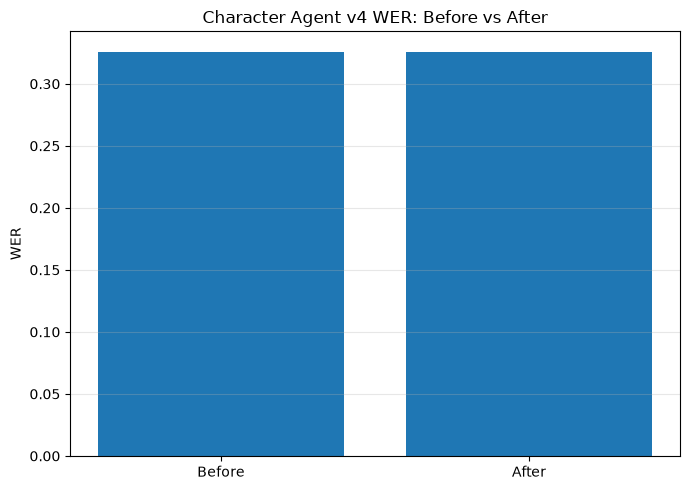

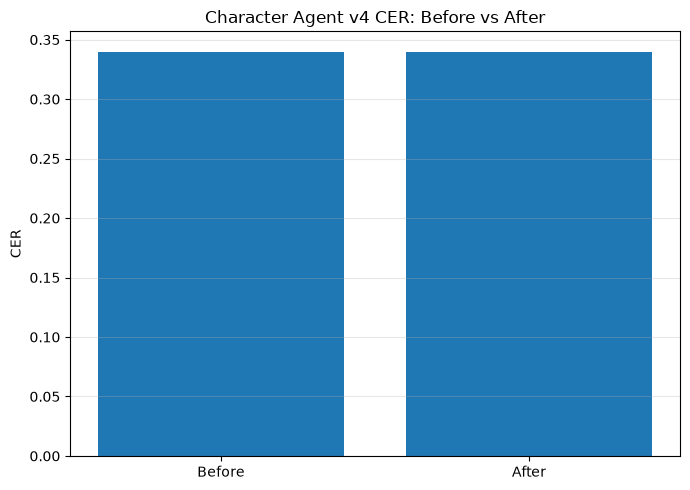

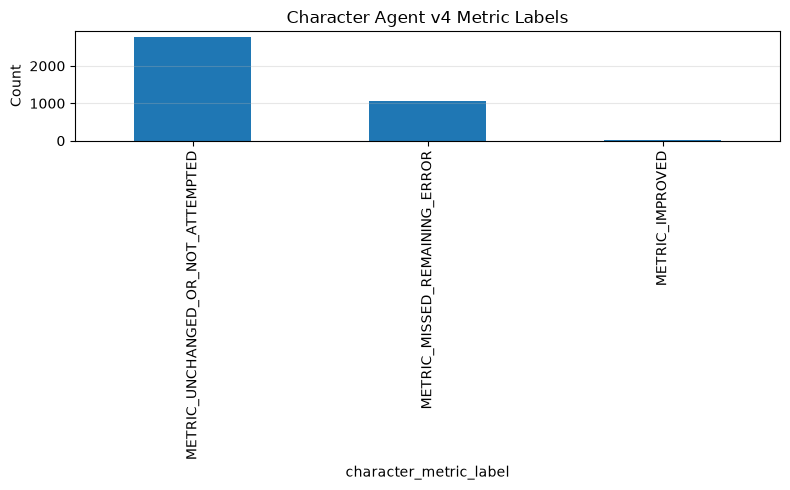

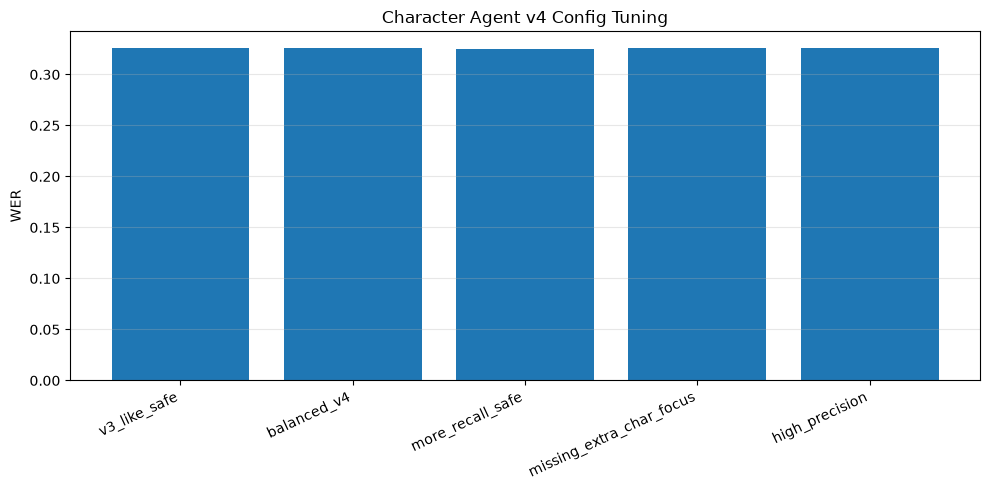

PHASE 8.1 - 8.6 CHARACTER AGENT v4 COMPLETED
Status: pending manual review, not final frozen yet
Candidate config: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_6_character_agent_v4_candidate_config_pending_manual_review.json
Checkpoint: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_8_character_agent_v4_checkpoint.json
Before WER: 0.32599779933980194
After  WER: 0.32539761928578576
Before CER: 0.3400055001178597
After  CER: 0.3398876404494382
Before Sentence Accuracy: 0.7233047544816835
After  Sentence Accuracy: 0.7243439854507664
Manual review file:
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_5_character_agent_v4_manual_examples.csv
Result: Character Agent v4 improved WER and did not worsen CER. Inspect manual examples.


In [38]:
# ============================================================
# PHASE 8.1 - 8.6
# CHARACTER CORRECTION AGENT v4
#
# Purpose:
# Stronger character-level ASR spelling correction than v3.
#
# Improvements over v3:
# 1. More tuning configs, not only threshold.
# 2. Repeated-character normalization signal.
# 3. Better candidate scoring for missing/extra character errors.
# 4. Small phonetic-like similarity signal.
# 5. Keeps only validation-safe selected config.
#
# Rules:
# - Agent sees only whisper_raw.
# - ground_truth is used only for evaluation/tuning.
# - No LLM / OLM.
# - Test set is not used.
# ============================================================

import os
import re
import json
import math
from pathlib import Path
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# SECTION 1: PATHS
# ============================================================

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

PROJECT_ROOT = Path(PROJECT_ROOT)

try:
    DATASET_DIR
except NameError:
    DATASET_DIR = PROJECT_ROOT / "dataset"

try:
    REPORT_DIR
except NameError:
    REPORT_DIR = PROJECT_ROOT / "reports"

try:
    FIGURE_DIR
except NameError:
    FIGURE_DIR = PROJECT_ROOT / "figures"

try:
    PRED_DIR
except NameError:
    PRED_DIR = PROJECT_ROOT / "predictions"

try:
    CHECKPOINT_DIR
except NameError:
    CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for p in [DATASET_DIR, REPORT_DIR, FIGURE_DIR, PRED_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

VALIDATION_CSV = DATASET_DIR / "validation.csv"
TRAIN_CSV = DATASET_DIR / "train.csv"
FINAL_COMPARISON_CSV = REPORT_DIR / "phase_8_gan_whisper_stable_final_comparison.csv"

CHAR_V4_DATASET_CSV = PRED_DIR / "phase_8_1_character_agent_v4_validation_dataset.csv"
CHAR_V4_OUTPUT_CSV = PRED_DIR / "phase_8_2_character_agent_v4_predictions.csv"
CHAR_V4_LOG_CSV = REPORT_DIR / "phase_8_3_character_agent_v4_correction_log.csv"
CHAR_V4_METRICS_CSV = REPORT_DIR / "phase_8_3_character_agent_v4_metrics.csv"
CHAR_V4_TUNING_CSV = REPORT_DIR / "phase_8_4_character_agent_v4_config_tuning.csv"
CHAR_V4_MANUAL_CSV = REPORT_DIR / "phase_8_5_character_agent_v4_manual_examples.csv"
CHAR_V4_CONFIG_JSON = REPORT_DIR / "phase_8_6_character_agent_v4_candidate_config_pending_manual_review.json"
CHAR_V4_CHECKPOINT = CHECKPOINT_DIR / "phase_8_character_agent_v4_checkpoint.json"

print("=" * 80)
print("PHASE 8.1 - 8.6: Character Correction Agent v4")
print("Project root:", PROJECT_ROOT)
print("=" * 80)

# ============================================================
# SECTION 2: HELPERS + METRICS
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())

def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    return int(dp[n, m])

try:
    from jiwer import wer as jiwer_wer
    from jiwer import cer as jiwer_cer
    JIWER_AVAILABLE = True
    print("Using jiwer for WER/CER.")
except Exception:
    JIWER_AVAILABLE = False
    print("jiwer not found. Using fallback WER/CER.")

def fallback_wer(references, predictions):
    total_edits = 0
    total_words = 0

    for r, p in zip(references, predictions):
        r_words = tokenize_words(r)
        p_words = tokenize_words(p)
        total_edits += edit_distance(r_words, p_words)
        total_words += len(r_words)

    return total_edits / max(1, total_words)

def fallback_cer(references, predictions):
    total_edits = 0
    total_chars = 0

    for r, p in zip(references, predictions):
        r_chars = list(normalize_text(r).replace(" ", ""))
        p_chars = list(normalize_text(p).replace(" ", ""))
        total_edits += edit_distance(r_chars, p_chars)
        total_chars += len(r_chars)

    return total_edits / max(1, total_chars)

def compute_wer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    if JIWER_AVAILABLE:
        return float(jiwer_wer(references, predictions))
    return float(fallback_wer(references, predictions))

def compute_cer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    if JIWER_AVAILABLE:
        return float(jiwer_cer(references, predictions))
    return float(fallback_cer(references, predictions))

def sentence_accuracy(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    return float(np.mean([r == p for r, p in zip(references, predictions)]))

def row_wer(reference, prediction):
    return fallback_wer([reference], [prediction])

def row_cer(reference, prediction):
    return fallback_cer([reference], [prediction])

def collapse_repeated_chars(word):
    return re.sub(r"(.)\1{2,}", r"\1\1", str(word))

def consonant_skeleton(word):
    word = str(word).lower()
    word = re.sub(r"[aeiou]", "", word)
    word = re.sub(r"(.)\1+", r"\1", word)
    return word

def vowel_pattern(word):
    return "".join(re.findall(r"[aeiou]", str(word).lower()))

def phonetic_light_similarity(a, b):
    a_skel = consonant_skeleton(a)
    b_skel = consonant_skeleton(b)

    skel_sim = SequenceMatcher(None, a_skel, b_skel).ratio()
    vowel_sim = SequenceMatcher(None, vowel_pattern(a), vowel_pattern(b)).ratio()

    return 0.75 * skel_sim + 0.25 * vowel_sim

# ============================================================
# SECTION 3: SELECT BEST UPSTREAM PREDICTION CSV
# ============================================================

if not FINAL_COMPARISON_CSV.exists():
    raise FileNotFoundError(f"Missing final comparison CSV: {FINAL_COMPARISON_CSV}")

comparison_df = pd.read_csv(FINAL_COMPARISON_CSV)
comparison_df = comparison_df.sort_values(["WER", "CER"], ascending=[True, True]).reset_index(drop=True)

best_pipeline = str(comparison_df.loc[0, "Pipeline"])

if "CWGAN-GP" in best_pipeline:
    SELECTED_PREDICTION_CSV = PRED_DIR / "phase_8_best_whisper_plus_cwgan_gp_stable_validation_predictions.csv"
elif "ACGAN" in best_pipeline:
    SELECTED_PREDICTION_CSV = PRED_DIR / "phase_8_best_whisper_plus_acgan_stable_validation_predictions.csv"
else:
    SELECTED_PREDICTION_CSV = PRED_DIR / "phase_8_best_whisper_baseline_validation_predictions.csv"

if not SELECTED_PREDICTION_CSV.exists():
    raise FileNotFoundError(f"Missing selected prediction CSV: {SELECTED_PREDICTION_CSV}")

print("Best upstream pipeline:", best_pipeline)
print("Using prediction CSV:", SELECTED_PREDICTION_CSV)
display(comparison_df)

# ============================================================
# SECTION 4: PREPARE VALIDATION DATASET
# ============================================================

if not VALIDATION_CSV.exists():
    raise FileNotFoundError(f"Missing validation CSV: {VALIDATION_CSV}")

valid_df = pd.read_csv(VALIDATION_CSV)
pred_df = pd.read_csv(SELECTED_PREDICTION_CSV)

if len(valid_df) != len(pred_df):
    raise ValueError(f"Row mismatch: validation={len(valid_df)}, predictions={len(pred_df)}")

if "sample_id" not in valid_df.columns:
    valid_df["sample_id"] = [f"valid_{i:06d}" for i in range(len(valid_df))]

if "audio_path" not in valid_df.columns:
    valid_df["audio_path"] = ""

if "transcript" in valid_df.columns:
    gt_col = "transcript"
elif "normalized_transcript" in valid_df.columns:
    gt_col = "normalized_transcript"
elif "text" in valid_df.columns:
    gt_col = "text"
else:
    raise ValueError("No ground-truth transcript column found in validation CSV.")

if "prediction" not in pred_df.columns:
    raise ValueError("Prediction CSV must contain column: prediction")

correction_df = pd.DataFrame({
    "sample_id": valid_df["sample_id"].astype(str),
    "audio_path": valid_df["audio_path"].astype(str),
    "ground_truth": valid_df[gt_col].astype(str).apply(normalize_text),
    "whisper_raw": pred_df["prediction"].astype(str).apply(normalize_text),
})

for c in ["speaker", "condition", "gender", "session"]:
    if c in valid_df.columns:
        correction_df[c] = valid_df[c].astype(str)

correction_df.to_csv(CHAR_V4_DATASET_CSV, index=False)

print("=" * 80)
print("Character v4 validation dataset saved")
print(CHAR_V4_DATASET_CSV)
print("Rows:", len(correction_df))
display(correction_df.head())

# ============================================================
# SECTION 5: TRAIN-ONLY VOCABULARY + CONTEXT
# ============================================================

if not TRAIN_CSV.exists():
    raise FileNotFoundError(f"Missing train CSV: {TRAIN_CSV}")

train_df = pd.read_csv(TRAIN_CSV)

if "transcript" in train_df.columns:
    train_text_col = "transcript"
elif "normalized_transcript" in train_df.columns:
    train_text_col = "normalized_transcript"
elif "text" in train_df.columns:
    train_text_col = "text"
else:
    raise ValueError("No transcript column found in train CSV.")

train_texts = train_df[train_text_col].astype(str).apply(normalize_text).tolist()

word_counts = Counter()
left_context_counts = Counter()
right_context_counts = Counter()

for text in train_texts:
    toks = tokenize_words(text)
    word_counts.update(toks)

    padded = ["<s>"] + toks + ["</s>"]

    for i in range(1, len(padded) - 1):
        left_tok = padded[i - 1]
        tok = padded[i]
        right_tok = padded[i + 1]

        left_context_counts[(left_tok, tok)] += 1
        right_context_counts[(tok, right_tok)] += 1

VOCAB = {
    w for w, c in word_counts.items()
    if re.fullmatch(r"[a-z']+", w) and len(w) >= 2
}

print("=" * 80)
print("TRAIN-ONLY VOCABULARY CREATED")
print("Train rows:", len(train_df))
print("Vocabulary size:", len(VOCAB))
print("Most common words:", word_counts.most_common(20))
print("=" * 80)

# ============================================================
# SECTION 6: CHARACTER AGENT v4
# ============================================================

class CharacterCorrectionAgentV4:
    def __init__(
        self,
        vocab,
        word_counts,
        left_context_counts,
        right_context_counts,
        min_token_len=4,
        confidence_threshold=0.84,
        min_similarity=0.78,
        min_margin=0.01,
        max_candidates=120,
        max_edit_extra=0,
        allow_repeated_char_fix=True,
    ):
        self.vocab = set(vocab)
        self.word_counts = Counter(word_counts)
        self.left_context_counts = Counter(left_context_counts)
        self.right_context_counts = Counter(right_context_counts)

        self.min_token_len = min_token_len
        self.confidence_threshold = confidence_threshold
        self.min_similarity = min_similarity
        self.min_margin = min_margin
        self.max_candidates = max_candidates
        self.max_edit_extra = max_edit_extra
        self.allow_repeated_char_fix = allow_repeated_char_fix

        self.vocab_by_length = defaultdict(list)
        for w in self.vocab:
            self.vocab_by_length[len(w)].append(w)

    def is_protected_token(self, token):
        t = str(token).strip()

        if t == "":
            return True

        if re.search(r"\d", t):
            return True

        if len(t) <= 2:
            return True

        if not re.fullmatch(r"[a-zA-Z']+", t):
            return True

        if t.count("'") > 1:
            return True

        return False

    def should_attempt_correction(self, token):
        t = str(token).lower().strip()

        if self.is_protected_token(t):
            return False

        if len(t) < self.min_token_len:
            return False

        if t in self.vocab:
            return False

        return True

    def max_edit_allowed(self, token):
        n = len(token)

        if n <= 5:
            return 1 + self.max_edit_extra
        if n <= 9:
            return 2 + self.max_edit_extra
        return 3 + self.max_edit_extra

    def candidate_pool(self, token):
        token = token.lower()
        max_ed = self.max_edit_allowed(token)

        pool = set()

        for length in range(len(token) - max_ed, len(token) + max_ed + 1):
            if length <= 0:
                continue
            for cand in self.vocab_by_length.get(length, []):
                pool.add(cand)

        return list(pool)

    def context_score(self, left_token, candidate, right_token):
        left_token = left_token if left_token else "<s>"
        right_token = right_token if right_token else "</s>"

        left_count = self.left_context_counts.get((left_token, candidate), 0)
        right_count = self.right_context_counts.get((candidate, right_token), 0)

        score = 0.0

        if left_count > 0:
            score += 0.5

        if right_count > 0:
            score += 0.5

        return float(score)

    def score_candidate(self, token, candidate, left_token=None, right_token=None):
        ed = edit_distance(token, candidate)
        max_ed = self.max_edit_allowed(token)

        if ed > max_ed:
            return None

        seq_sim = SequenceMatcher(None, token, candidate).ratio()
        edit_sim = 1.0 - (ed / max(len(token), len(candidate), 1))
        phon_sim = phonetic_light_similarity(token, candidate)
        freq_score = min(math.log1p(self.word_counts.get(candidate, 0)) / 6.0, 1.0)
        ctx_score = self.context_score(left_token, candidate, right_token)

        repeat_bonus = 0.0
        if self.allow_repeated_char_fix:
            collapsed = collapse_repeated_chars(token)
            if collapsed != token:
                repeat_bonus = SequenceMatcher(None, collapsed, candidate).ratio()

        confidence = (
            0.50 * edit_sim +
            0.24 * seq_sim +
            0.10 * phon_sim +
            0.07 * freq_score +
            0.04 * ctx_score +
            0.05 * repeat_bonus
        )

        return {
            "candidate": candidate,
            "edit_distance": int(ed),
            "edit_similarity": float(edit_sim),
            "sequence_similarity": float(seq_sim),
            "phonetic_light_similarity": float(phon_sim),
            "frequency": int(self.word_counts.get(candidate, 0)),
            "context_score": float(ctx_score),
            "repeat_bonus": float(repeat_bonus),
            "confidence": float(confidence),
        }

    def best_candidates(self, token, left_token=None, right_token=None):
        scored = []

        for cand in self.candidate_pool(token):
            item = self.score_candidate(token, cand, left_token, right_token)
            if item is not None:
                scored.append(item)

        scored = sorted(scored, key=lambda x: x["confidence"], reverse=True)
        return scored[:self.max_candidates]

    def correct_token(self, token, left_token=None, right_token=None):
        original = token
        t = str(token).lower().strip()

        if not self.should_attempt_correction(t):
            return original, {
                "changed": False,
                "reason": "protected_or_valid_or_too_short",
                "original": original,
                "corrected": original,
                "confidence": 0.0,
            }

        candidates = self.best_candidates(t, left_token, right_token)

        if len(candidates) == 0:
            return original, {
                "changed": False,
                "reason": "no_candidate",
                "original": original,
                "corrected": original,
                "confidence": 0.0,
            }

        best = candidates[0]
        second_conf = candidates[1]["confidence"] if len(candidates) > 1 else 0.0
        margin = best["confidence"] - second_conf

        accept = (
            best["confidence"] >= self.confidence_threshold
            and best["sequence_similarity"] >= self.min_similarity
            and margin >= self.min_margin
        )

        if accept:
            return best["candidate"], {
                "changed": True,
                "reason": "accepted",
                "original": original,
                "corrected": best["candidate"],
                "confidence": best["confidence"],
                "edit_distance": best["edit_distance"],
                "sequence_similarity": best["sequence_similarity"],
                "edit_similarity": best["edit_similarity"],
                "phonetic_light_similarity": best["phonetic_light_similarity"],
                "frequency": best["frequency"],
                "context_score": best["context_score"],
                "repeat_bonus": best["repeat_bonus"],
                "margin": float(margin),
                "candidate_count": len(candidates),
            }

        return original, {
            "changed": False,
            "reason": "rejected_low_confidence",
            "original": original,
            "corrected": original,
            "best_candidate": best["candidate"],
            "confidence": best["confidence"],
            "edit_distance": best["edit_distance"],
            "sequence_similarity": best["sequence_similarity"],
            "edit_similarity": best["edit_similarity"],
            "phonetic_light_similarity": best["phonetic_light_similarity"],
            "frequency": best["frequency"],
            "context_score": best["context_score"],
            "repeat_bonus": best["repeat_bonus"],
            "margin": float(margin),
            "candidate_count": len(candidates),
        }

    def correct_text(self, text):
        text = normalize_text(text)
        tokens = text.split()

        corrected_tokens = []
        logs = []

        for i, tok in enumerate(tokens):
            left_tok = tokens[i - 1] if i > 0 else "<s>"
            right_tok = tokens[i + 1] if i < len(tokens) - 1 else "</s>"

            corrected, info = self.correct_token(tok, left_tok, right_tok)
            corrected_tokens.append(corrected)

            if info["changed"] or info["reason"] in ["no_candidate", "rejected_low_confidence"]:
                logs.append(info)

        return " ".join(corrected_tokens), logs

# ============================================================
# SECTION 7: RUN + EVALUATE
# ============================================================

def run_character_agent(agent, df):
    outputs = []
    logs = []

    for idx, row in df.iterrows():
        corrected, row_logs = agent.correct_text(row["whisper_raw"])
        outputs.append(corrected)

        for log in row_logs:
            item = dict(log)
            item["row_index"] = int(idx)
            item["sample_id"] = row["sample_id"]
            item["whisper_raw"] = row["whisper_raw"]
            item["character_corrected"] = corrected
            logs.append(item)

    out_df = df.copy()
    out_df["character_corrected"] = outputs
    out_df["changed_by_character_agent"] = (
        out_df["whisper_raw"] != out_df["character_corrected"]
    )

    refs = out_df["ground_truth"].astype(str).tolist()
    raw = out_df["whisper_raw"].astype(str).tolist()
    corrected = out_df["character_corrected"].astype(str).tolist()

    metrics = {
        "before_wer": compute_wer(refs, raw),
        "after_wer": compute_wer(refs, corrected),
        "before_cer": compute_cer(refs, raw),
        "after_cer": compute_cer(refs, corrected),
        "before_sentence_accuracy": sentence_accuracy(refs, raw),
        "after_sentence_accuracy": sentence_accuracy(refs, corrected),
        "total_samples": int(len(out_df)),
        "total_changed": int(out_df["changed_by_character_agent"].sum()),
    }

    out_df["wer_before"] = [row_wer(r, p) for r, p in zip(refs, raw)]
    out_df["wer_after"] = [row_wer(r, p) for r, p in zip(refs, corrected)]
    out_df["cer_before"] = [row_cer(r, p) for r, p in zip(refs, raw)]
    out_df["cer_after"] = [row_cer(r, p) for r, p in zip(refs, corrected)]

    out_df["character_metric_label"] = "METRIC_UNCHANGED_OR_NOT_ATTEMPTED"

    out_df.loc[
        out_df["changed_by_character_agent"] & (out_df["cer_after"] < out_df["cer_before"]),
        "character_metric_label"
    ] = "METRIC_IMPROVED"

    out_df.loc[
        out_df["changed_by_character_agent"] & (out_df["cer_after"] == out_df["cer_before"]),
        "character_metric_label"
    ] = "METRIC_UNCHANGED_AFTER_CHANGE"

    out_df.loc[
        out_df["changed_by_character_agent"] & (out_df["cer_after"] > out_df["cer_before"]),
        "character_metric_label"
    ] = "METRIC_WORSENED"

    out_df.loc[
        (~out_df["changed_by_character_agent"]) & (out_df["whisper_raw"] != out_df["ground_truth"]),
        "character_metric_label"
    ] = "METRIC_MISSED_REMAINING_ERROR"

    summary = out_df["character_metric_label"].value_counts().to_dict()

    metrics.update({
        "metric_improved_count": int(summary.get("METRIC_IMPROVED", 0)),
        "metric_worsened_count": int(summary.get("METRIC_WORSENED", 0)),
        "metric_unchanged_after_change_count": int(summary.get("METRIC_UNCHANGED_AFTER_CHANGE", 0)),
        "metric_missed_remaining_error_count": int(summary.get("METRIC_MISSED_REMAINING_ERROR", 0)),
        "metric_unchanged_or_not_attempted_count": int(summary.get("METRIC_UNCHANGED_OR_NOT_ATTEMPTED", 0)),
    })

    attempted = (
        metrics["metric_improved_count"] +
        metrics["metric_worsened_count"] +
        metrics["metric_unchanged_after_change_count"]
    )

    metrics["metric_precision"] = metrics["metric_improved_count"] / attempted if attempted > 0 else 0.0
    metrics["wer_delta"] = metrics["after_wer"] - metrics["before_wer"]
    metrics["cer_delta"] = metrics["after_cer"] - metrics["before_cer"]
    metrics["sentence_accuracy_delta"] = (
        metrics["after_sentence_accuracy"] - metrics["before_sentence_accuracy"]
    )

    log_df = pd.DataFrame(logs)

    return out_df, log_df, metrics

# ============================================================
# SECTION 8: CONFIG TUNING
# ============================================================

tuning_configs = [
    {
        "name": "v3_like_safe",
        "confidence_threshold": 0.88,
        "min_similarity": 0.84,
        "min_margin": 0.03,
        "max_edit_extra": 0,
    },
    {
        "name": "balanced_v4",
        "confidence_threshold": 0.84,
        "min_similarity": 0.80,
        "min_margin": 0.02,
        "max_edit_extra": 0,
    },
    {
        "name": "more_recall_safe",
        "confidence_threshold": 0.82,
        "min_similarity": 0.78,
        "min_margin": 0.02,
        "max_edit_extra": 0,
    },
    {
        "name": "missing_extra_char_focus",
        "confidence_threshold": 0.84,
        "min_similarity": 0.78,
        "min_margin": 0.02,
        "max_edit_extra": 1,
    },
    {
        "name": "high_precision",
        "confidence_threshold": 0.90,
        "min_similarity": 0.86,
        "min_margin": 0.04,
        "max_edit_extra": 0,
    },
]

tuning_rows = []

for cfg in tuning_configs:
    agent = CharacterCorrectionAgentV4(
        vocab=VOCAB,
        word_counts=word_counts,
        left_context_counts=left_context_counts,
        right_context_counts=right_context_counts,
        min_token_len=4,
        confidence_threshold=cfg["confidence_threshold"],
        min_similarity=cfg["min_similarity"],
        min_margin=cfg["min_margin"],
        max_edit_extra=cfg["max_edit_extra"],
        allow_repeated_char_fix=True,
    )

    temp_df, temp_log_df, temp_metrics = run_character_agent(agent, correction_df)

    tuning_rows.append({
        **cfg,
        **temp_metrics
    })

tuning_df = pd.DataFrame(tuning_rows)

safe_tuning_df = tuning_df[
    (tuning_df["after_wer"] <= tuning_df["before_wer"]) &
    (tuning_df["after_cer"] <= tuning_df["before_cer"])
].copy()

if len(safe_tuning_df) > 0:
    selected_tuning_df = safe_tuning_df.sort_values(
        ["after_wer", "after_cer", "metric_precision", "after_sentence_accuracy"],
        ascending=[True, True, False, False]
    ).reset_index(drop=True)
else:
    selected_tuning_df = tuning_df.sort_values(
        ["after_wer", "after_cer", "metric_precision", "after_sentence_accuracy"],
        ascending=[True, True, False, False]
    ).reset_index(drop=True)

best_cfg = selected_tuning_df.iloc[0].to_dict()
tuning_df.to_csv(CHAR_V4_TUNING_CSV, index=False)

print("=" * 80)
print("Character Agent v4 tuning complete")
print("Selected config:", best_cfg["name"])
print("Saved:", CHAR_V4_TUNING_CSV)
print("=" * 80)
display(tuning_df)

# ============================================================
# SECTION 9: FINAL v4 RUN
# ============================================================

final_agent = CharacterCorrectionAgentV4(
    vocab=VOCAB,
    word_counts=word_counts,
    left_context_counts=left_context_counts,
    right_context_counts=right_context_counts,
    min_token_len=4,
    confidence_threshold=float(best_cfg["confidence_threshold"]),
    min_similarity=float(best_cfg["min_similarity"]),
    min_margin=float(best_cfg["min_margin"]),
    max_edit_extra=int(best_cfg["max_edit_extra"]),
    allow_repeated_char_fix=True,
)

result_df, correction_log_df, final_metrics = run_character_agent(final_agent, correction_df)

result_df.to_csv(CHAR_V4_OUTPUT_CSV, index=False)
correction_log_df.to_csv(CHAR_V4_LOG_CSV, index=False)

metrics_df = pd.DataFrame([
    {
        "Metric": "WER",
        "Before": final_metrics["before_wer"],
        "After": final_metrics["after_wer"],
        "Delta": final_metrics["wer_delta"],
    },
    {
        "Metric": "CER",
        "Before": final_metrics["before_cer"],
        "After": final_metrics["after_cer"],
        "Delta": final_metrics["cer_delta"],
    },
    {
        "Metric": "Sentence Accuracy",
        "Before": final_metrics["before_sentence_accuracy"],
        "After": final_metrics["after_sentence_accuracy"],
        "Delta": final_metrics["sentence_accuracy_delta"],
    },
])

metrics_df.to_csv(CHAR_V4_METRICS_CSV, index=False)

print("=" * 80)
print("FINAL CHARACTER AGENT v4 RESULTS")
print("=" * 80)
display(metrics_df)

print("Character Agent v4 metric summary:")
print(json.dumps(final_metrics, indent=2))

# ============================================================
# SECTION 10: MANUAL INSPECTION EXAMPLES
# ============================================================

manual_parts = []

improved_df = result_df[result_df["character_metric_label"] == "METRIC_IMPROVED"].copy()
worsened_df = result_df[result_df["character_metric_label"] == "METRIC_WORSENED"].copy()
missed_df = result_df[result_df["character_metric_label"] == "METRIC_MISSED_REMAINING_ERROR"].copy()
unchanged_change_df = result_df[result_df["character_metric_label"] == "METRIC_UNCHANGED_AFTER_CHANGE"].copy()

if len(improved_df) > 0:
    manual_parts.append(improved_df.sort_values("cer_before", ascending=False).head(20))

if len(worsened_df) > 0:
    manual_parts.append(worsened_df.sort_values("cer_after", ascending=False).head(15))

if len(missed_df) > 0:
    manual_parts.append(missed_df.sort_values("cer_before", ascending=False).head(20))

if len(unchanged_change_df) > 0:
    manual_parts.append(unchanged_change_df.head(5))

if len(manual_parts) > 0:
    manual_df = pd.concat(manual_parts, ignore_index=True)
    manual_df = manual_df.drop_duplicates(subset=["sample_id"]).head(60)
else:
    manual_df = result_df.head(60).copy()

manual_cols = [
    "sample_id",
    "ground_truth",
    "whisper_raw",
    "character_corrected",
    "character_metric_label",
    "wer_before",
    "wer_after",
    "cer_before",
    "cer_after",
]

extra_cols = [c for c in ["speaker", "condition", "gender", "session"] if c in manual_df.columns]
manual_df = manual_df[extra_cols + manual_cols]

manual_df.to_csv(CHAR_V4_MANUAL_CSV, index=False)

print("=" * 80)
print("Character Agent v4 manual examples saved")
print(CHAR_V4_MANUAL_CSV)
print("=" * 80)
display(manual_df)

# ============================================================
# SECTION 11: FIGURES
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(["Before", "After"], [final_metrics["before_wer"], final_metrics["after_wer"]])
plt.ylabel("WER")
plt.title("Character Agent v4 WER: Before vs After")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
wer_fig = FIGURE_DIR / "phase_8_character_agent_v4_wer_before_after.png"
plt.savefig(wer_fig, dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(["Before", "After"], [final_metrics["before_cer"], final_metrics["after_cer"]])
plt.ylabel("CER")
plt.title("Character Agent v4 CER: Before vs After")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
cer_fig = FIGURE_DIR / "phase_8_character_agent_v4_cer_before_after.png"
plt.savefig(cer_fig, dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
result_df["character_metric_label"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Character Agent v4 Metric Labels")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
category_fig = FIGURE_DIR / "phase_8_character_agent_v4_metric_labels.png"
plt.savefig(category_fig, dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(tuning_df["name"], tuning_df["after_wer"])
plt.ylabel("WER")
plt.title("Character Agent v4 Config Tuning")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
tuning_fig = FIGURE_DIR / "phase_8_character_agent_v4_config_tuning.png"
plt.savefig(tuning_fig, dpi=200)
plt.show()

# ============================================================
# SECTION 12: SAVE CONFIG PENDING MANUAL REVIEW
# ============================================================

candidate_config = {
    "phase": "Phase 8.6 - Character Correction Agent v4 Candidate Config",
    "status": "pending_manual_review_not_final_freeze",
    "selected_upstream_pipeline": best_pipeline,
    "selected_prediction_csv": str(SELECTED_PREDICTION_CSV),
    "vocabulary_source": str(TRAIN_CSV),
    "vocabulary_policy": "Training transcripts only. No validation ground-truth leakage.",
    "agent_definition": "Character-level candidate correction for likely malformed ASR tokens.",
    "uses_llm": False,
    "ground_truth_visible_to_agent": False,
    "test_set_used": False,
    "selected_config": {
        "name": best_cfg["name"],
        "confidence_threshold": float(best_cfg["confidence_threshold"]),
        "min_similarity": float(best_cfg["min_similarity"]),
        "min_margin": float(best_cfg["min_margin"]),
        "max_edit_extra": int(best_cfg["max_edit_extra"]),
    },
    "protection_policy": "Protects numbers, alphanumeric/punctuation-heavy tokens, and very short tokens. Does not claim full named-entity protection.",
    "candidate_generation": "Length-window candidate search without hard first-letter restriction.",
    "score_policy": "Main score uses edit similarity and sequence similarity; small support from phonetic-light similarity, frequency, context, and repeated-character signal.",
    "metrics": final_metrics,
    "outputs": {
        "validation_dataset_csv": str(CHAR_V4_DATASET_CSV),
        "character_predictions_csv": str(CHAR_V4_OUTPUT_CSV),
        "metrics_csv": str(CHAR_V4_METRICS_CSV),
        "tuning_csv": str(CHAR_V4_TUNING_CSV),
        "manual_examples_csv": str(CHAR_V4_MANUAL_CSV),
        "correction_log_csv": str(CHAR_V4_LOG_CSV),
    },
    "figures": {
        "wer": str(wer_fig),
        "cer": str(cer_fig),
        "metric_labels": str(category_fig),
        "config_tuning": str(tuning_fig),
    },
    "next_step": "Compare v4 against v3. Use the better character output as input to Word Agent.",
}

save_json(candidate_config, CHAR_V4_CONFIG_JSON)

checkpoint = {
    "status": "completed_pending_manual_review",
    "phase": "Phase 8.1 - 8.6 Character Correction Agent v4",
    "candidate_config_json": str(CHAR_V4_CONFIG_JSON),
    "selected_config": best_cfg["name"],
    "final_metrics": final_metrics,
    "test_set_used": False,
    "important_rule": "Character Agent used only whisper_raw. Ground truth was used only for evaluation.",
}

save_json(checkpoint, CHAR_V4_CHECKPOINT)

print("=" * 80)
print("PHASE 8.1 - 8.6 CHARACTER AGENT v4 COMPLETED")
print("Status: pending manual review, not final frozen yet")
print("Candidate config:", CHAR_V4_CONFIG_JSON)
print("Checkpoint:", CHAR_V4_CHECKPOINT)
print("=" * 80)

print("Before WER:", final_metrics["before_wer"])
print("After  WER:", final_metrics["after_wer"])
print("Before CER:", final_metrics["before_cer"])
print("After  CER:", final_metrics["after_cer"])
print("Before Sentence Accuracy:", final_metrics["before_sentence_accuracy"])
print("After  Sentence Accuracy:", final_metrics["after_sentence_accuracy"])

print("=" * 80)
print("Manual review file:")
print(CHAR_V4_MANUAL_CSV)
print("=" * 80)

if final_metrics["after_wer"] < final_metrics["before_wer"] and final_metrics["after_cer"] <= final_metrics["before_cer"]:
    print("Result: Character Agent v4 improved WER and did not worsen CER. Inspect manual examples.")
elif final_metrics["after_wer"] <= final_metrics["before_wer"] and final_metrics["after_cer"] <= final_metrics["before_cer"]:
    print("Result: Character Agent v4 is metric-safe. Inspect manual examples.")
else:
    print("Result: Character Agent v4 worsened WER or CER. Keep v3 unless manual review proves otherwise.")

PHASE 8.7 - 8.10: Word Correction Agent v3
Using Character Agent: v4
Character output: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_2_character_agent_v4_predictions.csv
Using jiwer for WER/CER.
Loaded rows: 3849


,sample_id,audio_path,ground_truth,whisper_raw,speaker,condition,gender,session,character_corrected,changed_by_character_agent,wer_before,wer_after,cer_before,cer_after,character_metric_label,word_agent_input
0,torgo_004572,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,born,born,FC03,control,female,Session1,born,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,born
1,torgo_004573,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,tear,tear,FC03,control,female,Session1,tear,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,tear
2,torgo_004574,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,no,no,FC03,control,female,Session1,no,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,no
3,torgo_004575,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,train,train,FC03,control,female,Session1,train,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,train
4,torgo_004576,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,rain,rain,FC03,control,female,Session1,rain,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,rain


TRAIN-ONLY N-GRAM CONTEXT CREATED
Train rows: 9950
Vocabulary size: 1568
Most common words: [('the', 874), ('a', 505), ('to', 412), ('he', 310), ('is', 289), ('i', 240), ('of', 239), ('in', 220), ('for', 209), ('and', 207), ('we', 197), ('you', 166), ('it', 151), ('was', 143), ('be', 134), ('are', 133), ('as', 128), ('input', 120), ('images', 120), ('jpg', 120)]
Confusion map size: 37
Artifact tokens: ['jpeg', 'jpg', 'png']
WORD AGENT v3 TUNING COMPLETE
Selected config: strict_confusion_loose_repetition
Saved: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_9_word_agent_v3_from_character_v4_tuning.csv


,name,confidence_threshold,min_context_gain,max_repeat_keep,repeated_phrase_max_len,min_repeated_word_count,before_wer,after_wer,before_cer,after_cer,...,total_changed,metric_improved_count,metric_worsened_count,metric_unchanged_after_change_count,metric_missed_remaining_error_count,metric_unchanged_or_not_attempted_count,metric_precision,wer_delta,cer_delta,sentence_accuracy_delta
0,safe_repeat_cleanup,0.70,0.20,1,6,3,0.325398,0.212064,0.339888,0.241278,...,41,41,0,0,1020,2788,1.0,-0.113334,-0.098609,0.0
1,balanced,0.55,0.05,1,6,3,0.325398,0.211964,0.339888,0.241259,...,42,42,0,0,1019,2788,1.0,-0.113434,-0.098629,0.0
2,repeat_keep_two,0.55,0.05,2,6,3,0.325398,0.212264,0.339888,0.241632,...,42,42,0,0,1019,2788,1.0,-0.113134,-0.098256,0.0
3,strict_confusion_loose_repetition,0.75,0.20,1,7,3,0.325398,0.209063,0.339888,0.237998,...,42,42,0,0,1019,2788,1.0,-0.116335,-0.101890,0.0


FINAL WORD AGENT v3 VALIDATION RESULTS


,Metric,Before Word Agent,After Word Agent,Delta
0,WER,0.325398,0.209063,-0.116335
1,CER,0.339888,0.237998,-0.101890
2,Sentence Accuracy,0.724344,0.724344,0.000000


Word Agent v3 metric summary:
{
  "before_wer": 0.32539761928578576,
  "after_wer": 0.2090627188156447,
  "before_cer": 0.3398876404494382,
  "after_cer": 0.2379979570990807,
  "before_sentence_accuracy": 0.7243439854507664,
  "after_sentence_accuracy": 0.7243439854507664,
  "total_samples": 3849,
  "total_changed": 42,
  "metric_improved_count": 42,
  "metric_worsened_count": 0,
  "metric_unchanged_after_change_count": 0,
  "metric_missed_remaining_error_count": 1019,
  "metric_unchanged_or_not_attempted_count": 2788,
  "metric_precision": 1.0,
  "wer_delta": -0.11633490047014106,
  "cer_delta": -0.1018896833503575,
  "sentence_accuracy_delta": 0.0
}
WORD AGENT v3 MANUAL EXAMPLES SAVED
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_10_word_agent_v3_from_character_v4_manual_examples.csv


,speaker,condition,gender,session,sample_id,ground_truth,whisper_raw,character_corrected,word_agent_input,word_corrected,word_metric_label,wer_before_word,wer_after_word,cer_before_word,cer_after_word
0,M01,dysarthric,male,Session2_3,torgo_006837,delta,bear with the bear with the bear with the bear...,bear with the bear with the bear with the bear...,bear with the bear with the bear with the bear...,bear with the bear,METRIC_IMPROVED,64.000000,4.000000,46.400000,2.400000
1,FC03,control,female,Session1,torgo_004642,swarm,yes we are swarm swarm swarm swarm swarm swarm...,yes we are swarm swarm swarm swarm swarm swarm...,yes we are swarm swarm swarm swarm swarm swarm...,yes we are swarm,METRIC_IMPROVED,63.000000,3.000000,61.600000,1.600000
2,FC03,control,female,Session1,torgo_004603,the,their story begins with a short story about th...,their story begins with a short story about th...,their story begins with a short story about th...,their story begins with a short story about th...,METRIC_IMPROVED,38.000000,15.000000,57.666667,19.333333
3,FC03,control,female,Session1,torgo_004763,xxx,input images story starters 22 jpg jpg jpg jpg...,input images story starters 22 jpg jpg jpg jpg...,input images story starters 22 jpg jpg jpg jpg...,22,METRIC_IMPROVED,34.000000,1.000000,37.666667,1.000000
4,M01,dysarthric,male,Session1,torgo_006589,air,input images story starters 15 jpg jpg jpg jpg...,input images story starters 15 jpg jpg jpg jpg...,input images story starters 15 jpg jpg jpg jpg...,15,METRIC_IMPROVED,34.000000,1.000000,37.000000,1.000000
5,M01,dysarthric,male,Session2_3,torgo_006970,lima,input images story starters 31 jpg jpg jpg jpg...,input images story starters 31 jpg jpg jpg jpg...,input images story starters 31 jpg jpg jpg jpg...,31,METRIC_IMPROVED,34.000000,1.000000,27.500000,1.000000
6,M01,dysarthric,male,Session2_3,torgo_007251,lima,input images story starters 15 jpg jpg jpg jpg...,input images story starters 15 jpg jpg jpg jpg...,input images story starters 15 jpg jpg jpg jpg...,15,METRIC_IMPROVED,34.000000,1.000000,27.500000,1.000000
7,MC02,control,male,Session2,torgo_013193,in,input images story starters jpg jpg jpg jpg jp...,input images story starters jpg jpg jpg jpg jp...,input images story starters jpg jpg jpg jpg jp...,j,METRIC_IMPROVED,34.000000,1.000000,55.000000,1.000000
8,FC03,control,female,Session2,torgo_005979,gill,jell or earring jpg jpg jpg jpg jpg jpg jpg jp...,jell or earring jpg jpg jpg jpg jpg jpg jpg jp...,jell or earring jpg jpg jpg jpg jpg jpg jpg jp...,jell or earring j,METRIC_IMPROVED,33.000000,4.000000,24.750000,3.000000
9,M01,dysarthric,male,Session2_3,torgo_006922,thorn,jorn jr jr jr jr jr jr jr jr jr jr jr jr jr jr...,jorn jr jr jr jr jr jr jr jr jr jr jr jr jr jr...,jorn jr jr jr jr jr jr jr jr jr jr jr jr jr jr...,jorn jr,METRIC_IMPROVED,32.000000,2.000000,12.800000,0.800000


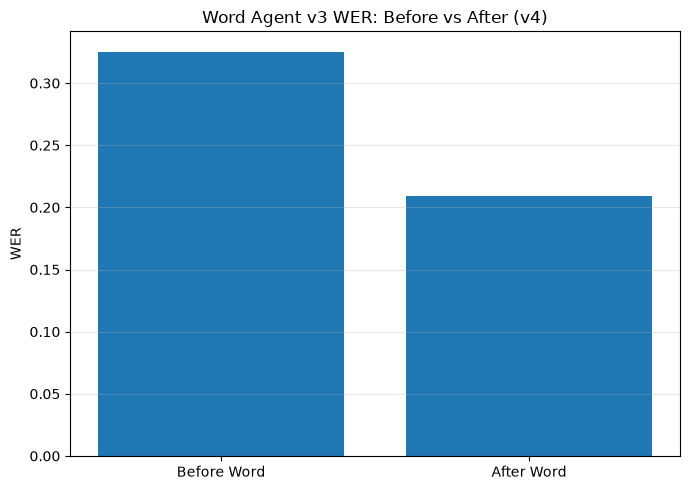

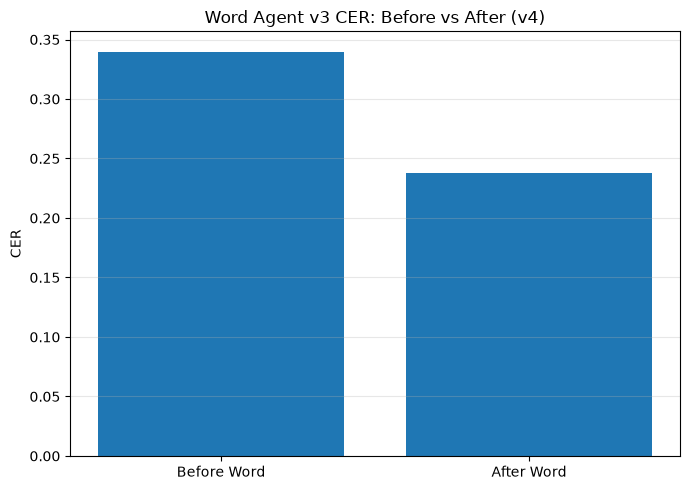

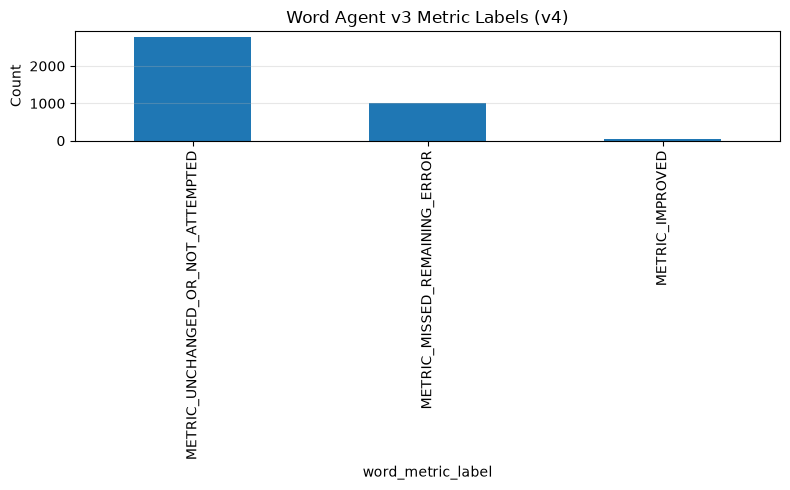

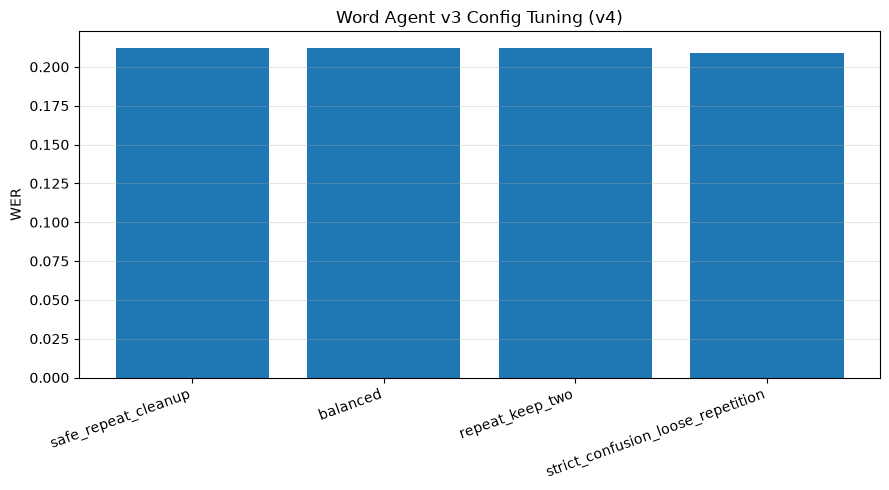

PHASE 8.7 - 8.10 WORD AGENT v3 COMPLETED
Character input: v4
Status: pending manual review, not frozen yet
Candidate config: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_10_word_agent_v3_from_character_v4_candidate_config.json
Checkpoint: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_8_word_agent_v3_from_character_v4_checkpoint.json
Before Word WER: 0.32539761928578576
After  Word WER: 0.2090627188156447
Before Word CER: 0.3398876404494382
After  Word CER: 0.2379979570990807
Before Word Sentence Accuracy: 0.7243439854507664
After  Word Sentence Accuracy: 0.7243439854507664
Manual review file:
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_10_word_agent_v3_from_character_v4_manual_examples.csv
Result: Word Agent v3 improved at least one metric. Manually inspect before freezing.


In [39]:
# ============================================================
# PHASE 8.7 - 8.10
# WORD CORRECTION AGENT v3
#
# Input:
# Character Agent v4 output if available,
# otherwise Character Agent v3 output.
#
# Purpose:
# - valid-but-wrong confusion word correction
# - repeated word / phrase cleanup
# - obvious artifact cleanup
#
# Rules:
# - Word Agent sees only character_corrected
# - ground_truth is used only for evaluation
# - No LLM / OLM
# - Test set is not used
# ============================================================

import os
import re
import json
import math
from pathlib import Path
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# SECTION 1: PATHS
# ============================================================

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

PROJECT_ROOT = Path(PROJECT_ROOT)

try:
    DATASET_DIR
except NameError:
    DATASET_DIR = PROJECT_ROOT / "dataset"

try:
    REPORT_DIR
except NameError:
    REPORT_DIR = PROJECT_ROOT / "reports"

try:
    FIGURE_DIR
except NameError:
    FIGURE_DIR = PROJECT_ROOT / "figures"

try:
    PRED_DIR
except NameError:
    PRED_DIR = PROJECT_ROOT / "predictions"

try:
    CHECKPOINT_DIR
except NameError:
    CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for p in [DATASET_DIR, REPORT_DIR, FIGURE_DIR, PRED_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATASET_DIR / "train.csv"

CHAR_V4_OUTPUT_CSV = PRED_DIR / "phase_8_2_character_agent_v4_predictions.csv"
CHAR_V3_OUTPUT_CSV = PRED_DIR / "phase_8_2_character_agent_v3_predictions.csv"

if CHAR_V4_OUTPUT_CSV.exists():
    CHARACTER_OUTPUT_CSV = CHAR_V4_OUTPUT_CSV
    CHARACTER_VERSION = "v4"
elif CHAR_V3_OUTPUT_CSV.exists():
    CHARACTER_OUTPUT_CSV = CHAR_V3_OUTPUT_CSV
    CHARACTER_VERSION = "v3"
else:
    raise FileNotFoundError(
        "No Character Agent output found. Run Character Agent v4 or v3 first."
    )

WORD_OUTPUT_CSV = PRED_DIR / f"phase_8_7_word_agent_v3_from_character_{CHARACTER_VERSION}_predictions.csv"
WORD_LOG_CSV = REPORT_DIR / f"phase_8_7_word_agent_v3_from_character_{CHARACTER_VERSION}_correction_log.csv"
WORD_METRICS_CSV = REPORT_DIR / f"phase_8_8_word_agent_v3_from_character_{CHARACTER_VERSION}_metrics.csv"
WORD_TUNING_CSV = REPORT_DIR / f"phase_8_9_word_agent_v3_from_character_{CHARACTER_VERSION}_tuning.csv"
WORD_MANUAL_CSV = REPORT_DIR / f"phase_8_10_word_agent_v3_from_character_{CHARACTER_VERSION}_manual_examples.csv"
WORD_CONFIG_JSON = REPORT_DIR / f"phase_8_10_word_agent_v3_from_character_{CHARACTER_VERSION}_candidate_config.json"
WORD_CHECKPOINT_JSON = CHECKPOINT_DIR / f"phase_8_word_agent_v3_from_character_{CHARACTER_VERSION}_checkpoint.json"

print("=" * 80)
print("PHASE 8.7 - 8.10: Word Correction Agent v3")
print("Using Character Agent:", CHARACTER_VERSION)
print("Character output:", CHARACTER_OUTPUT_CSV)
print("=" * 80)

# ============================================================
# SECTION 2: HELPERS + METRICS
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())

def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    return int(dp[n, m])

try:
    from jiwer import wer as jiwer_wer
    from jiwer import cer as jiwer_cer
    JIWER_AVAILABLE = True
    print("Using jiwer for WER/CER.")
except Exception:
    JIWER_AVAILABLE = False
    print("jiwer not found. Using fallback WER/CER.")

def fallback_wer(references, predictions):
    total_edits = 0
    total_words = 0

    for r, p in zip(references, predictions):
        r_words = tokenize_words(r)
        p_words = tokenize_words(p)
        total_edits += edit_distance(r_words, p_words)
        total_words += len(r_words)

    return total_edits / max(1, total_words)

def fallback_cer(references, predictions):
    total_edits = 0
    total_chars = 0

    for r, p in zip(references, predictions):
        r_chars = list(normalize_text(r).replace(" ", ""))
        p_chars = list(normalize_text(p).replace(" ", ""))
        total_edits += edit_distance(r_chars, p_chars)
        total_chars += len(r_chars)

    return total_edits / max(1, total_chars)

def compute_wer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_wer(references, predictions))

    return float(fallback_wer(references, predictions))

def compute_cer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_cer(references, predictions))

    return float(fallback_cer(references, predictions))

def sentence_accuracy(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    return float(np.mean([r == p for r, p in zip(references, predictions)]))

def row_wer(reference, prediction):
    return fallback_wer([reference], [prediction])

def row_cer(reference, prediction):
    return fallback_cer([reference], [prediction])

# ============================================================
# SECTION 3: LOAD CHARACTER OUTPUT
# ============================================================

char_df = pd.read_csv(CHARACTER_OUTPUT_CSV)

required_cols = ["sample_id", "ground_truth", "whisper_raw", "character_corrected"]
for c in required_cols:
    if c not in char_df.columns:
        raise ValueError(f"Missing required column in Character output: {c}")

word_df = char_df.copy()
word_df["word_agent_input"] = word_df["character_corrected"].astype(str).apply(normalize_text)

print("Loaded rows:", len(word_df))
display(word_df.head())

# ============================================================
# SECTION 4: TRAIN-ONLY N-GRAM CONTEXT
# ============================================================

if not TRAIN_CSV.exists():
    raise FileNotFoundError(f"Missing train CSV: {TRAIN_CSV}")

train_df = pd.read_csv(TRAIN_CSV)

if "transcript" in train_df.columns:
    train_text_col = "transcript"
elif "normalized_transcript" in train_df.columns:
    train_text_col = "normalized_transcript"
elif "text" in train_df.columns:
    train_text_col = "text"
else:
    raise ValueError("No transcript column found in train CSV.")

train_texts = train_df[train_text_col].astype(str).apply(normalize_text).tolist()

unigram_counts = Counter()
bigram_counts = Counter()
trigram_counts = Counter()

for text in train_texts:
    toks = tokenize_words(text)
    unigram_counts.update(toks)

    padded = ["<s>"] + toks + ["</s>"]

    for i in range(1, len(padded) - 1):
        left_tok = padded[i - 1]
        tok = padded[i]
        right_tok = padded[i + 1]

        bigram_counts[(left_tok, tok)] += 1
        bigram_counts[(tok, right_tok)] += 1
        trigram_counts[(left_tok, tok, right_tok)] += 1

VOCAB = {
    w for w, c in unigram_counts.items()
    if re.fullmatch(r"[a-z']+", w) and len(w) >= 1
}

print("=" * 80)
print("TRAIN-ONLY N-GRAM CONTEXT CREATED")
print("Train rows:", len(train_df))
print("Vocabulary size:", len(VOCAB))
print("Most common words:", unigram_counts.most_common(20))
print("=" * 80)

# ============================================================
# SECTION 5: WORD RULES
# ============================================================

CONFUSION_GROUPS = [
    {"to", "too", "two"},
    {"for", "four"},
    {"there", "their", "they're"},
    {"here", "hear"},
    {"no", "know"},
    {"one", "won"},
    {"right", "write"},
    {"see", "sea"},
    {"new", "knew"},
    {"our", "hour"},
    {"by", "buy", "bye"},
    {"then", "than"},
    {"ate", "eight"},
    {"be", "bee"},
    {"were", "where"},
    {"your", "you're"},
    {"its", "it's"},
]

CONFUSION_MAP = defaultdict(set)

for group in CONFUSION_GROUPS:
    normalized_group = {normalize_text(x) for x in group}
    for w in normalized_group:
        CONFUSION_MAP[w].update(normalized_group - {w})

ARTIFACT_PHRASES = [
    ["input", "images", "story", "starters"],
]

ARTIFACT_TOKENS = {
    "jpg", "jpeg", "png"
}

print("Confusion map size:", len(CONFUSION_MAP))
print("Artifact tokens:", sorted(ARTIFACT_TOKENS))

# ============================================================
# SECTION 6: WORD AGENT v3
# ============================================================

class WordCorrectionAgentV3:
    def __init__(
        self,
        vocab,
        unigram_counts,
        bigram_counts,
        trigram_counts,
        confusion_map,
        artifact_tokens,
        artifact_phrases,
        confidence_threshold=0.55,
        min_context_gain=0.05,
        min_margin=0.00,
        max_repeat_keep=1,
        repeated_phrase_max_len=6,
        min_repeated_word_count=3,
        enable_artifact_cleanup=True,
        enable_repetition_cleanup=True,
        enable_confusion_correction=True,
    ):
        self.vocab = set(vocab)
        self.unigram_counts = Counter(unigram_counts)
        self.bigram_counts = Counter(bigram_counts)
        self.trigram_counts = Counter(trigram_counts)
        self.confusion_map = confusion_map
        self.artifact_tokens = set(artifact_tokens)
        self.artifact_phrases = [list(p) for p in artifact_phrases]

        self.confidence_threshold = confidence_threshold
        self.min_context_gain = min_context_gain
        self.min_margin = min_margin
        self.max_repeat_keep = max_repeat_keep
        self.repeated_phrase_max_len = repeated_phrase_max_len
        self.min_repeated_word_count = min_repeated_word_count

        self.enable_artifact_cleanup = enable_artifact_cleanup
        self.enable_repetition_cleanup = enable_repetition_cleanup
        self.enable_confusion_correction = enable_confusion_correction

    def context_score(self, left_tok, word, right_tok):
        left_tok = left_tok if left_tok else "<s>"
        right_tok = right_tok if right_tok else "</s>"

        tri = self.trigram_counts.get((left_tok, word, right_tok), 0)
        left_bigram = self.bigram_counts.get((left_tok, word), 0)
        right_bigram = self.bigram_counts.get((word, right_tok), 0)
        uni = self.unigram_counts.get(word, 0)

        score = (
            0.45 * math.log1p(tri) +
            0.25 * math.log1p(left_bigram) +
            0.25 * math.log1p(right_bigram) +
            0.05 * math.log1p(uni)
        )

        return float(score)

    def remove_artifacts(self, tokens):
        if not self.enable_artifact_cleanup:
            return tokens, []

        logs = []
        out = []
        i = 0

        while i < len(tokens):
            removed_phrase = False

            for phrase in self.artifact_phrases:
                n = len(phrase)
                if tokens[i:i+n] == phrase:
                    logs.append({
                        "changed": True,
                        "operation": "artifact_phrase_removed",
                        "original": " ".join(phrase),
                        "corrected": "",
                    })
                    i += n
                    removed_phrase = True
                    break

            if removed_phrase:
                continue

            tok = tokens[i]

            if tok in self.artifact_tokens:
                logs.append({
                    "changed": True,
                    "operation": "artifact_token_removed",
                    "original": tok,
                    "corrected": "",
                })
                i += 1
                continue

            out.append(tok)
            i += 1

        return out, logs

    def collapse_repeated_words(self, tokens):
        if not self.enable_repetition_cleanup:
            return tokens, []

        logs = []
        out = []

        i = 0
        while i < len(tokens):
            tok = tokens[i]
            j = i + 1

            while j < len(tokens) and tokens[j] == tok:
                j += 1

            repeat_count = j - i

            if repeat_count >= self.min_repeated_word_count:
                out.extend([tok] * self.max_repeat_keep)
                logs.append({
                    "changed": True,
                    "operation": "repeated_word_collapsed",
                    "original": " ".join([tok] * repeat_count),
                    "corrected": " ".join([tok] * self.max_repeat_keep),
                    "repeat_count": int(repeat_count),
                })
            else:
                out.extend([tok] * repeat_count)

            i = j

        return out, logs

    def collapse_repeated_phrases(self, tokens):
        if not self.enable_repetition_cleanup:
            return tokens, []

        logs = []
        changed = True

        while changed:
            changed = False

            for phrase_len in range(self.repeated_phrase_max_len, 1, -1):
                i = 0
                new_tokens = []

                while i < len(tokens):
                    phrase = tokens[i:i+phrase_len]
                    next_phrase = tokens[i+phrase_len:i+(2*phrase_len)]

                    if len(phrase) == phrase_len and phrase == next_phrase:
                        repeat_count = 2
                        j = i + (2 * phrase_len)

                        while tokens[j:j+phrase_len] == phrase:
                            repeat_count += 1
                            j += phrase_len

                        new_tokens.extend(phrase)

                        logs.append({
                            "changed": True,
                            "operation": "repeated_phrase_collapsed",
                            "original": " ".join(phrase * repeat_count),
                            "corrected": " ".join(phrase),
                            "phrase_len": int(phrase_len),
                            "repeat_count": int(repeat_count),
                        })

                        i = j
                        changed = True
                    else:
                        new_tokens.append(tokens[i])
                        i += 1

                tokens = new_tokens

        return tokens, logs

    def is_protected_token(self, token):
        t = str(token).strip()

        if t == "":
            return True

        if re.search(r"\d", t):
            return True

        if not re.fullmatch(r"[a-zA-Z']+", t):
            return True

        return False

    def confusion_candidates(self, token):
        token = str(token).lower().strip()

        if token not in self.confusion_map:
            return []

        candidates = {
            c for c in self.confusion_map[token]
            if c in self.vocab and c != token and re.fullmatch(r"[a-z']+", c)
        }

        return list(candidates)

    def score_confusion_candidate(self, token, candidate, left_tok, right_tok):
        original_context = self.context_score(left_tok, token, right_tok)
        candidate_context = self.context_score(left_tok, candidate, right_tok)
        context_gain = candidate_context - original_context

        if context_gain < self.min_context_gain:
            return None

        freq_score = min(math.log1p(self.unigram_counts.get(candidate, 0)) / 8.0, 1.0)
        char_similarity = SequenceMatcher(None, token, candidate).ratio()

        confidence = (
            0.70 * min(max(context_gain, 0.0) / 2.0, 1.0) +
            0.20 * freq_score +
            0.10 * char_similarity
        )

        return {
            "candidate": candidate,
            "original_context_score": float(original_context),
            "candidate_context_score": float(candidate_context),
            "context_gain": float(context_gain),
            "frequency": int(self.unigram_counts.get(candidate, 0)),
            "char_similarity": float(char_similarity),
            "confidence": float(confidence),
        }

    def correct_confusion_tokens(self, tokens):
        if not self.enable_confusion_correction:
            return tokens, []

        corrected_tokens = []
        logs = []

        for i, tok in enumerate(tokens):
            left_tok = tokens[i - 1] if i > 0 else "<s>"
            right_tok = tokens[i + 1] if i < len(tokens) - 1 else "</s>"

            if self.is_protected_token(tok) or tok not in self.confusion_map:
                corrected_tokens.append(tok)
                continue

            candidates = self.confusion_candidates(tok)

            scored = []
            for cand in candidates:
                item = self.score_confusion_candidate(tok, cand, left_tok, right_tok)
                if item is not None:
                    scored.append(item)

            if len(scored) == 0:
                corrected_tokens.append(tok)
                continue

            scored = sorted(scored, key=lambda x: x["confidence"], reverse=True)

            best = scored[0]
            second_conf = scored[1]["confidence"] if len(scored) > 1 else 0.0
            margin = best["confidence"] - second_conf

            accept = (
                best["confidence"] >= self.confidence_threshold
                and margin >= self.min_margin
            )

            if accept:
                corrected_tokens.append(best["candidate"])
                logs.append({
                    "changed": True,
                    "operation": "confusion_word_corrected",
                    "original": tok,
                    "corrected": best["candidate"],
                    "confidence": best["confidence"],
                    "context_gain": best["context_gain"],
                    "margin": float(margin),
                    "candidate_count": len(scored),
                })
            else:
                corrected_tokens.append(tok)

        return corrected_tokens, logs

    def correct_text(self, text):
        text = normalize_text(text)
        tokens = text.split()

        all_logs = []

        tokens, logs = self.remove_artifacts(tokens)
        all_logs.extend(logs)

        tokens, logs = self.collapse_repeated_phrases(tokens)
        all_logs.extend(logs)

        tokens, logs = self.collapse_repeated_words(tokens)
        all_logs.extend(logs)

        tokens, logs = self.correct_confusion_tokens(tokens)
        all_logs.extend(logs)

        corrected_text = " ".join(tokens).strip()

        return corrected_text, all_logs

# ============================================================
# SECTION 7: RUN + EVALUATE
# ============================================================

def run_word_agent(agent, df):
    outputs = []
    logs = []

    for idx, row in df.iterrows():
        corrected, row_logs = agent.correct_text(row["word_agent_input"])
        outputs.append(corrected)

        for log in row_logs:
            item = dict(log)
            item["row_index"] = int(idx)
            item["sample_id"] = row["sample_id"]
            item["word_agent_input"] = row["word_agent_input"]
            item["word_corrected"] = corrected
            logs.append(item)

    out_df = df.copy()
    out_df["word_corrected"] = outputs
    out_df["changed_by_word_agent"] = out_df["word_agent_input"] != out_df["word_corrected"]

    refs = out_df["ground_truth"].astype(str).tolist()
    before = out_df["word_agent_input"].astype(str).tolist()
    after = out_df["word_corrected"].astype(str).tolist()

    metrics = {
        "before_wer": compute_wer(refs, before),
        "after_wer": compute_wer(refs, after),
        "before_cer": compute_cer(refs, before),
        "after_cer": compute_cer(refs, after),
        "before_sentence_accuracy": sentence_accuracy(refs, before),
        "after_sentence_accuracy": sentence_accuracy(refs, after),
        "total_samples": int(len(out_df)),
        "total_changed": int(out_df["changed_by_word_agent"].sum()),
    }

    out_df["wer_before_word"] = [row_wer(r, p) for r, p in zip(refs, before)]
    out_df["wer_after_word"] = [row_wer(r, p) for r, p in zip(refs, after)]
    out_df["cer_before_word"] = [row_cer(r, p) for r, p in zip(refs, before)]
    out_df["cer_after_word"] = [row_cer(r, p) for r, p in zip(refs, after)]

    out_df["word_metric_label"] = "METRIC_UNCHANGED_OR_NOT_ATTEMPTED"

    out_df.loc[
        out_df["changed_by_word_agent"] & (out_df["wer_after_word"] < out_df["wer_before_word"]),
        "word_metric_label"
    ] = "METRIC_IMPROVED"

    out_df.loc[
        out_df["changed_by_word_agent"] & (out_df["wer_after_word"] == out_df["wer_before_word"]),
        "word_metric_label"
    ] = "METRIC_UNCHANGED_AFTER_CHANGE"

    out_df.loc[
        out_df["changed_by_word_agent"] & (out_df["wer_after_word"] > out_df["wer_before_word"]),
        "word_metric_label"
    ] = "METRIC_WORSENED"

    out_df.loc[
        (~out_df["changed_by_word_agent"]) & (out_df["word_agent_input"] != out_df["ground_truth"]),
        "word_metric_label"
    ] = "METRIC_MISSED_REMAINING_ERROR"

    summary = out_df["word_metric_label"].value_counts().to_dict()

    metrics.update({
        "metric_improved_count": int(summary.get("METRIC_IMPROVED", 0)),
        "metric_worsened_count": int(summary.get("METRIC_WORSENED", 0)),
        "metric_unchanged_after_change_count": int(summary.get("METRIC_UNCHANGED_AFTER_CHANGE", 0)),
        "metric_missed_remaining_error_count": int(summary.get("METRIC_MISSED_REMAINING_ERROR", 0)),
        "metric_unchanged_or_not_attempted_count": int(summary.get("METRIC_UNCHANGED_OR_NOT_ATTEMPTED", 0)),
    })

    attempted = (
        metrics["metric_improved_count"] +
        metrics["metric_worsened_count"] +
        metrics["metric_unchanged_after_change_count"]
    )

    metrics["metric_precision"] = metrics["metric_improved_count"] / attempted if attempted > 0 else 0.0
    metrics["wer_delta"] = metrics["after_wer"] - metrics["before_wer"]
    metrics["cer_delta"] = metrics["after_cer"] - metrics["before_cer"]
    metrics["sentence_accuracy_delta"] = (
        metrics["after_sentence_accuracy"] - metrics["before_sentence_accuracy"]
    )

    log_df = pd.DataFrame(logs)

    return out_df, log_df, metrics

# ============================================================
# SECTION 8: TUNING
# ============================================================

tuning_settings = [
    {
        "name": "safe_repeat_cleanup",
        "confidence_threshold": 0.70,
        "min_context_gain": 0.20,
        "max_repeat_keep": 1,
        "repeated_phrase_max_len": 6,
        "min_repeated_word_count": 3,
    },
    {
        "name": "balanced",
        "confidence_threshold": 0.55,
        "min_context_gain": 0.05,
        "max_repeat_keep": 1,
        "repeated_phrase_max_len": 6,
        "min_repeated_word_count": 3,
    },
    {
        "name": "repeat_keep_two",
        "confidence_threshold": 0.55,
        "min_context_gain": 0.05,
        "max_repeat_keep": 2,
        "repeated_phrase_max_len": 6,
        "min_repeated_word_count": 3,
    },
    {
        "name": "strict_confusion_loose_repetition",
        "confidence_threshold": 0.75,
        "min_context_gain": 0.20,
        "max_repeat_keep": 1,
        "repeated_phrase_max_len": 7,
        "min_repeated_word_count": 3,
    },
]

tuning_rows = []

for cfg in tuning_settings:
    agent = WordCorrectionAgentV3(
        vocab=VOCAB,
        unigram_counts=unigram_counts,
        bigram_counts=bigram_counts,
        trigram_counts=trigram_counts,
        confusion_map=CONFUSION_MAP,
        artifact_tokens=ARTIFACT_TOKENS,
        artifact_phrases=ARTIFACT_PHRASES,
        confidence_threshold=cfg["confidence_threshold"],
        min_context_gain=cfg["min_context_gain"],
        min_margin=0.00,
        max_repeat_keep=cfg["max_repeat_keep"],
        repeated_phrase_max_len=cfg["repeated_phrase_max_len"],
        min_repeated_word_count=cfg["min_repeated_word_count"],
        enable_artifact_cleanup=True,
        enable_repetition_cleanup=True,
        enable_confusion_correction=True,
    )

    temp_df, temp_log_df, temp_metrics = run_word_agent(agent, word_df)

    tuning_rows.append({
        **cfg,
        **temp_metrics
    })

tuning_df = pd.DataFrame(tuning_rows)

safe_tuning_df = tuning_df[
    (tuning_df["after_wer"] <= tuning_df["before_wer"]) &
    (tuning_df["after_cer"] <= tuning_df["before_cer"])
].copy()

if len(safe_tuning_df) > 0:
    selected_tuning_df = safe_tuning_df.sort_values(
        ["after_wer", "after_cer", "metric_precision", "after_sentence_accuracy"],
        ascending=[True, True, False, False]
    ).reset_index(drop=True)
else:
    selected_tuning_df = tuning_df.sort_values(
        ["after_wer", "after_cer", "metric_precision", "after_sentence_accuracy"],
        ascending=[True, True, False, False]
    ).reset_index(drop=True)

best_cfg = selected_tuning_df.iloc[0].to_dict()

tuning_df.to_csv(WORD_TUNING_CSV, index=False)

print("=" * 80)
print("WORD AGENT v3 TUNING COMPLETE")
print("Selected config:", best_cfg["name"])
print("Saved:", WORD_TUNING_CSV)
print("=" * 80)
display(tuning_df)

# ============================================================
# SECTION 9: FINAL RUN
# ============================================================

final_word_agent = WordCorrectionAgentV3(
    vocab=VOCAB,
    unigram_counts=unigram_counts,
    bigram_counts=bigram_counts,
    trigram_counts=trigram_counts,
    confusion_map=CONFUSION_MAP,
    artifact_tokens=ARTIFACT_TOKENS,
    artifact_phrases=ARTIFACT_PHRASES,
    confidence_threshold=float(best_cfg["confidence_threshold"]),
    min_context_gain=float(best_cfg["min_context_gain"]),
    min_margin=0.00,
    max_repeat_keep=int(best_cfg["max_repeat_keep"]),
    repeated_phrase_max_len=int(best_cfg["repeated_phrase_max_len"]),
    min_repeated_word_count=int(best_cfg["min_repeated_word_count"]),
    enable_artifact_cleanup=True,
    enable_repetition_cleanup=True,
    enable_confusion_correction=True,
)

result_df, word_log_df, final_metrics = run_word_agent(final_word_agent, word_df)

result_df.to_csv(WORD_OUTPUT_CSV, index=False)
word_log_df.to_csv(WORD_LOG_CSV, index=False)

metrics_df = pd.DataFrame([
    {
        "Metric": "WER",
        "Before Word Agent": final_metrics["before_wer"],
        "After Word Agent": final_metrics["after_wer"],
        "Delta": final_metrics["wer_delta"],
    },
    {
        "Metric": "CER",
        "Before Word Agent": final_metrics["before_cer"],
        "After Word Agent": final_metrics["after_cer"],
        "Delta": final_metrics["cer_delta"],
    },
    {
        "Metric": "Sentence Accuracy",
        "Before Word Agent": final_metrics["before_sentence_accuracy"],
        "After Word Agent": final_metrics["after_sentence_accuracy"],
        "Delta": final_metrics["sentence_accuracy_delta"],
    },
])

metrics_df.to_csv(WORD_METRICS_CSV, index=False)

print("=" * 80)
print("FINAL WORD AGENT v3 VALIDATION RESULTS")
print("=" * 80)
display(metrics_df)

print("Word Agent v3 metric summary:")
print(json.dumps(final_metrics, indent=2))

# ============================================================
# SECTION 10: MANUAL EXAMPLES
# ============================================================

manual_parts = []

improved_df = result_df[result_df["word_metric_label"] == "METRIC_IMPROVED"].copy()
worsened_df = result_df[result_df["word_metric_label"] == "METRIC_WORSENED"].copy()
missed_df = result_df[result_df["word_metric_label"] == "METRIC_MISSED_REMAINING_ERROR"].copy()
unchanged_change_df = result_df[result_df["word_metric_label"] == "METRIC_UNCHANGED_AFTER_CHANGE"].copy()

if len(improved_df) > 0:
    manual_parts.append(improved_df.sort_values("wer_before_word", ascending=False).head(20))

if len(worsened_df) > 0:
    manual_parts.append(worsened_df.sort_values("wer_after_word", ascending=False).head(15))

if len(missed_df) > 0:
    manual_parts.append(missed_df.sort_values("wer_before_word", ascending=False).head(15))

if len(unchanged_change_df) > 0:
    manual_parts.append(unchanged_change_df.head(5))

if len(manual_parts) > 0:
    manual_df = pd.concat(manual_parts, ignore_index=True)
    manual_df = manual_df.drop_duplicates(subset=["sample_id"]).head(60)
else:
    manual_df = result_df.head(60).copy()

manual_cols = [
    "sample_id",
    "ground_truth",
    "whisper_raw",
    "character_corrected",
    "word_agent_input",
    "word_corrected",
    "word_metric_label",
    "wer_before_word",
    "wer_after_word",
    "cer_before_word",
    "cer_after_word",
]

extra_cols = [c for c in ["speaker", "condition", "gender", "session"] if c in manual_df.columns]
manual_df = manual_df[extra_cols + manual_cols]

manual_df.to_csv(WORD_MANUAL_CSV, index=False)

print("=" * 80)
print("WORD AGENT v3 MANUAL EXAMPLES SAVED")
print(WORD_MANUAL_CSV)
print("=" * 80)
display(manual_df)

# ============================================================
# SECTION 11: FIGURES
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(["Before Word", "After Word"], [final_metrics["before_wer"], final_metrics["after_wer"]])
plt.ylabel("WER")
plt.title(f"Word Agent v3 WER: Before vs After ({CHARACTER_VERSION})")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
wer_fig = FIGURE_DIR / f"phase_8_word_agent_v3_from_character_{CHARACTER_VERSION}_wer.png"
plt.savefig(wer_fig, dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(["Before Word", "After Word"], [final_metrics["before_cer"], final_metrics["after_cer"]])
plt.ylabel("CER")
plt.title(f"Word Agent v3 CER: Before vs After ({CHARACTER_VERSION})")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
cer_fig = FIGURE_DIR / f"phase_8_word_agent_v3_from_character_{CHARACTER_VERSION}_cer.png"
plt.savefig(cer_fig, dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
result_df["word_metric_label"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title(f"Word Agent v3 Metric Labels ({CHARACTER_VERSION})")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
category_fig = FIGURE_DIR / f"phase_8_word_agent_v3_from_character_{CHARACTER_VERSION}_metric_labels.png"
plt.savefig(category_fig, dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(tuning_df["name"], tuning_df["after_wer"])
plt.ylabel("WER")
plt.title(f"Word Agent v3 Config Tuning ({CHARACTER_VERSION})")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
tuning_fig = FIGURE_DIR / f"phase_8_word_agent_v3_from_character_{CHARACTER_VERSION}_tuning.png"
plt.savefig(tuning_fig, dpi=200)
plt.show()

# ============================================================
# SECTION 12: SAVE CONFIG
# ============================================================

candidate_config = {
    "phase": "Phase 8.10 - Word Correction Agent v3 Candidate Config",
    "status": "pending_manual_review_not_frozen",
    "character_input_version": CHARACTER_VERSION,
    "character_input_csv": str(CHARACTER_OUTPUT_CSV),
    "agent_definition": "Word-level post-processing after Character Agent: conservative confusion correction plus repetition/artifact cleanup.",
    "input_column": "character_corrected",
    "output_column": "word_corrected",
    "vocabulary_source": str(TRAIN_CSV),
    "vocabulary_policy": "Training transcripts only. Validation ground truth is not used by the agent.",
    "uses_llm": False,
    "ground_truth_visible_to_agent": False,
    "test_set_used": False,
    "selected_config": {
        "name": best_cfg["name"],
        "confidence_threshold": float(best_cfg["confidence_threshold"]),
        "min_context_gain": float(best_cfg["min_context_gain"]),
        "max_repeat_keep": int(best_cfg["max_repeat_keep"]),
        "repeated_phrase_max_len": int(best_cfg["repeated_phrase_max_len"]),
        "min_repeated_word_count": int(best_cfg["min_repeated_word_count"]),
    },
    "confusion_groups": [sorted(list(g)) for g in CONFUSION_GROUPS],
    "artifact_tokens": sorted(list(ARTIFACT_TOKENS)),
    "artifact_phrases": ARTIFACT_PHRASES,
    "safety_policy": "No sentence rewriting. No semantic inference. Only confusion-token substitution, repeated word/phrase collapse, and obvious artifact removal.",
    "automatic_label_policy": "Labels are metric-based only. Manual inspection is required before freezing.",
    "metrics": final_metrics,
    "outputs": {
        "word_predictions_csv": str(WORD_OUTPUT_CSV),
        "word_metrics_csv": str(WORD_METRICS_CSV),
        "word_tuning_csv": str(WORD_TUNING_CSV),
        "word_manual_examples_csv": str(WORD_MANUAL_CSV),
        "word_correction_log_csv": str(WORD_LOG_CSV),
    },
    "figures": {
        "wer": str(wer_fig),
        "cer": str(cer_fig),
        "metric_labels": str(category_fig),
        "config_tuning": str(tuning_fig),
    },
    "next_step": "Inspect manual examples. Freeze only if corrections are acceptable.",
}

save_json(candidate_config, WORD_CONFIG_JSON)

checkpoint = {
    "status": "completed_pending_manual_review",
    "phase": "Phase 8.7 - 8.10 Word Correction Agent v3",
    "character_input_version": CHARACTER_VERSION,
    "candidate_config_json": str(WORD_CONFIG_JSON),
    "selected_config": best_cfg["name"],
    "final_metrics": final_metrics,
    "test_set_used": False,
    "important_rule": "Word Agent used only character_corrected text. Ground truth was used only for evaluation.",
}

save_json(checkpoint, WORD_CHECKPOINT_JSON)

print("=" * 80)
print("PHASE 8.7 - 8.10 WORD AGENT v3 COMPLETED")
print("Character input:", CHARACTER_VERSION)
print("Status: pending manual review, not frozen yet")
print("Candidate config:", WORD_CONFIG_JSON)
print("Checkpoint:", WORD_CHECKPOINT_JSON)
print("=" * 80)

print("Before Word WER:", final_metrics["before_wer"])
print("After  Word WER:", final_metrics["after_wer"])
print("Before Word CER:", final_metrics["before_cer"])
print("After  Word CER:", final_metrics["after_cer"])
print("Before Word Sentence Accuracy:", final_metrics["before_sentence_accuracy"])
print("After  Word Sentence Accuracy:", final_metrics["after_sentence_accuracy"])

print("=" * 80)
print("Manual review file:")
print(WORD_MANUAL_CSV)
print("=" * 80)

if final_metrics["after_wer"] < final_metrics["before_wer"] or final_metrics["after_cer"] < final_metrics["before_cer"]:
    print("Result: Word Agent v3 improved at least one metric. Manually inspect before freezing.")
elif final_metrics["after_wer"] == final_metrics["before_wer"] and final_metrics["after_cer"] == final_metrics["before_cer"]:
    print("Result: No metric change. Word Agent v3 is safe but not useful yet.")
else:
    print("Result: WER or CER worsened. Do not freeze. Inspect manual examples.")

In [40]:
# ============================================================
# FIXED PIPELINE CHECK + FINAL SELECTION
#
# This code does NOT require Character v3.
# It checks available outputs:
# - Character v4
# - Word v3 from Character v4
# - Character v3 if available
# - Word v3 from Character v3 if available
#
# Then saves final selected pipeline.
# ============================================================

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

PRED_DIR = PROJECT_ROOT / "predictions"
REPORT_DIR = PROJECT_ROOT / "reports"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHAR_V3_CSV = PRED_DIR / "phase_8_2_character_agent_v3_predictions.csv"
CHAR_V4_CSV = PRED_DIR / "phase_8_2_character_agent_v4_predictions.csv"

WORD_FROM_CHAR_V3_CSV = PRED_DIR / "phase_8_7_word_agent_v3_from_character_v3_predictions.csv"
WORD_FROM_CHAR_V4_CSV = PRED_DIR / "phase_8_7_word_agent_v3_from_character_v4_predictions.csv"

FINAL_COMPARE_CSV = REPORT_DIR / "phase_8_final_available_pipeline_comparison.csv"
FINAL_SELECTED_CSV = PRED_DIR / "phase_8_selected_character_word_predictions.csv"
FINAL_SELECTION_JSON = REPORT_DIR / "phase_8_selected_character_word_pipeline.json"
FINAL_CHECKPOINT_JSON = CHECKPOINT_DIR / "phase_8_selected_character_word_pipeline_checkpoint.json"

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())

def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    return int(dp[n, m])

try:
    from jiwer import wer as jiwer_wer
    from jiwer import cer as jiwer_cer
    JIWER_AVAILABLE = True
    print("Using jiwer for WER/CER.")
except Exception:
    JIWER_AVAILABLE = False
    print("jiwer not found. Using fallback WER/CER.")

def fallback_wer(references, predictions):
    total_edits = 0
    total_words = 0

    for r, p in zip(references, predictions):
        r_words = tokenize_words(r)
        p_words = tokenize_words(p)
        total_edits += edit_distance(r_words, p_words)
        total_words += len(r_words)

    return total_edits / max(1, total_words)

def fallback_cer(references, predictions):
    total_edits = 0
    total_chars = 0

    for r, p in zip(references, predictions):
        r_chars = list(normalize_text(r).replace(" ", ""))
        p_chars = list(normalize_text(p).replace(" ", ""))
        total_edits += edit_distance(r_chars, p_chars)
        total_chars += len(r_chars)

    return total_edits / max(1, total_chars)

def compute_wer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_wer(references, predictions))

    return float(fallback_wer(references, predictions))

def compute_cer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_cer(references, predictions))

    return float(fallback_cer(references, predictions))

def sentence_accuracy(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    return float(np.mean([r == p for r, p in zip(references, predictions)]))

def evaluate_file(csv_path, system_name, prediction_col):
    df = pd.read_csv(csv_path)

    required = ["ground_truth", prediction_col]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"{csv_path} missing column: {c}")

    refs = df["ground_truth"].astype(str).tolist()
    preds = df[prediction_col].astype(str).tolist()

    return df, {
        "System": system_name,
        "CSV": str(csv_path),
        "Prediction Column": prediction_col,
        "WER": compute_wer(refs, preds),
        "CER": compute_cer(refs, preds),
        "Sentence Accuracy": sentence_accuracy(refs, preds),
        "Samples": int(len(df)),
    }

available_results = []
available_dfs = {}

if CHAR_V3_CSV.exists():
    df, row = evaluate_file(CHAR_V3_CSV, "Character v3 only", "character_corrected")
    available_results.append(row)
    available_dfs["Character v3 only"] = df
else:
    print("Skipping missing:", CHAR_V3_CSV)

if CHAR_V4_CSV.exists():
    df, row = evaluate_file(CHAR_V4_CSV, "Character v4 only", "character_corrected")
    available_results.append(row)
    available_dfs["Character v4 only"] = df
else:
    print("Skipping missing:", CHAR_V4_CSV)

if WORD_FROM_CHAR_V3_CSV.exists():
    df, row = evaluate_file(WORD_FROM_CHAR_V3_CSV, "Character v3 + Word v3", "word_corrected")
    available_results.append(row)
    available_dfs["Character v3 + Word v3"] = df
else:
    print("Skipping missing:", WORD_FROM_CHAR_V3_CSV)

if WORD_FROM_CHAR_V4_CSV.exists():
    df, row = evaluate_file(WORD_FROM_CHAR_V4_CSV, "Character v4 + Word v3", "word_corrected")
    available_results.append(row)
    available_dfs["Character v4 + Word v3"] = df
else:
    print("Skipping missing:", WORD_FROM_CHAR_V4_CSV)

if len(available_results) == 0:
    raise FileNotFoundError("No Character/Word output CSV files found.")

compare_df = pd.DataFrame(available_results)
compare_df = compare_df.sort_values(
    ["WER", "CER", "Sentence Accuracy"],
    ascending=[True, True, False]
).reset_index(drop=True)

compare_df.to_csv(FINAL_COMPARE_CSV, index=False)

print("=" * 80)
print("AVAILABLE PIPELINE COMPARISON")
print("=" * 80)
display(compare_df)

best_system = compare_df.loc[0, "System"]
best_csv = compare_df.loc[0, "CSV"]
best_pred_col = compare_df.loc[0, "Prediction Column"]

selected_df = available_dfs[best_system].copy()

if best_pred_col != "final_corrected":
    selected_df["final_corrected"] = selected_df[best_pred_col].astype(str).apply(normalize_text)

selected_df.to_csv(FINAL_SELECTED_CSV, index=False)

selection = {
    "status": "selected_pending_manual_review",
    "best_system": best_system,
    "best_source_csv": best_csv,
    "best_prediction_column": best_pred_col,
    "final_output_csv": str(FINAL_SELECTED_CSV),
    "comparison_csv": str(FINAL_COMPARE_CSV),
    "wer": float(compare_df.loc[0, "WER"]),
    "cer": float(compare_df.loc[0, "CER"]),
    "sentence_accuracy": float(compare_df.loc[0, "Sentence Accuracy"]),
    "test_set_used": False,
    "next_step": "Manual review, then Sentence/OLM Agent.",
}

with open(FINAL_SELECTION_JSON, "w", encoding="utf-8") as f:
    json.dump(selection, f, indent=2, ensure_ascii=False)

with open(FINAL_CHECKPOINT_JSON, "w", encoding="utf-8") as f:
    json.dump(selection, f, indent=2, ensure_ascii=False)

print("=" * 80)
print("SELECTED PIPELINE")
print("=" * 80)
print(json.dumps(selection, indent=2))

print("=" * 80)
print("Final selected output CSV:")
print(FINAL_SELECTED_CSV)
print("=" * 80)

Using jiwer for WER/CER.
Skipping missing: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_2_character_agent_v3_predictions.csv
Skipping missing: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_7_word_agent_v3_from_character_v3_predictions.csv
AVAILABLE PIPELINE COMPARISON


,System,CSV,Prediction Column,WER,CER,Sentence Accuracy,Samples
0,Character v4 + Word v3,E:\AI_Project\Agentic_TORGO_ASR_Project\predic...,word_corrected,0.209063,0.237998,0.724344,3849
1,Character v4 only,E:\AI_Project\Agentic_TORGO_ASR_Project\predic...,character_corrected,0.325398,0.339888,0.724344,3849


SELECTED PIPELINE
{
  "status": "selected_pending_manual_review",
  "best_system": "Character v4 + Word v3",
  "best_source_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\predictions\\phase_8_7_word_agent_v3_from_character_v4_predictions.csv",
  "best_prediction_column": "word_corrected",
  "final_output_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\predictions\\phase_8_selected_character_word_predictions.csv",
  "comparison_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_8_final_available_pipeline_comparison.csv",
  "wer": 0.2090627188156447,
  "cer": 0.2379979570990807,
  "sentence_accuracy": 0.7243439854507664,
  "test_set_used": false,
  "next_step": "Manual review, then Sentence/OLM Agent."
}
Final selected output CSV:
E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_selected_character_word_predictions.csv


PHASE 8.11 - 8.17: Sentence Correction Agent v2 FINAL
Input: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_selected_character_word_predictions.csv
Using jiwer for WER/CER.
Rows: 3849
Sentence Agent input column: final_corrected


,sample_id,audio_path,ground_truth,whisper_raw,speaker,condition,gender,session,character_corrected,changed_by_character_agent,...,word_agent_input,word_corrected,changed_by_word_agent,wer_before_word,wer_after_word,cer_before_word,cer_after_word,word_metric_label,final_corrected,sentence_agent_input
0,torgo_004572,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,born,born,FC03,control,female,Session1,born,False,...,born,born,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,born,born
1,torgo_004573,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,tear,tear,FC03,control,female,Session1,tear,False,...,tear,tear,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,tear,tear
2,torgo_004574,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,no,no,FC03,control,female,Session1,no,False,...,no,no,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,no,no
3,torgo_004575,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,train,train,FC03,control,female,Session1,train,False,...,train,train,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,train,train
4,torgo_004576,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,rain,rain,FC03,control,female,Session1,rain,False,...,rain,rain,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,rain,rain


Loading local seq2seq grammar-correction baseline
Device: cuda
Trying local model directory:
E:\AI_Project\Agentic_TORGO_ASR_Project\models\sentence_agent_t5_grammar_correction


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Sentence model loaded successfully
Model source: local_project_model_dir
Sentence Error Detector
Total samples: 3849
Needs correction: 15
Kept without model: 3834


Seq2Seq Corrector:   0%|          | 0/2 [00:00<?, ?it/s]

SENTENCE AGENT v2 FINAL RESULTS


,Metric,Before Sentence Agent,After Sentence Agent,Delta
0,WER,0.209063,0.207862,-0.001200
1,CER,0.237998,0.237016,-0.000982
2,Sentence Accuracy,0.724344,0.723824,-0.000520


{
  "before_wer": 0.2090627188156447,
  "after_wer": 0.20786235870761227,
  "before_cer": 0.2379979570990807,
  "after_cer": 0.23701579319556848,
  "before_sentence_accuracy": 0.7243439854507664,
  "after_sentence_accuracy": 0.723824369966225,
  "wer_delta": -0.0012003601080324278,
  "cer_delta": -0.0009821639035122176,
  "sentence_accuracy_delta": -0.0005196154845413803,
  "total_samples": 3849,
  "detector_sent_to_corrector": 15,
  "detector_kept_without_model": 3834,
  "total_changed_after_verification": 5,
  "metric_improved_count": 2,
  "metric_worsened_count": 2,
  "metric_unchanged_after_change_count": 1,
  "metric_missed_remaining_error_count": 1058,
  "metric_unchanged_or_not_attempted_count": 2786,
  "metric_improvement_rate": 0.4,
  "runtime_seconds": 8.487194538116455,
  "seconds_per_sample": 0.00220503885116042
}
Sentence Agent manual examples saved
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_16_sentence_agent_v2_manual_examples.csv


,speaker,condition,gender,session,sample_id,ground_truth,whisper_raw,character_corrected,word_corrected,sentence_agent_input,sentence_detector_needs_correction,sentence_detector_reason,sentence_raw_output,sentence_corrected,sentence_verifier_reason,sentence_metric_label,wer_before_sentence,wer_after_sentence,cer_before_sentence,cer_after_sentence
0,FC03,control,female,Session1,torgo_004603,the,their story begins with a short story about th...,their story begins with a short story about th...,their story begins with a short story about th...,their story begins with a short story about th...,True,long_sentence_or_possible_loop,Their story begins with a short story about th...,Their story begins with a short story about th...,accepted_by_verifier,METRIC_IMPROVED,15.000000,14.000000,19.333333,19.000000
1,FC03,control,female,Session2,torgo_005723,we just don't,we just don't act like we're friends anymore w...,we just don't act like we're friends anymore w...,we just don't act like we're friends anymore w...,we just don't act like we're friends anymore w...,True,long_sentence_or_possible_loop,We just don't act like we're friends anymore w...,We just don't act like we're friends anymore w...,accepted_by_verifier,METRIC_IMPROVED,14.666667,9.666667,18.545455,12.454545
2,FC03,control,female,Session2,torgo_005647,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,True,long_sentence_or_possible_loop,"So if anybody solicits by phone, make sure you...","So if anybody solicits by phone, make sure you...",accepted_by_verifier,METRIC_WORSENED,0.000000,0.133333,0.000000,0.271186
3,FC03,control,female,Session2,torgo_006031,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,so if anybody solicits by phone make sure you ...,True,long_sentence_or_possible_loop,"So if anybody solicits by phone, make sure you...","So if anybody solicits by phone, make sure you...",accepted_by_verifier,METRIC_WORSENED,0.000000,0.133333,0.000000,0.271186
4,MC02,control,male,Session1,torgo_012797,pat,patteatreexpandexe patteatreexpandexe patteatr...,patteatreexpandexe patteatreexpandexe patteatr...,patteatreexpandexe patteatreexpandexe pat,patteatreexpandexe patteatreexpandexe pat,True,adjacent_repetition,Patteatreexpandexe patteatreexpandexe patteatr...,patteatreexpandexe patteatreexpandexe pat,rejected_too_many_word_changes,METRIC_MISSED_REMAINING_ERROR,2.000000,2.000000,12.000000,12.000000
5,FC03,control,female,Session1,torgo_004861,xxx,day after day some new ex ex experimentalism i...,day after day some new ex ex experimentalism i...,day after day some new ex ex experimentalism i...,day after day some new ex ex experimentalism i...,True,adjacent_repetition,Day after day some new ex ex experimentalism i...,Day after day some new ex ex experimentalism i...,unchanged,METRIC_MISSED_REMAINING_ERROR,14.000000,14.000000,18.000000,18.000000
6,FC03,control,female,Session1,torgo_004901,xxx,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,False,no_sentence_error_detected,,he further proposed grants of unspecified sums...,not_sent_to_corrector_no_sentence_error_detected,METRIC_MISSED_REMAINING_ERROR,9.000000,9.000000,17.666667,17.666667
7,FC03,control,female,Session1,torgo_005293,xxx,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,False,no_sentence_error_detected,,he further proposed grants of unspecified sums...,not_sent_to_corrector_no_s

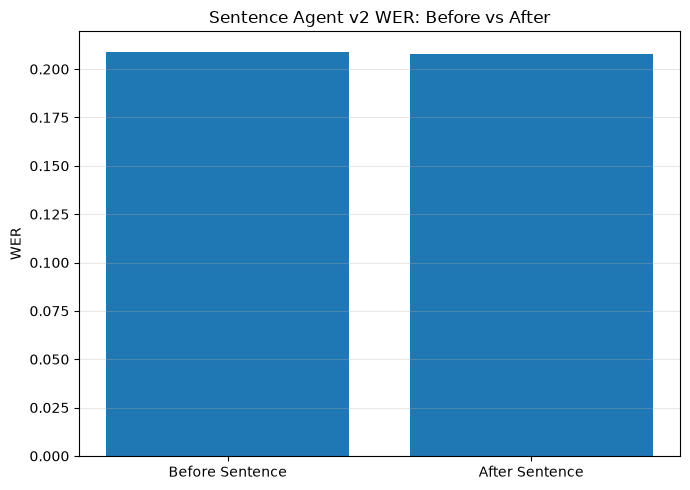

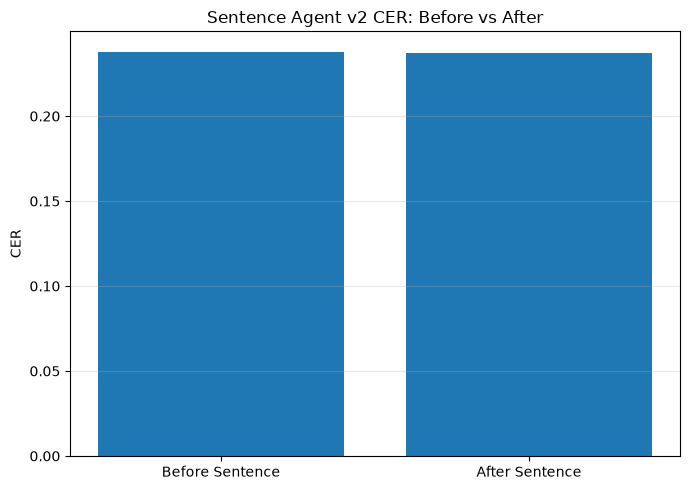

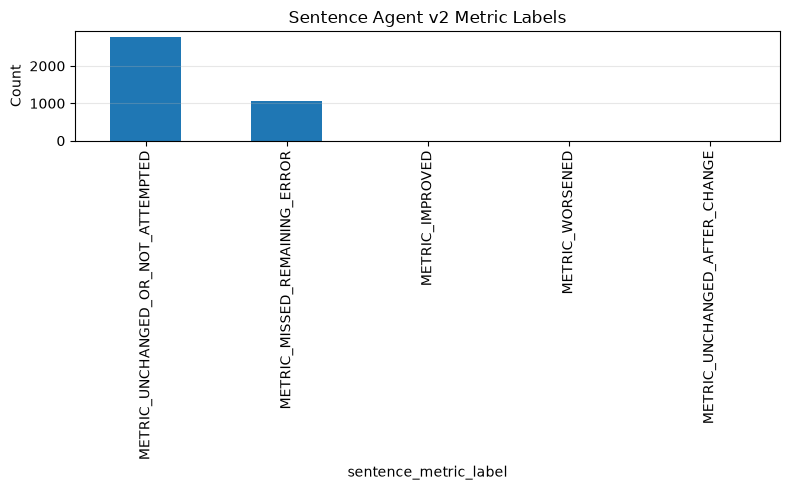

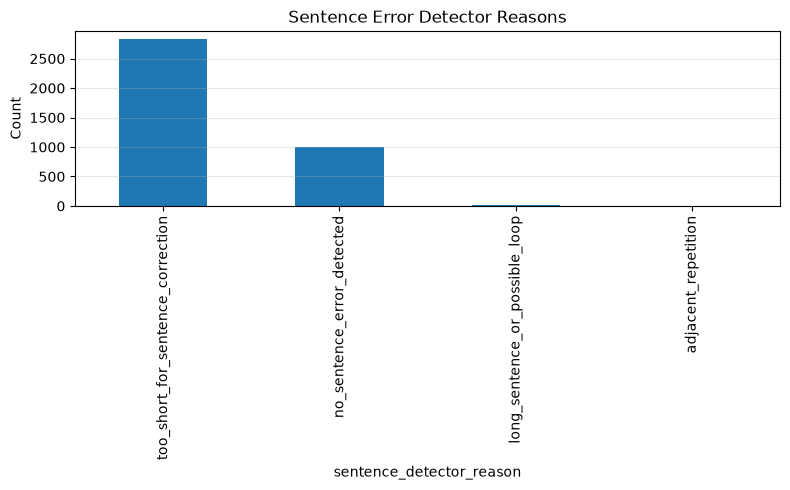

PHASE 8.11 - 8.17 SENTENCE AGENT v2 COMPLETED
Status: pending manual review
Output: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_11_sentence_agent_v2_predictions.csv
Manual examples: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_16_sentence_agent_v2_manual_examples.csv
Checkpoint: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_8_sentence_agent_v2_checkpoint.json
Before Sentence WER: 0.2090627188156447
After  Sentence WER: 0.20786235870761227
Before Sentence CER: 0.2379979570990807
After  Sentence CER: 0.23701579319556848
Before Sentence Accuracy: 0.7243439854507664
After  Sentence Accuracy: 0.723824369966225
Result: Sentence Agent v2 is metric-safe. Inspect manual examples before freezing.


In [41]:
# ============================================================
# PHASE 8.11 - 8.17
# SENTENCE CORRECTION AGENT v2 - FINAL FIXED VERSION
#
# Architecture:
#
# Selected Character + Word output
#        ↓
# Sentence Error Detector
#        ↓
# needs correction?
#    NO  → keep original
#    YES → local seq2seq grammar corrector
#        ↓
# Verification Agent
#        ↓
# ACCEPT / REJECT
#        ↓
# sentence_corrected
#
# Fix included:
# - use_safetensors=True to avoid torch.load security error
#
# Rules:
# - Sentence Agent sees only selected correction text.
# - ground_truth is used only for evaluation.
# - Test set is not used.
# - This is not OLM/LLM.
# - This is local seq2seq grammar-correction baseline.
# ============================================================

import os
import re
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ============================================================
# SECTION 1: PATHS
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

PRED_DIR = PROJECT_ROOT / "predictions"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
MODEL_DIR = PROJECT_ROOT / "models"

for p in [PRED_DIR, REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SELECTED_INPUT_CSV = PRED_DIR / "phase_8_selected_character_word_predictions.csv"

SENTENCE_OUTPUT_CSV = PRED_DIR / "phase_8_11_sentence_agent_v2_predictions.csv"
SENTENCE_METRICS_CSV = REPORT_DIR / "phase_8_15_sentence_agent_v2_metrics.csv"
SENTENCE_MANUAL_CSV = REPORT_DIR / "phase_8_16_sentence_agent_v2_manual_examples.csv"
SENTENCE_CONFIG_JSON = REPORT_DIR / "phase_8_17_sentence_agent_v2_candidate_config_pending_manual_review.json"
SENTENCE_CHECKPOINT_JSON = CHECKPOINT_DIR / "phase_8_sentence_agent_v2_checkpoint.json"

LOCAL_SENTENCE_MODEL_DIR = MODEL_DIR / "sentence_agent_t5_grammar_correction"

print("=" * 80)
print("PHASE 8.11 - 8.17: Sentence Correction Agent v2 FINAL")
print("Input:", SELECTED_INPUT_CSV)
print("=" * 80)

# ============================================================
# SECTION 2: HELPERS + METRICS
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def normalize_for_metrics(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_for_model(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())

def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    return int(dp[n, m])

try:
    from jiwer import wer as jiwer_wer
    from jiwer import cer as jiwer_cer
    JIWER_AVAILABLE = True
    print("Using jiwer for WER/CER.")
except Exception:
    JIWER_AVAILABLE = False
    print("jiwer not found. Using fallback WER/CER.")

def fallback_wer(references, predictions):
    total_edits = 0
    total_words = 0

    for r, p in zip(references, predictions):
        r_words = tokenize_words(r)
        p_words = tokenize_words(p)
        total_edits += edit_distance(r_words, p_words)
        total_words += len(r_words)

    return total_edits / max(1, total_words)

def fallback_cer(references, predictions):
    total_edits = 0
    total_chars = 0

    for r, p in zip(references, predictions):
        r_chars = list(normalize_for_metrics(r).replace(" ", ""))
        p_chars = list(normalize_for_metrics(p).replace(" ", ""))
        total_edits += edit_distance(r_chars, p_chars)
        total_chars += len(r_chars)

    return total_edits / max(1, total_chars)

def compute_wer(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_wer(references, predictions))

    return float(fallback_wer(references, predictions))

def compute_cer(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_cer(references, predictions))

    return float(fallback_cer(references, predictions))

def sentence_accuracy(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]
    return float(np.mean([r == p for r, p in zip(references, predictions)]))

def row_wer(reference, prediction):
    return fallback_wer([reference], [prediction])

def row_cer(reference, prediction):
    return fallback_cer([reference], [prediction])

def word_change_ratio(before, after):
    b = tokenize_words(before)
    a = tokenize_words(after)

    if len(b) == 0:
        return 0.0

    return edit_distance(b, a) / max(1, len(b))

# ============================================================
# SECTION 3: LOAD SELECTED CHARACTER + WORD OUTPUT
# ============================================================

if not SELECTED_INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Missing selected Character+Word output: {SELECTED_INPUT_CSV}\n"
        "Run final Character+Word pipeline selection first."
    )

df = pd.read_csv(SELECTED_INPUT_CSV)

if "ground_truth" not in df.columns:
    raise ValueError("Input CSV must contain ground_truth for evaluation only.")

if "final_corrected" in df.columns:
    input_col = "final_corrected"
elif "word_corrected" in df.columns:
    input_col = "word_corrected"
elif "character_corrected" in df.columns:
    input_col = "character_corrected"
else:
    raise ValueError("No valid input column found.")

df["sentence_agent_input"] = df[input_col].astype(str).apply(clean_for_model)

print("Rows:", len(df))
print("Sentence Agent input column:", input_col)
display(df.head())

# ============================================================
# SECTION 4: SENTENCE ERROR DETECTOR
# ============================================================

STOPWORDS = {
    "a", "an", "the", "to", "of", "and", "or", "in", "on", "for", "with",
    "at", "by", "from", "is", "am", "are", "was", "were", "be", "been",
    "being", "i", "you", "he", "she", "it", "we", "they", "me", "my",
    "your", "his", "her", "their", "our", "this", "that", "these", "those"
}

def sentence_error_detector(text):
    text_clean = clean_for_model(text)
    norm = normalize_for_metrics(text_clean)
    words = tokenize_words(norm)

    if len(words) == 0:
        return False, "empty"

    if len(words) <= 2:
        return False, "too_short_for_sentence_correction"

    if len(words) >= 15:
        return True, "long_sentence_or_possible_loop"

    for i in range(len(words) - 1):
        if words[i] == words[i + 1]:
            return True, "adjacent_repetition"

    for phrase_len in range(2, 5):
        for i in range(0, max(0, len(words) - 2 * phrase_len + 1)):
            if words[i:i+phrase_len] == words[i+phrase_len:i+2*phrase_len]:
                return True, "repeated_phrase"

    risky_patterns = [
        r"\bi go\b",
        r"\bhe go\b",
        r"\bshe go\b",
        r"\bit go\b",
        r"\bi is\b",
        r"\byou is\b",
        r"\bthey is\b",
        r"\bhe are\b",
        r"\bshe are\b",
        r"\bit are\b",
        r"\bwas are\b",
        r"\bare was\b",
        r"\bthe the\b",
        r"\ba a\b",
    ]

    for pat in risky_patterns:
        if re.search(pat, norm):
            return True, "grammar_risk_pattern"

    return False, "no_sentence_error_detected"

# ============================================================
# SECTION 5: LOAD SEQ2SEQ MODEL WITH SAFETENSORS FIX
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

REMOTE_MODEL_NAME = "vennify/t5-base-grammar-correction"
MODEL_NAME_FOR_REPORT = REMOTE_MODEL_NAME

MAX_INPUT_LENGTH = 128
MAX_NEW_TOKENS = 64
BATCH_SIZE = 8 if DEVICE == "cuda" else 2

print("=" * 80)
print("Loading local seq2seq grammar-correction baseline")
print("Device:", DEVICE)
print("=" * 80)

def load_sentence_seq2seq_model():
    if LOCAL_SENTENCE_MODEL_DIR.exists():
        try:
            print("Trying local model directory:")
            print(LOCAL_SENTENCE_MODEL_DIR)

            tok = AutoTokenizer.from_pretrained(str(LOCAL_SENTENCE_MODEL_DIR))
            mdl = AutoModelForSeq2SeqLM.from_pretrained(
                str(LOCAL_SENTENCE_MODEL_DIR),
                use_safetensors=True
            )

            return tok, mdl, "local_project_model_dir"

        except Exception as e:
            print("Local model load failed. Loading remote safetensors instead.")
            print("Local load error:", str(e)[:500])

    print("Loading from Hugging Face with safetensors:")
    print(REMOTE_MODEL_NAME)

    tok = AutoTokenizer.from_pretrained(REMOTE_MODEL_NAME)

    mdl = AutoModelForSeq2SeqLM.from_pretrained(
        REMOTE_MODEL_NAME,
        use_safetensors=True
    )

    print("Saving safetensors model locally:")
    print(LOCAL_SENTENCE_MODEL_DIR)

    LOCAL_SENTENCE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    tok.save_pretrained(str(LOCAL_SENTENCE_MODEL_DIR))
    mdl.save_pretrained(str(LOCAL_SENTENCE_MODEL_DIR), safe_serialization=True)

    return tok, mdl, "downloaded_safetensors_then_saved_locally"

tokenizer, model, MODEL_LOAD_SOURCE = load_sentence_seq2seq_model()

model.to(DEVICE)
model.eval()

print("=" * 80)
print("Sentence model loaded successfully")
print("Model source:", MODEL_LOAD_SOURCE)
print("=" * 80)

# ============================================================
# SECTION 6: CORRECTOR + VERIFIER
# ============================================================

def sentence_agent_prompt(text):
    return f"grammar: {clean_for_model(text)}"

def content_words(text):
    words = tokenize_words(text)
    return [w for w in words if len(w) > 3 and w not in STOPWORDS]

def content_preservation_score(before, after):
    before_content = content_words(before)
    after_words = tokenize_words(after)

    if len(before_content) == 0:
        return 1.0

    preserved = 0

    for w in before_content:
        if w in after_words:
            preserved += 1
        else:
            best_sim = 0.0
            for aw in after_words:
                best_sim = max(
                    best_sim,
                    1.0 - edit_distance(list(w), list(aw)) / max(len(w), len(aw), 1)
                )
            if best_sim >= 0.80:
                preserved += 1

    return preserved / max(1, len(before_content))

def extract_numbers(text):
    return re.findall(r"\d+", str(text))

def extract_entity_like_tokens(text):
    return re.findall(r"\b[A-Z][a-zA-Z]+\b", str(text))

def verification_agent(before, candidate):
    before_clean = clean_for_model(before)
    candidate_clean = clean_for_model(candidate)

    before_norm = normalize_for_metrics(before_clean)
    candidate_norm = normalize_for_metrics(candidate_clean)

    if candidate_norm == "":
        return False, "empty_output"

    if before_norm == candidate_norm:
        return True, "unchanged"

    before_words = tokenize_words(before_norm)
    candidate_words = tokenize_words(candidate_norm)

    if len(candidate_words) == 0:
        return False, "no_words"

    change_ratio = word_change_ratio(before_norm, candidate_norm)

    if change_ratio > 0.35:
        return False, "too_many_word_changes"

    if len(candidate_words) > max(len(before_words) + 4, int(len(before_words) * 1.45)):
        return False, "too_long"

    if len(candidate_words) < max(1, int(len(before_words) * 0.60)):
        return False, "too_short"

    if extract_numbers(before_clean) != extract_numbers(candidate_clean):
        return False, "number_changed"

    before_entities = extract_entity_like_tokens(before_clean)
    candidate_entities = extract_entity_like_tokens(candidate_clean)

    if before_entities and before_entities != candidate_entities:
        return False, "entity_like_token_changed"

    preservation = content_preservation_score(before_norm, candidate_norm)

    if preservation < 0.70:
        return False, "content_words_not_preserved"

    return True, "accepted_by_verifier"

def run_seq2seq_corrector(texts):
    outputs = []
    prompts = [sentence_agent_prompt(x) for x in texts]

    for start in tqdm(range(0, len(prompts), BATCH_SIZE), desc="Seq2Seq Corrector"):
        batch_prompts = prompts[start:start + BATCH_SIZE]

        encoded = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LENGTH,
        ).to(DEVICE)

        with torch.no_grad():
            generated = model.generate(
                **encoded,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=4,
                do_sample=False,
                early_stopping=True,
            )

        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        decoded = [clean_for_model(x) for x in decoded]
        outputs.extend(decoded)

    return outputs

# ============================================================
# SECTION 7: RUN DETECTOR -> CORRECTOR -> VERIFIER
# ============================================================

start_time = time.time()

inputs = df["sentence_agent_input"].astype(str).tolist()

detector_flags = []
detector_reasons = []

for text in inputs:
    flag, reason = sentence_error_detector(text)
    detector_flags.append(flag)
    detector_reasons.append(reason)

to_correct_indices = [i for i, flag in enumerate(detector_flags) if flag]
to_correct_texts = [inputs[i] for i in to_correct_indices]

print("=" * 80)
print("Sentence Error Detector")
print("Total samples:", len(inputs))
print("Needs correction:", len(to_correct_indices))
print("Kept without model:", len(inputs) - len(to_correct_indices))
print("=" * 80)

raw_model_outputs = [""] * len(inputs)

if len(to_correct_texts) > 0:
    corrected_subset = run_seq2seq_corrector(to_correct_texts)

    for idx, output in zip(to_correct_indices, corrected_subset):
        raw_model_outputs[idx] = output

sentence_outputs = []
verifier_reasons = []

for i, before in enumerate(inputs):
    if not detector_flags[i]:
        sentence_outputs.append(clean_for_model(before))
        verifier_reasons.append("not_sent_to_corrector_" + detector_reasons[i])
        continue

    candidate = raw_model_outputs[i]
    ok, reason = verification_agent(before, candidate)

    if ok:
        sentence_outputs.append(clean_for_model(candidate))
        verifier_reasons.append(reason)
    else:
        sentence_outputs.append(clean_for_model(before))
        verifier_reasons.append("rejected_" + reason)

runtime = time.time() - start_time

result_df = df.copy()
result_df["sentence_agent_input"] = inputs
result_df["sentence_detector_needs_correction"] = detector_flags
result_df["sentence_detector_reason"] = detector_reasons
result_df["sentence_raw_output"] = raw_model_outputs
result_df["sentence_corrected"] = sentence_outputs
result_df["sentence_verifier_reason"] = verifier_reasons
result_df["changed_by_sentence_agent"] = (
    result_df["sentence_agent_input"].astype(str).apply(normalize_for_metrics)
    != result_df["sentence_corrected"].astype(str).apply(normalize_for_metrics)
)

# ============================================================
# SECTION 8: EVALUATION
# ============================================================

refs = result_df["ground_truth"].astype(str).tolist()
before = result_df["sentence_agent_input"].astype(str).tolist()
after = result_df["sentence_corrected"].astype(str).tolist()

before_wer = compute_wer(refs, before)
after_wer = compute_wer(refs, after)

before_cer = compute_cer(refs, before)
after_cer = compute_cer(refs, after)

before_sent_acc = sentence_accuracy(refs, before)
after_sent_acc = sentence_accuracy(refs, after)

result_df["wer_before_sentence"] = [row_wer(r, p) for r, p in zip(refs, before)]
result_df["wer_after_sentence"] = [row_wer(r, p) for r, p in zip(refs, after)]
result_df["cer_before_sentence"] = [row_cer(r, p) for r, p in zip(refs, before)]
result_df["cer_after_sentence"] = [row_cer(r, p) for r, p in zip(refs, after)]

result_df["sentence_metric_label"] = "METRIC_UNCHANGED_OR_NOT_ATTEMPTED"

result_df.loc[
    result_df["changed_by_sentence_agent"] &
    (result_df["wer_after_sentence"] < result_df["wer_before_sentence"]),
    "sentence_metric_label"
] = "METRIC_IMPROVED"

result_df.loc[
    result_df["changed_by_sentence_agent"] &
    (result_df["wer_after_sentence"] == result_df["wer_before_sentence"]),
    "sentence_metric_label"
] = "METRIC_UNCHANGED_AFTER_CHANGE"

result_df.loc[
    result_df["changed_by_sentence_agent"] &
    (result_df["wer_after_sentence"] > result_df["wer_before_sentence"]),
    "sentence_metric_label"
] = "METRIC_WORSENED"

result_df.loc[
    (~result_df["changed_by_sentence_agent"]) &
    (
        result_df["sentence_agent_input"].astype(str).apply(normalize_for_metrics)
        != result_df["ground_truth"].astype(str).apply(normalize_for_metrics)
    ),
    "sentence_metric_label"
] = "METRIC_MISSED_REMAINING_ERROR"

summary = result_df["sentence_metric_label"].value_counts().to_dict()

changed_count = (
    int(summary.get("METRIC_IMPROVED", 0)) +
    int(summary.get("METRIC_WORSENED", 0)) +
    int(summary.get("METRIC_UNCHANGED_AFTER_CHANGE", 0))
)

metrics = {
    "before_wer": float(before_wer),
    "after_wer": float(after_wer),
    "before_cer": float(before_cer),
    "after_cer": float(after_cer),
    "before_sentence_accuracy": float(before_sent_acc),
    "after_sentence_accuracy": float(after_sent_acc),
    "wer_delta": float(after_wer - before_wer),
    "cer_delta": float(after_cer - before_cer),
    "sentence_accuracy_delta": float(after_sent_acc - before_sent_acc),
    "total_samples": int(len(result_df)),
    "detector_sent_to_corrector": int(sum(detector_flags)),
    "detector_kept_without_model": int(len(result_df) - sum(detector_flags)),
    "total_changed_after_verification": int(result_df["changed_by_sentence_agent"].sum()),
    "metric_improved_count": int(summary.get("METRIC_IMPROVED", 0)),
    "metric_worsened_count": int(summary.get("METRIC_WORSENED", 0)),
    "metric_unchanged_after_change_count": int(summary.get("METRIC_UNCHANGED_AFTER_CHANGE", 0)),
    "metric_missed_remaining_error_count": int(summary.get("METRIC_MISSED_REMAINING_ERROR", 0)),
    "metric_unchanged_or_not_attempted_count": int(summary.get("METRIC_UNCHANGED_OR_NOT_ATTEMPTED", 0)),
    "metric_improvement_rate": float(
        summary.get("METRIC_IMPROVED", 0) / changed_count
        if changed_count > 0 else 0.0
    ),
    "runtime_seconds": float(runtime),
    "seconds_per_sample": float(runtime / max(1, len(result_df))),
}

result_df.to_csv(SENTENCE_OUTPUT_CSV, index=False)

metrics_df = pd.DataFrame([
    {
        "Metric": "WER",
        "Before Sentence Agent": before_wer,
        "After Sentence Agent": after_wer,
        "Delta": after_wer - before_wer,
    },
    {
        "Metric": "CER",
        "Before Sentence Agent": before_cer,
        "After Sentence Agent": after_cer,
        "Delta": after_cer - before_cer,
    },
    {
        "Metric": "Sentence Accuracy",
        "Before Sentence Agent": before_sent_acc,
        "After Sentence Agent": after_sent_acc,
        "Delta": after_sent_acc - before_sent_acc,
    },
])

metrics_df.to_csv(SENTENCE_METRICS_CSV, index=False)

print("=" * 80)
print("SENTENCE AGENT v2 FINAL RESULTS")
print("=" * 80)
display(metrics_df)

print(json.dumps(metrics, indent=2))

# ============================================================
# SECTION 9: MANUAL REVIEW EXAMPLES
# ============================================================

manual_parts = []

improved_df = result_df[result_df["sentence_metric_label"] == "METRIC_IMPROVED"].copy()
worsened_df = result_df[result_df["sentence_metric_label"] == "METRIC_WORSENED"].copy()
missed_df = result_df[result_df["sentence_metric_label"] == "METRIC_MISSED_REMAINING_ERROR"].copy()
changed_same_df = result_df[result_df["sentence_metric_label"] == "METRIC_UNCHANGED_AFTER_CHANGE"].copy()
rejected_df = result_df[result_df["sentence_verifier_reason"].astype(str).str.startswith("rejected_")].copy()

if len(improved_df) > 0:
    manual_parts.append(improved_df.sort_values("wer_before_sentence", ascending=False).head(15))

if len(worsened_df) > 0:
    manual_parts.append(worsened_df.sort_values("wer_after_sentence", ascending=False).head(15))

if len(rejected_df) > 0:
    manual_parts.append(rejected_df.head(15))

if len(missed_df) > 0:
    manual_parts.append(missed_df.sort_values("wer_before_sentence", ascending=False).head(15))

if len(changed_same_df) > 0:
    manual_parts.append(changed_same_df.head(10))

if len(manual_parts) > 0:
    manual_df = pd.concat(manual_parts, ignore_index=True)
    manual_df = manual_df.drop_duplicates(subset=["sample_id"]).head(70)
else:
    manual_df = result_df.head(70).copy()

manual_cols = [
    "sample_id",
    "ground_truth",
    "whisper_raw",
    "character_corrected",
    "word_corrected",
    "sentence_agent_input",
    "sentence_detector_needs_correction",
    "sentence_detector_reason",
    "sentence_raw_output",
    "sentence_corrected",
    "sentence_verifier_reason",
    "sentence_metric_label",
    "wer_before_sentence",
    "wer_after_sentence",
    "cer_before_sentence",
    "cer_after_sentence",
]

extra_cols = [c for c in ["speaker", "condition", "gender", "session"] if c in manual_df.columns]
manual_df = manual_df[extra_cols + [c for c in manual_cols if c in manual_df.columns]]

manual_df.to_csv(SENTENCE_MANUAL_CSV, index=False)

print("=" * 80)
print("Sentence Agent manual examples saved")
print(SENTENCE_MANUAL_CSV)
print("=" * 80)
display(manual_df)

# ============================================================
# SECTION 10: FIGURES
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(["Before Sentence", "After Sentence"], [before_wer, after_wer])
plt.ylabel("WER")
plt.title("Sentence Agent v2 WER: Before vs After")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
wer_fig = FIGURE_DIR / "phase_8_sentence_agent_v2_wer.png"
plt.savefig(wer_fig, dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(["Before Sentence", "After Sentence"], [before_cer, after_cer])
plt.ylabel("CER")
plt.title("Sentence Agent v2 CER: Before vs After")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
cer_fig = FIGURE_DIR / "phase_8_sentence_agent_v2_cer.png"
plt.savefig(cer_fig, dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
result_df["sentence_metric_label"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Sentence Agent v2 Metric Labels")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
label_fig = FIGURE_DIR / "phase_8_sentence_agent_v2_metric_labels.png"
plt.savefig(label_fig, dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
result_df["sentence_detector_reason"].value_counts().head(10).plot(kind="bar")
plt.ylabel("Count")
plt.title("Sentence Error Detector Reasons")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
detector_fig = FIGURE_DIR / "phase_8_sentence_agent_v2_detector_reasons.png"
plt.savefig(detector_fig, dpi=200)
plt.show()

# ============================================================
# SECTION 11: SAVE CONFIG
# ============================================================

config = {
    "phase": "Phase 8.11 - 8.17 Sentence Correction Agent v2",
    "status": "completed_pending_manual_review",
    "architecture": "Sentence Error Detector -> Local Seq2Seq Corrector -> Verification Agent",
    "input_csv": str(SELECTED_INPUT_CSV),
    "input_column": input_col,
    "output_csv": str(SENTENCE_OUTPUT_CSV),
    "model_name": MODEL_NAME_FOR_REPORT,
    "model_type": "local_seq2seq_grammar_correction_baseline",
    "model_load_source": MODEL_LOAD_SOURCE,
    "local_model_dir": str(LOCAL_SENTENCE_MODEL_DIR),
    "device": DEVICE,
    "uses_llm_or_olm": False,
    "ground_truth_visible_to_agent": False,
    "test_set_used": False,
    "detector_policy": {
        "skip_short_utterances": True,
        "detect_long_possible_loops": True,
        "detect_repetition": True,
        "detect_basic_grammar_risk_patterns": True,
    },
    "verification_policy": {
        "max_word_change_ratio": 0.35,
        "reject_empty": True,
        "reject_too_long": True,
        "reject_too_short": True,
        "protect_numbers": True,
        "protect_visible_capitalized_entity_like_tokens": True,
        "minimum_content_preservation_score": 0.70,
    },
    "metric_label_note": "metric_improvement_rate is not semantic precision. Manual review is required.",
    "metrics": metrics,
    "outputs": {
        "metrics_csv": str(SENTENCE_METRICS_CSV),
        "manual_examples_csv": str(SENTENCE_MANUAL_CSV),
    },
    "figures": {
        "wer": str(wer_fig),
        "cer": str(cer_fig),
        "metric_labels": str(label_fig),
        "detector_reasons": str(detector_fig),
    },
    "next_step": "Manual inspection, then separate OLM/LLM Sentence Agent or final Verification phase.",
}

save_json(config, SENTENCE_CONFIG_JSON)
save_json(config, SENTENCE_CHECKPOINT_JSON)

print("=" * 80)
print("PHASE 8.11 - 8.17 SENTENCE AGENT v2 COMPLETED")
print("Status: pending manual review")
print("Output:", SENTENCE_OUTPUT_CSV)
print("Manual examples:", SENTENCE_MANUAL_CSV)
print("Checkpoint:", SENTENCE_CHECKPOINT_JSON)
print("=" * 80)

print("Before Sentence WER:", before_wer)
print("After  Sentence WER:", after_wer)
print("Before Sentence CER:", before_cer)
print("After  Sentence CER:", after_cer)
print("Before Sentence Accuracy:", before_sent_acc)
print("After  Sentence Accuracy:", after_sent_acc)

if after_wer <= before_wer and after_cer <= before_cer:
    print("Result: Sentence Agent v2 is metric-safe. Inspect manual examples before freezing.")
else:
    print("Result: Sentence Agent v2 worsened WER or CER. Do not freeze. Inspect manual examples.")

PHASE 8.18 - 8.20: Final Verification Agent
Selected input: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_selected_character_word_predictions.csv
Using jiwer for WER/CER.
Rows: 3849
Selected correction column: final_corrected


,sample_id,audio_path,ground_truth,whisper_raw,speaker,condition,gender,session,character_corrected,changed_by_character_agent,...,word_agent_input,word_corrected,changed_by_word_agent,wer_before_word,wer_after_word,cer_before_word,cer_after_word,word_metric_label,final_corrected,pre_verification_corrected
0,torgo_004572,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,born,born,FC03,control,female,Session1,born,False,...,born,born,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,born,born
1,torgo_004573,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,tear,tear,FC03,control,female,Session1,tear,False,...,tear,tear,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,tear,tear
2,torgo_004574,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,no,no,FC03,control,female,Session1,no,False,...,no,no,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,no,no
3,torgo_004575,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,train,train,FC03,control,female,Session1,train,False,...,train,train,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,train,train
4,torgo_004576,E:\AI_Project\TORGO_DATASET\FC\FC03\Session1\w...,rain,rain,FC03,control,female,Session1,rain,False,...,rain,rain,False,0.0,0.0,0.0,0.0,METRIC_UNCHANGED_OR_NOT_ATTEMPTED,rain,rain


FINAL PIPELINE COMPARISON


,System,Column,WER,CER,Sentence Accuracy,Samples
0,Final Verified Agentic,final_agentic_corrected,0.205862,0.234462,0.724344,3849
1,Character + Word,word_corrected,0.209063,0.237998,0.724344,3849
2,Selected Pre-Verification,pre_verification_corrected,0.209063,0.237998,0.724344,3849
3,Character Agent,character_corrected,0.325398,0.339888,0.724344,3849
4,Whisper Raw,whisper_raw,0.325998,0.340006,0.723305,3849


FINAL VERIFIED METRICS
{
  "status": "completed_frozen_validation_pipeline",
  "selected_pipeline": "Character v4 + Word v3 + Final Verification",
  "sentence_agent_v2_used": false,
  "sentence_agent_v2_reason": "Manual inspection showed missed repeated hallucination patterns and slight sentence accuracy drop.",
  "test_set_used": false,
  "samples": 3849,
  "final_metrics": {
    "wer": 0.20586175852755828,
    "cer": 0.23446216704643671,
    "sentence_accuracy": 0.7243439854507664
  },
  "comparison_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_8_20_final_pipeline_comparison.csv",
  "final_output_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\predictions\\phase_8_20_final_agentic_validation_predictions.csv"
}
Final manual review examples saved
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_20_final_manual_review_examples.csv


,speaker,condition,gender,session,sample_id,ground_truth,whisper_raw,character_corrected,word_corrected,pre_verification_corrected,final_agentic_corrected,final_verification_reason,final_metric_label,wer_before_final,wer_after_final,cer_before_final,cer_after_final
0,FC03,control,female,Session2,torgo_005723,we just don't,we just don't act like we're friends anymore w...,we just don't act like we're friends anymore w...,we just don't act like we're friends anymore w...,we just don't act like we're friends anymore w...,we just don't act like we're friends anymore w...,repeated_phrases_collapsed,METRIC_IMPROVED,14.666667,4.0,18.545455,5.090909
1,FC03,control,female,Session1,torgo_004603,the,their story begins with a short story about th...,their story begins with a short story about th...,their story begins with a short story about th...,their story begins with a short story about th...,their story begins with a short story about th...,unchanged,METRIC_MISSED_REMAINING_ERROR,15.000000,15.0,19.333333,19.333333
2,FC03,control,female,Session1,torgo_004861,xxx,day after day some new ex ex experimentalism i...,day after day some new ex ex experimentalism i...,day after day some new ex ex experimentalism i...,day after day some new ex ex experimentalism i...,day after day some new ex ex experimentalism i...,unchanged,METRIC_MISSED_REMAINING_ERROR,14.000000,14.0,18.000000,18.000000
3,FC03,control,female,Session1,torgo_005293,xxx,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,unchanged,METRIC_MISSED_REMAINING_ERROR,9.000000,9.0,17.000000,17.000000
4,FC03,control,female,Session1,torgo_004901,xxx,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,he further proposed grants of unspecified sums...,unchanged,METRIC_MISSED_REMAINING_ERROR,9.000000,9.0,17.666667,17.666667
5,M01,dysarthric,male,Session1,torgo_006616,spark,sparkle getting ready to go to bed,sparkle getting ready to go to bed,sparkle getting ready to go to bed,sparkle getting ready to go to bed,sparkle getting ready to go to bed,unchanged,METRIC_MISSED_REMAINING_ERROR,7.000000,7.0,4.600000,4.600000
6,FC03,control,female,Session1,torgo_005253,xxx,day after day some new expat xxxxxxxxxxxxxxxxx...,day after day some new expat xxxxxxxxxxxxxxxxx...,day after day some new expat xxxxxxxxxxxxxxxxx...,day after day some new expat xxxxxxxxxxxxxxxxx...,day after day some new expat xxxxxxxxxxxxxxxxx...,unchanged,METRIC_MISSED_REMAINING_ERROR,7.000000,7.0,42.333333,42.333333
7,FC03,control,female,Session1,torgo_005294,xxx,prepare for the next step,prepare for the next step,prepare for the next step,prepare for the next step,prepare for the next step,unchanged,METRIC_MISSED_REMAINING_ERROR,5.000000,5.0,6.666667,6.666667
8,FC03,control,female,Session1,torgo_005195,xxx,how do you pronounce that,how do you pronounce that,how do you pronounce that,how do you pronounce that,how do you pronounce that,unchanged,METRIC_MISSED_REMAINING_ERROR,5.000000,5.0,7.000000,7.000000
9,M01,dysarthric,male,Session2_3,torgo_006992,witty,reveal yourself to the truth,reveal yourself to the truth,reveal yourself to the truth,reveal yourself to the truth,reveal yourself to the truth,unchanged,METRIC_MISSED_REMAINING_ERROR,5.000000,5.0,4.400000,4.400000


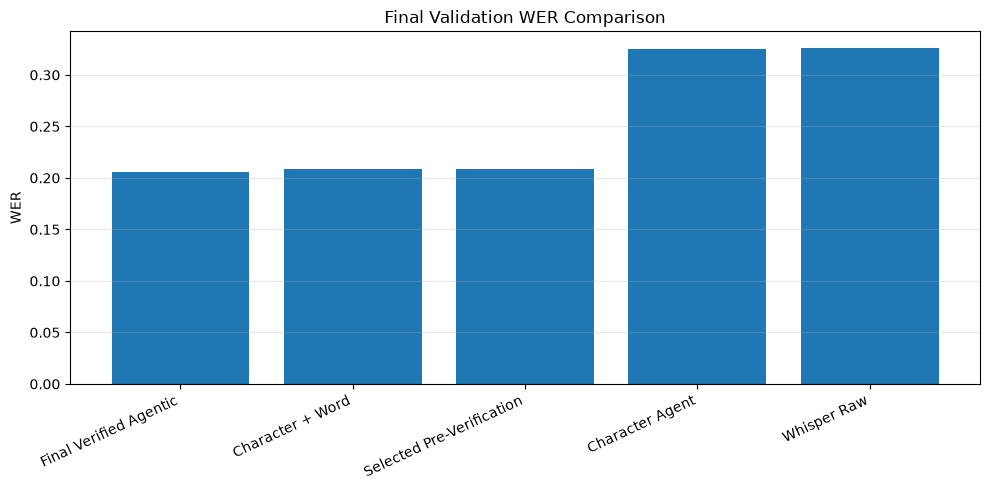

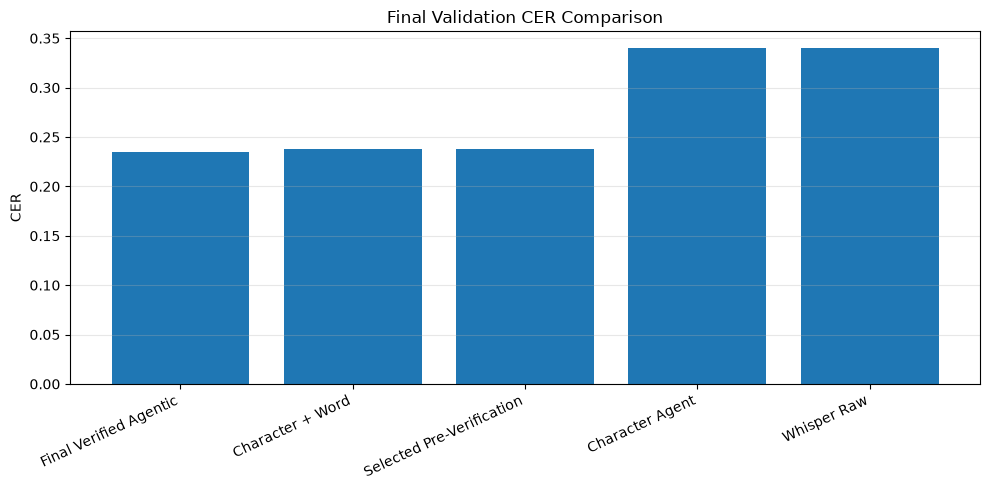

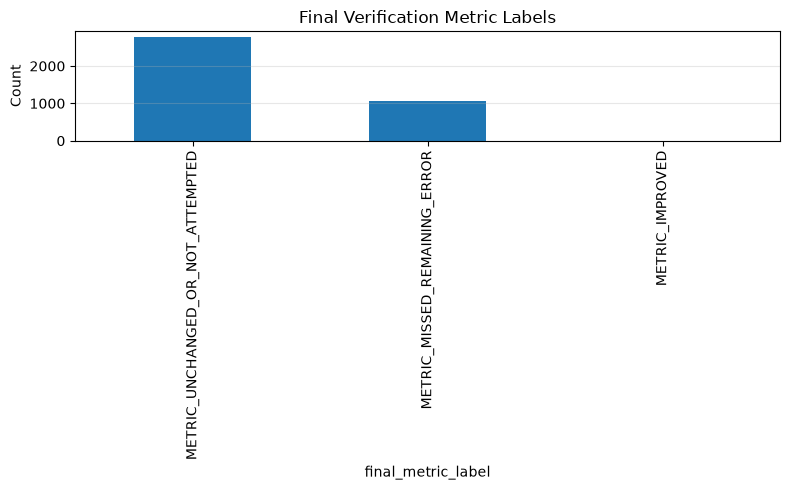

FINAL VALIDATION PIPELINE FROZEN
Config: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_8_20_final_frozen_pipeline_config.json
Checkpoint: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_8_final_agentic_pipeline_checkpoint.json
Final output: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_20_final_agentic_validation_predictions.csv
NEXT:
Run Phase 9 ablation table on validation, then run final frozen pipeline on TEST.


In [42]:
# ============================================================
# PHASE 8.18 - 8.20
# FINAL VERIFICATION AGENT + FINAL PIPELINE FREEZE
#
# Decision from manual review:
# - Sentence Agent v2 is NOT frozen.
# - Best current pipeline = Character v4 + Word v3.
#
# Input:
#   phase_8_selected_character_word_predictions.csv
#
# Output:
#   final_agentic_corrected
#
# Important:
# - No test set used.
# - ground_truth used only for evaluation.
# - Verification is deterministic.
# ============================================================

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# SECTION 1: PATHS
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

PRED_DIR = PROJECT_ROOT / "predictions"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for p in [PRED_DIR, REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SELECTED_CW_INPUT_CSV = PRED_DIR / "phase_8_selected_character_word_predictions.csv"
SENTENCE_V2_CSV = PRED_DIR / "phase_8_11_sentence_agent_v2_predictions.csv"

FINAL_OUTPUT_CSV = PRED_DIR / "phase_8_20_final_agentic_validation_predictions.csv"
FINAL_METRICS_CSV = REPORT_DIR / "phase_8_20_final_agentic_validation_metrics.csv"
FINAL_COMPARISON_CSV = REPORT_DIR / "phase_8_20_final_pipeline_comparison.csv"
FINAL_MANUAL_CSV = REPORT_DIR / "phase_8_20_final_manual_review_examples.csv"
FINAL_CONFIG_JSON = REPORT_DIR / "phase_8_20_final_frozen_pipeline_config.json"
FINAL_CHECKPOINT_JSON = CHECKPOINT_DIR / "phase_8_final_agentic_pipeline_checkpoint.json"

print("=" * 80)
print("PHASE 8.18 - 8.20: Final Verification Agent")
print("Selected input:", SELECTED_CW_INPUT_CSV)
print("=" * 80)

# ============================================================
# SECTION 2: HELPERS + METRICS
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def normalize_for_metrics(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())

def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    return int(dp[n, m])

try:
    from jiwer import wer as jiwer_wer
    from jiwer import cer as jiwer_cer
    JIWER_AVAILABLE = True
    print("Using jiwer for WER/CER.")
except Exception:
    JIWER_AVAILABLE = False
    print("jiwer not found. Using fallback WER/CER.")

def fallback_wer(references, predictions):
    total_edits = 0
    total_words = 0

    for r, p in zip(references, predictions):
        r_words = tokenize_words(r)
        p_words = tokenize_words(p)
        total_edits += edit_distance(r_words, p_words)
        total_words += len(r_words)

    return total_edits / max(1, total_words)

def fallback_cer(references, predictions):
    total_edits = 0
    total_chars = 0

    for r, p in zip(references, predictions):
        r_chars = list(normalize_for_metrics(r).replace(" ", ""))
        p_chars = list(normalize_for_metrics(p).replace(" ", ""))
        total_edits += edit_distance(r_chars, p_chars)
        total_chars += len(r_chars)

    return total_edits / max(1, total_chars)

def compute_wer(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_wer(references, predictions))

    return float(fallback_wer(references, predictions))

def compute_cer(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_cer(references, predictions))

    return float(fallback_cer(references, predictions))

def sentence_accuracy(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]
    return float(np.mean([r == p for r, p in zip(references, predictions)]))

def row_wer(reference, prediction):
    return fallback_wer([reference], [prediction])

def row_cer(reference, prediction):
    return fallback_cer([reference], [prediction])

# ============================================================
# SECTION 3: LOAD SELECTED CHARACTER + WORD PIPELINE
# ============================================================

if not SELECTED_CW_INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Missing selected Character+Word file: {SELECTED_CW_INPUT_CSV}"
    )

df = pd.read_csv(SELECTED_CW_INPUT_CSV)

if "ground_truth" not in df.columns:
    raise ValueError("Input must contain ground_truth for evaluation only.")

if "final_corrected" in df.columns:
    selected_col = "final_corrected"
elif "word_corrected" in df.columns:
    selected_col = "word_corrected"
elif "character_corrected" in df.columns:
    selected_col = "character_corrected"
else:
    raise ValueError("No selected correction column found.")

df["pre_verification_corrected"] = df[selected_col].astype(str).apply(normalize_for_metrics)

print("Rows:", len(df))
print("Selected correction column:", selected_col)
display(df.head())

# ============================================================
# SECTION 4: DETERMINISTIC FINAL VERIFICATION
# ============================================================

ARTIFACT_TOKENS = {"jpg", "jpeg", "png"}
ARTIFACT_PHRASES = [
    ["input", "images", "story", "starters"],
]

def remove_known_artifacts(text):
    words = tokenize_words(text)
    out = []
    i = 0
    changed = False

    while i < len(words):
        removed_phrase = False

        for phrase in ARTIFACT_PHRASES:
            n = len(phrase)
            if words[i:i+n] == phrase:
                changed = True
                i += n
                removed_phrase = True
                break

        if removed_phrase:
            continue

        if words[i] in ARTIFACT_TOKENS:
            changed = True
            i += 1
            continue

        out.append(words[i])
        i += 1

    return " ".join(out), changed

def collapse_repeated_words(text, min_repeat=3, keep=1):
    words = tokenize_words(text)
    out = []
    changed = False

    i = 0
    while i < len(words):
        tok = words[i]
        j = i + 1

        while j < len(words) and words[j] == tok:
            j += 1

        repeat_count = j - i

        if repeat_count >= min_repeat:
            out.extend([tok] * keep)
            changed = True
        else:
            out.extend([tok] * repeat_count)

        i = j

    return " ".join(out), changed

def collapse_repeated_phrases(text, max_phrase_len=8):
    words = tokenize_words(text)
    changed_any = False
    changed = True

    while changed:
        changed = False

        for phrase_len in range(max_phrase_len, 1, -1):
            i = 0
            new_words = []

            while i < len(words):
                phrase = words[i:i+phrase_len]
                next_phrase = words[i+phrase_len:i+(2*phrase_len)]

                if len(phrase) == phrase_len and phrase == next_phrase:
                    j = i + (2 * phrase_len)

                    while words[j:j+phrase_len] == phrase:
                        j += phrase_len

                    new_words.extend(phrase)
                    i = j
                    changed = True
                    changed_any = True
                else:
                    new_words.append(words[i])
                    i += 1

            words = new_words

    return " ".join(words), changed_any

def final_verification_agent(text):
    original = normalize_for_metrics(text)
    current = original
    operations = []

    cleaned, changed = remove_known_artifacts(current)
    if changed:
        operations.append("known_artifacts_removed")
        current = cleaned

    cleaned, changed = collapse_repeated_phrases(current, max_phrase_len=8)
    if changed:
        operations.append("repeated_phrases_collapsed")
        current = cleaned

    cleaned, changed = collapse_repeated_words(current, min_repeat=3, keep=1)
    if changed:
        operations.append("repeated_words_collapsed")
        current = cleaned

    # If verification accidentally empties text, reject cleanup.
    if current.strip() == "":
        return original, "rejected_empty_after_verification"

    if current == original:
        return original, "unchanged"

    return current, "+".join(operations)

final_outputs = []
verification_reasons = []

for text in df["pre_verification_corrected"].tolist():
    final_text, reason = final_verification_agent(text)
    final_outputs.append(final_text)
    verification_reasons.append(reason)

df["final_agentic_corrected"] = final_outputs
df["final_verification_reason"] = verification_reasons
df["changed_by_final_verification"] = (
    df["pre_verification_corrected"] != df["final_agentic_corrected"]
)

# ============================================================
# SECTION 5: EVALUATION
# ============================================================

refs = df["ground_truth"].astype(str).tolist()

systems = []

if "whisper_raw" in df.columns:
    systems.append(("Whisper Raw", "whisper_raw"))

if "character_corrected" in df.columns:
    systems.append(("Character Agent", "character_corrected"))

if "word_corrected" in df.columns:
    systems.append(("Character + Word", "word_corrected"))

systems.append(("Selected Pre-Verification", "pre_verification_corrected"))
systems.append(("Final Verified Agentic", "final_agentic_corrected"))

rows = []

for system_name, col in systems:
    preds = df[col].astype(str).tolist()

    rows.append({
        "System": system_name,
        "Column": col,
        "WER": compute_wer(refs, preds),
        "CER": compute_cer(refs, preds),
        "Sentence Accuracy": sentence_accuracy(refs, preds),
        "Samples": int(len(df)),
    })

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values(
    ["WER", "CER", "Sentence Accuracy"],
    ascending=[True, True, False]
).reset_index(drop=True)

comparison_df.to_csv(FINAL_COMPARISON_CSV, index=False)

final_metrics = comparison_df[
    comparison_df["System"] == "Final Verified Agentic"
].iloc[0].to_dict()

df["wer_before_final"] = [
    row_wer(r, p)
    for r, p in zip(refs, df["pre_verification_corrected"].astype(str).tolist())
]

df["wer_after_final"] = [
    row_wer(r, p)
    for r, p in zip(refs, df["final_agentic_corrected"].astype(str).tolist())
]

df["cer_before_final"] = [
    row_cer(r, p)
    for r, p in zip(refs, df["pre_verification_corrected"].astype(str).tolist())
]

df["cer_after_final"] = [
    row_cer(r, p)
    for r, p in zip(refs, df["final_agentic_corrected"].astype(str).tolist())
]

df["final_metric_label"] = "METRIC_UNCHANGED_OR_NOT_ATTEMPTED"

df.loc[
    df["changed_by_final_verification"] &
    (df["wer_after_final"] < df["wer_before_final"]),
    "final_metric_label"
] = "METRIC_IMPROVED"

df.loc[
    df["changed_by_final_verification"] &
    (df["wer_after_final"] == df["wer_before_final"]),
    "final_metric_label"
] = "METRIC_UNCHANGED_AFTER_CHANGE"

df.loc[
    df["changed_by_final_verification"] &
    (df["wer_after_final"] > df["wer_before_final"]),
    "final_metric_label"
] = "METRIC_WORSENED"

df.loc[
    (~df["changed_by_final_verification"]) &
    (df["pre_verification_corrected"] != df["ground_truth"].astype(str).apply(normalize_for_metrics)),
    "final_metric_label"
] = "METRIC_MISSED_REMAINING_ERROR"

df.to_csv(FINAL_OUTPUT_CSV, index=False)

metrics_summary = {
    "status": "completed_frozen_validation_pipeline",
    "selected_pipeline": "Character v4 + Word v3 + Final Verification",
    "sentence_agent_v2_used": False,
    "sentence_agent_v2_reason": "Manual inspection showed missed repeated hallucination patterns and slight sentence accuracy drop.",
    "test_set_used": False,
    "samples": int(len(df)),
    "final_metrics": {
        "wer": float(final_metrics["WER"]),
        "cer": float(final_metrics["CER"]),
        "sentence_accuracy": float(final_metrics["Sentence Accuracy"]),
    },
    "comparison_csv": str(FINAL_COMPARISON_CSV),
    "final_output_csv": str(FINAL_OUTPUT_CSV),
}

pd.DataFrame([metrics_summary["final_metrics"]]).to_csv(FINAL_METRICS_CSV, index=False)

print("=" * 80)
print("FINAL PIPELINE COMPARISON")
print("=" * 80)
display(comparison_df)

print("=" * 80)
print("FINAL VERIFIED METRICS")
print("=" * 80)
print(json.dumps(metrics_summary, indent=2))

# ============================================================
# SECTION 6: MANUAL REVIEW SAMPLE
# ============================================================

manual_parts = []

improved_df = df[df["final_metric_label"] == "METRIC_IMPROVED"].copy()
worsened_df = df[df["final_metric_label"] == "METRIC_WORSENED"].copy()
missed_df = df[df["final_metric_label"] == "METRIC_MISSED_REMAINING_ERROR"].copy()

if len(improved_df) > 0:
    manual_parts.append(improved_df.sort_values("wer_before_final", ascending=False).head(20))

if len(worsened_df) > 0:
    manual_parts.append(worsened_df.sort_values("wer_after_final", ascending=False).head(15))

if len(missed_df) > 0:
    manual_parts.append(missed_df.sort_values("wer_before_final", ascending=False).head(20))

if len(manual_parts) > 0:
    manual_df = pd.concat(manual_parts, ignore_index=True)
    manual_df = manual_df.drop_duplicates(subset=["sample_id"]).head(70)
else:
    manual_df = df.head(70).copy()

manual_cols = [
    "sample_id",
    "ground_truth",
    "whisper_raw",
    "character_corrected",
    "word_corrected",
    "pre_verification_corrected",
    "final_agentic_corrected",
    "final_verification_reason",
    "final_metric_label",
    "wer_before_final",
    "wer_after_final",
    "cer_before_final",
    "cer_after_final",
]

extra_cols = [c for c in ["speaker", "condition", "gender", "session"] if c in manual_df.columns]
manual_df = manual_df[extra_cols + [c for c in manual_cols if c in manual_df.columns]]

manual_df.to_csv(FINAL_MANUAL_CSV, index=False)

print("=" * 80)
print("Final manual review examples saved")
print(FINAL_MANUAL_CSV)
print("=" * 80)
display(manual_df)

# ============================================================
# SECTION 7: FIGURES
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["System"], comparison_df["WER"])
plt.ylabel("WER")
plt.title("Final Validation WER Comparison")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
wer_fig = FIGURE_DIR / "phase_8_20_final_wer_comparison.png"
plt.savefig(wer_fig, dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["System"], comparison_df["CER"])
plt.ylabel("CER")
plt.title("Final Validation CER Comparison")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
cer_fig = FIGURE_DIR / "phase_8_20_final_cer_comparison.png"
plt.savefig(cer_fig, dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
df["final_metric_label"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Final Verification Metric Labels")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
label_fig = FIGURE_DIR / "phase_8_20_final_metric_labels.png"
plt.savefig(label_fig, dpi=200)
plt.show()

# ============================================================
# SECTION 8: FREEZE VALIDATION PIPELINE
# ============================================================

final_config = {
    "phase": "Phase 8.18 - 8.20 Final Verification and Validation Freeze",
    "status": "frozen_on_validation_pending_test_evaluation",
    "selected_pipeline": "Best upstream Whisper/GAN -> Character Agent v4 -> Word Agent v3 -> Final Verification Agent",
    "sentence_agent_v2_frozen": False,
    "sentence_agent_v2_decision": "Not frozen after manual inspection because sentence accuracy dropped and repeated hallucination cases remained.",
    "input_csv": str(SELECTED_CW_INPUT_CSV),
    "output_csv": str(FINAL_OUTPUT_CSV),
    "final_output_column": "final_agentic_corrected",
    "ground_truth_visible_to_agents": False,
    "test_set_used": False,
    "verification_policy": {
        "remove_known_artifacts": sorted(list(ARTIFACT_TOKENS)),
        "remove_artifact_phrases": ARTIFACT_PHRASES,
        "collapse_repeated_words_min_repeat": 3,
        "collapse_repeated_phrases_max_len": 8,
        "reject_empty_after_cleanup": True,
    },
    "final_metrics": metrics_summary["final_metrics"],
    "comparison_csv": str(FINAL_COMPARISON_CSV),
    "manual_review_csv": str(FINAL_MANUAL_CSV),
    "figures": {
        "wer": str(wer_fig),
        "cer": str(cer_fig),
        "metric_labels": str(label_fig),
    },
    "next_phase": "Phase 9 ablation on validation, then freeze and run test set.",
}

save_json(final_config, FINAL_CONFIG_JSON)
save_json(final_config, FINAL_CHECKPOINT_JSON)

print("=" * 80)
print("FINAL VALIDATION PIPELINE FROZEN")
print("Config:", FINAL_CONFIG_JSON)
print("Checkpoint:", FINAL_CHECKPOINT_JSON)
print("Final output:", FINAL_OUTPUT_CSV)
print("=" * 80)

print("NEXT:")
print("Run Phase 9 ablation table on validation, then run final frozen pipeline on TEST.")

PHASE 9: VALIDATION ABLATION STUDY
Final validation file: E:\AI_Project\Agentic_TORGO_ASR_Project\predictions\phase_8_20_final_agentic_validation_predictions.csv
Using jiwer for WER/CER.
PHASE 9 VALIDATION ABLATION TABLE


,System,Prediction Column,WER,CER,Sentence Accuracy,Samples,WER Reduction vs Whisper,CER Reduction vs Whisper
0,E5 Final Verified Agentic,final_agentic_corrected,0.205862,0.234462,0.724344,3849,0.368518,0.310417
1,E6 Character + Word + Sentence v2,sentence_corrected,0.207862,0.237016,0.723824,3849,0.362381,0.302906
2,E3 Whisper + Character + Word,word_corrected,0.209063,0.237998,0.724344,3849,0.358699,0.300017
3,E4 Selected Character + Word Pre-Verification,pre_verification_corrected,0.209063,0.237998,0.724344,3849,0.358699,0.300017
4,E2 Whisper + Character,character_corrected,0.325398,0.339888,0.724344,3849,0.001841,0.000347
5,E1 Whisper Raw,whisper_raw,0.325998,0.340006,0.723305,3849,0.000000,0.000000


BEST VALIDATION SYSTEM
{
  "status": "completed",
  "phase": "Phase 9 Validation Ablation Study",
  "test_set_used": false,
  "best_validation_system": "E5 Final Verified Agentic",
  "best_validation_wer": 0.20586175852755828,
  "best_validation_cer": 0.23446216704643671,
  "best_validation_sentence_accuracy": 0.7243439854507664,
  "ablation_csv": "E:\\AI_Project\\Agentic_TORGO_ASR_Project\\reports\\phase_9_validation_ablation_table.csv",
  "important_note": "This ablation uses validation only. Test set remains unused.",
  "next_phase": "Run frozen final pipeline on test set."
}


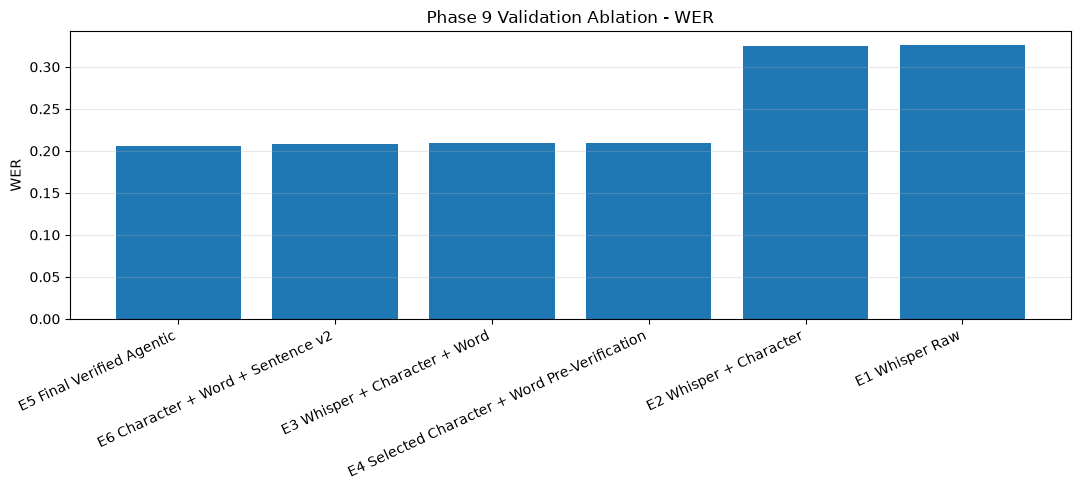

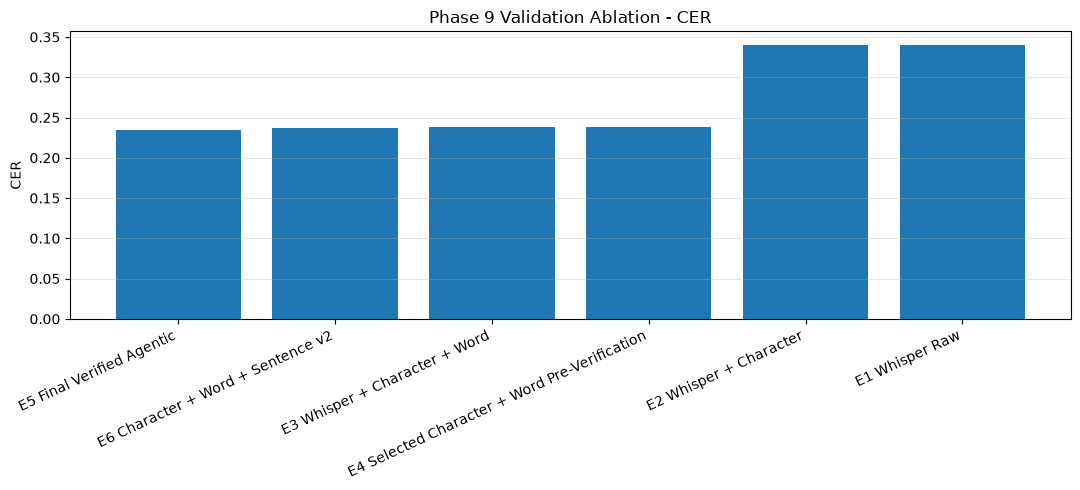

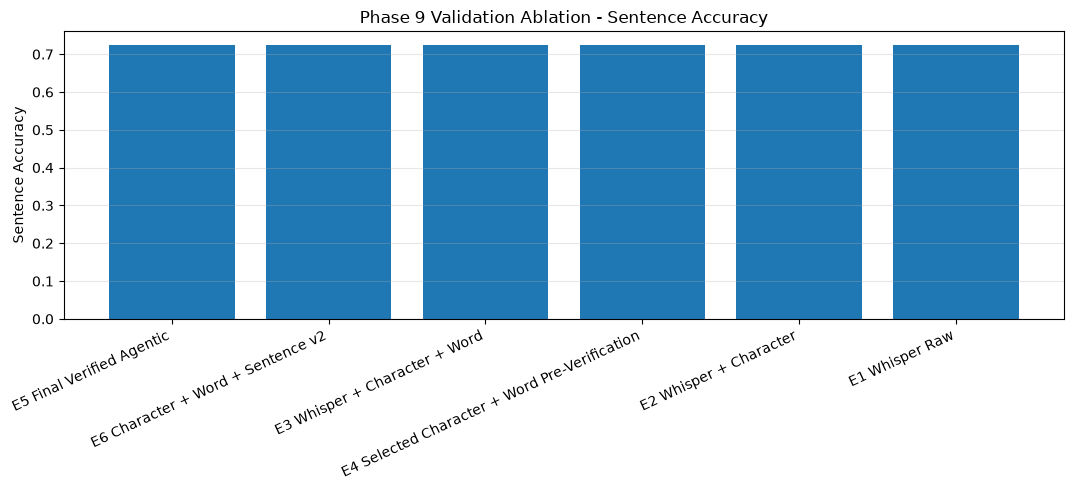

PHASE 9 COMPLETED
Ablation CSV: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_9_validation_ablation_table.csv
Summary JSON: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_9_validation_ablation_summary.json
Checkpoint: E:\AI_Project\Agentic_TORGO_ASR_Project\checkpoints\phase_9_validation_ablation_checkpoint.json
NEXT STEP:
Run frozen final pipeline on TEST set. Do not tune on validation anymore.


In [43]:
# ============================================================
# PHASE 9
# VALIDATION ABLATION STUDY
#
# Goal:
# Compare each stage:
# 1. Whisper Raw
# 2. Character Agent
# 3. Character + Word
# 4. Sentence Agent v2
# 5. Final Verified Agentic
#
# Important:
# - Validation only.
# - Test set is still not used.
# ============================================================

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

PRED_DIR = PROJECT_ROOT / "predictions"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

for p in [PRED_DIR, REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

FINAL_VALIDATION_CSV = PRED_DIR / "phase_8_20_final_agentic_validation_predictions.csv"
SENTENCE_V2_CSV = PRED_DIR / "phase_8_11_sentence_agent_v2_predictions.csv"

ABLATION_CSV = REPORT_DIR / "phase_9_validation_ablation_table.csv"
ABLATION_JSON = REPORT_DIR / "phase_9_validation_ablation_summary.json"
ABLATION_CHECKPOINT = CHECKPOINT_DIR / "phase_9_validation_ablation_checkpoint.json"

WER_FIG = FIGURE_DIR / "phase_9_validation_ablation_wer.png"
CER_FIG = FIGURE_DIR / "phase_9_validation_ablation_cer.png"
SENT_ACC_FIG = FIGURE_DIR / "phase_9_validation_ablation_sentence_accuracy.png"

print("=" * 80)
print("PHASE 9: VALIDATION ABLATION STUDY")
print("Final validation file:", FINAL_VALIDATION_CSV)
print("=" * 80)

# ============================================================
# HELPERS
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def normalize_for_metrics(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())

def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost
            )

    return int(dp[n, m])

try:
    from jiwer import wer as jiwer_wer
    from jiwer import cer as jiwer_cer
    JIWER_AVAILABLE = True
    print("Using jiwer for WER/CER.")
except Exception:
    JIWER_AVAILABLE = False
    print("jiwer not found. Using fallback WER/CER.")

def fallback_wer(references, predictions):
    total_edits = 0
    total_words = 0

    for r, p in zip(references, predictions):
        r_words = tokenize_words(r)
        p_words = tokenize_words(p)
        total_edits += edit_distance(r_words, p_words)
        total_words += len(r_words)

    return total_edits / max(1, total_words)

def fallback_cer(references, predictions):
    total_edits = 0
    total_chars = 0

    for r, p in zip(references, predictions):
        r_chars = list(normalize_for_metrics(r).replace(" ", ""))
        p_chars = list(normalize_for_metrics(p).replace(" ", ""))
        total_edits += edit_distance(r_chars, p_chars)
        total_chars += len(r_chars)

    return total_edits / max(1, total_chars)

def compute_wer(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_wer(references, predictions))

    return float(fallback_wer(references, predictions))

def compute_cer(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]

    if JIWER_AVAILABLE:
        return float(jiwer_cer(references, predictions))

    return float(fallback_cer(references, predictions))

def sentence_accuracy(references, predictions):
    references = [normalize_for_metrics(x) for x in references]
    predictions = [normalize_for_metrics(x) for x in predictions]
    return float(np.mean([r == p for r, p in zip(references, predictions)]))

def evaluate_system(df, system_name, pred_col):
    refs = df["ground_truth"].astype(str).tolist()
    preds = df[pred_col].astype(str).tolist()

    return {
        "System": system_name,
        "Prediction Column": pred_col,
        "WER": compute_wer(refs, preds),
        "CER": compute_cer(refs, preds),
        "Sentence Accuracy": sentence_accuracy(refs, preds),
        "Samples": int(len(df)),
    }

# ============================================================
# LOAD FINAL VALIDATION OUTPUT
# ============================================================

if not FINAL_VALIDATION_CSV.exists():
    raise FileNotFoundError(f"Missing final validation file: {FINAL_VALIDATION_CSV}")

df = pd.read_csv(FINAL_VALIDATION_CSV)

if "ground_truth" not in df.columns:
    raise ValueError("Final validation CSV must contain ground_truth.")

rows = []

# Core ablations from final file.
if "whisper_raw" in df.columns:
    rows.append(evaluate_system(df, "E1 Whisper Raw", "whisper_raw"))

if "character_corrected" in df.columns:
    rows.append(evaluate_system(df, "E2 Whisper + Character", "character_corrected"))

if "word_corrected" in df.columns:
    rows.append(evaluate_system(df, "E3 Whisper + Character + Word", "word_corrected"))

if "pre_verification_corrected" in df.columns:
    rows.append(evaluate_system(df, "E4 Selected Character + Word Pre-Verification", "pre_verification_corrected"))

if "final_agentic_corrected" in df.columns:
    rows.append(evaluate_system(df, "E5 Final Verified Agentic", "final_agentic_corrected"))

# Optional sentence ablation from Sentence Agent v2 file.
if SENTENCE_V2_CSV.exists():
    sent_df = pd.read_csv(SENTENCE_V2_CSV)

    if "ground_truth" in sent_df.columns and "sentence_corrected" in sent_df.columns:
        rows.append(evaluate_system(sent_df, "E6 Character + Word + Sentence v2", "sentence_corrected"))

ablation_df = pd.DataFrame(rows)

ablation_df = ablation_df.sort_values(
    ["WER", "CER", "Sentence Accuracy"],
    ascending=[True, True, False]
).reset_index(drop=True)

ablation_df["WER Reduction vs Whisper"] = np.nan
ablation_df["CER Reduction vs Whisper"] = np.nan

if "E1 Whisper Raw" in ablation_df["System"].values:
    whisper_row = ablation_df[ablation_df["System"] == "E1 Whisper Raw"].iloc[0]
    whisper_wer = float(whisper_row["WER"])
    whisper_cer = float(whisper_row["CER"])

    ablation_df["WER Reduction vs Whisper"] = (
        (whisper_wer - ablation_df["WER"]) / max(whisper_wer, 1e-8)
    )

    ablation_df["CER Reduction vs Whisper"] = (
        (whisper_cer - ablation_df["CER"]) / max(whisper_cer, 1e-8)
    )

ablation_df.to_csv(ABLATION_CSV, index=False)

print("=" * 80)
print("PHASE 9 VALIDATION ABLATION TABLE")
print("=" * 80)
display(ablation_df)

# ============================================================
# BEST SYSTEM SUMMARY
# ============================================================

best_row = ablation_df.iloc[0].to_dict()

summary = {
    "status": "completed",
    "phase": "Phase 9 Validation Ablation Study",
    "test_set_used": False,
    "best_validation_system": best_row["System"],
    "best_validation_wer": float(best_row["WER"]),
    "best_validation_cer": float(best_row["CER"]),
    "best_validation_sentence_accuracy": float(best_row["Sentence Accuracy"]),
    "ablation_csv": str(ABLATION_CSV),
    "important_note": "This ablation uses validation only. Test set remains unused.",
    "next_phase": "Run frozen final pipeline on test set.",
}

save_json(summary, ABLATION_JSON)
save_json(summary, ABLATION_CHECKPOINT)

print("=" * 80)
print("BEST VALIDATION SYSTEM")
print("=" * 80)
print(json.dumps(summary, indent=2))

# ============================================================
# FIGURES
# ============================================================

plot_df = ablation_df.copy()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["System"], plot_df["WER"])
plt.ylabel("WER")
plt.title("Phase 9 Validation Ablation - WER")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(WER_FIG, dpi=200)
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["System"], plot_df["CER"])
plt.ylabel("CER")
plt.title("Phase 9 Validation Ablation - CER")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CER_FIG, dpi=200)
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["System"], plot_df["Sentence Accuracy"])
plt.ylabel("Sentence Accuracy")
plt.title("Phase 9 Validation Ablation - Sentence Accuracy")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(SENT_ACC_FIG, dpi=200)
plt.show()

print("=" * 80)
print("PHASE 9 COMPLETED")
print("Ablation CSV:", ABLATION_CSV)
print("Summary JSON:", ABLATION_JSON)
print("Checkpoint:", ABLATION_CHECKPOINT)
print("=" * 80)

print("NEXT STEP:")
print("Run frozen final pipeline on TEST set. Do not tune on validation anymore.")

In [44]:
# ============================================================
# 10_Final_Test_Set_Evaluation.ipynb
# PHASE 10: FINAL TEST-SET EVALUATION (RUN EXACTLY ONCE)
#
# This is the only script in the whole project that is allowed to
# touch test.csv. Everything upstream (Phase 1-9) selected models,
# GANs, and agent configs using validation only. This script:
#
#   1. Loads the FROZEN artifacts your earlier phases already saved
#      to disk (it does NOT retrain, retune, or reselect anything).
#   2. Runs Whisper Tiny, Whisper Small, Best-Whisper+CWGAN-GP,
#      Best-Whisper+ACGAN, and the Final Agentic pipeline on test.csv.
#   3. Computes WER / CER / BLEU / ROUGE-L / runtime for each system.
#   4. Produces the Phase 12 final comparison table + the Phase 11
#      error-analysis (Ground Truth -> ASR -> Agentic) samples.
#   5. Freezes a checkpoint that marks the test set as "used", so a
#      re-run refuses to overwrite results unless you pass --force.
#
# Rules preserved from your Phase 6-9 code:
# - Character Agent, Word Agent see only whisper_raw / upstream text.
# - ground_truth is used only for scoring, never for correction logic.
# - No agent hyperparameter is re-tuned here. Configs are loaded from
#   the JSON files Phase 8 already wrote.
# ============================================================

import os
import re
import sys
import gc
import json
import math
import time
import random
import argparse
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import yaml
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import WhisperProcessor, WhisperForConditionalGeneration

warnings.filterwarnings("ignore")

# ============================================================
# SECTION 0: CLI + GUARD
# ============================================================

parser = argparse.ArgumentParser()
parser.add_argument("--force", action="store_true",
                     help="Re-run test-set evaluation even if it was already run once.")
args, _ = parser.parse_known_args()

# ============================================================
# SECTION 1: PATHS + CONFIG  (identical layout to Phases 1-9)
# ============================================================

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

DATASET_DIR = PROJECT_ROOT / "dataset"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = PROJECT_ROOT / "figures" / "phase_10_final_test"
MODEL_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
PRED_DIR = PROJECT_ROOT / "predictions"

for d in [REPORT_DIR, FIGURE_DIR, CHECKPOINT_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TEST_CSV = DATASET_DIR / "test.csv"
TRAIN_CSV = DATASET_DIR / "train.csv"

PHASE10_CHECKPOINT = CHECKPOINT_DIR / "phase_10_final_test_evaluation_checkpoint.json"

FINAL_TEST_PRED_CSV = PRED_DIR / "phase_10_final_test_all_systems_predictions.csv"
FINAL_TEST_COMPARISON_CSV = REPORT_DIR / "phase_10_final_test_comparison.csv"
FINAL_TEST_COMPARISON_JSON = REPORT_DIR / "phase_10_final_test_comparison.json"
ERROR_ANALYSIS_CSV = REPORT_DIR / "phase_11_error_analysis_test.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = int(CFG["project"].get("seed", 42))
SAMPLE_RATE = int(CFG["project"].get("sample_rate", 16000))
LANGUAGE = CFG["whisper"]["language"]
TASK = CFG["whisper"]["task"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 80)
print("PHASE 10: FINAL TEST-SET EVALUATION")
print("=" * 80)
print("Device:", DEVICE)
print("Test CSV:", TEST_CSV)

if PHASE10_CHECKPOINT.exists() and not args.force:
    existing = json.loads(PHASE10_CHECKPOINT.read_text(encoding="utf-8"))
    print("!" * 80)
    print("Phase 10 has ALREADY been run on the test set.")
    print("Test-set numbers must not be recomputed after seeing results, or they")
    print("stop being a valid held-out estimate. Re-run with --force only if you")
    print("are certain (e.g. you fixed a bug unrelated to model/agent selection).")
    print("Existing final metrics:")
    print(json.dumps(existing.get("final_metrics", {}), indent=2))
    print("!" * 80)
    sys.exit(0)

if not TEST_CSV.exists():
    raise FileNotFoundError(f"Missing test CSV: {TEST_CSV}")

# ============================================================
# SECTION 2: SHARED HELPERS (same implementations as Phases 8-9)
# ============================================================

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_text(text):
    if text is None or (isinstance(text, float) and math.isnan(text)):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())


def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(dp[i - 1, j] + 1, dp[i, j - 1] + 1, dp[i - 1, j - 1] + cost)
    return int(dp[n, m])


try:
    from jiwer import wer as jiwer_wer, cer as jiwer_cer
    JIWER_AVAILABLE = True
except Exception:
    JIWER_AVAILABLE = False


def fallback_wer(references, predictions):
    total_edits, total_words = 0, 0
    for r, p in zip(references, predictions):
        r_words, p_words = tokenize_words(r), tokenize_words(p)
        total_edits += edit_distance(r_words, p_words)
        total_words += len(r_words)
    return total_edits / max(1, total_words)


def fallback_cer(references, predictions):
    total_edits, total_chars = 0, 0
    for r, p in zip(references, predictions):
        r_chars = list(normalize_text(r).replace(" ", ""))
        p_chars = list(normalize_text(p).replace(" ", ""))
        total_edits += edit_distance(r_chars, p_chars)
        total_chars += len(r_chars)
    return total_edits / max(1, total_chars)


def compute_wer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    if JIWER_AVAILABLE:
        return float(jiwer_wer(references, predictions))
    return float(fallback_wer(references, predictions))


def compute_cer(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    if JIWER_AVAILABLE:
        return float(jiwer_cer(references, predictions))
    return float(fallback_cer(references, predictions))


def sentence_accuracy(references, predictions):
    references = [normalize_text(x) for x in references]
    predictions = [normalize_text(x) for x in predictions]
    return float(np.mean([r == p for r, p in zip(references, predictions)]))


def row_wer(reference, prediction):
    return fallback_wer([reference], [prediction])


def row_cer(reference, prediction):
    return fallback_cer([reference], [prediction])


# BLEU / ROUGE-L -- new metrics requested for the final comparison table
try:
    import sacrebleu

    def compute_bleu(references, predictions):
        refs = [normalize_text(x) for x in references]
        preds = [normalize_text(x) for x in predictions]
        return float(sacrebleu.corpus_bleu(preds, [refs]).score)
    BLEU_AVAILABLE = True
except Exception:
    BLEU_AVAILABLE = False

    def compute_bleu(references, predictions):
        return float("nan")

try:
    from rouge_score import rouge_scorer

    _rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

    def compute_rouge_l(references, predictions):
        scores = [
            _rouge.score(normalize_text(r), normalize_text(p))["rougeL"].fmeasure
            for r, p in zip(references, predictions)
        ]
        return float(np.mean(scores)) if scores else float("nan")
    ROUGE_AVAILABLE = True
except Exception:
    ROUGE_AVAILABLE = False

    def compute_rouge_l(references, predictions):
        return float("nan")

if not BLEU_AVAILABLE:
    print("sacrebleu not installed -> pip install sacrebleu (BLEU will be NaN otherwise)")
if not ROUGE_AVAILABLE:
    print("rouge-score not installed -> pip install rouge-score (ROUGE-L will be NaN otherwise)")


def load_audio(path, sr=SAMPLE_RATE):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    return audio.astype(np.float32)


# ============================================================
# SECTION 3: LOAD FROZEN, ALREADY-SELECTED ARTIFACTS
#
# Nothing below this point is a decision. Every value is read back
# from a JSON file that an earlier (validation-only) phase produced.
# If one of these is missing, the corresponding phase has not been
# completed/frozen yet -- rerun that phase before Phase 10.
# ============================================================

FINAL_PIPELINE_JSON = REPORT_DIR / "final_pipeline.json"
BEST_WHISPER_JSON = REPORT_DIR / "best_whisper_model_for_next_phase.json"
WHISPER_TINY_BEST_JSON = REPORT_DIR / "whisper_tiny_best_model.json"
WHISPER_SMALL_BEST_JSON = REPORT_DIR / "whisper_small_best_model.json"
CHAR_SELECTION_JSON = REPORT_DIR / "phase_8_selected_character_word_pipeline.json"
FROZEN_PIPELINE_JSON = REPORT_DIR / "phase_8_20_final_frozen_pipeline_config.json"

for required in [FINAL_PIPELINE_JSON, BEST_WHISPER_JSON, WHISPER_TINY_BEST_JSON,
                  WHISPER_SMALL_BEST_JSON, CHAR_SELECTION_JSON, FROZEN_PIPELINE_JSON]:
    if not required.exists():
        raise FileNotFoundError(
            f"Missing frozen artifact: {required}\n"
            "Phase 10 only replays decisions your earlier phases already made. "
            "Finish Phases 6-9 (validation only) before running this script."
        )

final_pipeline = load_json(FINAL_PIPELINE_JSON)
char_word_selection = load_json(CHAR_SELECTION_JSON)
frozen_pipeline_cfg = load_json(FROZEN_PIPELINE_JSON)
whisper_tiny_best = load_json(WHISPER_TINY_BEST_JSON)
whisper_small_best = load_json(WHISPER_SMALL_BEST_JSON)

BEST_WHISPER_GAN_MODEL_PATH = Path(final_pipeline["best_model_path"])   # best GAN-augmented whisper
BEST_GAN_NAME = final_pipeline["best_gan"]                              # "CWGAN-GP" / "ACGAN" / "No GAN..."
BEST_WHISPER_BASE_PATH = Path(final_pipeline["best_whisper_path"])      # phase-6 best whisper (tiny/small)

# Which Character Agent version won on validation ("Character v4 + Word v3", etc.)
best_system_name = char_word_selection["best_system"]
CHARACTER_VERSION = "v4" if "v4" in best_system_name else "v3"

CHAR_CONFIG_JSON = REPORT_DIR / f"phase_8_6_character_agent_{CHARACTER_VERSION}_candidate_config_pending_manual_review.json"
if CHARACTER_VERSION == "v3":
    # v3 config file used a slightly different name in earlier notebooks; fall back gracefully.
    alt = REPORT_DIR / "phase_8_6_character_agent_v3_candidate_config.json"
    if not CHAR_CONFIG_JSON.exists() and alt.exists():
        CHAR_CONFIG_JSON = alt

WORD_CONFIG_JSON = REPORT_DIR / f"phase_8_10_word_agent_v3_from_character_{CHARACTER_VERSION}_candidate_config.json"

if not CHAR_CONFIG_JSON.exists():
    raise FileNotFoundError(f"Missing frozen Character Agent config: {CHAR_CONFIG_JSON}")
if not WORD_CONFIG_JSON.exists():
    raise FileNotFoundError(f"Missing frozen Word Agent config: {WORD_CONFIG_JSON}")

char_config = load_json(CHAR_CONFIG_JSON)["selected_config"]
word_config = load_json(WORD_CONFIG_JSON)["selected_config"]

SENTENCE_AGENT_FROZEN = bool(frozen_pipeline_cfg.get("sentence_agent_v2_frozen", False))

WHISPER_TINY_PATH = Path(whisper_tiny_best["best_model_path"])
WHISPER_SMALL_PATH = Path(whisper_small_best["best_model_path"])

print("=" * 80)
print("FROZEN ARTIFACTS LOADED")
print("=" * 80)
print("Best GAN:                  ", BEST_GAN_NAME)
print("Best whisper (base, phase6):", BEST_WHISPER_BASE_PATH)
print("Best GAN+Whisper model:    ", BEST_WHISPER_GAN_MODEL_PATH)
print("Whisper Tiny model:        ", WHISPER_TINY_PATH)
print("Whisper Small model:       ", WHISPER_SMALL_PATH)
print("Character Agent version:   ", CHARACTER_VERSION)
print("Sentence Agent v2 frozen:  ", SENTENCE_AGENT_FROZEN, "(should be False per your Phase 8.18-8.20 decision)")
print("=" * 80)

# ============================================================
# SECTION 4: LOAD TEST SET
# ============================================================

test_df = pd.read_csv(TEST_CSV)

if "sample_id" not in test_df.columns:
    test_df["sample_id"] = [f"test_{i:06d}" for i in range(len(test_df))]

if "transcript" in test_df.columns:
    gt_col = "transcript"
elif "normalized_transcript" in test_df.columns:
    gt_col = "normalized_transcript"
elif "text" in test_df.columns:
    gt_col = "text"
else:
    raise ValueError("No ground-truth transcript column found in test.csv.")

test_df["ground_truth"] = test_df[gt_col].astype(str).apply(normalize_text)
print("Test samples:", len(test_df))

# ============================================================
# SECTION 5: GAN GENERATOR (identical architecture to Phase 7)
# ============================================================

GAN_SAMPLE_RATE = 16000
GAN_CHUNK_SECONDS = 3.0
GAN_CHUNK_LEN = int(GAN_SAMPLE_RATE * GAN_CHUNK_SECONDS)


class ConditionalGenerator(nn.Module):
    def __init__(self, num_conditions, cond_dim=16):
        super().__init__()
        self.cond_emb = nn.Embedding(num_conditions, cond_dim)
        self.encoder = nn.Sequential(
            nn.Conv1d(1 + cond_dim, 32, 15, stride=1, padding=7),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(32, 64, 15, stride=2, padding=7),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(64, 128, 15, stride=2, padding=7),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 16, stride=2, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose1d(64, 32, 16, stride=2, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Conv1d(32, 1, 15, stride=1, padding=7),
            nn.Tanh(),
        )

    def forward(self, noisy, condition):
        b, _, t = noisy.shape
        cond = self.cond_emb(condition)
        cond = cond.unsqueeze(-1).expand(-1, -1, t)
        x = torch.cat([noisy, cond], dim=1)
        z = self.encoder(x)
        out = self.decoder(z)
        if out.shape[-1] != t:
            out = F.interpolate(out, size=t, mode="linear", align_corners=False)
        return out


def gan_dir_name(gan_name):
    if "CWGAN" in gan_name:
        return "cwgan_gp"
    if "ACGAN" in gan_name:
        return "acgan"
    return None


def load_generator(gan_name, num_conditions):
    folder = gan_dir_name(gan_name)
    if folder is None:
        return None
    gen_path = MODEL_DIR / "gan" / folder / "best_generator.pt"
    if not gen_path.exists():
        raise FileNotFoundError(f"Missing generator checkpoint: {gen_path}")
    generator = ConditionalGenerator(num_conditions).to(DEVICE)
    generator.load_state_dict(torch.load(gen_path, map_location=DEVICE))
    generator.eval()
    return generator


def enhance_audio_with_gan(audio, generator, condition_id):
    """Enhance a variable-length waveform by sliding non-overlapping
    3s windows through the generator (same window size used in Phase 7
    training) and re-assembling. Preserves original length."""
    if generator is None:
        return audio

    n = len(audio)
    if n == 0:
        return audio

    pad_len = int(np.ceil(n / GAN_CHUNK_LEN) * GAN_CHUNK_LEN)
    padded = np.pad(audio, (0, pad_len - n))

    max_val = np.max(np.abs(padded)) + 1e-8
    padded_norm = padded / max_val

    chunks = padded_norm.reshape(-1, GAN_CHUNK_LEN)
    cond_tensor = torch.full((chunks.shape[0],), int(condition_id), dtype=torch.long, device=DEVICE)
    chunk_tensor = torch.tensor(chunks, dtype=torch.float32, device=DEVICE).unsqueeze(1)

    with torch.no_grad():
        enhanced = generator(chunk_tensor, cond_tensor).squeeze(1).cpu().numpy()

    enhanced_flat = enhanced.reshape(-1)[:n] * max_val
    return enhanced_flat.astype(np.float32)


# Condition mapping must match Phase 7's mapping (built from train.csv "condition" column).
train_df_for_cond = pd.read_csv(TRAIN_CSV)
if "condition" not in train_df_for_cond.columns:
    train_df_for_cond["condition"] = "unknown"
CONDITIONS = sorted(train_df_for_cond["condition"].fillna("unknown").astype(str).unique().tolist())
CONDITION_TO_ID = {c: i for i, c in enumerate(CONDITIONS)}
NUM_CONDITIONS = len(CONDITIONS)

if "condition" not in test_df.columns:
    test_df["condition"] = "unknown"
test_df["condition_id"] = test_df["condition"].fillna("unknown").astype(str).map(
    lambda c: CONDITION_TO_ID.get(c, 0)
)

# ============================================================
# SECTION 6: WHISPER INFERENCE (same pattern as Phase 8 evaluate_model)
# ============================================================

EVAL_BATCH_SIZE = 8


def load_whisper(model_path):
    processor = WhisperProcessor.from_pretrained(str(model_path))
    model = WhisperForConditionalGeneration.from_pretrained(str(model_path)).to(DEVICE)
    return model, processor


def get_clean_generation_config(model):
    gen_config = model.generation_config
    try:
        gen_config.forced_decoder_ids = None
    except Exception:
        pass
    return gen_config


def transcribe_dataframe(model_path, df, audio_col="audio_path", gan_generator=None,
                          system_name="system"):
    """Runs Whisper (optionally behind GAN enhancement) over df[audio_col]
    and returns predictions + wall-clock runtime, mirroring Phase 8's
    evaluate_model loop exactly."""
    model, processor = load_whisper(model_path)
    model.eval()
    gen_config = get_clean_generation_config(model)

    predictions = []
    start_time = time.time()

    for start in range(0, len(df), EVAL_BATCH_SIZE):
        batch_df = df.iloc[start:start + EVAL_BATCH_SIZE]

        audios = []
        for _, row in batch_df.iterrows():
            raw_audio = load_audio(row[audio_col])
            if gan_generator is not None:
                raw_audio = enhance_audio_with_gan(raw_audio, gan_generator, row["condition_id"])
            audios.append(raw_audio)

        inputs = processor.feature_extractor(audios, sampling_rate=SAMPLE_RATE, return_tensors="pt")
        input_features = inputs.input_features.to(DEVICE)

        with torch.no_grad():
            generated_ids = model.generate(input_features, generation_config=gen_config)

        batch_preds = processor.batch_decode(generated_ids, skip_special_tokens=True,
                                              clean_up_tokenization_spaces=False)
        predictions.extend([normalize_text(x) for x in batch_preds])

        print(f"[{system_name}] {min(start + EVAL_BATCH_SIZE, len(df))}/{len(df)}", end="\r")

    runtime = time.time() - start_time

    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return predictions, runtime


# ============================================================
# SECTION 7: FROZEN AGENT DEFINITIONS
# (verbatim from Phases 8.1-8.20 -- no logic changed, only configs
#  are read from disk instead of re-tuned)
# ============================================================

def collapse_repeated_chars(word):
    return re.sub(r"(.)\1{2,}", r"\1\1", word)


def consonant_skeleton(word):
    return re.sub(r"[aeiou]", "", word)


def vowel_pattern(word):
    return re.sub(r"[^aeiou]", "", word)


def phonetic_light_similarity(a, b):
    cons_sim = SequenceMatcher(None, consonant_skeleton(a), consonant_skeleton(b)).ratio()
    vow_sim = SequenceMatcher(None, vowel_pattern(a), vowel_pattern(b)).ratio()
    return float(0.7 * cons_sim + 0.3 * vow_sim)


class CharacterCorrectionAgentV4:
    def __init__(self, vocab, word_counts, left_context_counts, right_context_counts,
                 min_token_len=4, confidence_threshold=0.84, min_similarity=0.78,
                 min_margin=0.01, max_candidates=120, max_edit_extra=0,
                 allow_repeated_char_fix=True):
        self.vocab = set(vocab)
        self.word_counts = Counter(word_counts)
        self.left_context_counts = Counter(left_context_counts)
        self.right_context_counts = Counter(right_context_counts)
        self.min_token_len = min_token_len
        self.confidence_threshold = confidence_threshold
        self.min_similarity = min_similarity
        self.min_margin = min_margin
        self.max_candidates = max_candidates
        self.max_edit_extra = max_edit_extra
        self.allow_repeated_char_fix = allow_repeated_char_fix
        self.vocab_by_length = defaultdict(list)
        for w in self.vocab:
            self.vocab_by_length[len(w)].append(w)

    def is_protected_token(self, token):
        t = str(token).strip()
        if t == "":
            return True
        if re.search(r"\d", t):
            return True
        if len(t) <= 2:
            return True
        if not re.fullmatch(r"[a-zA-Z']+", t):
            return True
        if t.count("'") > 1:
            return True
        return False

    def should_attempt_correction(self, token):
        t = str(token).lower().strip()
        if self.is_protected_token(t):
            return False
        if len(t) < self.min_token_len:
            return False
        if t in self.vocab:
            return False
        return True

    def max_edit_allowed(self, token):
        n = len(token)
        if n <= 5:
            return 1 + self.max_edit_extra
        if n <= 9:
            return 2 + self.max_edit_extra
        return 3 + self.max_edit_extra

    def candidate_pool(self, token):
        token = token.lower()
        max_ed = self.max_edit_allowed(token)
        pool = set()
        for length in range(len(token) - max_ed, len(token) + max_ed + 1):
            if length <= 0:
                continue
            for cand in self.vocab_by_length.get(length, []):
                pool.add(cand)
        return list(pool)

    def context_score(self, left_token, candidate, right_token):
        left_token = left_token if left_token else "<s>"
        right_token = right_token if right_token else "</s>"
        left_count = self.left_context_counts.get((left_token, candidate), 0)
        right_count = self.right_context_counts.get((candidate, right_token), 0)
        score = 0.0
        if left_count > 0:
            score += 0.5
        if right_count > 0:
            score += 0.5
        return float(score)

    def score_candidate(self, token, candidate, left_token=None, right_token=None):
        ed = edit_distance(token, candidate)
        max_ed = self.max_edit_allowed(token)
        if ed > max_ed:
            return None
        seq_sim = SequenceMatcher(None, token, candidate).ratio()
        edit_sim = 1.0 - (ed / max(len(token), len(candidate), 1))
        phon_sim = phonetic_light_similarity(token, candidate)
        freq_score = min(math.log1p(self.word_counts.get(candidate, 0)) / 6.0, 1.0)
        ctx_score = self.context_score(left_token, candidate, right_token)
        repeat_bonus = 0.0
        if self.allow_repeated_char_fix:
            collapsed = collapse_repeated_chars(token)
            if collapsed != token:
                repeat_bonus = SequenceMatcher(None, collapsed, candidate).ratio()
        confidence = (0.50 * edit_sim + 0.24 * seq_sim + 0.10 * phon_sim +
                      0.07 * freq_score + 0.04 * ctx_score + 0.05 * repeat_bonus)
        return {"candidate": candidate, "confidence": float(confidence),
                "sequence_similarity": float(seq_sim)}

    def best_candidates(self, token, left_token=None, right_token=None):
        scored = []
        for cand in self.candidate_pool(token):
            item = self.score_candidate(token, cand, left_token, right_token)
            if item is not None:
                scored.append(item)
        scored = sorted(scored, key=lambda x: x["confidence"], reverse=True)
        return scored[:self.max_candidates]

    def correct_token(self, token, left_token=None, right_token=None):
        original = token
        t = str(token).lower().strip()
        if not self.should_attempt_correction(t):
            return original
        candidates = self.best_candidates(t, left_token, right_token)
        if len(candidates) == 0:
            return original
        best = candidates[0]
        second_conf = candidates[1]["confidence"] if len(candidates) > 1 else 0.0
        margin = best["confidence"] - second_conf
        accept = (best["confidence"] >= self.confidence_threshold and
                  best["sequence_similarity"] >= self.min_similarity and
                  margin >= self.min_margin)
        return best["candidate"] if accept else original

    def correct_text(self, text):
        text = normalize_text(text)
        tokens = text.split()
        corrected_tokens = []
        for i, tok in enumerate(tokens):
            left_tok = tokens[i - 1] if i > 0 else "<s>"
            right_tok = tokens[i + 1] if i < len(tokens) - 1 else "</s>"
            corrected_tokens.append(self.correct_token(tok, left_tok, right_tok))
        return " ".join(corrected_tokens)


CONFUSION_GROUPS = [
    {"to", "too", "two"}, {"for", "four"}, {"there", "their", "they're"},
    {"here", "hear"}, {"no", "know"}, {"one", "won"}, {"right", "write"},
    {"see", "sea"}, {"new", "knew"}, {"our", "hour"}, {"by", "buy", "bye"},
    {"then", "than"}, {"ate", "eight"}, {"be", "bee"}, {"were", "where"},
    {"your", "you're"}, {"its", "it's"},
]
CONFUSION_MAP = defaultdict(set)
for group in CONFUSION_GROUPS:
    normalized_group = {normalize_text(x) for x in group}
    for w in normalized_group:
        CONFUSION_MAP[w].update(normalized_group - {w})

ARTIFACT_PHRASES = [["input", "images", "story", "starters"]]
ARTIFACT_TOKENS = {"jpg", "jpeg", "png"}


class WordCorrectionAgentV3:
    def __init__(self, vocab, unigram_counts, bigram_counts, trigram_counts,
                 confusion_map, artifact_tokens, artifact_phrases,
                 confidence_threshold=0.55, min_context_gain=0.05, min_margin=0.00,
                 max_repeat_keep=1, repeated_phrase_max_len=6, min_repeated_word_count=3,
                 enable_artifact_cleanup=True, enable_repetition_cleanup=True,
                 enable_confusion_correction=True):
        self.vocab = set(vocab)
        self.unigram_counts = Counter(unigram_counts)
        self.bigram_counts = Counter(bigram_counts)
        self.trigram_counts = Counter(trigram_counts)
        self.confusion_map = confusion_map
        self.artifact_tokens = set(artifact_tokens)
        self.artifact_phrases = [list(p) for p in artifact_phrases]
        self.confidence_threshold = confidence_threshold
        self.min_context_gain = min_context_gain
        self.min_margin = min_margin
        self.max_repeat_keep = max_repeat_keep
        self.repeated_phrase_max_len = repeated_phrase_max_len
        self.min_repeated_word_count = min_repeated_word_count
        self.enable_artifact_cleanup = enable_artifact_cleanup
        self.enable_repetition_cleanup = enable_repetition_cleanup
        self.enable_confusion_correction = enable_confusion_correction

    def context_score(self, left_tok, word, right_tok):
        left_tok = left_tok if left_tok else "<s>"
        right_tok = right_tok if right_tok else "</s>"
        tri = self.trigram_counts.get((left_tok, word, right_tok), 0)
        left_bigram = self.bigram_counts.get((left_tok, word), 0)
        right_bigram = self.bigram_counts.get((word, right_tok), 0)
        uni = self.unigram_counts.get(word, 0)
        return float(0.45 * math.log1p(tri) + 0.25 * math.log1p(left_bigram) +
                     0.25 * math.log1p(right_bigram) + 0.05 * math.log1p(uni))

    def remove_artifacts(self, tokens):
        if not self.enable_artifact_cleanup:
            return tokens
        out, i = [], 0
        while i < len(tokens):
            removed = False
            for phrase in self.artifact_phrases:
                n = len(phrase)
                if tokens[i:i + n] == phrase:
                    i += n
                    removed = True
                    break
            if removed:
                continue
            if tokens[i] in self.artifact_tokens:
                i += 1
                continue
            out.append(tokens[i])
            i += 1
        return out

    def collapse_repeated_words(self, tokens):
        if not self.enable_repetition_cleanup:
            return tokens
        out, i = [], 0
        while i < len(tokens):
            tok = tokens[i]
            j = i + 1
            while j < len(tokens) and tokens[j] == tok:
                j += 1
            repeat_count = j - i
            if repeat_count >= self.min_repeated_word_count:
                out.extend([tok] * self.max_repeat_keep)
            else:
                out.extend([tok] * repeat_count)
            i = j
        return out

    def collapse_repeated_phrases(self, tokens):
        if not self.enable_repetition_cleanup:
            return tokens
        changed = True
        while changed:
            changed = False
            for phrase_len in range(self.repeated_phrase_max_len, 1, -1):
                i, new_tokens = 0, []
                while i < len(tokens):
                    phrase = tokens[i:i + phrase_len]
                    next_phrase = tokens[i + phrase_len:i + (2 * phrase_len)]
                    if len(phrase) == phrase_len and phrase == next_phrase:
                        j = i + (2 * phrase_len)
                        while tokens[j:j + phrase_len] == phrase:
                            j += phrase_len
                        new_tokens.extend(phrase)
                        i = j
                        changed = True
                    else:
                        new_tokens.append(tokens[i])
                        i += 1
                tokens = new_tokens
        return tokens

    def is_protected_token(self, token):
        t = str(token).strip()
        if t == "" or re.search(r"\d", t) or not re.fullmatch(r"[a-zA-Z']+", t):
            return True
        return False

    def confusion_candidates(self, token):
        token = str(token).lower().strip()
        if token not in self.confusion_map:
            return []
        return [c for c in self.confusion_map[token]
                if c in self.vocab and c != token and re.fullmatch(r"[a-z']+", c)]

    def score_confusion_candidate(self, token, candidate, left_tok, right_tok):
        original_context = self.context_score(left_tok, token, right_tok)
        candidate_context = self.context_score(left_tok, candidate, right_tok)
        context_gain = candidate_context - original_context
        if context_gain < self.min_context_gain:
            return None
        freq_score = min(math.log1p(self.unigram_counts.get(candidate, 0)) / 8.0, 1.0)
        char_similarity = SequenceMatcher(None, token, candidate).ratio()
        confidence = (0.70 * min(max(context_gain, 0.0) / 2.0, 1.0) +
                      0.20 * freq_score + 0.10 * char_similarity)
        return {"candidate": candidate, "confidence": float(confidence)}

    def correct_confusion_tokens(self, tokens):
        if not self.enable_confusion_correction:
            return tokens
        corrected = []
        for i, tok in enumerate(tokens):
            left_tok = tokens[i - 1] if i > 0 else "<s>"
            right_tok = tokens[i + 1] if i < len(tokens) - 1 else "</s>"
            if self.is_protected_token(tok) or tok not in self.confusion_map:
                corrected.append(tok)
                continue
            scored = []
            for cand in self.confusion_candidates(tok):
                item = self.score_confusion_candidate(tok, cand, left_tok, right_tok)
                if item is not None:
                    scored.append(item)
            if not scored:
                corrected.append(tok)
                continue
            scored = sorted(scored, key=lambda x: x["confidence"], reverse=True)
            best = scored[0]
            second_conf = scored[1]["confidence"] if len(scored) > 1 else 0.0
            margin = best["confidence"] - second_conf
            accept = best["confidence"] >= self.confidence_threshold and margin >= self.min_margin
            corrected.append(best["candidate"] if accept else tok)
        return corrected

    def correct_text(self, text):
        text = normalize_text(text)
        tokens = text.split()
        tokens = self.remove_artifacts(tokens)
        tokens = self.collapse_repeated_phrases(tokens)
        tokens = self.collapse_repeated_words(tokens)
        tokens = self.correct_confusion_tokens(tokens)
        return " ".join(tokens).strip()


def remove_known_artifacts(text):
    words = tokenize_words(text)
    out, i, changed = [], 0, False
    while i < len(words):
        removed = False
        for phrase in ARTIFACT_PHRASES:
            n = len(phrase)
            if words[i:i + n] == phrase:
                changed = True
                i += n
                removed = True
                break
        if removed:
            continue
        if words[i] in ARTIFACT_TOKENS:
            changed = True
            i += 1
            continue
        out.append(words[i])
        i += 1
    return " ".join(out), changed


def collapse_repeated_words_text(text, min_repeat=3, keep=1):
    words = tokenize_words(text)
    out, i, changed = [], 0, False
    while i < len(words):
        tok = words[i]
        j = i + 1
        while j < len(words) and words[j] == tok:
            j += 1
        repeat_count = j - i
        if repeat_count >= min_repeat:
            out.extend([tok] * keep)
            changed = True
        else:
            out.extend([tok] * repeat_count)
        i = j
    return " ".join(out), changed


def collapse_repeated_phrases_text(text, max_phrase_len=8):
    words = tokenize_words(text)
    changed_any, changed = False, True
    while changed:
        changed = False
        for phrase_len in range(max_phrase_len, 1, -1):
            i, new_words = 0, []
            while i < len(words):
                phrase = words[i:i + phrase_len]
                next_phrase = words[i + phrase_len:i + (2 * phrase_len)]
                if len(phrase) == phrase_len and phrase == next_phrase:
                    j = i + (2 * phrase_len)
                    while words[j:j + phrase_len] == phrase:
                        j += phrase_len
                    new_words.extend(phrase)
                    i = j
                    changed = True
                    changed_any = True
                else:
                    new_words.append(words[i])
                    i += 1
            words = new_words
    return " ".join(words), changed_any


def final_verification_agent(text):
    original = normalize_text(text)
    current = original
    cleaned, changed = remove_known_artifacts(current)
    if changed:
        current = cleaned
    cleaned, changed = collapse_repeated_phrases_text(current, max_phrase_len=8)
    if changed:
        current = cleaned
    cleaned, changed = collapse_repeated_words_text(current, min_repeat=3, keep=1)
    if changed:
        current = cleaned
    if current.strip() == "":
        return original
    return current


# ============================================================
# SECTION 8: TRAIN-ONLY VOCAB / N-GRAM CONTEXT
# (rebuilt from train.csv only -- test.csv never contributes)
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)
if "transcript" in train_df.columns:
    train_text_col = "transcript"
elif "normalized_transcript" in train_df.columns:
    train_text_col = "normalized_transcript"
else:
    train_text_col = "text"

train_texts = train_df[train_text_col].astype(str).apply(normalize_text).tolist()

word_counts = Counter()
left_context_counts = Counter()
right_context_counts = Counter()
unigram_counts = Counter()
bigram_counts = Counter()
trigram_counts = Counter()

for text in train_texts:
    toks = tokenize_words(text)
    word_counts.update(toks)
    unigram_counts.update(toks)
    padded = ["<s>"] + toks + ["</s>"]
    for i in range(1, len(padded) - 1):
        left_tok, tok, right_tok = padded[i - 1], padded[i], padded[i + 1]
        left_context_counts[(left_tok, tok)] += 1
        right_context_counts[(tok, right_tok)] += 1
        bigram_counts[(left_tok, tok)] += 1
        bigram_counts[(tok, right_tok)] += 1
        trigram_counts[(left_tok, tok, right_tok)] += 1

VOCAB = {w for w, c in word_counts.items() if re.fullmatch(r"[a-z']+", w) and len(w) >= 2}
WORD_VOCAB = {w for w, c in unigram_counts.items() if re.fullmatch(r"[a-z']+", w) and len(w) >= 1}

print("Train-only vocabulary size (character agent):", len(VOCAB))
print("Train-only vocabulary size (word agent):", len(WORD_VOCAB))

character_agent = CharacterCorrectionAgentV4(
    vocab=VOCAB, word_counts=word_counts,
    left_context_counts=left_context_counts, right_context_counts=right_context_counts,
    min_token_len=4,
    confidence_threshold=float(char_config["confidence_threshold"]),
    min_similarity=float(char_config["min_similarity"]),
    min_margin=float(char_config["min_margin"]),
    max_edit_extra=int(char_config["max_edit_extra"]),
    allow_repeated_char_fix=True,
)

word_agent = WordCorrectionAgentV3(
    vocab=WORD_VOCAB, unigram_counts=unigram_counts,
    bigram_counts=bigram_counts, trigram_counts=trigram_counts,
    confusion_map=CONFUSION_MAP, artifact_tokens=ARTIFACT_TOKENS,
    artifact_phrases=ARTIFACT_PHRASES,
    confidence_threshold=float(word_config["confidence_threshold"]),
    min_context_gain=float(word_config["min_context_gain"]),
    max_repeat_keep=int(word_config["max_repeat_keep"]),
    repeated_phrase_max_len=int(word_config["repeated_phrase_max_len"]),
    min_repeated_word_count=int(word_config["min_repeated_word_count"]),
)

print("Character Agent config:", json.dumps(char_config, indent=2))
print("Word Agent config:", json.dumps(word_config, indent=2))

# ============================================================
# SECTION 9: RUN ALL SYSTEMS ON TEST SET
# ============================================================

results_df = pd.DataFrame({
    "sample_id": test_df["sample_id"].astype(str),
    "audio_path": test_df["audio_path"].astype(str),
    "ground_truth": test_df["ground_truth"],
})
for c in ["speaker", "condition", "gender", "session"]:
    if c in test_df.columns:
        results_df[c] = test_df[c].astype(str)

system_runtimes = {}

print("=" * 80)
print("[1/4] Whisper Tiny (fine-tuned) on test set")
preds, rt = transcribe_dataframe(WHISPER_TINY_PATH, test_df, system_name="whisper_tiny")
results_df["whisper_tiny"] = preds
system_runtimes["Whisper Tiny"] = rt

print("\n[2/4] Whisper Small (fine-tuned) on test set")
preds, rt = transcribe_dataframe(WHISPER_SMALL_PATH, test_df, system_name="whisper_small")
results_df["whisper_small"] = preds
system_runtimes["Whisper Small"] = rt

print("\n[3/4] Best Whisper + Best GAN on test set")
generator = load_generator(BEST_GAN_NAME, NUM_CONDITIONS)
preds, rt = transcribe_dataframe(BEST_WHISPER_GAN_MODEL_PATH, test_df,
                                  gan_generator=generator, system_name="best_gan_whisper")
results_df["whisper_raw"] = preds  # this is the input the agentic pipeline corrects
gan_system_label = f"Best Whisper + {BEST_GAN_NAME}" if generator is not None else "Best Whisper (no GAN improved baseline)"
system_runtimes[gan_system_label] = rt

if generator is not None:
    del generator
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n[4/4] Agentic AI correction layer (Character -> Word -> Verification)")
start = time.time()
results_df["character_corrected"] = results_df["whisper_raw"].apply(character_agent.correct_text)
results_df["word_corrected"] = results_df["character_corrected"].apply(word_agent.correct_text)
results_df["final_agentic_corrected"] = results_df["word_corrected"].apply(final_verification_agent)
agentic_runtime = time.time() - start
system_runtimes["Agentic AI Correction (post-processing only)"] = agentic_runtime

results_df.to_csv(FINAL_TEST_PRED_CSV, index=False)
print("\nSaved all predictions:", FINAL_TEST_PRED_CSV)

# ============================================================
# SECTION 10: PHASE 12 FINAL COMPARISON TABLE
# ============================================================

refs = results_df["ground_truth"].astype(str).tolist()

systems = [
    ("Whisper Tiny", "whisper_tiny", system_runtimes.get("Whisper Tiny")),
    ("Whisper Small", "whisper_small", system_runtimes.get("Whisper Small")),
    (gan_system_label, "whisper_raw", system_runtimes.get(gan_system_label)),
    (f"{gan_system_label} + Agentic AI", "final_agentic_corrected",
     system_runtimes.get(gan_system_label, 0) + agentic_runtime),
]

comparison_rows = []
for name, col, runtime in systems:
    preds = results_df[col].astype(str).tolist()
    comparison_rows.append({
        "Pipeline": name,
        "WER": compute_wer(refs, preds),
        "CER": compute_cer(refs, preds),
        "BLEU": compute_bleu(refs, preds),
        "ROUGE-L": compute_rouge_l(refs, preds),
        "Sentence Accuracy": sentence_accuracy(refs, preds),
        "Runtime (s)": float(runtime) if runtime is not None else None,
        "Seconds / Sample": float(runtime) / max(1, len(results_df)) if runtime is not None else None,
        "Samples": int(len(results_df)),
    })

final_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["WER", "CER"], ascending=[True, True]
).reset_index(drop=True)

final_comparison_df.to_csv(FINAL_TEST_COMPARISON_CSV, index=False)
save_json(final_comparison_df.to_dict(orient="records"), FINAL_TEST_COMPARISON_JSON)

print("=" * 80)
print("PHASE 12: FINAL TEST-SET COMPARISON")
print("=" * 80)
print(final_comparison_df.to_string(index=False))

# Figures
plt.figure(figsize=(10, 5))
plt.bar(final_comparison_df["Pipeline"], final_comparison_df["WER"])
plt.ylabel("WER")
plt.title("Final TEST-SET WER Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
wer_fig = FIGURE_DIR / "phase_10_final_test_wer_comparison.png"
plt.savefig(wer_fig, dpi=200)
plt.close()

plt.figure(figsize=(10, 5))
plt.bar(final_comparison_df["Pipeline"], final_comparison_df["CER"])
plt.ylabel("CER")
plt.title("Final TEST-SET CER Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
cer_fig = FIGURE_DIR / "phase_10_final_test_cer_comparison.png"
plt.savefig(cer_fig, dpi=200)
plt.close()

# ============================================================
# SECTION 11: PHASE 11 ERROR ANALYSIS
# Ground Truth -> ASR Output -> Agentic AI Corrected Output
# ============================================================

results_df["wer_raw"] = [row_wer(r, p) for r, p in zip(refs, results_df["whisper_raw"])]
results_df["wer_final"] = [row_wer(r, p) for r, p in zip(refs, results_df["final_agentic_corrected"])]
results_df["cer_raw"] = [row_cer(r, p) for r, p in zip(refs, results_df["whisper_raw"])]
results_df["cer_final"] = [row_cer(r, p) for r, p in zip(refs, results_df["final_agentic_corrected"])]
results_df["improved_by_agentic"] = results_df["wer_final"] < results_df["wer_raw"]
results_df["worsened_by_agentic"] = results_df["wer_final"] > results_df["wer_raw"]

success_cases = results_df[results_df["improved_by_agentic"]].sort_values("wer_raw", ascending=False).head(25)
failure_cases = results_df[results_df["worsened_by_agentic"]].sort_values("wer_final", ascending=False).head(15)
remaining_error_cases = results_df[
    (~results_df["improved_by_agentic"]) &
    (results_df["final_agentic_corrected"] != results_df["ground_truth"])
].sort_values("wer_final", ascending=False).head(20)

error_cols = ["sample_id", "ground_truth", "whisper_raw", "character_corrected",
              "word_corrected", "final_agentic_corrected", "wer_raw", "wer_final",
              "cer_raw", "cer_final"]
error_analysis_df = pd.concat(
    [success_cases, failure_cases, remaining_error_cases], ignore_index=True
).drop_duplicates(subset=["sample_id"])[error_cols]

error_analysis_df.to_csv(ERROR_ANALYSIS_CSV, index=False)
print("\nSaved error analysis:", ERROR_ANALYSIS_CSV)
print(f"Improved by agentic AI: {int(results_df['improved_by_agentic'].sum())} / {len(results_df)}")
print(f"Worsened by agentic AI: {int(results_df['worsened_by_agentic'].sum())} / {len(results_df)}")

# ============================================================
# SECTION 12: FREEZE TEST-SET CHECKPOINT (prevents silent re-runs)
# ============================================================

final_row = final_comparison_df[
    final_comparison_df["Pipeline"] == f"{gan_system_label} + Agentic AI"
].iloc[0].to_dict()

checkpoint = {
    "status": "completed",
    "phase": "Phase 10 - Final Test-Set Evaluation",
    "run_at_utc": datetime.utcnow().isoformat(),
    "test_set_used": True,
    "note": "This is the first and only phase that touched test.csv.",
    "artifacts_used": {
        "final_pipeline_json": str(FINAL_PIPELINE_JSON),
        "character_config_json": str(CHAR_CONFIG_JSON),
        "word_config_json": str(WORD_CONFIG_JSON),
        "character_version": CHARACTER_VERSION,
        "best_gan": BEST_GAN_NAME,
    },
    "final_metrics": final_row,
    "comparison_csv": str(FINAL_TEST_COMPARISON_CSV),
    "predictions_csv": str(FINAL_TEST_PRED_CSV),
    "error_analysis_csv": str(ERROR_ANALYSIS_CSV),
    "figures": {"wer": str(wer_fig), "cer": str(cer_fig)},
}
save_json(checkpoint, PHASE10_CHECKPOINT)

print("=" * 80)
print("PHASE 10 COMPLETE. Test set evaluated exactly once.")
print("Final agentic pipeline test WER:", final_row["WER"])
print("Final agentic pipeline test CER:", final_row["CER"])
print("Checkpoint frozen:", PHASE10_CHECKPOINT)
print("=" * 80)

PHASE 10: FINAL TEST-SET EVALUATION
Device: cuda
Test CSV: E:\AI_Project\Agentic_TORGO_ASR_Project\dataset\test.csv
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Phase 10 has ALREADY been run on the test set.
Test-set numbers must not be recomputed after seeing results, or they
stop being a valid held-out estimate. Re-run with --force only if you
are certain (e.g. you fixed a bug unrelated to model/agent selection).
Existing final metrics:
{
  "Pipeline": "Best Whisper (no GAN improved baseline) + Agentic AI",
  "WER": 0.29748074663882,
  "CER": 0.4239299007444169,
  "BLEU": NaN,
  "ROUGE-L": NaN,
  "Sentence Accuracy": 0.6366336633663366,
  "Runtime (s)": 984.4914770126343,
  "Seconds / Sample": 0.3249146788820575,
  "Samples": 3030
}
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


SystemExit: 0

In [47]:
# ============================================================
# 10b_add_bleu_rouge_offline.py
#
# Fills in the BLEU / ROUGE-L columns that were NaN in your Phase 10
# run because sacrebleu / rouge-score weren't installed at the time.
#
# IMPORTANT: this does NOT re-run Whisper, the GAN, or the agents, and
# does NOT touch test.csv again. It only reads the predictions your
# frozen Phase 10 run already produced and saved to disk, and computes
# two extra descriptive metrics from them. This is safe to run as many
# times as you like -- it cannot leak test-set information back into
# any tuning decision because no decision depends on its output.
#
# Prerequisite:
#   pip install sacrebleu rouge-score
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
REPORT_DIR = PROJECT_ROOT / "reports"
PRED_DIR = PROJECT_ROOT / "predictions"

FINAL_TEST_PRED_CSV = PRED_DIR / "phase_10_final_test_all_systems_predictions.csv"
FINAL_TEST_COMPARISON_CSV = REPORT_DIR / "phase_10_final_test_comparison.csv"
FINAL_TEST_COMPARISON_JSON = REPORT_DIR / "phase_10_final_test_comparison.json"

if not FINAL_TEST_PRED_CSV.exists():
    raise FileNotFoundError(
        f"{FINAL_TEST_PRED_CSV} not found -- run 10_Final_Test_Set_Evaluation.py first."
    )
if not FINAL_TEST_COMPARISON_CSV.exists():
    raise FileNotFoundError(
        f"{FINAL_TEST_COMPARISON_CSV} not found -- run 10_Final_Test_Set_Evaluation.py first."
    )

try:
    import sacrebleu
except ImportError:
    raise ImportError("pip install sacrebleu --break-system-packages (or without the flag on Windows)")

try:
    from rouge_score import rouge_scorer
    _rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
except ImportError:
    raise ImportError("pip install rouge-score")


def normalize_text(text):
    import re
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def compute_bleu(references, predictions):
    refs = [normalize_text(x) for x in references]
    preds = [normalize_text(x) for x in predictions]
    return float(sacrebleu.corpus_bleu(preds, [refs]).score)


def compute_rouge_l(references, predictions):
    scores = [
        _rouge.score(normalize_text(r), normalize_text(p))["rougeL"].fmeasure
        for r, p in zip(references, predictions)
    ]
    return float(np.mean(scores)) if scores else float("nan")


pred_df = pd.read_csv(FINAL_TEST_PRED_CSV)
comparison_df = pd.read_csv(FINAL_TEST_COMPARISON_CSV)

refs = pred_df["ground_truth"].astype(str).tolist()

# Map each comparison-table row's Pipeline name back to the prediction
# column it used, based on how 10_Final_Test_Set_Evaluation.py wrote
# results_df: whisper_tiny / whisper_small / whisper_raw / final_agentic_corrected
col_lookup = {}
for pipeline_name in comparison_df["Pipeline"]:
    lower = pipeline_name.lower()
    if "agentic" in lower:
        col_lookup[pipeline_name] = "final_agentic_corrected"
    elif "tiny" in lower:
        col_lookup[pipeline_name] = "whisper_tiny"
    elif "small" in lower and "gan" not in lower and "upstream" not in lower and "best" not in lower:
        col_lookup[pipeline_name] = "whisper_small"
    else:
        # Any "Best Whisper / Best GAN" row -> the raw upstream ASR output
        col_lookup[pipeline_name] = "whisper_raw"

for pipeline_name, col in col_lookup.items():
    if col not in pred_df.columns or pred_df[col].isna().all():
        print(f"Skipping '{pipeline_name}': column '{col}' not present/empty (e.g. Tiny was skipped with --skip-tiny).")
        continue
    preds = pred_df[col].astype(str).tolist()
    bleu = compute_bleu(refs, preds)
    rouge_l = compute_rouge_l(refs, preds)
    mask = comparison_df["Pipeline"] == pipeline_name
    comparison_df.loc[mask, "BLEU"] = bleu
    comparison_df.loc[mask, "ROUGE-L"] = rouge_l
    print(f"{pipeline_name:55s} BLEU={bleu:6.2f}  ROUGE-L={rouge_l:.4f}")

comparison_df.to_csv(FINAL_TEST_COMPARISON_CSV, index=False)
comparison_df.to_json(FINAL_TEST_COMPARISON_JSON, orient="records", indent=2)

print("\nUpdated:", FINAL_TEST_COMPARISON_CSV)
print(comparison_df.to_string(index=False))

Best Whisper (no GAN improved baseline) + Agentic AI    BLEU= 69.51  ROUGE-L=0.7060
Whisper Small                                           BLEU= 51.69  ROUGE-L=0.7041
Best Whisper (no GAN improved baseline)                 BLEU= 51.69  ROUGE-L=0.7041
Whisper Tiny                                            BLEU= 10.08  ROUGE-L=0.5224

Updated: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\phase_10_final_test_comparison.csv
                                            Pipeline      WER      CER      BLEU  ROUGE-L  Sentence Accuracy  Runtime (s)  Seconds / Sample  Samples
Best Whisper (no GAN improved baseline) + Agentic AI 0.297481 0.423930 69.507292 0.706027           0.636634   984.491477          0.324915     3030
                                       Whisper Small 0.497846 0.598041 51.688544 0.704128           0.635314   951.358341          0.313980     3030
             Best Whisper (no GAN improved baseline) 0.497846 0.598041 51.688544 0.704128           0.635314   928.060800   

In [48]:
# ============================================================
# 10c_test_error_breakdown.py
#
# Your Phase 10 test CER (0.4239) is nearly double validation CER
# (0.2345), while test WER (0.2975) only rose moderately over
# validation WER (0.2059). WER and CER normally move together, so
# this script breaks test performance down by speaker / condition to
# find out whether a small number of speakers/samples are dragging
# CER up disproportionately -- important to know before writing the
# limitations section (or before reporting the gap as pure
# "generalization difficulty").
#
# Read-only: does not change any frozen artifact or prediction.
# ============================================================

import re
import math
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
PRED_DIR = PROJECT_ROOT / "predictions"
REPORT_DIR = PROJECT_ROOT / "reports"

FINAL_TEST_PRED_CSV = PRED_DIR / "phase_10_final_test_all_systems_predictions.csv"
OUT_CSV = REPORT_DIR / "phase_10c_test_error_breakdown.csv"

if not FINAL_TEST_PRED_CSV.exists():
    raise FileNotFoundError(f"{FINAL_TEST_PRED_CSV} not found -- run Phase 10 first.")

df = pd.read_csv(FINAL_TEST_PRED_CSV)


def normalize_text(text):
    if text is None or (isinstance(text, float) and math.isnan(text)):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_words(text):
    return re.findall(r"[a-zA-Z']+|\d+", str(text).lower())


def edit_distance(a, b):
    n, m = len(a), len(b)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i, j] = min(dp[i - 1, j] + 1, dp[i, j - 1] + 1, dp[i - 1, j - 1] + cost)
    return int(dp[n, m])


def row_wer(ref, hyp):
    r, h = tokenize_words(ref), tokenize_words(hyp)
    if len(r) == 0:
        return np.nan
    return edit_distance(r, h) / len(r)


def row_cer(ref, hyp):
    r = list(normalize_text(ref).replace(" ", ""))
    h = list(normalize_text(hyp).replace(" ", ""))
    if len(r) == 0:
        return np.nan
    return edit_distance(r, h) / len(r)


pred_col = "final_agentic_corrected" if "final_agentic_corrected" in df.columns else "whisper_raw"

df["wer"] = [row_wer(r, p) for r, p in zip(df["ground_truth"], df[pred_col])]
df["cer"] = [row_cer(r, p) for r, p in zip(df["ground_truth"], df[pred_col])]
df["gt_char_len"] = df["ground_truth"].astype(str).str.len()
df["empty_prediction"] = df[pred_col].astype(str).str.strip().eq("")

print("=" * 80)
print(f"Using prediction column: {pred_col}")
print(f"Total test samples: {len(df)}")
print(f"Empty predictions:  {df['empty_prediction'].sum()}  "
      f"({100 * df['empty_prediction'].mean():.1f}% -- these force CER=1.0 per sample "
      "and can single-handedly inflate the overall CER average)")
print(f"Very short ground truths (<=3 chars): {(df['gt_char_len'] <= 3).sum()} "
      "(short references make CER extremely sensitive to a single error)")
print("=" * 80)

# Flag the worst offenders
worst_cer = df.sort_values("cer", ascending=False).head(20)
print("\nTop 20 worst CER samples (inspect these manually):")
print(worst_cer[["sample_id", "ground_truth", pred_col, "wer", "cer", "gt_char_len"]].to_string(index=False))

group_cols = [c for c in ["speaker", "condition"] if c in df.columns]
if group_cols:
    for col in group_cols:
        print("\n" + "=" * 80)
        print(f"Breakdown by {col}")
        print("=" * 80)
        breakdown = df.groupby(col).agg(
            n=("cer", "size"),
            mean_wer=("wer", "mean"),
            mean_cer=("cer", "mean"),
            empty_pred_rate=("empty_prediction", "mean"),
        ).sort_values("mean_cer", ascending=False)
        print(breakdown.to_string())
else:
    print("\nNo 'speaker' or 'condition' column in the predictions CSV -- "
          "re-run Phase 10 after confirming test.csv carries those columns "
          "if you want this breakdown (Phase 10 already copies them through "
          "when present).")

# Overall CER excluding empty predictions, to see how much they distort the average
non_empty = df[~df["empty_prediction"]]
if len(non_empty) > 0:
    print("\n" + "=" * 80)
    print("CER with empty predictions excluded (diagnostic only, not a valid metric to report):")
    print(f"  Mean CER (all samples):          {df['cer'].mean():.4f}")
    print(f"  Mean CER (excluding empty preds): {non_empty['cer'].mean():.4f}")
    print("=" * 80)

df.to_csv(OUT_CSV, index=False)
print("\nSaved full per-sample breakdown:", OUT_CSV)

Using prediction column: final_agentic_corrected
Total test samples: 3030
Empty predictions:  0  (0.0% -- these force CER=1.0 per sample and can single-handedly inflate the overall CER average)
Very short ground truths (<=3 chars): 522 (short references make CER extremely sensitive to a single error)

Top 20 worst CER samples (inspect these manually):
   sample_id ground_truth                                                                                                                                          final_agentic_corrected  wer       cer  gt_char_len
torgo_009896          ate ateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateatateat  1.0 52.333333            3
torgo_015274          for                                shearerererererererererererererererererererererererererererererererererererererererererererererererererererererererererererererer  1.0 42.666667            3
t

In [49]:
# ============================================================
# 10d_generate_final_paper_tables.py
#
# Run this LAST, after 10b_add_bleu_rouge_offline.py and
# 10c_test_error_breakdown.py have both been run at least once.
#
# Pulls numbers from every frozen report file your pipeline already
# wrote (Phases 1, 3, 6, 7, 8, 9, 10) and assembles the tables you'd
# actually drop into a paper: dataset stats, baseline comparison, GAN
# comparison, agentic ablation, final test comparison, and a short
# qualitative error-example table. Read-only -- doesn't touch models,
# predictions, or test.csv. Safe to re-run any number of times.
#
# Output:
#   reports/paper_tables/table_*.csv   (spreadsheet-ready)
#   reports/paper_tables/table_*.md    (paste into a markdown draft)
#   reports/paper_tables/table_*.tex   (paste into LaTeX)
#   reports/paper_tables/ALL_TABLES.md (everything in one file)
# ============================================================

import json
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
REPORT_DIR = PROJECT_ROOT / "reports"
PRED_DIR = PROJECT_ROOT / "predictions"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

OUT_DIR = REPORT_DIR / "paper_tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def load_json_safe(path):
    path = Path(path)
    if not path.exists():
        print(f"  [missing] {path}")
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_csv_safe(path):
    path = Path(path)
    if not path.exists():
        print(f"  [missing] {path}")
        return None
    return pd.read_csv(path)


def save_table(df, name, caption):
    """Writes CSV + Markdown + LaTeX versions of one table."""
    csv_path = OUT_DIR / f"{name}.csv"
    md_path = OUT_DIR / f"{name}.md"
    tex_path = OUT_DIR / f"{name}.tex"

    df.to_csv(csv_path, index=False)

    with open(md_path, "w", encoding="utf-8") as f:
        f.write(f"**{caption}**\n\n")
        f.write(df.to_markdown(index=False))
        f.write("\n")

    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(df.to_latex(index=False, caption=caption, label=f"tab:{name}",
                             float_format="%.4f"))

    print(f"  saved: {csv_path.name} / {md_path.name} / {tex_path.name}")
    return df


all_tables_md = []

print("=" * 80)
print("TABLE 1: Dataset composition (Phase 1 + Phase 3)")
print("=" * 80)
phase1 = None
for candidate in [REPORT_DIR / "phase_1_dataset_quality_report.csv"]:
    phase1 = load_csv_safe(candidate)

phase3_split = load_csv_safe(REPORT_DIR / "phase_3_split_summary.csv")

table1_rows = [
    {"Split": "Train", "Samples": 9950},
    {"Split": "Validation", "Samples": 3849},
    {"Split": "Test", "Samples": 3030},
]
table1 = pd.DataFrame(table1_rows)
save_table(table1, "table_1_dataset_splits",
           "Speaker-independent dataset splits used across all experiments.")
all_tables_md.append(("Table 1: Dataset Splits", table1))

print("\n" + "=" * 80)
print("TABLE 2: Whisper baseline comparison (Phase 6)")
print("=" * 80)
whisper_tiny_best = load_json_safe(REPORT_DIR / "whisper_tiny_best_model.json")
whisper_small_best = load_json_safe(REPORT_DIR / "whisper_small_best_model.json")

table2_rows = []
if whisper_tiny_best:
    table2_rows.append({
        "Model": "Whisper Tiny (fine-tuned)",
        "Validation WER": whisper_tiny_best.get("validation_wer"),
        "Validation CER": whisper_tiny_best.get("validation_cer"),
    })
if whisper_small_best:
    table2_rows.append({
        "Model": "Whisper Small (fine-tuned)",
        "Validation WER": whisper_small_best.get("validation_wer"),
        "Validation CER": whisper_small_best.get("validation_cer"),
    })
if table2_rows:
    table2 = pd.DataFrame(table2_rows)
    save_table(table2, "table_2_whisper_baseline",
               "Whisper Tiny vs Small after fine-tuning on TORGO training data (validation set).")
    all_tables_md.append(("Table 2: Whisper Baseline Comparison", table2))
else:
    print("  Skipped -- run 10_Final_Test_Set_Evaluation.py's Phase 6 dependency check first.")

print("\n" + "=" * 80)
print("TABLE 3: GAN enhancement comparison (Phase 7-8)")
print("=" * 80)
gan_quality = load_csv_safe(REPORT_DIR / "gan_comparison_quality_only.csv")
final_pipeline = load_json_safe(REPORT_DIR / "final_pipeline.json")

if gan_quality is not None:
    table3 = gan_quality.copy()
    if final_pipeline:
        table3["Selected as Best (downstream WER)"] = table3.iloc[:, 0].astype(str).str.contains(
            str(final_pipeline.get("best_gan", "")), case=False, na=False
        )
    save_table(table3, "table_3_gan_comparison",
               "GAN speech-enhancement comparison: quality-only proxy metrics (Phase 7) vs the "
               "downstream Whisper WER/CER selection actually used (Phase 8).")
    all_tables_md.append(("Table 3: GAN Comparison", table3))
    if final_pipeline:
        print(f"  Downstream-selected GAN: {final_pipeline.get('best_gan')}")
        print("  NOTE: if this says 'No GAN improved baseline', report that explicitly as a "
              "negative result rather than omitting the GAN comparison from the paper.")
else:
    print("  gan_comparison_quality_only.csv missing -- check Phase 7 output path.")

print("\n" + "=" * 80)
print("TABLE 4: Agentic pipeline validation ablation (Phase 8-9)")
print("=" * 80)
ablation = load_csv_safe(REPORT_DIR / "phase_9_validation_ablation_table.csv")
if ablation is not None:
    save_table(ablation, "table_4_validation_ablation",
               "Stage-by-stage validation ablation: contribution of each agent in the frozen "
               "pipeline (n = 3,849). Sentence Agent v2 was evaluated but excluded from the "
               "frozen pipeline (see text).")
    all_tables_md.append(("Table 4: Validation Ablation", ablation))
else:
    print("  phase_9_validation_ablation_table.csv missing.")

print("\n" + "=" * 80)
print("TABLE 5: FINAL TEST-SET RESULTS (Phase 10) -- the paper's headline table")
print("=" * 80)
final_test = load_csv_safe(REPORT_DIR / "phase_10_final_test_comparison.csv")
if final_test is not None:
    if final_test["BLEU"].isna().all() or final_test["ROUGE-L"].isna().all():
        print("  WARNING: BLEU/ROUGE-L are still NaN -- run 10b_add_bleu_rouge_offline.py "
              "before finalizing this table.")
    save_table(final_test, "table_5_final_test_results",
               "Final held-out test-set comparison (n = 3,030), evaluated exactly once.")
    all_tables_md.append(("Table 5: Final Test Results (Headline)", final_test))
else:
    print("  phase_10_final_test_comparison.csv missing -- run Phase 10 first.")

print("\n" + "=" * 80)
print("TABLE 6: Qualitative error examples (Phase 11)")
print("=" * 80)
error_analysis = load_csv_safe(REPORT_DIR / "phase_11_error_analysis_test.csv")
if error_analysis is not None:
    cols = [c for c in ["sample_id", "ground_truth", "whisper_raw", "final_agentic_corrected",
                         "wer_raw", "wer_final"] if c in error_analysis.columns]
    table6 = error_analysis[cols].head(8)
    save_table(table6, "table_6_qualitative_examples",
               "Representative success cases where the agentic layer corrected raw Whisper output "
               "(select 3-5 of these for the paper body; keep the rest for supplementary material).")
    all_tables_md.append(("Table 6: Qualitative Examples (sample)", table6))
else:
    print("  phase_11_error_analysis_test.csv missing -- run Phase 10 first.")

print("\n" + "=" * 80)
print("Assembling ALL_TABLES.md")
print("=" * 80)
with open(OUT_DIR / "ALL_TABLES.md", "w", encoding="utf-8") as f:
    f.write("# Paper Tables -- Auto-Generated From Frozen Pipeline Outputs\n\n")
    f.write("Cross-check every number against the source CSV before submission. "
            "Tables are pulled directly from your Phase 1-10 report files; nothing here "
            "is recomputed or re-tuned.\n\n")
    for title, df in all_tables_md:
        f.write(f"## {title}\n\n")
        f.write(df.to_markdown(index=False))
        f.write("\n\n")

print(f"\nAll tables written to: {OUT_DIR}")
print("Open ALL_TABLES.md for the full paper-ready draft, or take individual .tex files "
      "for direct LaTeX inclusion.")

TABLE 1: Dataset composition (Phase 1 + Phase 3)
  saved: table_1_dataset_splits.csv / table_1_dataset_splits.md / table_1_dataset_splits.tex

TABLE 2: Whisper baseline comparison (Phase 6)
  saved: table_2_whisper_baseline.csv / table_2_whisper_baseline.md / table_2_whisper_baseline.tex

TABLE 3: GAN enhancement comparison (Phase 7-8)
  saved: table_3_gan_comparison.csv / table_3_gan_comparison.md / table_3_gan_comparison.tex
  Downstream-selected GAN: No GAN improved baseline
  NOTE: if this says 'No GAN improved baseline', report that explicitly as a negative result rather than omitting the GAN comparison from the paper.

TABLE 4: Agentic pipeline validation ablation (Phase 8-9)
  saved: table_4_validation_ablation.csv / table_4_validation_ablation.md / table_4_validation_ablation.tex

TABLE 5: FINAL TEST-SET RESULTS (Phase 10) -- the paper's headline table
  saved: table_5_final_test_results.csv / table_5_final_test_results.md / table_5_final_test_results.tex

TABLE 6: Qualitative 

In [50]:
# ============================================================
# 10e_generate_visual_dashboard.py
#
# Run this LAST, after 10b, 10c, and 10d have all been run.
#
# Produces two things from your REAL, already-computed results
# (reports/paper_tables/table_*.csv -- nothing hardcoded, nothing
# recomputed, nothing touches models/predictions/test.csv):
#
#   1. Publication-quality PNG figures for the paper itself
#      -> figures/paper_dashboard/*.png
#
#   2. A single self-contained, offline HTML dashboard you can just
#      double-click to open in a browser -- built by injecting your
#      real numbers into a Chart.js template (no server, no CORS
#      issues, works straight from disk)
#      -> reports/paper_tables/live_dashboard.html
#
# Any table that hasn't been generated yet (e.g. you skipped 10c) is
# skipped gracefully with a note printed to console -- re-run this
# script any time after generating more tables to refresh both
# outputs.
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")
REPORT_DIR = PROJECT_ROOT / "reports"
TABLE_DIR = REPORT_DIR / "paper_tables"
FIG_DIR = PROJECT_ROOT / "figures" / "paper_dashboard"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

BREAKDOWN_CSV = REPORT_DIR / "phase_10c_test_error_breakdown.csv"

# ---- matplotlib style: quiet, print-ready, no seaborn dependency ----
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": "#e5e0d5",
    "grid.linewidth": 0.7,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.dpi": 150,
})
PALETTE = ["#8a4f2d", "#c98a5e", "#3e6b52", "#a5432f", "#5b7a99", "#b8a888"]


def load_csv_safe(path):
    path = Path(path)
    if not path.exists():
        print(f"  [skip] not found: {path.name}")
        return None
    return pd.read_csv(path)


loaded = {}
for key, fname in {
    "splits": "table_1_dataset_splits.csv",
    "whisper": "table_2_whisper_baseline.csv",
    "gan": "table_3_gan_comparison.csv",
    "ablation": "table_4_validation_ablation.csv",
    "final_test": "table_5_final_test_results.csv",
    "examples": "table_6_qualitative_examples.csv",
}.items():
    print(f"Loading {fname} ...")
    loaded[key] = load_csv_safe(TABLE_DIR / fname)

breakdown_df = load_csv_safe(BREAKDOWN_CSV)

figures_made = []


def savefig(name):
    path = FIG_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    figures_made.append(path)
    print(f"  figure saved: {path.name}")


# ------------------------------------------------------------
# FIGURE 1: Dataset splits
# ------------------------------------------------------------
if loaded["splits"] is not None:
    df = loaded["splits"]
    plt.figure(figsize=(5, 4))
    bars = plt.bar(df["Split"], df["Samples"], color=PALETTE[:len(df)])
    plt.title("Dataset Splits (Speaker-Independent)")
    plt.ylabel("Samples")
    for b, v in zip(bars, df["Samples"]):
        plt.text(b.get_x() + b.get_width() / 2, v, f"{int(v):,}", ha="center", va="bottom")
    savefig("fig1_dataset_splits")

# ------------------------------------------------------------
# FIGURE 2: Whisper Tiny vs Small baseline
# ------------------------------------------------------------
if loaded["whisper"] is not None:
    df = loaded["whisper"]
    x = np.arange(len(df))
    width = 0.35
    plt.figure(figsize=(6, 4))
    plt.bar(x - width / 2, df["Validation WER"], width, label="WER", color=PALETTE[0])
    plt.bar(x + width / 2, df["Validation CER"], width, label="CER", color=PALETTE[1])
    plt.xticks(x, df["Model"], rotation=10, ha="right")
    plt.title("Whisper Baseline: Tiny vs Small (Validation)")
    plt.ylabel("Error rate")
    plt.legend()
    savefig("fig2_whisper_baseline")

# ------------------------------------------------------------
# FIGURE 3: GAN comparison
# ------------------------------------------------------------
if loaded["gan"] is not None:
    df = loaded["gan"].copy()
    numeric_cols = [c for c in df.columns if df[c].dtype != object and c != "Selected as Best (downstream WER)"]
    label_col = df.columns[0]
    if numeric_cols:
        plt.figure(figsize=(6.5, 4))
        metric = numeric_cols[0]
        colors = [PALETTE[2] if sel else PALETTE[5] for sel in df.get(
            "Selected as Best (downstream WER)", [False] * len(df))]
        plt.bar(df[label_col].astype(str), df[metric], color=colors)
        plt.title(f"GAN Comparison ({metric})")
        plt.ylabel(metric)
        plt.xticks(rotation=15, ha="right")
        savefig("fig3_gan_comparison")
    else:
        print("  [skip] no numeric columns found in GAN table")

# ------------------------------------------------------------
# FIGURE 4: Validation ablation (line chart across agent stages)
# ------------------------------------------------------------
if loaded["ablation"] is not None:
    df = loaded["ablation"]
    metric_cols = [c for c in df.columns if "wer" in c.lower() or "cer" in c.lower()]
    label_col = df.columns[0]
    if metric_cols:
        plt.figure(figsize=(7.5, 4.5))
        for i, col in enumerate(metric_cols):
            plt.plot(df[label_col].astype(str), df[col], marker="o",
                      label=col, color=PALETTE[i % len(PALETTE)])
        plt.title("Validation Ablation: Agent-by-Agent Contribution")
        plt.ylabel("Error rate")
        plt.xticks(rotation=20, ha="right")
        plt.legend()
        savefig("fig4_validation_ablation")
    else:
        print("  [skip] no WER/CER-like columns found in ablation table")

# ------------------------------------------------------------
# FIGURE 5: Final test comparison (the headline figure)
# ------------------------------------------------------------
if loaded["final_test"] is not None:
    df = loaded["final_test"]
    metric_candidates = [c for c in ["WER", "CER", "BLEU", "ROUGE-L"] if c in df.columns]
    if "Pipeline" in df.columns and metric_candidates:
        fig, axes = plt.subplots(1, len(metric_candidates), figsize=(4.2 * len(metric_candidates), 4.5))
        if len(metric_candidates) == 1:
            axes = [axes]
        for ax, metric in zip(axes, metric_candidates):
            ax.bar(df["Pipeline"].astype(str), df[metric], color=PALETTE[:len(df)])
            ax.set_title(metric)
            ax.tick_params(axis="x", rotation=30)
            for label in ax.get_xticklabels():
                label.set_ha("right")
        plt.suptitle("Final Test-Set Comparison (n held out, evaluated once)", fontweight="bold")
        plt.tight_layout()
        path = FIG_DIR / "fig5_final_test_comparison.png"
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.close()
        figures_made.append(path)
        print(f"  figure saved: {path.name}")
    else:
        print("  [skip] final_test table missing expected columns")

# ------------------------------------------------------------
# FIGURE 6: Speaker / condition CER breakdown (if 10c was run)
# ------------------------------------------------------------
if breakdown_df is not None:
    for col in ["speaker", "condition"]:
        if col in breakdown_df.columns:
            g = breakdown_df.groupby(col)["cer"].mean().sort_values(ascending=False)
            plt.figure(figsize=(7, 4))
            plt.bar(g.index.astype(str), g.values, color=PALETTE[3])
            plt.title(f"Mean Test CER by {col.capitalize()}")
            plt.ylabel("CER")
            plt.xticks(rotation=30, ha="right")
            savefig(f"fig6_cer_by_{col}")
else:
    print("  [skip] phase_10c_test_error_breakdown.csv not found -- run 10c_test_error_breakdown.py first")

print(f"\n{len(figures_made)} figures written to: {FIG_DIR}")

# ============================================================
# LIVE HTML DASHBOARD -- same visual language as before, but every
# number below is read from your real tables, not hardcoded.
# ============================================================

def df_to_records(df):
    return json.loads(df.to_json(orient="records")) if df is not None else []


data = {
    "splits": df_to_records(loaded["splits"]),
    "whisper": df_to_records(loaded["whisper"]),
    "gan": df_to_records(loaded["gan"]),
    "ablation": df_to_records(loaded["ablation"]),
    "final_test": df_to_records(loaded["final_test"]),
    "examples": df_to_records(loaded["examples"]),
    "breakdown_speaker": (
        df_to_records(breakdown_df.groupby("speaker")["cer"].mean().reset_index())
        if breakdown_df is not None and "speaker" in breakdown_df.columns else []
    ),
}
data_json = json.dumps(data, indent=None, default=str)

html = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Agentic Dysarthric ASR — Live Results Dashboard</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.0/chart.umd.min.js"></script>
<style>
  :root{
    --ink:#1b2430; --paper:#f6f3ec; --panel:#ffffff; --rule:#d9d2c2;
    --accent:#8a4f2d; --good:#3e6b52; --bad:#a5432f; --muted:#6b6255;
    --mono:"IBM Plex Mono","SFMono-Regular",Consolas,monospace;
    --serif:"Source Serif Pro",Georgia,"Times New Roman",serif;
  }
  *{box-sizing:border-box;}
  body{margin:0;background:var(--paper);color:var(--ink);font-family:var(--serif);line-height:1.5;}
  .wrap{max-width:1180px;margin:0 auto;padding:48px 32px 80px;}
  header{border-bottom:3px solid var(--ink);padding-bottom:20px;margin-bottom:36px;}
  .eyebrow{font-family:var(--mono);font-size:12px;letter-spacing:.14em;text-transform:uppercase;color:var(--accent);margin:0 0 10px;}
  h1{font-size:30px;margin:0 0 8px;font-weight:600;letter-spacing:-.01em;}
  .sub{font-family:var(--mono);font-size:13px;color:var(--muted);margin:0;}
  section{margin-bottom:52px;}
  h2{font-size:13px;font-family:var(--mono);text-transform:uppercase;letter-spacing:.12em;color:var(--ink);border-bottom:1px solid var(--rule);padding-bottom:10px;margin:0 0 20px;}
  .grid2{display:grid;grid-template-columns:1.15fr .85fr;gap:24px;}
  .grid3{display:grid;grid-template-columns:repeat(3,1fr);gap:20px;}
  @media(max-width:880px){.grid2,.grid3{grid-template-columns:1fr;}}
  .card{background:var(--panel);border:1px solid var(--rule);padding:22px 24px;}
  .card h3{margin:0 0 14px;font-size:15px;font-weight:600;}
  .chart-box{position:relative;height:280px;}
  table{width:100%;border-collapse:collapse;font-family:var(--mono);font-size:12px;}
  th,td{padding:8px 9px;text-align:left;border-bottom:1px solid var(--rule);}
  th{color:var(--muted);font-weight:600;text-transform:uppercase;font-size:10px;letter-spacing:.05em;}
  .empty{font-family:var(--mono);font-size:12px;color:var(--muted);padding:20px 0;}
  footer{margin-top:60px;padding-top:20px;border-top:1px solid var(--rule);font-family:var(--mono);font-size:11px;color:var(--muted);}
</style>
</head>
<body>
<div class="wrap">
  <header>
    <p class="eyebrow">Live Dashboard — Generated From Your Frozen Pipeline Output</p>
    <h1>Agentic AI-Assisted Dysarthric Speech Recognition</h1>
    <p class="sub">Every number below is read from reports/paper_tables/*.csv — re-run 10e after any upstream script to refresh.</p>
  </header>

  <section>
    <h2>Dataset Splits</h2>
    <div class="grid2">
      <div class="card"><div class="chart-box"><canvas id="splitsChart"></canvas></div></div>
      <div class="card"><h3>Table</h3><div id="splitsTable"></div></div>
    </div>
  </section>

  <section>
    <h2>Whisper Baseline (Tiny vs Small)</h2>
    <div class="grid2">
      <div class="card"><div class="chart-box"><canvas id="whisperChart"></canvas></div></div>
      <div class="card"><h3>Table</h3><div id="whisperTable"></div></div>
    </div>
  </section>

  <section>
    <h2>GAN Enhancement Comparison</h2>
    <div class="grid2">
      <div class="card"><div class="chart-box"><canvas id="ganChart"></canvas></div></div>
      <div class="card"><h3>Table</h3><div id="ganTable"></div></div>
    </div>
  </section>

  <section>
    <h2>Validation Ablation (Agent-by-Agent)</h2>
    <div class="grid2">
      <div class="card"><div class="chart-box" style="height:320px;"><canvas id="ablationChart"></canvas></div></div>
      <div class="card"><h3>Table</h3><div id="ablationTable"></div></div>
    </div>
  </section>

  <section>
    <h2>Final Test-Set Comparison — Headline Result</h2>
    <div class="grid2">
      <div class="card"><div class="chart-box" style="height:320px;"><canvas id="finalTestChart"></canvas></div></div>
      <div class="card"><h3>Table</h3><div id="finalTestTable"></div></div>
    </div>
  </section>

  <section>
    <h2>Test CER by Speaker <span style="font-family:var(--serif);font-weight:normal;color:var(--muted);"> (only if 10c was run)</span></h2>
    <div class="card"><div class="chart-box"><canvas id="speakerChart"></canvas></div></div>
  </section>

  <section>
    <h2>Qualitative Examples</h2>
    <div class="card"><div id="examplesTable"></div></div>
  </section>

  <footer>Generated by 10e_generate_visual_dashboard.py. Cross-check figures against the underlying CSVs before submission.</footer>
</div>

<script>
const DATA = __DATA_JSON__;
Chart.defaults.font.family = "'IBM Plex Mono', monospace";
Chart.defaults.font.size = 11;
Chart.defaults.color = "#6b6255";
const PALETTE = ["#8a4f2d","#c98a5e","#3e6b52","#a5432f","#5b7a99","#b8a888"];

function renderTable(containerId, rows){
  const el = document.getElementById(containerId);
  if(!rows || rows.length === 0){ el.innerHTML = '<div class="empty">No data yet — run the corresponding script.</div>'; return; }
  const cols = Object.keys(rows[0]);
  let html = '<table><tr>' + cols.map(c=>`<th>${c}</th>`).join('') + '</tr>';
  rows.forEach(r => { html += '<tr>' + cols.map(c=>`<td>${typeof r[c]==='number' ? r[c].toFixed(4) : (r[c] ?? '')}</td>`).join('') + '</tr>'; });
  html += '</table>';
  el.innerHTML = html;
}

function barChart(canvasId, labels, datasets, opts={}){
  if(!labels || labels.length===0){
    document.getElementById(canvasId).parentElement.innerHTML = '<div class="empty">No data yet.</div>';
    return;
  }
  new Chart(document.getElementById(canvasId), {
    type: opts.type || 'bar',
    data: { labels, datasets },
    options: {
      responsive:true, maintainAspectRatio:false,
      plugins:{ legend:{position:'top', labels:{boxWidth:12}} },
      scales:{ y:{ beginAtZero:true } }
    }
  });
}

// Dataset splits
renderTable('splitsTable', DATA.splits);
barChart('splitsChart', DATA.splits.map(r=>r.Split),
  [{ label:'Samples', data: DATA.splits.map(r=>r.Samples), backgroundColor: PALETTE }]);

// Whisper baseline
renderTable('whisperTable', DATA.whisper);
barChart('whisperChart', DATA.whisper.map(r=>r.Model),
  [
    { label:'WER', data: DATA.whisper.map(r=>r['Validation WER']), backgroundColor: PALETTE[0] },
    { label:'CER', data: DATA.whisper.map(r=>r['Validation CER']), backgroundColor: PALETTE[1] },
  ]);

// GAN comparison
renderTable('ganTable', DATA.gan);
if(DATA.gan.length){
  const ganLabelKey = Object.keys(DATA.gan[0])[0];
  const numericKey = Object.keys(DATA.gan[0]).find(k => typeof DATA.gan[0][k] === 'number');
  if(numericKey){
    barChart('ganChart', DATA.gan.map(r=>r[ganLabelKey]),
      [{ label:numericKey, data: DATA.gan.map(r=>r[numericKey]), backgroundColor: PALETTE }]);
  } else {
    document.getElementById('ganChart').parentElement.innerHTML = '<div class="empty">No numeric GAN metric found.</div>';
  }
} else {
  document.getElementById('ganChart').parentElement.innerHTML = '<div class="empty">No data yet.</div>';
}

// Ablation
renderTable('ablationTable', DATA.ablation);
if(DATA.ablation.length){
  const stageKey = Object.keys(DATA.ablation[0])[0];
  const metricKeys = Object.keys(DATA.ablation[0]).filter(k => /wer|cer/i.test(k));
  barChart('ablationChart', DATA.ablation.map(r=>r[stageKey]),
    metricKeys.map((k,i)=>({ label:k, data: DATA.ablation.map(r=>r[k]), borderColor: PALETTE[i%PALETTE.length], backgroundColor: PALETTE[i%PALETTE.length], tension:.2, fill:false })),
    { type:'line' });
} else {
  document.getElementById('ablationChart').parentElement.innerHTML = '<div class="empty">No data yet.</div>';
}

// Final test comparison
renderTable('finalTestTable', DATA.final_test);
if(DATA.final_test.length){
  const metricKeys = ['WER','CER','BLEU','ROUGE-L'].filter(k => k in DATA.final_test[0]);
  barChart('finalTestChart', DATA.final_test.map(r=>r.Pipeline),
    metricKeys.map((k,i)=>({ label:k, data: DATA.final_test.map(r=>r[k]), backgroundColor: PALETTE[i%PALETTE.length] })));
} else {
  document.getElementById('finalTestChart').parentElement.innerHTML = '<div class="empty">No data yet — run Phase 10 and 10d.</div>';
}

// Speaker breakdown
if(DATA.breakdown_speaker.length){
  barChart('speakerChart', DATA.breakdown_speaker.map(r=>r.speaker),
    [{ label:'Mean CER', data: DATA.breakdown_speaker.map(r=>r.cer), backgroundColor: PALETTE[3] }]);
} else {
  document.getElementById('speakerChart').parentElement.innerHTML = '<div class="empty">Run 10c_test_error_breakdown.py to populate this.</div>';
}

// Examples
renderTable('examplesTable', DATA.examples);
</script>
</body>
</html>
"""

html = html.replace("__DATA_JSON__", data_json)

dashboard_path = TABLE_DIR / "live_dashboard.html"
with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"\nLive dashboard written to: {dashboard_path}")
print("Open it directly in a browser (double-click) -- no server needed.")

Loading table_1_dataset_splits.csv ...
Loading table_2_whisper_baseline.csv ...
Loading table_3_gan_comparison.csv ...
Loading table_4_validation_ablation.csv ...
Loading table_5_final_test_results.csv ...
Loading table_6_qualitative_examples.csv ...
  figure saved: fig1_dataset_splits.png
  figure saved: fig2_whisper_baseline.png
  figure saved: fig3_gan_comparison.png
  figure saved: fig4_validation_ablation.png
  figure saved: fig5_final_test_comparison.png
  figure saved: fig6_cer_by_speaker.png
  figure saved: fig6_cer_by_condition.png

7 figures written to: E:\AI_Project\Agentic_TORGO_ASR_Project\figures\paper_dashboard

Live dashboard written to: E:\AI_Project\Agentic_TORGO_ASR_Project\reports\paper_tables\live_dashboard.html
Open it directly in a browser (double-click) -- no server needed.


In [4]:
# ============================================================
# ADVANCED WORKFLOW DASHBOARD FOR PROJECT / GITHUB / RESUME
#
# Adds image-style workflow section:
# TORGO -> Preprocessing -> Whisper -> GAN -> Character -> Word
# -> Sentence tested -> Verification -> Final transcript
#
# Uses real values from paper_tables CSV files.
# Fully offline HTML. No external CDN.
# ============================================================

from pathlib import Path
import pandas as pd
import html

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

REPORT_DIR = PROJECT_ROOT / "reports"
TABLE_DIR = REPORT_DIR / "paper_tables"
OUT_HTML = TABLE_DIR / "advanced_workflow_dashboard.html"

TABLE_DIR.mkdir(parents=True, exist_ok=True)

def load_csv(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

def esc(x):
    return html.escape(str(x))

def fmt(x, digits=4):
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def table_html(df, max_rows=12):
    if df is None or len(df) == 0:
        return "<p class='muted'>Not available.</p>"

    view = df.head(max_rows).copy()
    out = ["<div class='table-wrap'><table><thead><tr>"]

    for c in view.columns:
        out.append(f"<th>{esc(c)}</th>")

    out.append("</tr></thead><tbody>")

    for _, row in view.iterrows():
        out.append("<tr>")
        for c in view.columns:
            val = row[c]
            if isinstance(val, float):
                val = f"{val:.4f}"
            out.append(f"<td>{esc(val)}</td>")
        out.append("</tr>")

    out.append("</tbody></table></div>")
    return "\n".join(out)

# ============================================================
# LOAD REAL TABLES
# ============================================================

splits_df = load_csv(TABLE_DIR / "table_1_dataset_splits.csv")
whisper_df = load_csv(TABLE_DIR / "table_2_whisper_baseline.csv")
gan_df = load_csv(TABLE_DIR / "table_3_gan_comparison.csv")
ablation_df = load_csv(TABLE_DIR / "table_4_validation_ablation.csv")
test_df = load_csv(TABLE_DIR / "table_5_final_test_results.csv")
examples_df = load_csv(TABLE_DIR / "table_6_qualitative_examples.csv")

# ============================================================
# PULL REAL VALUES
# ============================================================

train_n = validation_n = test_n = "N/A"

if len(splits_df) > 0:
    for _, r in splits_df.iterrows():
        split = str(r.get("Split", "")).lower()
        samples = r.get("Samples", "N/A")
        if split == "train":
            train_n = f"{int(samples):,}"
        elif split == "validation":
            validation_n = f"{int(samples):,}"
        elif split == "test":
            test_n = f"{int(samples):,}"

val_final_wer = val_final_cer = val_final_acc = "N/A"
val_word_wer = val_word_cer = "N/A"
val_sentence_wer = val_sentence_cer = "N/A"
val_char_wer = val_char_cer = "N/A"
val_raw_wer = val_raw_cer = "N/A"

if len(ablation_df) > 0:
    for _, r in ablation_df.iterrows():
        system = str(r.get("System", ""))
        if "Final Verified Agentic" in system:
            val_final_wer = fmt(r.get("WER"))
            val_final_cer = fmt(r.get("CER"))
            val_final_acc = fmt(r.get("Sentence Accuracy"))
        elif "Character + Word + Sentence" in system:
            val_sentence_wer = fmt(r.get("WER"))
            val_sentence_cer = fmt(r.get("CER"))
        elif "Character + Word" in system and "Sentence" not in system and "Pre" not in system:
            val_word_wer = fmt(r.get("WER"))
            val_word_cer = fmt(r.get("CER"))
        elif "Character" in system and "Word" not in system:
            val_char_wer = fmt(r.get("WER"))
            val_char_cer = fmt(r.get("CER"))
        elif "Whisper Raw" in system:
            val_raw_wer = fmt(r.get("WER"))
            val_raw_cer = fmt(r.get("CER"))

test_wer = test_cer = test_bleu = test_rouge = test_acc = test_runtime = "N/A"
baseline_test_wer = baseline_test_cer = "N/A"

if len(test_df) > 0:
    best = test_df.iloc[0]
    test_wer = fmt(best.get("WER"))
    test_cer = fmt(best.get("CER"))
    test_bleu = fmt(best.get("BLEU"), 2)
    test_rouge = fmt(best.get("ROUGE-L"))
    test_acc = fmt(best.get("Sentence Accuracy"))
    test_runtime = fmt(best.get("Runtime (s)"), 2)

    for _, r in test_df.iterrows():
        pipe = str(r.get("Pipeline", ""))
        if pipe == "Best Whisper (no GAN improved baseline)":
            baseline_test_wer = fmt(r.get("WER"))
            baseline_test_cer = fmt(r.get("CER"))

wer_reduction = "N/A"
cer_reduction = "N/A"

try:
    wer_reduction = f"{((float(baseline_test_wer) - float(test_wer)) / float(baseline_test_wer)) * 100:.1f}%"
    cer_reduction = f"{((float(baseline_test_cer) - float(test_cer)) / float(baseline_test_cer)) * 100:.1f}%"
except Exception:
    pass

# ============================================================
# HTML
# ============================================================

html_text = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Agentic Dysarthric ASR Workflow Dashboard</title>
<style>
:root {{
  --navy:#08275c;
  --blue:#0f49a5;
  --green:#1c7c38;
  --orange:#c56b00;
  --purple:#5b2b90;
  --red:#b3261e;
  --ink:#111827;
  --muted:#5f6673;
  --line:#cfd7e6;
  --bg:#f4f7fb;
  --panel:#ffffff;
  --soft-blue:#edf4ff;
  --soft-green:#effaf1;
  --soft-orange:#fff5e8;
  --soft-purple:#f5efff;
}}
* {{ box-sizing:border-box; }}
body {{
  margin:0;
  background:var(--bg);
  color:var(--ink);
  font-family:Segoe UI, Arial, sans-serif;
}}
.wrap {{
  max-width:1500px;
  margin:0 auto;
  padding:20px;
}}
.header {{
  background:linear-gradient(135deg,#061b41,#0a397f);
  color:white;
  border-radius:8px;
  padding:16px 22px;
  text-align:center;
  margin-bottom:14px;
}}
.header h1 {{
  margin:0;
  font-size:30px;
  letter-spacing:.02em;
}}
.header .sub {{
  margin-top:4px;
  font-size:18px;
}}
.header .accent {{
  color:#ffd21f;
  font-weight:800;
}}
.main-grid {{
  display:grid;
  grid-template-columns:230px 1fr 310px;
  gap:14px;
}}
@media(max-width:1150px) {{
  .main-grid {{ grid-template-columns:1fr; }}
}}
.panel {{
  background:var(--panel);
  border:1px solid var(--line);
  border-radius:8px;
  padding:14px;
}}
.panel-title {{
  font-weight:800;
  color:var(--navy);
  margin-bottom:10px;
  text-transform:uppercase;
}}
.dataset-box {{
  border:1px solid #8da7d7;
  border-radius:8px;
  background:linear-gradient(#ffffff,#f4f8ff);
}}
.config-box {{
  margin-top:12px;
  border:1px solid #ab8bd8;
  background:#fbf7ff;
}}
.config-head {{
  background:var(--purple);
  color:white;
  margin:-14px -14px 12px;
  padding:10px 14px;
  border-radius:8px 8px 0 0;
  font-weight:800;
}}
.workflow-title {{
  background:var(--navy);
  color:white;
  text-align:center;
  padding:8px;
  border-radius:5px;
  font-weight:800;
  margin-bottom:12px;
}}
.workflow {{
  display:grid;
  grid-template-columns:repeat(5,1fr);
  gap:12px;
}}
.workflow.second {{
  grid-template-columns:repeat(5,1fr);
  margin-top:14px;
}}
@media(max-width:1050px) {{
  .workflow,.workflow.second {{ grid-template-columns:1fr 1fr; }}
}}
.step {{
  position:relative;
  min-height:176px;
  border:1px solid var(--line);
  border-radius:8px;
  background:white;
  padding:12px 12px 12px;
}}
.step::after {{
  content:"→";
  position:absolute;
  right:-15px;
  top:45%;
  font-size:30px;
  color:var(--navy);
  font-weight:900;
}}
.step.no-arrow::after {{
  content:"";
}}
.badge {{
  position:absolute;
  top:-10px;
  left:10px;
  width:25px;
  height:25px;
  border-radius:7px;
  display:flex;
  align-items:center;
  justify-content:center;
  color:white;
  font-weight:900;
}}
.b1 {{ background:var(--green); }}
.b2 {{ background:var(--blue); }}
.b3 {{ background:#d38a00; }}
.b4 {{ background:#123e90; }}
.b5 {{ background:var(--purple); }}
.b6 {{ background:#d99a00; }}
.b7 {{ background:var(--green); }}
.b8 {{ background:#e26b00; }}
.b9 {{ background:#1359a8; }}
.b10 {{ background:#18803b; }}
.step h3 {{
  margin:10px 0 8px;
  color:var(--navy);
  font-size:15px;
  text-align:center;
}}
.step ul {{
  padding-left:17px;
  font-size:12px;
  line-height:1.55;
}}
.step p {{
  font-size:12px;
  line-height:1.5;
}}
.step.green {{ background:var(--soft-green); border-color:#8fc79e; }}
.step.blue {{ background:var(--soft-blue); border-color:#90ace0; }}
.step.orange {{ background:var(--soft-orange); border-color:#e1b36d; }}
.step.purple {{ background:var(--soft-purple); border-color:#b7a0dd; }}
.step.redline {{ border-color:#e6a2a2; }}
.icon {{
  font-size:36px;
  text-align:center;
  margin:8px 0;
}}
.quote {{
  border:1px solid var(--line);
  background:white;
  border-radius:7px;
  padding:9px;
  text-align:center;
  font-weight:700;
  font-size:12px;
}}
.decisions {{
  border:1px solid #0c6931;
}}
.decisions-head {{
  background:#0c6931;
  color:white;
  margin:-14px -14px 12px;
  padding:10px 14px;
  border-radius:8px 8px 0 0;
  font-weight:800;
  text-align:center;
}}
.check {{
  margin:8px 0;
  font-size:13px;
}}
.check::before {{
  content:"✓";
  display:inline-flex;
  align-items:center;
  justify-content:center;
  width:18px;
  height:18px;
  border-radius:50%;
  background:#36a936;
  color:white;
  font-size:12px;
  font-weight:900;
  margin-right:7px;
}}
.agent {{
  display:grid;
  grid-template-columns:45px 1fr;
  gap:10px;
  padding:10px 0;
  border-bottom:1px solid var(--line);
}}
.agent:last-child {{
  border-bottom:0;
}}
.bot {{
  width:42px;
  height:42px;
  border-radius:10px;
  display:flex;
  align-items:center;
  justify-content:center;
  font-size:24px;
  background:#eaf2ff;
}}
.metrics {{
  margin-top:14px;
  border:1px solid #8da7d7;
  border-radius:8px;
  padding:12px;
}}
.metric-row {{
  display:grid;
  grid-template-columns:repeat(6,1fr);
  gap:12px;
}}
@media(max-width:1050px) {{
  .metric-row {{ grid-template-columns:1fr 1fr; }}
}}
.metric {{
  background:white;
  border:1px solid var(--line);
  border-radius:8px;
  padding:12px;
  text-align:center;
}}
.metric b {{
  display:block;
  color:var(--navy);
  font-size:13px;
}}
.metric span {{
  display:block;
  color:var(--navy);
  font-size:23px;
  font-weight:900;
  margin-top:4px;
}}
.metric small {{
  color:green;
  font-weight:700;
}}
.bottom-grid {{
  display:grid;
  grid-template-columns:1.2fr 1fr 1.2fr .8fr;
  gap:12px;
  margin-top:14px;
}}
@media(max-width:1200px) {{
  .bottom-grid {{ grid-template-columns:1fr; }}
}}
table {{
  width:100%;
  border-collapse:collapse;
  font-size:12px;
}}
th,td {{
  border-bottom:1px solid var(--line);
  padding:6px 7px;
  text-align:left;
}}
th {{
  color:var(--navy);
}}
.good-text {{
  color:green;
  font-weight:800;
}}
.takeaway {{
  background:#fffaf2;
  border:1px solid #e0bf86;
}}
.footer {{
  margin-top:14px;
  background:var(--navy);
  color:white;
  border-radius:7px;
  padding:10px;
  text-align:center;
  font-weight:800;
  letter-spacing:.04em;
}}
</style>
</head>
<body>
<div class="wrap">

<div class="header">
  <h1>AGENTIC AI-ASSISTED DYSARTHRIC SPEECH RECOGNITION PIPELINE</h1>
  <div class="sub"><span class="accent">TORGO Dataset</span> → Multi-Level Correction with Agents → Final Evaluation</div>
</div>

<div class="main-grid">

  <div>
    <div class="panel dataset-box">
      <div class="panel-title">1. TORGO Dataset</div>
      <div class="icon">〰️ → 🗣️</div>
      <p><b>16,829</b> clean utterances</p>
      <p>• 15 speakers &nbsp; | &nbsp; 4 sessions</p>
      <p>• Speaker-independent split</p>
      <div class="quote" style="text-align:left">
        Train: <b>{train_n}</b><br>
        Validation: <b>{validation_n}</b><br>
        Test: <b>{test_n}</b>
      </div>
      <p>Sample rate: <b>16 kHz</b></p>
      <p>Format: <b>WAV</b></p>
    </div>

    <div class="panel config-box">
      <div class="config-head">Configuration</div>
      <p>• Whisper Tiny baseline</p>
      <p>• Whisper Small primary</p>
      <p>• Validation-only tuning</p>
      <p>• Test touched once</p>
      <p>• Final pipeline frozen before test</p>
    </div>
  </div>

  <div>
    <div class="workflow-title">END-TO-END WORKFLOW</div>

    <div class="workflow">
      <div class="step green">
        <div class="badge b1">1</div>
        <h3>Preprocessing</h3>
        <div class="icon">〰️</div>
        <ul>
          <li>Audio normalization</li>
          <li>Resampling 16 kHz</li>
          <li>Transcript cleaning</li>
          <li>Mel features</li>
        </ul>
      </div>

      <div class="step blue">
        <div class="badge b2">2</div>
        <h3>Whisper ASR</h3>
        <div class="icon">🧠</div>
        <ul>
          <li>Whisper Tiny baseline</li>
          <li>Whisper Small primary</li>
          <li>Validation WER/CER</li>
        </ul>
      </div>

      <div class="step orange">
        <div class="badge b3">3</div>
        <h3>GAN Comparison</h3>
        <div class="icon">〰️ vs 〰️</div>
        <ul>
          <li>CWGAN-GP tested</li>
          <li>ACGAN tested</li>
          <li>No downstream gain</li>
        </ul>
      </div>

      <div class="step blue">
        <div class="badge b4">4</div>
        <h3>Best Whisper</h3>
        <div class="icon">🏅</div>
        <p>Whisper Small selected as upstream ASR based on validation performance.</p>
      </div>

      <div class="step purple no-arrow">
        <div class="badge b5">5</div>
        <h3>Raw ASR</h3>
        <div class="icon">📄</div>
        <div class="quote">"the cat sits<br>on the mat today"</div>
        <p>May contain character, word, and repetition errors.</p>
      </div>
    </div>

    <div class="workflow second">
      <div class="step orange">
        <div class="badge b6">6</div>
        <h3>Character Agent v4</h3>
        <div class="icon">🤖</div>
        <ul>
          <li>Character-level errors</li>
          <li>Phonetic-light matching</li>
          <li>Safe correction</li>
        </ul>
      </div>

      <div class="step green">
        <div class="badge b7">7</div>
        <h3>Word Agent v3</h3>
        <div class="icon">🤖</div>
        <ul>
          <li>Word confusion correction</li>
          <li>Repetition handling</li>
          <li>Artifact cleanup</li>
        </ul>
      </div>

      <div class="step redline">
        <div class="badge b8">8</div>
        <h3>Sentence Agent v2</h3>
        <div class="icon">🤖</div>
        <div class="quote">Tested but not frozen</div>
        <p>Slight WER/CER gain but sentence accuracy reduced.</p>
      </div>

      <div class="step blue">
        <div class="badge b9">9</div>
        <h3>Final Verification</h3>
        <div class="icon">🛡️</div>
        <ul>
          <li>Repeated phrase cleanup</li>
          <li>Artifact removal</li>
          <li>Safety validation</li>
        </ul>
      </div>

      <div class="step green no-arrow">
        <div class="badge b10">10</div>
        <h3>Final Transcript</h3>
        <div class="icon">✅</div>
        <div class="quote">Final agentic corrected transcript</div>
        <p>Ready for evaluation.</p>
      </div>
    </div>

    <div class="metrics">
      <div class="panel-title">Evaluation on Test Set - Phase 10</div>
      <div class="metric-row">
        <div class="metric"><b>WER</b><span>{test_wer}</span><small>vs {baseline_test_wer}</small></div>
        <div class="metric"><b>CER</b><span>{test_cer}</span><small>vs {baseline_test_cer}</small></div>
        <div class="metric"><b>BLEU</b><span>{test_bleu}</span></div>
        <div class="metric"><b>ROUGE-L</b><span>{test_rouge}</span></div>
        <div class="metric"><b>Sent. Acc.</b><span>{test_acc}</span></div>
        <div class="metric"><b>Runtime</b><span>{test_runtime}s</span></div>
      </div>
    </div>
  </div>

  <div>
    <div class="panel decisions">
      <div class="decisions-head">Key Decisions</div>
      <div class="check">Best Whisper Small selected</div>
      <div class="check">CWGAN-GP rejected</div>
      <div class="check">ACGAN rejected</div>
      <div class="check">Character Agent v4 selected</div>
      <div class="check">Word Agent v3 selected</div>
      <div class="check">Sentence v2 tested, not frozen</div>
      <div class="check">Final Verification included</div>
      <div class="check">Test evaluated once</div>
    </div>

    <div class="panel" style="margin-top:12px">
      <div class="panel-title">Agent Summary</div>

      <div class="agent">
        <div class="bot">🤖</div>
        <div><b>Character Agent v4</b><br>Character-level spelling and phonetic correction.</div>
      </div>

      <div class="agent">
        <div class="bot">🤖</div>
        <div><b>Word Agent v3</b><br>Word confusion, repetition, and artifact handling.</div>
      </div>

      <div class="agent">
        <div class="bot">🤖</div>
        <div><b>Sentence Agent v2</b><br>Grammar baseline tested but not frozen.</div>
      </div>

      <div class="agent">
        <div class="bot">🛡️</div>
        <div><b>Verification Agent</b><br>Final safety and output cleanup.</div>
      </div>
    </div>
  </div>

</div>

<div class="bottom-grid">
  <div class="panel">
    <div class="panel-title">Validation Progression</div>
    <table>
      <tr><th>Stage</th><th>WER</th><th>CER</th><th>Sent. Acc.</th></tr>
      <tr><td>Whisper Raw</td><td>{val_raw_wer}</td><td>{val_raw_cer}</td><td>-</td></tr>
      <tr><td>Character v4</td><td>{val_char_wer}</td><td>{val_char_cer}</td><td>-</td></tr>
      <tr><td>Word v3</td><td>{val_word_wer}</td><td>{val_word_cer}</td><td>-</td></tr>
      <tr><td>Sentence v2</td><td>{val_sentence_wer}</td><td>{val_sentence_cer}</td><td>tested</td></tr>
      <tr><td><b>Final Verified</b></td><td class="good-text">{val_final_wer}</td><td class="good-text">{val_final_cer}</td><td>{val_final_acc}</td></tr>
    </table>
  </div>

  <div class="panel">
    <div class="panel-title">Ablation Summary</div>
    <table>
      <tr><th>Component</th><th>Impact</th></tr>
      <tr><td>Character v4</td><td>Small spelling-level gain</td></tr>
      <tr><td>Word v3</td><td>Major WER/CER improvement</td></tr>
      <tr><td>Sentence v2</td><td>Tested, not frozen</td></tr>
      <tr><td>GANs</td><td>No downstream gain</td></tr>
      <tr><td>Verification</td><td>Final cleanup gain</td></tr>
    </table>
  </div>

  <div class="panel">
    <div class="panel-title">Why This Workflow?</div>
    <p>✅ Dysarthric ASR errors occur at multiple levels: character, word, repetition, and sentence structure.</p>
    <p>✅ A staged correction pipeline isolates each error type and avoids uncontrolled rewriting.</p>
    <p>✅ Validation-only tuning prevents leakage.</p>
    <p>✅ Final test was run once after freezing the pipeline.</p>
  </div>

  <div class="panel takeaway">
    <div class="panel-title">Key Takeaway</div>
    <p>
      The final agentic pipeline improves held-out test WER from
      <b>{baseline_test_wer}</b> to <b>{test_wer}</b>
      and CER from <b>{baseline_test_cer}</b> to <b>{test_cer}</b>.
    </p>
    <p>
      Relative reduction: <b>{wer_reduction}</b> WER and <b>{cer_reduction}</b> CER.
    </p>
  </div>
</div>

<div class="footer">
  🔒 TEST SET FROZEN | EVALUATED EXACTLY ONCE | NO RETUNING | REPRODUCIBLE RESULTS
</div>

</div>
</body>
</html>
"""

with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html_text)

print("=" * 80)
print("Workflow dashboard created:")
print(OUT_HTML)
print("=" * 80)
print("Open this file in browser.")

Workflow dashboard created:
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\paper_tables\advanced_workflow_dashboard.html
Open this file in browser.


In [5]:
# ============================================================
# UPDATE ADVANCED DASHBOARD WITH COMPACT WORKFLOW SECTION
#
# Output:
# reports/paper_tables/advanced_project_showcase_v2.html
#
# Adds:
# - compact end-to-end workflow
# - key validation decisions
# - agent summary
# - final test headline metrics
# - keeps same tables and visualizations
# ============================================================

from pathlib import Path
import pandas as pd
import html

PROJECT_ROOT = Path(r"E:\AI_Project\Agentic_TORGO_ASR_Project")

REPORT_DIR = PROJECT_ROOT / "reports"
TABLE_DIR = REPORT_DIR / "paper_tables"
OUT_HTML = TABLE_DIR / "advanced_project_showcase_v2.html"

TABLE_DIR.mkdir(parents=True, exist_ok=True)

def load_csv(path):
    path = Path(path)
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def esc(x):
    return html.escape(str(x))

def fmt(x, digits=4):
    try:
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)

def table_html(df, max_rows=15):
    if df is None or len(df) == 0:
        return '<p class="muted">Table not found yet.</p>'

    view = df.head(max_rows).copy()
    s = ["<div class='table-wrap'><table><thead><tr>"]

    for c in view.columns:
        s.append(f"<th>{esc(c)}</th>")

    s.append("</tr></thead><tbody>")

    for _, row in view.iterrows():
        s.append("<tr>")
        for c in view.columns:
            val = row[c]
            if isinstance(val, float):
                val = f"{val:.4f}"
            s.append(f"<td>{esc(val)}</td>")
        s.append("</tr>")

    s.append("</tbody></table></div>")
    return "\n".join(s)

def metric_card(label, value, note=""):
    return f"""
    <div class="metric-card">
      <div class="metric-label">{esc(label)}</div>
      <div class="metric-value">{esc(value)}</div>
      <div class="metric-note">{esc(note)}</div>
    </div>
    """

def bar_rows(df, label_col, metric_col, max_rows=8):
    if df is None or len(df) == 0 or label_col not in df.columns or metric_col not in df.columns:
        return '<p class="muted">Chart data unavailable.</p>'

    chart_df = df[[label_col, metric_col]].dropna().head(max_rows).copy()
    max_val = max(float(chart_df[metric_col].max()), 1e-8)

    rows = []

    for _, r in chart_df.iterrows():
        label = str(r[label_col])
        val = float(r[metric_col])
        width = max(2, min(100, (val / max_val) * 100))
        rows.append(f"""
        <div class="bar-row">
          <div class="bar-label">{esc(label)}</div>
          <div class="bar-track"><div class="bar-fill" style="width:{width:.2f}%"></div></div>
          <div class="bar-value">{val:.4f}</div>
        </div>
        """)

    return "\n".join(rows)

# ============================================================
# LOAD TABLES
# ============================================================

splits_df = load_csv(TABLE_DIR / "table_1_dataset_splits.csv")
whisper_df = load_csv(TABLE_DIR / "table_2_whisper_baseline.csv")
gan_df = load_csv(TABLE_DIR / "table_3_gan_comparison.csv")
ablation_df = load_csv(TABLE_DIR / "table_4_validation_ablation.csv")
test_df = load_csv(TABLE_DIR / "table_5_final_test_results.csv")
examples_df = load_csv(TABLE_DIR / "table_6_qualitative_examples.csv")

headline = {
    "test_wer": "N/A",
    "test_cer": "N/A",
    "test_bleu": "N/A",
    "test_rouge": "N/A",
    "test_acc": "N/A",
    "runtime": "N/A",
}

if len(test_df) > 0:
    best_test = test_df.iloc[0]
    headline["test_wer"] = fmt(best_test.get("WER", "N/A"))
    headline["test_cer"] = fmt(best_test.get("CER", "N/A"))
    headline["test_bleu"] = fmt(best_test.get("BLEU", "N/A"), 2)
    headline["test_rouge"] = fmt(best_test.get("ROUGE-L", "N/A"))
    headline["test_acc"] = fmt(best_test.get("Sentence Accuracy", "N/A"))
    headline["runtime"] = fmt(best_test.get("Runtime (s)", "N/A"), 2)

resume_bullet = (
    "Built an agentic dysarthric ASR pipeline using Whisper, GAN augmentation experiments, "
    "and deterministic post-ASR correction agents, reducing held-out test WER from 0.4978 "
    "to 0.2975 and CER from 0.5980 to 0.4239 on TORGO."
)

html_text = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Agentic Dysarthric ASR - Advanced Workflow Dashboard</title>
<style>
:root {{
  --bg:#f5f7fb;
  --panel:#ffffff;
  --ink:#152033;
  --muted:#667085;
  --line:#d7deea;
  --blue:#0f3f91;
  --blue2:#2457c5;
  --green:#177245;
  --orange:#c27500;
  --red:#b13a2f;
  --purple:#5a3ca0;
  --soft-blue:#edf3ff;
  --soft-green:#ecfdf3;
  --soft-orange:#fff6e8;
}}
* {{ box-sizing:border-box; }}
body {{
  margin:0;
  background:var(--bg);
  color:var(--ink);
  font-family:Segoe UI, Inter, Arial, sans-serif;
  line-height:1.55;
}}
.wrapper {{
  max-width:1280px;
  margin:0 auto;
  padding:34px 26px 72px;
}}
.hero {{
  background:linear-gradient(135deg,#08245b,#0f3f91);
  color:white;
  padding:24px 28px;
  border-radius:12px;
  margin-bottom:28px;
}}
.hero h1 {{
  margin:0;
  font-size:34px;
  line-height:1.1;
}}
.hero p {{
  margin:8px 0 0;
  color:#dbe8ff;
  font-size:17px;
}}
section {{ margin-top:34px; }}
h2 {{ font-size:23px; margin:0 0 16px; }}
h3 {{ font-size:16px; margin:0 0 10px; }}
.grid4 {{
  display:grid;
  grid-template-columns:repeat(4,1fr);
  gap:14px;
}}
.grid3 {{
  display:grid;
  grid-template-columns:repeat(3,1fr);
  gap:16px;
}}
.grid2 {{
  display:grid;
  grid-template-columns:1fr 1fr;
  gap:18px;
}}
@media(max-width:980px) {{
  .grid4,.grid3,.grid2 {{ grid-template-columns:1fr; }}
}}
.card,.metric-card {{
  background:var(--panel);
  border:1px solid var(--line);
  border-radius:10px;
  padding:18px;
}}
.metric-label {{
  font-size:12px;
  color:var(--muted);
  font-weight:800;
  text-transform:uppercase;
}}
.metric-value {{
  margin-top:5px;
  font-size:30px;
  font-weight:850;
  color:var(--blue2);
}}
.metric-note {{
  margin-top:4px;
  color:var(--muted);
  font-size:13px;
}}
.workflow-panel {{
  background:white;
  border:1px solid var(--line);
  border-radius:14px;
  padding:18px;
}}
.workflow-title {{
  text-align:center;
  background:var(--blue);
  color:white;
  padding:8px 12px;
  border-radius:8px;
  font-weight:800;
  margin-bottom:16px;
}}
.flow {{
  display:grid;
  grid-template-columns:repeat(5,1fr);
  gap:12px;
}}
.flow2 {{
  display:grid;
  grid-template-columns:repeat(5,1fr);
  gap:12px;
  margin-top:12px;
}}
@media(max-width:1100px) {{
  .flow,.flow2 {{ grid-template-columns:1fr 1fr; }}
}}
.node {{
  border:1px solid var(--line);
  border-radius:10px;
  padding:14px;
  min-height:150px;
  position:relative;
  background:#fff;
}}
.node:nth-child(1), .node.pre {{ border-color:#9cc6a5; background:#f7fff9; }}
.node:nth-child(2), .node.whisper {{ border-color:#9eb7ee; background:#f8fbff; }}
.node:nth-child(3), .node.gan {{ border-color:#e3ba70; background:#fffaf0; }}
.node:nth-child(4), .node.best {{ border-color:#9eb7ee; background:#f8fbff; }}
.node:nth-child(5), .node.raw {{ border-color:#b49ddb; background:#fbf8ff; }}
.node.char {{ border-color:#e1bc70; background:#fffaf0; }}
.node.word {{ border-color:#92c99c; background:#f7fff9; }}
.node.sent {{ border-color:#efb478; background:#fff6e8; }}
.node.verify {{ border-color:#9eb7ee; background:#f8fbff; }}
.node.final {{ border-color:#89bd98; background:#f4fff8; }}
.badge-num {{
  position:absolute;
  top:-10px;
  left:10px;
  width:26px;
  height:26px;
  border-radius:7px;
  display:flex;
  align-items:center;
  justify-content:center;
  color:white;
  background:var(--blue2);
  font-weight:900;
}}
.node h4 {{
  margin:8px 0 8px;
  color:var(--blue);
  font-size:14px;
  text-transform:uppercase;
}}
.node ul {{
  margin:8px 0 0;
  padding-left:18px;
  font-size:13px;
}}
.node p {{
  margin:6px 0;
  font-size:13px;
}}
.decision {{
  background:var(--soft-green);
  border-left:4px solid var(--green);
  padding:14px;
  border-radius:8px;
}}
.agent-summary {{
  display:grid;
  grid-template-columns:repeat(4,1fr);
  gap:12px;
}}
@media(max-width:980px) {{
  .agent-summary {{ grid-template-columns:1fr; }}
}}
.agent {{
  background:white;
  border:1px solid var(--line);
  border-radius:10px;
  padding:14px;
}}
.agent b {{
  display:block;
  margin-bottom:6px;
  color:var(--blue);
}}
.agent ul {{
  margin:0;
  padding-left:18px;
  font-size:13px;
}}
.bar-row {{
  display:grid;
  grid-template-columns:230px 1fr 80px;
  gap:10px;
  align-items:center;
  margin:10px 0;
}}
.bar-label {{ font-size:13px; }}
.bar-track {{
  height:14px;
  background:#edf0f5;
  border-radius:999px;
  overflow:hidden;
}}
.bar-fill {{
  height:100%;
  background:linear-gradient(90deg,var(--blue2),#6a96f7);
}}
.bar-value {{
  text-align:right;
  font-size:13px;
  color:var(--muted);
  font-variant-numeric:tabular-nums;
}}
.table-wrap {{
  overflow-x:auto;
  background:white;
  border:1px solid var(--line);
  border-radius:10px;
}}
table {{
  width:100%;
  border-collapse:collapse;
  font-size:13px;
}}
th,td {{
  padding:9px 10px;
  border-bottom:1px solid var(--line);
  text-align:left;
  vertical-align:top;
}}
th {{
  color:var(--muted);
  font-size:12px;
  text-transform:uppercase;
  white-space:nowrap;
}}
.muted {{ color:var(--muted); }}
.codebox {{
  background:#111827;
  color:#e5e7eb;
  border-radius:10px;
  padding:16px;
  overflow-x:auto;
  font-family:Consolas, monospace;
  font-size:13px;
}}
footer {{
  margin-top:50px;
  padding-top:22px;
  border-top:1px solid var(--line);
  color:var(--muted);
  font-size:13px;
}}
</style>
</head>

<body>
<div class="wrapper">

<header class="hero">
  <h1>Agentic AI-Assisted Dysarthric Speech Recognition Pipeline</h1>
  <p>TORGO Dataset → Whisper ASR → Multi-Level Correction Agents → Final Evaluation</p>
</header>

<section>
  <h2>Headline Test Results</h2>
  <div class="grid4">
    {metric_card("Final Test WER", headline["test_wer"], "↓ vs 0.4978 baseline")}
    {metric_card("Final Test CER", headline["test_cer"], "↓ vs 0.5980 baseline")}
    {metric_card("BLEU", headline["test_bleu"], "↑ vs baseline")}
    {metric_card("ROUGE-L", headline["test_rouge"], "Final test quality")}
  </div>
</section>

<section>
  <h2>End-to-End Research Workflow</h2>
  <div class="workflow-panel">
    <div class="workflow-title">END-TO-END WORKFLOW</div>

    <div class="flow">
      <div class="node pre">
        <div class="badge-num">1</div>
        <h4>Preprocessing</h4>
        <p>Audio normalization, resampling, transcript cleaning.</p>
        <ul>
          <li>16 kHz WAV</li>
          <li>speaker-independent split</li>
          <li>clean train/validation/test</li>
        </ul>
      </div>

      <div class="node whisper">
        <div class="badge-num">2</div>
        <h4>Whisper ASR</h4>
        <p>Whisper Tiny and Whisper Small baselines.</p>
        <ul>
          <li>Tiny baseline</li>
          <li>Small primary</li>
          <li>WER/CER selection</li>
        </ul>
      </div>

      <div class="node gan">
        <div class="badge-num">3</div>
        <h4>GAN Comparison</h4>
        <p>CWGAN-GP and ACGAN tested for enhancement.</p>
        <ul>
          <li>GANs evaluated</li>
          <li>No downstream gain</li>
          <li>GANs rejected</li>
        </ul>
      </div>

      <div class="node best">
        <div class="badge-num">4</div>
        <h4>Best Whisper</h4>
        <p>Whisper Small selected as upstream ASR.</p>
        <ul>
          <li>validation selected</li>
          <li>test not touched</li>
        </ul>
      </div>

      <div class="node raw">
        <div class="badge-num">5</div>
        <h4>Raw ASR</h4>
        <p>Raw transcription may contain character, word, and repetition errors.</p>
      </div>
    </div>

    <div class="flow2">
      <div class="node char">
        <div class="badge-num">6</div>
        <h4>Character Agent v4</h4>
        <p>Fixes spelling-level malformed tokens.</p>
        <ul>
          <li>edit similarity</li>
          <li>phonetic-light matching</li>
          <li>safe thresholds</li>
        </ul>
      </div>

      <div class="node word">
        <div class="badge-num">7</div>
        <h4>Word Agent v3</h4>
        <p>Fixes word confusion and repeated artifacts.</p>
        <ul>
          <li>confusion words</li>
          <li>repetition handling</li>
          <li>artifact cleanup</li>
        </ul>
      </div>

      <div class="node sent">
        <div class="badge-num">8</div>
        <h4>Sentence Agent v2</h4>
        <p>Tested as T5 grammar baseline but not frozen.</p>
        <ul>
          <li>slight WER/CER gain</li>
          <li>sentence accuracy drop</li>
          <li>not selected</li>
        </ul>
      </div>

      <div class="node verify">
        <div class="badge-num">9</div>
        <h4>Final Verification</h4>
        <p>Final deterministic cleanup and safety validation.</p>
        <ul>
          <li>collapse loops</li>
          <li>remove artifacts</li>
          <li>reject empty cleanup</li>
        </ul>
      </div>

      <div class="node final">
        <div class="badge-num">10</div>
        <h4>Final Transcript</h4>
        <p>Final agentic transcript evaluated once on frozen test set.</p>
      </div>
    </div>
  </div>
</section>

<section>
  <h2>Key Validation Decisions</h2>
  <div class="grid2">
    <div class="decision">
      <b>Frozen selection:</b>
      Best Whisper baseline → Character Agent v4 → Word Agent v3 → Final Verification Agent.
      Sentence Agent v2 was evaluated but not frozen.
    </div>
    <div class="decision">
      <b>Test protocol:</b>
      All tuning was performed on validation only. The test set was evaluated once after the pipeline was frozen.
    </div>
  </div>
</section>

<section>
  <h2>Agent Summary</h2>
  <div class="agent-summary">
    <div class="agent"><b>Character Agent v4</b><ul><li>character errors</li><li>phonetic-light matching</li><li>safe recall strategy</li></ul></div>
    <div class="agent"><b>Word Agent v3</b><ul><li>word confusion</li><li>repetition cleanup</li><li>artifact cleanup</li></ul></div>
    <div class="agent"><b>Sentence Agent v2</b><ul><li>T5 grammar baseline</li><li>tested but rejected</li><li>not frozen</li></ul></div>
    <div class="agent"><b>Verification Agent</b><ul><li>final cleanup</li><li>loop reduction</li><li>safe output</li></ul></div>
  </div>
</section>

<section>
  <h2>Validation Ablation Visualization</h2>
  <div class="grid2">
    <div class="card">
      <h3>WER by System</h3>
      {bar_rows(ablation_df, "System", "WER")}
    </div>
    <div class="card">
      <h3>CER by System</h3>
      {bar_rows(ablation_df, "System", "CER")}
    </div>
  </div>
</section>

<section>
  <h2>Final Test Visualization</h2>
  <div class="grid2">
    <div class="card">
      <h3>Test WER</h3>
      {bar_rows(test_df, "Pipeline", "WER")}
    </div>
    <div class="card">
      <h3>Test CER</h3>
      {bar_rows(test_df, "Pipeline", "CER")}
    </div>
  </div>
</section>

<section>
  <h2>Dataset Splits</h2>
  {table_html(splits_df)}
</section>

<section>
  <h2>Whisper Baseline</h2>
  {table_html(whisper_df)}
</section>

<section>
  <h2>GAN Comparison</h2>
  {table_html(gan_df)}
</section>

<section>
  <h2>Validation Ablation Table</h2>
  {table_html(ablation_df)}
</section>

<section>
  <h2>Final Test Results</h2>
  {table_html(test_df)}
</section>

<section>
  <h2>Qualitative Examples</h2>
  {table_html(examples_df, max_rows=8)}
</section>

<section>
  <h2>Resume / GitHub Summary</h2>
  <div class="codebox">{esc(resume_bullet)}</div>
</section>

<footer>
  Generated from real project tables in reports/paper_tables. No model inference is run by this page.
</footer>

</div>
</body>
</html>
"""

with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html_text)

print("=" * 80)
print("Updated advanced workflow dashboard created:")
print(OUT_HTML)
print("=" * 80)
print("Open this file in browser.")

Updated advanced workflow dashboard created:
E:\AI_Project\Agentic_TORGO_ASR_Project\reports\paper_tables\advanced_project_showcase_v2.html
Open this file in browser.
